In [38]:
# ==========================================================
# FULL IADPS PIPELINE - ADVANCED CRF (k=20, max_iter 600-1000)
# ==========================================================
import numpy as np
import pandas as pd
import random, time
from collections import Counter
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("figures", exist_ok=True)

from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn_crfsuite import CRF
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import confusion_matrix

# ==========================================================
# GLOBAL CONFIG (NEW - CENTRAL CONTROL)
# ==========================================================
CONFIG = {
    "seed": 42,
    "n_samples": 10000,
    "smote_k": 20,
    "max_iter": 1000,
    "epsilon_budget": 5.0,
    "group_size": 12,
    "noise_scale": 0.03,

    # ------------------------------------------------------
    # DATASET SWITCH
    # ------------------------------------------------------
    "use_synthetic": True,   # False = benchmark, True = synthetic

    # ------------------------------------------------------
    # OUTPUT ROOTS
    # ------------------------------------------------------
    "benchmark_output_dir": "paper_outputs_benchmark",
    "synthetic_output_dir": "paper_outputs_synthetic",
}

# ==========================================================
# GLOBAL STYLE + VISUAL SETUP
# ==========================================================
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14
})

# ==========================================================
# COLOR MAP INITIALIZATION (SAFE PLACEHOLDER)
# ==========================================================
classes_common = None
color_map = {}

# ==========================================================
# TIMING DECORATOR
# ==========================================================
def timed(fn):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = fn(*args, **kwargs)
        print(f"{fn.__name__} took {time.time()-start:.2f}s")
        return result
    return wrapper

# ==========================================================
# REPRODUCIBILITY (FIXED + CONSISTENT)
# ==========================================================
Faker_seed = CONFIG["seed"]

fake = Faker("en_US")
Faker.seed(Faker_seed)

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

In [39]:
# ==========================================================
# EXPORT UTILITIES + DATASET-AWARE OUTPUT ROUTING
# ==========================================================

# ----------------------------------------------------------
# DATASET TAG + OUTPUT DIRECTORY
# ----------------------------------------------------------
DATASET_TAG = "synthetic" if CONFIG.get("use_synthetic", False) else "benchmark"

EXPORT_DIR = (
    CONFIG["synthetic_output_dir"]
    if CONFIG.get("use_synthetic", False)
    else CONFIG["benchmark_output_dir"]
)

os.makedirs(EXPORT_DIR, exist_ok=True)

print(f" Active export dataset: {DATASET_TAG}")
print(f" Export directory: {EXPORT_DIR}")

# ----------------------------------------------------------
# OPTIONAL DATASET-SPECIFIC FILE PREFIX
# ----------------------------------------------------------
def dataset_filename(filename):
    return f"{DATASET_TAG}_{filename}"

# ----------------------------------------------------------
# SAVE CURRENT MATPLOTLIB FIGURE
# ----------------------------------------------------------
def save_current_plot(filename, dpi=300):
    """
    Save the currently active matplotlib figure as JPG
    into the active dataset-specific export directory.
    """
    filename = dataset_filename(filename)
    path = os.path.join(EXPORT_DIR, f"{filename}.jpg")
    plt.tight_layout()
    plt.savefig(path, format="jpg", dpi=dpi, bbox_inches="tight")
    print(f"Saved plot: {path}")

# ----------------------------------------------------------
# SAVE DATAFRAME AS JPG
# ----------------------------------------------------------
def save_dataframe_as_jpg(df, filename, title=None, dpi=300, fontsize=10):
    """
    Render a pandas DataFrame as a JPG image using matplotlib
    into the active dataset-specific export directory.
    """
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    nrows, ncols = df.shape
    fig_w = max(8, min(24, ncols * 2.0))
    fig_h = max(2, min(20, (nrows + 1) * 0.5))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=12, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.2)

    filename = dataset_filename(filename)
    path = os.path.join(EXPORT_DIR, f"{filename}.jpg")
    plt.tight_layout()
    plt.savefig(path, format="jpg", dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved table: {path}")

# ----------------------------------------------------------
# SAVE CSV
# ----------------------------------------------------------
def save_dataframe_as_csv(df, filename):
    """
    Save dataframe as CSV into active dataset-specific export directory.
    """
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    filename = dataset_filename(filename)
    path = os.path.join(EXPORT_DIR, f"{filename}.csv")
    df.to_csv(path, index=False)
    print(f"Saved CSV: {path}")

# ----------------------------------------------------------
# SAVE LATEX
# ----------------------------------------------------------
def save_latex_table(latex_text, filename):
    """
    Save LaTeX table text into active dataset-specific export directory.
    """
    filename = dataset_filename(filename)
    path = os.path.join(EXPORT_DIR, f"{filename}.tex")
    with open(path, "w") as f:
        f.write(latex_text)
    print(f"Saved LaTeX: {path}")

 Active export dataset: synthetic
 Export directory: paper_outputs_synthetic


In [40]:
# ==========================================================
# 1) DATASET GENERATION (OPTIMISED FOR 10K SAMPLES)
# ==========================================================

departments = [
    "HR","Finance","IT","Marketing",
    "Operations","Sales","Customer Service"
]

privilege_levels = {
    'HR': ['View','Insert','Update','Delete','Revoke','Grant'],
    'IT': ['View','Insert','Update','Delete','Grant','Create'],
    'Sales': ['View','Insert','Update'],
    'Marketing': ['View','Insert','Update','Create'],
    'Finance': ['View','Insert','Update','Revoke'],
    'Operations': ['View','Insert','Update','Delete'],
    'Customer Service': ['View','Insert','Update']
}

num_samples = 10000

# ----------------------------------------------------------
#  IMPROVED PRIVILEGE GENERATION (FASTER + SAFER)
# ----------------------------------------------------------
def gen_privilege_set(dept):
    choices = privilege_levels[dept]
    
    k = np.random.randint(1, len(choices) + 1)
    return set(np.random.choice(choices, size=k, replace=False))

# ----------------------------------------------------------
# BASE DATAFRAME
# ----------------------------------------------------------
df = pd.DataFrame({
    "Employee_ID": np.arange(1, num_samples + 1),
    "Employee_Portfolio": [f"portfolio_{i}" for i in range(num_samples)],
    "Employee_Status": np.random.choice(
        ['active','inactive'], size=num_samples, p=[0.7, 0.3]  #  realistic skew
    ),
    "Employment_Type": np.random.choice(
        ['full-time','contractor'], size=num_samples, p=[0.8, 0.2]  #  realistic skew
    ),
    "Department": np.random.choice(departments, size=num_samples)
})

# ----------------------------------------------------------
# PRIVILEGE FEATURES
# ----------------------------------------------------------
df['Privileges_set'] = df['Department'].apply(gen_privilege_set)

#  ENSURE DETERMINISTIC LABEL ORDER (VERY IMPORTANT)
df['Privileges_label'] = df['Privileges_set'].apply(
    lambda s: "_".join(sorted(list(s)))
)

# ----------------------------------------------------------
#  OPTIONAL: ADD REALISTIC COMPLEXITY (BOOST MODEL PERFORMANCE)
# ----------------------------------------------------------

# Simulate privilege overlap baseline (used later safely)
df['avg_priv_overlap'] = df['Department'].map(
    df.groupby('Department')['Privileges_set']
      .apply(lambda x: np.mean([len(s) for s in x]))
)

# ----------------------------------------------------------
#  DATA QUALITY CHECKS (CRITICAL FOR DEBUGGING)
# ----------------------------------------------------------
assert df['Privileges_set'].apply(len).min() > 0, "Empty privilege set found!"
assert df['Privileges_label'].nunique() > 1, "Low label diversity!"

print(f"Dataset shape: {df.shape}")
print(f"Unique labels: {df['Privileges_label'].nunique()}") 
# ==========================================================
#  INSERT ASSERT HERE
# ==========================================================
LABEL_COL = 'Privileges_label'

assert LABEL_COL in df.columns, f"{LABEL_COL} missing!"

# ==========================================================
# 2) JACCARD OVERLAP (OPTIMISED FOR LARGE DATASET)
# ==========================================================

def jaccard_similarity(set1, set2):
    return len(set1 & set2) / len(set1 | set2) if set1 and set2 else 0.0


# ----------------------------------------------------------
# OPTIMISATION STRATEGY:
# Use sampled reference set instead of full O(n²)
# ----------------------------------------------------------

sample_size = min(1000, len(df))   # prevents OOM
reference_sets = df['Privileges_set'].sample(sample_size, random_state=42).tolist()


def compute_avg_overlap(priv_set):
    if not priv_set:
        return 0.0

    return np.mean([
        jaccard_similarity(priv_set, ref)
        for ref in reference_sets
    ])


df['avg_priv_overlap'] = df['Privileges_set'].apply(compute_avg_overlap)


Dataset shape: (10000, 8)
Unique labels: 95


In [41]:
# ==========================================================
# 3) FEATURE ENGINEERING (FIXED + STABLE + CRF-OPTIMIZED)
# ==========================================================

assert 'Privileges_set' in df.columns, "Privileges_set missing!"

# ----------------------------------------------------------
# CORE PRIVILEGE FEATURES (SIMPLIFIED + CORRECT)
# ----------------------------------------------------------
df['priv_count'] = df['Privileges_set'].apply(len)

#  FIXED entropy (mathematically correct simplification)
df['priv_entropy'] = df['priv_count'].apply(
    lambda x: np.log2(x) if x > 0 else 0
)

df['priv_diversity_ratio'] = df['priv_count'] / (df['priv_count'].max() + 1e-5)

# ----------------------------------------------------------
# BASE FEATURES
# ----------------------------------------------------------
feature_cols = [
    'Employee_Status',
    'Employment_Type',
    'Department'
]

X = df[feature_cols].copy()
y = df['Privileges_label']

# ----------------------------------------------------------
# SAFE ENCODING (NO TF-IDF FOR CRF PIPELINE)
# ----------------------------------------------------------
for col in feature_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

# ----------------------------------------------------------
# ADD CORE NUMERIC FEATURES
# ----------------------------------------------------------
X['priv_count'] = df['priv_count']
X['priv_entropy'] = df['priv_entropy']
X['priv_diversity_ratio'] = df['priv_diversity_ratio']

# ----------------------------------------------------------
# INTERACTION FEATURES (CONTROLLED)
# ----------------------------------------------------------
X['dept_type'] = (
    df['Department'].astype(str) + "_" + df['Employment_Type'].astype(str)
)
X['dept_type'] = LabelEncoder().fit_transform(X['dept_type'])

# ----------------------------------------------------------
# SAFE OVERLAP FEATURE
# ----------------------------------------------------------
if 'avg_priv_overlap' in df.columns:
    X['count_overlap_ratio'] = X['priv_count'] / (df['avg_priv_overlap'] + 1e-5)
else:
    X['count_overlap_ratio'] = X['priv_count']

# ----------------------------------------------------------
#  DO NOT SCALE YET (PREVENT LEAKAGE)
# Scaling will be done AFTER train/test split
# ----------------------------------------------------------

# ----------------------------------------------------------
# TARGET ENCODING
# ----------------------------------------------------------
label_encoder_y_global = LabelEncoder()
y_enc = label_encoder_y_global.fit_transform(y)

# ----------------------------------------------------------
# CRF LABEL COLUMN
# ----------------------------------------------------------
LABEL_COL = 'Privileges_label'
assert LABEL_COL in df.columns, "Privileges_label missing!"

# ==========================================================
# CRF FEATURE EXTRACTION (CLEAN + NUMERIC-ONLY)
# ==========================================================

def extract_features(df_group):

    df_group = df_group.reset_index(drop=True)
    n = len(df_group)

    if n == 0:
        return []

    #  KEEP ONLY NUMERIC (CRF BEST PRACTICE)
    numeric_df = df_group.select_dtypes(include=[np.number]).copy()

    if 'priv_count' not in numeric_df.columns:
        raise ValueError("❌ priv_count missing")

    priv_counts = numeric_df["priv_count"].values.astype(float)

    mean_pc = priv_counts.mean()
    std_pc = priv_counts.std() + 1e-5
    priv_counts_norm = (priv_counts - mean_pc) / std_pc

    features_list = []

    for i in range(n):

        #  ONLY NUMERIC FEATURES
        features = numeric_df.iloc[i].to_dict()

        # --------------------------
        # TEMPORAL FEATURES
        # --------------------------
        if i > 0:
            features["prev"] = priv_counts_norm[i - 1]

        if i < n - 1:
            features["next"] = priv_counts_norm[i + 1]

        if i > 1:
            features["acc"] = (
                priv_counts_norm[i]
                - 2 * priv_counts_norm[i - 1]
                + priv_counts_norm[i - 2]
            )

        # --------------------------
        # TREND
        # --------------------------
        if i > 0:
            features["diff"] = priv_counts_norm[i] - priv_counts_norm[i - 1]

        # --------------------------
        # LOCAL CONTEXT
        # --------------------------
        window = priv_counts_norm[max(0, i-2):min(n, i+3)]
        features["mean"] = np.mean(window)
        features["std"]  = np.std(window)

        # --------------------------
        # POSITION
        # --------------------------
        features["pos"] = i / n

        # --------------------------
        # STABILITY (VERY IMPORTANT)
        # --------------------------
        features["stability"] = 1 / (1 + np.std(window))

        features_list.append(features)

    return features_list


# ----------------------------------------------------------
# LABEL EXTRACTION
# ----------------------------------------------------------
def get_labels(group):
    return group[LABEL_COL].tolist()

In [42]:
# ==========================================================
# 3B–3C) UNIFIED FEATURE INTELLIGENCE PIPELINE
# (MI + SHAP + LEAKAGE RISK)
# ==========================================================

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# STEP 0: SHARED NUMERIC FEATURE SPACE (GLOBAL SOURCE OF TRUTH)
# ==========================================================
X_numeric = X.select_dtypes(include=[np.number]).copy()

assert len(X_numeric) == len(y_enc), \
    "❌ X and y_enc misalignment!"

# ==========================================================
# 3B) MUTUAL INFORMATION (FILTER SIGNAL)
# ==========================================================
@timed
def compute_mi(X_numeric, y_enc):

    mi_scores = mutual_info_classif(
        X_numeric,
        y_enc,
        discrete_features=False,
        random_state=CONFIG["seed"]
    )

    mi_df = pd.DataFrame({
        "feature": X_numeric.columns,
        "MI_score": mi_scores
    }).sort_values(by="MI_score", ascending=False)

    print("\nTop MI Features:")
    print(mi_df.head(10))

    return mi_df


# ==========================================================
# FEATURE SELECTION (MI-BASED + STRUCTURAL GUARANTEE)
# ==========================================================
def select_features(mi_df, X_numeric, top_k=20):

    top_features = mi_df.head(top_k)["feature"].tolist()

    # Force-keep structural privacy features
    critical_features = [
        "priv_count",
        "priv_entropy",
        "priv_diversity_ratio"
    ]

    for f in critical_features:
        if f in X_numeric.columns and f not in top_features:
            top_features.append(f)

    return top_features


# ==========================================================
# 3C) SHAP EXPLAINABILITY (SURROGATE MODEL)
# ==========================================================
@timed
def compute_shap(X_numeric, y_enc):

    # --------------------------
    # STEP 1: TRAIN SURROGATE MODEL
    # --------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=CONFIG["seed"],
        n_jobs=-1
    )
    rf_model.fit(X_numeric, y_enc)

    # --------------------------
    # STEP 2: CONSISTENT SAMPLING
    # --------------------------
    sample_size = min(2000, len(X_numeric))
    X_sample = X_numeric.sample(sample_size, random_state=CONFIG["seed"])

    # --------------------------
    # STEP 3: SHAP COMPUTATION
    # --------------------------
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)

    # --------------------------
    # STEP 4: ROBUST IMPORTANCE EXTRACTION
    # --------------------------
    if isinstance(shap_values, list):
        shap_importance = np.mean(
            [np.abs(sv).mean(axis=0) for sv in shap_values],
            axis=0
        )

    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_importance = np.mean(np.abs(shap_values), axis=(0, 2))

    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
        shap_importance = np.mean(np.abs(shap_values), axis=0)

    else:
        raise ValueError(f"Unexpected SHAP shape: {np.shape(shap_values)}")

    # --------------------------
    # STEP 5: CLEAN ALIGNMENT
    # --------------------------
    shap_importance = np.asarray(shap_importance).reshape(-1).astype(float)
    shap_importance = shap_importance[:len(X_numeric.columns)]

    print(" SHAP computation completed (aligned & sampled).")

    # --------------------------
    # STEP 6: SUMMARY PLOT (SAVED FOR PAPER)
    # --------------------------
    try:
        if isinstance(shap_values, list):
            shap_values_plot = np.mean(np.abs(np.array(shap_values)), axis=0)

        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values_plot = np.mean(np.abs(shap_values), axis=2)

        else:
            shap_values_plot = shap_values

        shap_values_plot = shap_values_plot[:, :X_sample.shape[1]]

        shap.summary_plot(shap_values_plot, X_sample, show=False)

        if "save_current_plot" in globals():
            save_current_plot("section_3C_shap_summary")

        plt.close()

    except Exception as e:
        print(f" SHAP plotting failed: {e}")

    return shap_importance


# ==========================================================
# LEAKAGE RISK FUSION (MI × SHAP)
# ==========================================================
def compute_leakage(mi_df, shap_importance, X_numeric):

    # Align MI to feature space
    mi_values = mi_df.set_index("feature") \
                     .reindex(X_numeric.columns)["MI_score"] \
                     .values

    mi_values = np.asarray(mi_values).reshape(-1).astype(float)
    shap_importance = np.asarray(shap_importance).reshape(-1).astype(float)

    # Final alignment
    min_len = min(len(X_numeric.columns), len(mi_values), len(shap_importance))

    features = X_numeric.columns[:min_len]
    mi_values = mi_values[:min_len]
    shap_importance = shap_importance[:min_len]

    leakage_df = pd.DataFrame({
        "feature": features,
        "MI": mi_values,
        "SHAP": shap_importance
    })

    # Core metric: inference leakage risk
    leakage_df["Leakage_Risk"] = leakage_df["MI"] * leakage_df["SHAP"]
    leakage_df = leakage_df.sort_values(by="Leakage_Risk", ascending=False)

    print("\nTop Privacy-Leaking Features:")
    print(leakage_df.head(10))

    return leakage_df


# ==========================================================
# EXECUTION FLOW (CLEAN + LINEAR)
# ==========================================================

# Step 1: MI
mi_df = compute_mi(X_numeric, y_enc)

# Save MI table AFTER mi_df exists
if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        mi_df.reset_index(drop=True),
        "section_3B_full_mi_table",
        title="Mutual Information Scores",
        fontsize=8
    )

# Step 2: Feature Selection
top_features = select_features(mi_df, X_numeric, top_k=20)

# Step 3: SHAP
shap_importance = compute_shap(X_numeric, y_enc)

# Step 4: Leakage Risk
leakage_df = compute_leakage(mi_df, shap_importance, X_numeric)

# Save leakage table AFTER leakage_df exists
if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        leakage_df.head(20).reset_index(drop=True),
        "section_3C_top_leakage_risk_features",
        title="Top Privacy-Leaking Features"
    )


Top MI Features:
                feature  MI_score
7   count_overlap_ratio  3.629610
4          priv_entropy  1.621553
5  priv_diversity_ratio  1.617758
3            priv_count  1.612607
2            Department  0.962396
6             dept_type  0.946209
0       Employee_Status  0.000000
1       Employment_Type  0.000000
compute_mi took 1.06s
Saved table: paper_outputs_synthetic/synthetic_section_3B_full_mi_table.jpg
 SHAP computation completed (aligned & sampled).


/tmp/ipykernel_41094/2556184330.py:135: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, X_sample, show=False)


Saved plot: paper_outputs_synthetic/synthetic_section_3C_shap_summary.jpg
compute_shap took 51.36s

Top Privacy-Leaking Features:
                feature        MI      SHAP  Leakage_Risk
7   count_overlap_ratio  3.629610  0.013594      0.049341
5  priv_diversity_ratio  1.617758  0.005242      0.008480
3            priv_count  1.612607  0.004859      0.007836
4          priv_entropy  1.621553  0.004576      0.007421
2            Department  0.962396  0.003266      0.003143
6             dept_type  0.946209  0.003183      0.003012
0       Employee_Status  0.000000  0.000272      0.000000
1       Employment_Type  0.000000  0.000269      0.000000
Saved table: paper_outputs_synthetic/synthetic_section_3C_top_leakage_risk_features.jpg


In [43]:
# ==========================================================
# 4) SMOTE / SMOTENC (AUTO-SWITCH VERSION)
# ==========================================================

from imblearn.over_sampling import SMOTENC, SMOTE
import pandas as pd
import numpy as np

# ==========================================================
# STEP 0: LEAKAGE-AWARE FEATURE FILTERING
# ==========================================================
if "leakage_df" in globals():

    threshold = leakage_df["Leakage_Risk"].quantile(0.75)

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    low_risk_numeric = leakage_df[
        leakage_df["Leakage_Risk"] < threshold
    ]["feature"].tolist()

    low_risk_numeric = [f for f in low_risk_numeric if f in numeric_cols]

    # keep all categorical columns if present
    final_features = low_risk_numeric + categorical_cols

    if len(low_risk_numeric) == 0:
        print(" No low-risk numeric features found → using MI/full fallback")
        final_features = (top_features if "top_features" in globals() else numeric_cols) + categorical_cols

else:
    print(" leakage_df missing → fallback to MI/full feature set")

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    final_features = (top_features if "top_features" in globals() else numeric_cols) + categorical_cols

# de-duplicate while preserving order
final_features = list(dict.fromkeys(final_features))

# apply final feature space
X_smote = X[final_features].copy()
y_smote = y.copy()

# ==========================================================
# STEP 1: IDENTIFY CATEGORICAL FEATURES
# ==========================================================
cat_cols = X_smote.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [col for col in cat_cols if col in X_smote.columns]
cat_indices = [X_smote.columns.get_loc(col) for col in cat_cols]

num_cols_after = X_smote.select_dtypes(include=[np.number]).columns.tolist()

print(f"[SMOTE] Numeric features detected     : {len(num_cols_after)}")
print(f"[SMOTE] Categorical features detected : {len(cat_cols)}")

# ==========================================================
# STEP 2: SAFE k_neighbors SELECTION
# ==========================================================
min_class_size = y_smote.value_counts().min()

if min_class_size <= 2:
    raise ValueError("❌ SMOTE cannot run: a class has ≤2 samples.")

k_neighbors = min(10, min_class_size - 1)
k_neighbors = max(2, k_neighbors)

print(f"[SMOTE] Using k_neighbors = {k_neighbors}")

# ==========================================================
# STEP 3: MEMORY-SAFE OPTIONAL DOWNSAMPLING
# ==========================================================
max_samples = 200_000

if len(X_smote) > max_samples:
    print(f"[SMOTE] Downsampling before resampling (>{max_samples})")

    sampled_idx = (
        X_smote
        .groupby(y_smote, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max_samples // y_smote.nunique()),
                                  random_state=42))
        .index
    )

    X_smote = X_smote.loc[sampled_idx]
    y_smote = y_smote.loc[sampled_idx]

# ==========================================================
# STEP 4: AUTO-SELECT RESAMPLER
# ==========================================================
if len(cat_cols) > 0 and len(num_cols_after) > 0:
    print("[SMOTE] Using SMOTENC (mixed feature space)")
    sampler = SMOTENC(
        categorical_features=cat_indices,
        k_neighbors=k_neighbors,
        random_state=CONFIG["seed"]
    )

elif len(cat_cols) == 0 and len(num_cols_after) > 0:
    print("[SMOTE] No categorical features remain → switching to SMOTE")
    sampler = SMOTE(
        k_neighbors=k_neighbors,
        random_state=CONFIG["seed"]
    )

else:
    raise ValueError("❌ No usable numeric feature space available for SMOTE/SMOTENC.")

X_resampled, y_resampled = sampler.fit_resample(X_smote, y_smote)

# ==========================================================
# STEP 5: RECONSTRUCT DATAFRAMES
# ==========================================================
X_resampled = pd.DataFrame(X_resampled, columns=X_smote.columns)
y_resampled = pd.Series(y_resampled, name=y.name)

# ==========================================================
# STEP 6: VALIDATION OUTPUT
# ==========================================================
print("\n Resampling completed successfully")
if "threshold" in globals():
    print(f"Leakage threshold (75th pct): {threshold:.6f}")
print(f"Input features used         : {len(final_features)}")
print(f"Original dataset size       : {len(X)}")
print(f"Resampling input size       : {len(X_smote)}")
print(f"Resampled dataset size      : {len(X_resampled)}")

print("\nClass distribution after resampling:")
print(y_resampled.value_counts())

# ----------------------------------------------------------
# SAVE CLASS DISTRIBUTION TABLE FOR PAPER
# ----------------------------------------------------------
smote_dist_df = y_resampled.value_counts().reset_index()
smote_dist_df.columns = ["Class", "Count"]

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        smote_dist_df,
        "section_4_smote_class_distribution",
        title="Class Distribution After SMOTE"
    )

# ==========================================================
# STEP 7: CRF-SAFE RESET
# ==========================================================
X_resampled.reset_index(drop=True, inplace=True)
y_resampled.reset_index(drop=True, inplace=True)

# ==========================================================
# 4B) EPSILON RISK (PRIVACY LEAKAGE ESTIMATION - ENHANCED)
# ==========================================================

def compute_epsilon_risk(X_df, leakage_df=None, normalize=True):
    """
    Estimates privacy leakage risk based on feature variability.

    Enhancements:
    - Optional normalization
    - Ignores unstable / constant features
    - Supports leakage-aware weighting

    Interpretation:
    Lower variance → higher epsilon → higher re-identification risk
    """

    numeric_df = X_df.select_dtypes(include=[np.number]).copy()

    # ------------------------------------------------------
    # SAFETY CHECK
    # ------------------------------------------------------
    if numeric_df.shape[1] == 0:
        print(" No numeric features → epsilon risk undefined")
        return 0.0

    # ------------------------------------------------------
    # OPTIONAL NORMALIZATION
    # ------------------------------------------------------
    if normalize:
        numeric_df = (numeric_df - numeric_df.mean()) / (numeric_df.std(ddof=0) + 1e-8)

    epsilons = []
    feature_names = []

    # ------------------------------------------------------
    # CORE EPSILON COMPUTATION
    # ------------------------------------------------------
    for col in numeric_df.columns:

        col_values = numeric_df[col].values
        col_std = np.std(col_values)

        if np.isfinite(col_std) and col_std > 0:
            eps = 1.0 / (col_std + 1e-5)
            epsilons.append(eps)
            feature_names.append(col)

    # ------------------------------------------------------
    # EMPTY PROTECTION
    # ------------------------------------------------------
    if len(epsilons) == 0:
        print(" No valid variance found → epsilon risk = 0")
        return 0.0

    epsilons = np.array(epsilons)

    # ------------------------------------------------------
    # OPTIONAL: LEAKAGE-AWARE WEIGHTING
    # ------------------------------------------------------
    if leakage_df is not None:

        leakage_map = (
            leakage_df.set_index("feature")["Leakage_Risk"]
            .reindex(feature_names)
            .fillna(0.0)
            .values
        )

        if leakage_map.sum() > 0:
            weights = leakage_map / (leakage_map.sum() + 1e-8)
            epsilon_risk = float(np.sum(epsilons * weights))
        else:
            epsilon_risk = float(np.mean(epsilons))

    else:
        epsilon_risk = float(np.mean(epsilons))

    # ------------------------------------------------------
    # DIAGNOSTICS
    # ------------------------------------------------------
    print("\n[Epsilon Diagnostics]")
    print(f"Features evaluated : {len(epsilons)}")
    print(f"Epsilon (min)      : {epsilons.min():.4f}")
    print(f"Epsilon (max)      : {epsilons.max():.4f}")
    print(f"Epsilon (mean)     : {epsilon_risk:.4f}")

    return epsilon_risk


# ==========================================================
# APPLY TO RESAMPLED DATA
# ==========================================================
epsilon_risk = compute_epsilon_risk(
    X_resampled,
    leakage_df=leakage_df if "leakage_df" in globals() else None,
    normalize=True
)

print("\n==================================================")
print(f" Estimated Epsilon Privacy Risk: {epsilon_risk:.4f}")
print("==================================================")

# ----------------------------------------------------------
# SAVE EPSILON RISK TABLE FOR PAPER
# ----------------------------------------------------------
epsilon_df = pd.DataFrame([{
    "Estimated_Epsilon_Risk": epsilon_risk
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        epsilon_df,
        "section_4B_epsilon_risk",
        title="Estimated Epsilon Privacy Risk"
    )


# ==========================================================
# 4C) DIFFERENTIAL PRIVACY ACCOUNTANT + BASELINE PIPELINE
# ==========================================================

import seaborn as sns

# ==========================================================
# DP ACCOUNTANT
# ==========================================================

class DPAccountant:

    def __init__(self, epsilon_budget=5.0, delta=1e-5):
        self.epsilon_budget = epsilon_budget
        self.delta = delta
        self.epsilon_spent = 0.0
        self.history = []

    def spend(self, eps, stage="unknown"):
        self.epsilon_spent += eps
        self.history.append((stage, eps, self.epsilon_spent))

        if self.epsilon_spent > self.epsilon_budget:
            print(" Privacy budget exceeded!")

    def get_remaining(self):
        return self.epsilon_budget - self.epsilon_spent

    def summary(self):
        print("\n[DP Accountant Summary]")
        for stage, eps, total in self.history:
            print(f"{stage:<20} | +ε={eps:.4f} | total={total:.4f}")
        print(f"Remaining ε budget: {self.get_remaining():.4f}")


# ----------------------------------------------------------
# INITIALIZE ACCOUNTANT
# ----------------------------------------------------------
dp_accountant = DPAccountant(epsilon_budget=5.0)

# ----------------------------------------------------------
# SPEND INITIAL BASE COST
# ----------------------------------------------------------
dp_accountant.spend(0.5, stage="initialization")

# ----------------------------------------------------------
# INTEGRATE EPSILON RISK
# ----------------------------------------------------------
if "epsilon_risk" in globals():
    dp_accountant.spend(epsilon_risk, stage="epsilon_risk_estimation")

dp_accountant.summary()

# ----------------------------------------------------------
# SAVE DP ACCOUNTANT HISTORY FOR PAPER
# ----------------------------------------------------------
if hasattr(dp_accountant, "history") and len(dp_accountant.history) > 0:
    dp_history_df = pd.DataFrame(
        dp_accountant.history,
        columns=["Stage", "Epsilon_Spent", "Cumulative_Epsilon"]
    )

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            dp_history_df,
            "section_4C_dp_accountant_history",
            title="Differential Privacy Accountant History"
        )

# ==========================================================
# BASELINE TRAIN/TEST (SEQUENCE PIPELINE)
# ==========================================================

def get_labels(group):
    return group["Privileges_label"].tolist()

# ==========================================================
# SEQUENCE GROUPING
# ==========================================================
group_size = 10

df_sorted = df.sort_index().reset_index(drop=True)
grouped_base = df_sorted.groupby(df_sorted.index // group_size)

# ==========================================================
# BUILD SEQUENCES
# ==========================================================
X_seq_base = []
y_seq_base = []

for _, g in grouped_base:

    if len(g) < group_size:
        continue

    X_seq_base.append(
        g.drop(columns=["Privileges_label"], errors="ignore")
         .to_dict(orient="records")
    )

    y_seq_base.append(get_labels(g))

# ==========================================================
# SAFETY CHECK
# ==========================================================
for i in range(min(3, len(X_seq_base))):
    assert len(X_seq_base[i]) == len(y_seq_base[i]), \
        f"Mismatch in sequence {i}: X={len(X_seq_base[i])}, y={len(y_seq_base[i])}"

print(f" Baseline sequences validated: {len(X_seq_base)} sequences")

# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================
split_idx_base = int(len(X_seq_base) * 0.8)

X_train_base = X_seq_base[:split_idx_base]
X_test_base  = X_seq_base[split_idx_base:]

y_train_base = y_seq_base[:split_idx_base]
y_test_base  = y_seq_base[split_idx_base:]

# ==========================================================
# BASELINE CRF MODEL
# ==========================================================
from sklearn_crfsuite import CRF
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_crf = CRF(
    algorithm="lbfgs",
    max_iterations=600,
    all_possible_transitions=True
)

# --------------------------
# TRAIN
# --------------------------
baseline_crf.fit(X_train_base, y_train_base)

# --------------------------
# PREDICT
# --------------------------
y_pred_base = baseline_crf.predict(X_test_base)

# ==========================================================
# ALIGN BASELINE LABELS TO SAME SEMANTIC LABEL SPACE
# ==========================================================
if "simplify_label" in globals():

    y_test_base = [
        [simplify_label(label) for label in seq]
        for seq in y_test_base
    ]

    y_pred_base = [
        [simplify_label(label) for label in seq]
        for seq in y_pred_base
    ]

    print(" Baseline labels aligned to semantic label space")

    print("\nBaseline label space after alignment:")
    print(sorted(set([l for seq in y_test_base for l in seq])))

# ==========================================================
# BASELINE PROBABILITIES
# ==========================================================
classes_base = sorted(list(set(
    [label for seq in y_test_base for label in seq] +
    [label for seq in y_pred_base for label in seq]
)))

y_pred_prob_base = []

for seq in X_test_base:
    marginals = baseline_crf.predict_marginals_single(seq)

    for m in marginals:
        y_pred_prob_base.append(
            [m.get(cls, 0.0) for cls in classes_base]
        )

y_pred_prob_base = np.array(y_pred_prob_base)

# ==========================================================
# TRUE LABEL PREPARATION
# ==========================================================
y_test_flat_base = [label for seq in y_test_base for label in seq]
y_pred_flat_base = [label for seq in y_pred_base for label in seq]

y_test_bin_base = label_binarize(
    y_test_flat_base,
    classes=classes_base
)

# ==========================================================
# BASELINE METRICS
# ==========================================================
base_acc = accuracy_score(y_test_flat_base, y_pred_flat_base)
base_prec = precision_score(y_test_flat_base, y_pred_flat_base, average="macro", zero_division=0)
base_rec = recall_score(y_test_flat_base, y_pred_flat_base, average="macro", zero_division=0)
base_f1 = f1_score(y_test_flat_base, y_pred_flat_base, average="macro", zero_division=0)

print("\nCRF Performance (Baseline Model, Semantic Labels):")
print("Accuracy :", base_acc)
print("Precision:", base_prec)
print("Recall   :", base_rec)
print("F1 Score :", base_f1)

# ==========================================================
# COLOR MAP INITIALIZATION
# ==========================================================
classes_common = sorted(list(set(classes_base)))

palette = sns.color_palette("husl", len(classes_common))
color_map = {cls: palette[i] for i, cls in enumerate(classes_common)}

print("\n Baseline CRF pipeline ready (ROC/AUC compatible)")

[SMOTE] Numeric features detected     : 6
[SMOTE] Categorical features detected : 0
[SMOTE] Using k_neighbors = 4
[SMOTE] No categorical features remain → switching to SMOTE

 Resampling completed successfully
Leakage threshold (75th pct): 0.007997
Input features used         : 6
Original dataset size       : 10000
Resampling input size       : 10000
Resampled dataset size      : 121980

Class distribution after resampling:
Privileges_label
View                          1284
Insert_Revoke_Update_View     1284
Insert                        1284
Delete_Insert_Update          1284
Insert_View                   1284
                              ... 
Create_Grant                  1284
Create_Delete_Insert          1284
Create_Delete                 1284
Delete_Grant_Revoke           1284
Delete_Grant_Revoke_Update    1284
Name: count, Length: 95, dtype: int64
Saved table: paper_outputs_synthetic/synthetic_section_4_smote_class_distribution.jpg

[Epsilon Diagnostics]
Features evaluated : 6


In [44]:
# ==========================================================
# 5) ADVERSARIAL TRAINING LOOP (ITERATIVE + DP-AWARE + STABLE)
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# NOISE GENERATOR (NUMERIC + LEAKAGE-AWARE OPTION)
# ==========================================================

def generate_adversarial_noise(X_df, noise_scale=0.05, leakage_df=None):

    X_noisy = X_df.copy()
    num_cols = X_noisy.select_dtypes(include=[np.number]).columns

    for col in num_cols:

        scale = noise_scale

        # Optional: reduce noise on high-leakage features
        if leakage_df is not None and col in leakage_df["feature"].values:
            risk = leakage_df.set_index("feature").loc[col, "Leakage_Risk"]
            scale = noise_scale * (1.0 / (1.0 + risk))

        noise = np.random.normal(0, scale, size=len(X_noisy))
        noise = np.clip(noise, -3 * scale, 3 * scale)

        X_noisy[col] = X_noisy[col] + noise

    return X_noisy


# ==========================================================
# MAIN ADVERSARIAL TRAINING LOOP (ADAPTIVE NOISE FIX)
# ==========================================================

def adversarial_training_loop(
    X_base,
    y_base,
    iterations=2,
    max_size=20000,
    base_noise_scale=0.02
):

    X_current = X_base.copy().reset_index(drop=True)
    y_current = np.array(y_base)

    for i in range(iterations):

        print(f"\n[Adversarial Iteration {i+1}]")

        # --------------------------------------------------
        # ADAPTIVE NOISE SCHEDULE
        # --------------------------------------------------
        noise_scale = base_noise_scale if i == 0 else base_noise_scale / 2
        print(f"[INFO] Noise scale: {noise_scale}")

        # --------------------------------------------------
        # MEMORY-SAFE DOWNSAMPLING
        # --------------------------------------------------
        if len(X_current) > max_size:

            print(f"[INFO] Downsampling to {max_size} (memory control)")

            sampled_idx = X_current.sample(max_size, random_state=42).index

            X_current = X_current.loc[sampled_idx].reset_index(drop=True)
            y_current = y_current[sampled_idx]

        # --------------------------------------------------
        # GENERATE ADVERSARIAL SAMPLES
        # --------------------------------------------------
        X_adv = generate_adversarial_noise(
            X_current,
            noise_scale=noise_scale,
            leakage_df=leakage_df if "leakage_df" in globals() else None
        )

        # --------------------------------------------------
        # PRIVACY ACCOUNTING
        # --------------------------------------------------
        if "dp_accountant" in globals():
            dp_accountant.spend(0.3, stage=f"adv_iter_{i+1}")

        # --------------------------------------------------
        # LABEL DUPLICATION
        # --------------------------------------------------
        y_adv = y_current.copy()

        # --------------------------------------------------
        # CONCATENATION
        # --------------------------------------------------
        X_current = pd.concat([X_current, X_adv], ignore_index=True)
        y_current = np.concatenate([y_current, y_adv])

        print(f"[INFO] Dataset size after iteration {i+1}: {len(X_current)}")

    return X_current, y_current


# ==========================================================
# RUN ADVERSARIAL TRAINING
# ==========================================================

try:
    y_resampled_labels = label_encoder.inverse_transform(y_resampled)
except Exception:
    y_resampled_labels = y_resampled

X_adv, y_adv = adversarial_training_loop(
    X_resampled,
    y_resampled_labels,
    iterations=2,
    max_size=20000,
    base_noise_scale=0.02
)

# ==========================================================
# POST-PROCESSING (CRF-COMPATIBLE STRUCTURE)
# ==========================================================

X_adv = X_adv.copy()
X_adv["Privileges_label"] = y_adv

assert len(X_adv) == len(y_adv), "❌ X_adv and y_adv mismatch!"

# ----------------------------------------------------------
# DETERMINISTIC GROUPING (KEEP THIS REGIME)
# ----------------------------------------------------------
group_size = 5
X_adv = X_adv.reset_index(drop=True)
X_adv["group"] = X_adv.index // group_size

# ==========================================================
# SANITY CHECK
# ==========================================================
print("\n==================================================")
print("ADVERSARIAL DATASET READY")
print("Shape:", X_adv.shape)
print("Label column exists:", "Privileges_label" in X_adv.columns)
print("Group column exists:", "group" in X_adv.columns)
print(X_adv[["Privileges_label", "group"]].head())
print("==================================================")

# ----------------------------------------------------------
# SAVE ADVERSARIAL DATASET PREVIEW FOR PAPER
# ----------------------------------------------------------
adv_preview_df = X_adv[["Privileges_label", "group"]].head(20).reset_index(drop=True)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        adv_preview_df,
        "section_5_adversarial_dataset_preview",
        title="Adversarial Dataset Preview"
    )

# ----------------------------------------------------------
# SAVE ADVERSARIAL LABEL DISTRIBUTION FOR PAPER
# ----------------------------------------------------------
adv_label_dist_df = X_adv["Privileges_label"].value_counts().reset_index()
adv_label_dist_df.columns = ["Label", "Count"]

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        adv_label_dist_df.head(30),
        "section_5_adversarial_label_distribution",
        title="Adversarial Label Distribution",
        fontsize=8
    )


[Adversarial Iteration 1]
[INFO] Noise scale: 0.02
[INFO] Downsampling to 20000 (memory control)
[INFO] Dataset size after iteration 1: 40000

[Adversarial Iteration 2]
[INFO] Noise scale: 0.01
[INFO] Downsampling to 20000 (memory control)
[INFO] Dataset size after iteration 2: 40000

ADVERSARIAL DATASET READY
Shape: (40000, 8)
Label column exists: True
Group column exists: True
                  Privileges_label  group
0  Delete_Grant_Insert_Update_View      0
1       Grant_Insert_Revoke_Update      0
2       Create_Grant_Insert_Update      0
3               Insert_Update_View      0
4                    Create_Delete      0
Saved table: paper_outputs_synthetic/synthetic_section_5_adversarial_dataset_preview.jpg
Saved table: paper_outputs_synthetic/synthetic_section_5_adversarial_label_distribution.jpg


In [45]:
# ==========================================================
# 6) CRF PREPARATION (ADVANCED SEQUENCE FEATURES + SEMANTIC LABELS)
#    REVERTED TO GROUP-BASED REGIME
# ==========================================================

import numpy as np
import pandas as pd
from collections import Counter

LABEL_COL = 'Privileges_label'

assert LABEL_COL in X_adv.columns, "❌ Missing label column in X_adv"
assert 'priv_count' in X_adv.columns, "❌ priv_count missing"

# ----------------------------------------------------------
# 6A) ADVANCED FEATURE BUILDER (CONSISTENT + SAFE)
# ----------------------------------------------------------
def extract_features(df_group):

    df_group = df_group.reset_index(drop=True)
    n = len(df_group)

    # ------------------------------------------------------
    # NORMALIZATION (SEQUENCE-AWARE)
    # ------------------------------------------------------
    priv_counts = df_group["priv_count"].values.astype(float)

    mean_pc = np.mean(priv_counts)
    std_pc = np.std(priv_counts) + 1e-5

    priv_counts_norm = (priv_counts - mean_pc) / std_pc

    features_list = []

    for i in range(n):

        row = df_group.iloc[i]
        features = row.to_dict()

        # Remove non-feature columns
        features.pop(LABEL_COL, None)
        features.pop("group", None)

        # --------------------------------------------------
        # SAFE DEFAULTS (CRF CONSISTENCY GUARANTEE)
        # --------------------------------------------------
        features.update({
            "prev_priv_count": 0.0,
            "next_priv_count": 0.0,
            "prev_prev_priv_count": 0.0,
            "priv_acceleration": 0.0,
            "priv_count_diff": 0.0,
            "priv_ratio_change": 1.0,
            "rolling_priv_mean": 0.0,
            "rolling_priv_std": 0.0,
            "is_first": 0,
            "is_last": 0,
            "position_weight": 0.0,
            "exp_position_weight": 0.0,
            "priv_signal": 0.0,
        })

        # --------------------------------------------------
        # FIRST-ORDER TEMPORAL
        # --------------------------------------------------
        if i > 0:
            features["prev_priv_count"] = priv_counts_norm[i - 1]

        if i < n - 1:
            features["next_priv_count"] = priv_counts_norm[i + 1]

        # --------------------------------------------------
        # SECOND-ORDER TEMPORAL
        # --------------------------------------------------
        if i > 1:
            features["prev_prev_priv_count"] = priv_counts_norm[i - 2]
            features["priv_acceleration"] = (
                priv_counts_norm[i]
                - 2 * priv_counts_norm[i - 1]
                + priv_counts_norm[i - 2]
            )

        # --------------------------------------------------
        # TREND FEATURES
        # --------------------------------------------------
        if i > 0:
            prev_val = priv_counts_norm[i - 1]
            features["priv_count_diff"] = priv_counts_norm[i] - prev_val

            if abs(prev_val) > 1e-8:
                features["priv_ratio_change"] = priv_counts_norm[i] / prev_val

        # --------------------------------------------------
        # LOCAL CONTEXT
        # --------------------------------------------------
        window_start = max(0, i - 2)
        window_end = min(n, i + 3)

        local_window = priv_counts_norm[window_start:window_end]

        if len(local_window) > 0:
            features["rolling_priv_mean"] = float(np.mean(local_window))
            features["rolling_priv_std"] = float(np.std(local_window))

        # --------------------------------------------------
        # POSITION FEATURES
        # --------------------------------------------------
        features["is_first"] = int(i == 0)
        features["is_last"] = int(i == n - 1)

        # --------------------------------------------------
        # ATTENTION-STYLE WEIGHTING
        # --------------------------------------------------
        pos = (i + 1) / n
        features["position_weight"] = pos
        features["exp_position_weight"] = float(np.exp(pos) / np.exp(1.0))

        # --------------------------------------------------
        # STRONG COMPOSITE SIGNAL (BALANCED VERSION)
        # --------------------------------------------------
        features["priv_signal"] = (
            2.0 * priv_counts_norm[i]
            + 1.5 * features.get("rolling_priv_mean", 0.0)
            + 1.5 * features.get("priv_count_diff", 0.0)
        )

        features_list.append(features)

    return features_list


# ----------------------------------------------------------
# LABEL EXTRACTION
# ----------------------------------------------------------
def get_labels(df_group):
    return df_group[LABEL_COL].tolist()


# ----------------------------------------------------------
# 6B) USE EXISTING GROUPING FROM SECTION 5
# ----------------------------------------------------------
grouped = X_adv.groupby("group", sort=False)

X_seq = []
y_seq = []

for idx, g in grouped:

    if len(g) < 3:
        continue

    Xg = extract_features(g)
    yg = get_labels(g)

    if len(Xg) != len(yg):
        raise ValueError(f"❌ Sequence mismatch in group {idx}: X={len(Xg)}, y={len(yg)}")

    X_seq.append(Xg)
    y_seq.append(yg)

print(f"Total sequences created: {len(X_seq)}")

# ----------------------------------------------------------
# SEQUENCE SANITY CHECK
# ----------------------------------------------------------
for i in range(min(5, len(X_seq))):
    assert len(X_seq[i]) == len(y_seq[i]), \
        f"❌ Sequence mismatch in sequence {i}: X={len(X_seq[i])}, y={len(y_seq[i])}"

print("Sequence integrity verified")

# ----------------------------------------------------------
# DIAGNOSTIC SNAPSHOT
# ----------------------------------------------------------
print("\n=== SECTION 6 DIAGNOSTICS ===")
print("Average sequence length:", round(np.mean([len(seq) for seq in X_seq]), 3) if len(X_seq) else 0)

# ----------------------------------------------------------
# 6C) LABEL-SPACE REDUCTION (SEMANTIC GROUPING)
# ----------------------------------------------------------
all_labels = [label for seq in y_seq for label in seq]
label_counts = Counter(all_labels)

print("Original number of unique labels:", len(label_counts))
print("\nTop 15 original labels:")
print(pd.Series(dict(label_counts.most_common(15))))

orig_label_df = pd.DataFrame(
    label_counts.most_common(30),
    columns=["Original_Label", "Count"]
)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        orig_label_df,
        "section_6_original_label_distribution",
        title="Original Label Distribution",
        fontsize=8
    )

def simplify_label(label):

    tokens = set(label.split("_"))

    if "Delete" in tokens:
        return "Delete"

    if "Update" in tokens or "Insert" in tokens:
        return "Modify"

    if "Create" in tokens or "Grant" in tokens:
        return "Create_Grant"

    if "View" in tokens:
        return "View"

    return "Other"

y_seq_reduced = [
    [simplify_label(label) for label in seq]
    for seq in y_seq
]

reduced_counts = Counter([label for seq in y_seq_reduced for label in seq])

print("\nReduced number of unique labels:", len(reduced_counts))
print("\nReduced label distribution:")
print(pd.Series(dict(reduced_counts.most_common())))

reduced_label_df = pd.DataFrame(
    reduced_counts.most_common(),
    columns=["Semantic_Label", "Count"]
)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        reduced_label_df,
        "section_6_semantic_label_distribution",
        title="Semantic Label Distribution"
    )

# ----------------------------------------------------------
# CHECK OTHER DOMINANCE
# ----------------------------------------------------------
total_reduced = sum(reduced_counts.values())
other_count = reduced_counts.get("Other", 0)
other_ratio = other_count / total_reduced if total_reduced > 0 else 0

print(f"\nOther count : {other_count}")
print(f"Other ratio : {other_ratio:.4f}")

if other_ratio > 0.40:
    print(" Other is dominating the label space. Review simplify_label().")
else:
    print(" Other dominance is acceptable.")

# ----------------------------------------------------------
# 6D) TRAIN / TEST SPLIT
# ----------------------------------------------------------
split_idx = int(len(X_seq) * 0.8)

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq_reduced[:split_idx]
y_test  = y_seq_reduced[split_idx:]

# ----------------------------------------------------------
# FINAL INTEGRITY CHECK
# ----------------------------------------------------------
assert len(X_train) == len(y_train), \
    f"❌ X_train / y_train mismatch: {len(X_train)} vs {len(y_train)}"
assert len(X_test) == len(y_test), \
    f"❌ X_test / y_test mismatch: {len(X_test)} vs {len(y_test)}"

for i in range(min(5, len(X_train))):
    assert len(X_train[i]) == len(y_train[i]), \
        f"❌ Train sequence mismatch at {i}: X={len(X_train[i])}, y={len(y_train[i])}"

for i in range(min(5, len(X_test))):
    assert len(X_test[i]) == len(y_test[i]), \
        f"❌ Test sequence mismatch at {i}: X={len(X_test[i])}, y={len(y_test[i])}"

print(f"\nSection 6 complete")
print(f"Train sequences: {len(X_train)}")
print(f"Test sequences : {len(X_test)}")
print(f"Final semantic label space: {sorted(reduced_counts.keys())}")

# ----------------------------------------------------------
# FREEZE BEST SECTION-6 STATE FOR SECTION 7
# ----------------------------------------------------------
X_train_best = X_train
X_test_best = X_test
y_train_best = y_train
y_test_best = y_test

print("\n Best Section-6 state frozen for Section 7")

section6_summary_df = pd.DataFrame([{
    "Train_Sequences": len(X_train),
    "Test_Sequences": len(X_test),
    "Semantic_Labels": ", ".join(sorted(reduced_counts.keys())),
    "Sequence_Source": "Grouped_Adversarial"
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        section6_summary_df,
        "section_6_summary",
        title="Section 6 Summary"
    )

Total sequences created: 8000
Sequence integrity verified

=== SECTION 6 DIAGNOSTICS ===
Average sequence length: 5.0
Original number of unique labels: 95

Top 15 original labels:
Delete_Grant_Revoke_Update    516
Insert_Revoke_Update_View     498
Create_Delete_Grant_Insert    484
Revoke                        482
Create_Delete                 480
Delete_Revoke                 480
Create_Grant_Update_View      474
Delete_Grant_Update           466
Grant_Insert_Update_View      460
Revoke_Update                 460
Delete_Revoke_Update          456
Insert_Update                 456
Create_Update                 456
Create_Grant_Insert           456
Grant_Insert_Revoke_Update    454
dtype: int64
Saved table: paper_outputs_synthetic/synthetic_section_6_original_label_distribution.jpg

Reduced number of unique labels: 5

Reduced label distribution:
Delete          20226
Modify          15208
Create_Grant     3310
View              774
Other             482
dtype: int64
Saved table: paper_o

In [46]:
# ==========================================================
# 7) CRF TRAINING + HIGH-PERFORMING HYBRID MODEL + HANDOFF
#    + CRF-PROBABILITY-AUGMENTED HYBRID FEATURES
# ==========================================================

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn_crfsuite import CRF
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report
)
from sklearn.preprocessing import label_binarize, LabelEncoder

# ----------------------------------------------------------
# RESTORE FROZEN SECTION-6 STATE
# ----------------------------------------------------------
if all(v in globals() for v in ["X_train_best", "X_test_best", "y_train_best", "y_test_best"]):
    X_train = X_train_best
    X_test = X_test_best
    y_train = y_train_best
    y_test = y_test_best
    print(" Restored frozen Section-6 state for Section 7")
else:
    print(" Frozen Section-6 state not found; using current X_train/X_test/y_train/y_test")

# ==========================================================
# 7A) CRF TRAINING + EVALUATION
# ==========================================================

param_dist = {
    "c1": np.linspace(0.1, 0.6, 10),
    "c2": np.linspace(0.001, 0.03, 10),
    "max_iterations": [400, 600, 800]
}

def crf_scorer(estimator, X, y):
    y_pred_tmp = estimator.predict(X)
    y_true_flat = [lab for seq in y for lab in seq]
    y_pred_flat = [lab for seq in y_pred_tmp for lab in seq]
    return f1_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)

search = RandomizedSearchCV(
    estimator=CRF(
        algorithm="lbfgs",
        all_possible_transitions=True
    ),
    param_distributions=param_dist,
    n_iter=5,
    scoring=crf_scorer,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=2,
    random_state=42,
    verbose=1
)

start = time.time()
search.fit(X_train, y_train)
best_params = search.best_params_

print("\nBest Parameters:", best_params)
print(f"Search Time: {time.time() - start:.2f}s")

final_crf = CRF(
    algorithm="lbfgs",
    all_possible_transitions=True,
    c1=best_params.get("c1", 0.1),
    c2=best_params.get("c2", 0.01),
    max_iterations=best_params.get("max_iterations", 600)
)

start = time.time()
final_crf.fit(X_train, y_train)
print(f"Final CRF Training Time: {time.time() - start:.2f}s")

label_counts = Counter([lab for seq in y_train for lab in seq])
total_labels = sum(label_counts.values())

class_weights = {
    label: total_labels / (len(label_counts) * count)
    for label, count in label_counts.items()
}

print("\nClass weights:")
print(pd.Series(class_weights).sort_values(ascending=False))

def predict_weighted(crf, X_seq, class_weights):
    y_pred_new = []

    for seq in X_seq:
        marginals = crf.predict_marginals_single(seq)
        seq_pred = []

        for m in marginals:
            weighted_scores = {
                cls: m.get(cls, 0.0) * class_weights.get(cls, 1.0)
                for cls in m
            }
            seq_pred.append(max(weighted_scores, key=weighted_scores.get))

        y_pred_new.append(seq_pred)

    return y_pred_new

y_pred = predict_weighted(final_crf, X_test, class_weights)

y_test_flat = [lab for seq in y_test for lab in seq]
y_pred_flat = [lab for seq in y_pred for lab in seq]

assert len(y_test_flat) == len(y_pred_flat), "❌ Flatten mismatch"

acc_crf = accuracy_score(y_test_flat, y_pred_flat)
prec_crf = precision_score(y_test_flat, y_pred_flat, average="macro", zero_division=0)
rec_crf = recall_score(y_test_flat, y_pred_flat, average="macro", zero_division=0)
f1_crf = f1_score(y_test_flat, y_pred_flat, average="macro", zero_division=0)

print("\nCRF Performance (Adversarial Model, Semantic Labels):")
print("Accuracy :", acc_crf)
print("Precision:", prec_crf)
print("Recall   :", rec_crf)
print("F1 Score :", f1_crf)

crf_metrics_df = pd.DataFrame([{
    "Accuracy": acc_crf,
    "Precision": prec_crf,
    "Recall": rec_crf,
    "F1": f1_crf
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        crf_metrics_df.round(4),
        "section_7_crf_metrics_summary",
        title="CRF Metrics Summary"
    )

try:
    classes = list(final_crf.classes_)
    y_prob = []

    for seq in X_test:
        marginals = final_crf.predict_marginals_single(seq)
        for m in marginals:
            y_prob.append([m.get(c, 0.0) for c in classes])

    y_prob = np.array(y_prob)
    y_test_bin = label_binarize(y_test_flat, classes=classes)

    auc_crf = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )

    print("\nROC-AUC :", round(auc_crf, 4))

except Exception as e:
    auc_crf = np.nan
    print("\nROC-AUC skipped:", str(e))

# ==========================================================
# SEQUENCE → TABULAR SUMMARY FUNCTION
# ==========================================================
def summarize_sequence(seq):
    def safe_array(values):
        vals = []
        for v in values:
            try:
                vals.append(float(v))
            except Exception:
                continue
        return np.array(vals, dtype=float) if len(vals) > 0 else np.array([0.0], dtype=float)

    priv_count = safe_array([f.get("priv_count", 0) for f in seq])
    priv_diff = safe_array([f.get("priv_count_diff", 0) for f in seq])
    priv_signal = safe_array([f.get("priv_signal", 0) for f in seq])
    rolling_mean = safe_array([f.get("rolling_priv_mean", 0) for f in seq])
    rolling_std = safe_array([f.get("rolling_priv_std", 0) for f in seq])

    prev_priv_count = safe_array([f.get("prev_priv_count", 0) for f in seq])
    next_priv_count = safe_array([f.get("next_priv_count", 0) for f in seq])
    priv_acceleration = safe_array([f.get("priv_acceleration", 0) for f in seq])
    position_weight = safe_array([f.get("position_weight", 0) for f in seq])

    return {
        "seq_len": len(seq),

        "priv_count__mean": float(np.mean(priv_count)),
        "priv_count__std": float(np.std(priv_count)),
        "priv_count__max": float(np.max(priv_count)),
        "priv_count__min": float(np.min(priv_count)),
        "priv_count__last": float(priv_count[-1]),
        "priv_count__first": float(priv_count[0]),

        "priv_diff__mean": float(np.mean(priv_diff)),
        "priv_diff__std": float(np.std(priv_diff)),
        "priv_diff__max": float(np.max(priv_diff)),
        "priv_diff__min": float(np.min(priv_diff)),
        "priv_diff__abs_mean": float(np.mean(np.abs(priv_diff))),

        "priv_signal__mean": float(np.mean(priv_signal)),
        "priv_signal__std": float(np.std(priv_signal)),
        "priv_signal__max": float(np.max(priv_signal)),
        "priv_signal__min": float(np.min(priv_signal)),
        "priv_signal__abs_mean": float(np.mean(np.abs(priv_signal))),
        "priv_signal__energy": float(np.sum(priv_signal ** 2)),

        "rolling_mean__mean": float(np.mean(rolling_mean)),
        "rolling_mean__std": float(np.std(rolling_mean)),
        "rolling_std__mean": float(np.mean(rolling_std)),
        "rolling_std__max": float(np.max(rolling_std)),

        "prev_priv_count__mean": float(np.mean(prev_priv_count)),
        "next_priv_count__mean": float(np.mean(next_priv_count)),
        "priv_acceleration__mean": float(np.mean(priv_acceleration)),
        "priv_acceleration__std": float(np.std(priv_acceleration)),

        "position_weight__mean": float(np.mean(position_weight)),
        "position_weight__last": float(position_weight[-1]),

        "trend_slope": float((priv_count[-1] - priv_count[0]) / max(len(priv_count) - 1, 1)),
        "volatility_gap__mean": float(np.mean(np.abs(rolling_std - np.mean(rolling_std)))),
        "priv_count__range": float(np.max(priv_count) - np.min(priv_count)),
        "priv_signal__range": float(np.max(priv_signal) - np.min(priv_signal)),
    }

# ==========================================================
# CRF PROBABILITY FEATURE EXTRACTOR
# ==========================================================
def extract_crf_features(crf_model, X_seq, class_list=None):
    """
    Sequence-level features from CRF marginals, including
    class-specific mean probabilities.
    """
    if class_list is None:
        class_list = list(crf_model.classes_)

    feature_rows = []

    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)

        probs = []
        max_probs = []
        entropies = []
        class_means = {f"crf_mean_prob__{cls}": [] for cls in class_list}

        for m in marginals:
            vec = np.array([m.get(cls, 0.0) for cls in class_list], dtype=float)

            probs.extend(vec.tolist())
            max_probs.append(float(np.max(vec)))
            entropies.append(float(-np.sum(vec * np.log(vec + 1e-12))))

            for cls in class_list:
                class_means[f"crf_mean_prob__{cls}"].append(float(m.get(cls, 0.0)))

        probs = np.array(probs, dtype=float) if len(probs) > 0 else np.array([0.0])

        row = {
            "crf_prob_mean": float(np.mean(probs)),
            "crf_prob_std": float(np.std(probs)),
            "crf_prob_max": float(np.max(probs)),
            "crf_prob_min": float(np.min(probs)),
            "crf_prob_entropy_mean": float(np.mean(entropies)) if len(entropies) > 0 else 0.0,
            "crf_prob_entropy_max": float(np.max(entropies)) if len(entropies) > 0 else 0.0,
            "crf_confidence_mean": float(np.mean(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_min": float(np.min(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_std": float(np.std(max_probs)) if len(max_probs) > 0 else 0.0,
        }

        for k, vals in class_means.items():
            row[k] = float(np.mean(vals)) if len(vals) > 0 else 0.0

        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

# ==========================================================
# 7B) HIGH-PERFORMING HYBRID MODEL (RESTORED VERSION)
#     + CRF-PROBABILITY AUGMENTATION
# ==========================================================

# ----------------------------------------------------------
# STEP 1: TARGETS
# ----------------------------------------------------------
y_train_tab = [seq[-1] for seq in y_train]
y_test_tab  = [seq[-1] for seq in y_test]

le = LabelEncoder()
y_train_tab_enc = le.fit_transform(y_train_tab)
y_test_tab_enc  = le.transform(y_test_tab)

assert set(y_test_tab).issubset(set(le.classes_)), \
    "❌ Test labels contain unseen classes not present in training!"

# ----------------------------------------------------------
# STEP 2: BASE TABULAR FEATURES
# ----------------------------------------------------------
X_train_tab = pd.DataFrame([summarize_sequence(seq) for seq in X_train]).fillna(0)
X_test_tab  = pd.DataFrame([summarize_sequence(seq) for seq in X_test]).fillna(0)

X_test_tab = X_test_tab.reindex(columns=X_train_tab.columns, fill_value=0)

# ----------------------------------------------------------
# STEP 2B: CRF PROBABILITY FEATURES
# ----------------------------------------------------------
crf_feature_classes = list(final_crf.classes_)

crf_train_feats = extract_crf_features(
    final_crf,
    X_train,
    class_list=crf_feature_classes
)

crf_test_feats = extract_crf_features(
    final_crf,
    X_test,
    class_list=crf_feature_classes
)

X_train_tab = pd.concat(
    [X_train_tab.reset_index(drop=True), crf_train_feats.reset_index(drop=True)],
    axis=1
)

X_test_tab = pd.concat(
    [X_test_tab.reset_index(drop=True), crf_test_feats.reset_index(drop=True)],
    axis=1
)

print("\n CRF probability features added to hybrid model")
print("Tabular feature count after augmentation:", X_train_tab.shape[1])

# ----------------------------------------------------------
# STEP 3: SELECT HYBRID MODEL
# ----------------------------------------------------------
tab_model_name = None

try:
    from lightgbm import LGBMClassifier

    tab_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
    tab_model_name = "LightGBM"

except Exception:
    try:
        from xgboost import XGBClassifier

        tab_model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        )
        tab_model_name = "XGBoost"

    except Exception:
        from sklearn.ensemble import HistGradientBoostingClassifier

        tab_model = HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.03,
            max_depth=8,
            random_state=42
        )
        tab_model_name = "HistGradientBoosting"

print(f"\nUsing hybrid model: {tab_model_name}")

# ----------------------------------------------------------
# STEP 4: TRAIN HYBRID MODEL
# ----------------------------------------------------------
tab_model.fit(X_train_tab, y_train_tab_enc)

# ----------------------------------------------------------
# STEP 5: PREDICTIONS
# ----------------------------------------------------------
y_pred_tab_enc = tab_model.predict(X_test_tab)

if hasattr(tab_model, "predict_proba"):
    y_prob_tab = tab_model.predict_proba(X_test_tab)
else:
    y_prob_tab = None

# ----------------------------------------------------------
# STEP 6: METRICS
# ----------------------------------------------------------
acc_hgb = accuracy_score(y_test_tab_enc, y_pred_tab_enc)
prec_hgb = precision_score(y_test_tab_enc, y_pred_tab_enc, average="macro", zero_division=0)
rec_hgb = recall_score(y_test_tab_enc, y_pred_tab_enc, average="macro", zero_division=0)
f1_hgb = f1_score(y_test_tab_enc, y_pred_tab_enc, average="macro", zero_division=0)

print("\n=== Hybrid Model Performance ===")
print(f"Accuracy : {acc_hgb:.4f}")
print(f"Precision: {prec_hgb:.4f}")
print(f"Recall   : {rec_hgb:.4f}")
print(f"F1 Score : {f1_hgb:.4f}")

if y_prob_tab is not None:
    classes_hgb = np.unique(y_test_tab_enc)
    y_test_bin_hgb = label_binarize(y_test_tab_enc, classes=classes_hgb)

    auc_hgb = roc_auc_score(
        y_test_bin_hgb,
        y_prob_tab,
        average="macro",
        multi_class="ovr"
    )

    print(f"ROC-AUC  : {auc_hgb:.4f}")
else:
    auc_hgb = np.nan

# ----------------------------------------------------------
# STEP 7: MODEL COMPARISON SUMMARY
# ----------------------------------------------------------
results_summary = pd.DataFrame([
    ["CRF (semantic + weighted decoding)", acc_crf, prec_crf, rec_crf, f1_crf],
    [f"{tab_model_name} (CRF-probability-augmented hybrid)", acc_hgb, prec_hgb, rec_hgb, f1_hgb]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\n=== Model Comparison Summary ===")
print(results_summary)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        results_summary.round(4),
        "section_7_model_comparison",
        title="Model Comparison Summary"
    )

# ----------------------------------------------------------
# STEP 8: SAVE HYBRID METRICS
# ----------------------------------------------------------
hybrid_metrics_df = pd.DataFrame([{
    "Model": tab_model_name,
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb,
    "Feature_Count": X_train_tab.shape[1]
}])

print("\n=== Hybrid Metrics Summary ===")
print(hybrid_metrics_df)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        hybrid_metrics_df.round(4),
        "section_7_hybrid_metrics_summary",
        title="Hybrid Metrics Summary"
    )

# ==========================================================
# 7C) FREEZE FINAL HYBRID STATE FOR LATER SECTIONS
# ==========================================================
tab_model_final = tab_model
label_encoder_hybrid = le
tab_model_name_final = tab_model_name

# Final augmented tabular matrices
X_train_tab_final = X_train_tab.copy()
X_test_tab_final  = X_test_tab.copy()

# Encoded targets
y_train_tab_enc_final = np.array(y_train_tab_enc).copy()
y_test_tab_enc_final  = np.array(y_test_tab_enc).copy()

# Human-readable targets
y_train_tab_final = list(y_train_tab)
y_test_tab_final  = list(y_test_tab)

# Sequence objects
X_train_final_for_validation = X_train
X_test_final_for_validation  = X_test
y_train_final_for_validation = y_train
y_test_final_for_validation  = y_test

# CRF objects
final_crf_for_validation = final_crf
class_weights_final = dict(class_weights)

# CRF probability feature schema
crf_feature_classes_final = list(final_crf.classes_)

# Feature schema snapshot
hybrid_feature_columns_final = list(X_train_tab.columns)

# Save final hybrid probabilities if available
if hasattr(tab_model, "predict_proba"):
    y_prob_tab_final = tab_model.predict_proba(X_test_tab)
else:
    y_prob_tab_final = None

# Save final hybrid predictions
y_pred_tab_enc_final = np.array(y_pred_tab_enc).copy()

# Optional baseline objects if they exist
if "X_test_base" in globals():
    X_test_base_final = X_test_base

if "y_test_base" in globals():
    y_test_base_final = y_test_base

if "baseline_crf" in globals():
    baseline_crf_final = baseline_crf

if "y_pred_prob_base" in globals():
    y_pred_prob_base_final = np.array(y_pred_prob_base).copy()

print("\n Final augmented hybrid state frozen for later sections")
print("Model:", tab_model_name_final)
print("Train tab shape:", X_train_tab_final.shape)
print("Test tab shape :", X_test_tab_final.shape)
print("Feature count:", len(hybrid_feature_columns_final))

 Restored frozen Section-6 state for Section 7
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters: {'max_iterations': 400, 'c2': np.float64(0.010666666666666665), 'c1': np.float64(0.1)}
Search Time: 96.62s
Final CRF Training Time: 9.28s

Class weights:
Other           16.161616
View            10.355987
Create_Grant     2.432535
Modify           0.525754
Delete           0.395501
dtype: float64

CRF Performance (Adversarial Model, Semantic Labels):
Accuracy : 0.50225
Precision: 0.3677901530932789
Recall   : 0.5555140975445606
F1 Score : 0.4032909180547014
Saved table: paper_outputs_synthetic/synthetic_section_7_crf_metrics_summary.jpg

ROC-AUC : 0.8273

 CRF probability features added to hybrid model
Tabular feature count after augmentation: 46

Using hybrid model: HistGradientBoosting

=== Hybrid Model Performance ===
Accuracy : 0.9300
Precision: 0.9661
Recall   : 0.8904
F1 Score : 0.9250
ROC-AUC  : 0.9937

=== Model Comparison Summary ===
                   

 Class/probability mismatch detected: 95 classes vs 5 probability columns. Trimming to the first 5 classes.


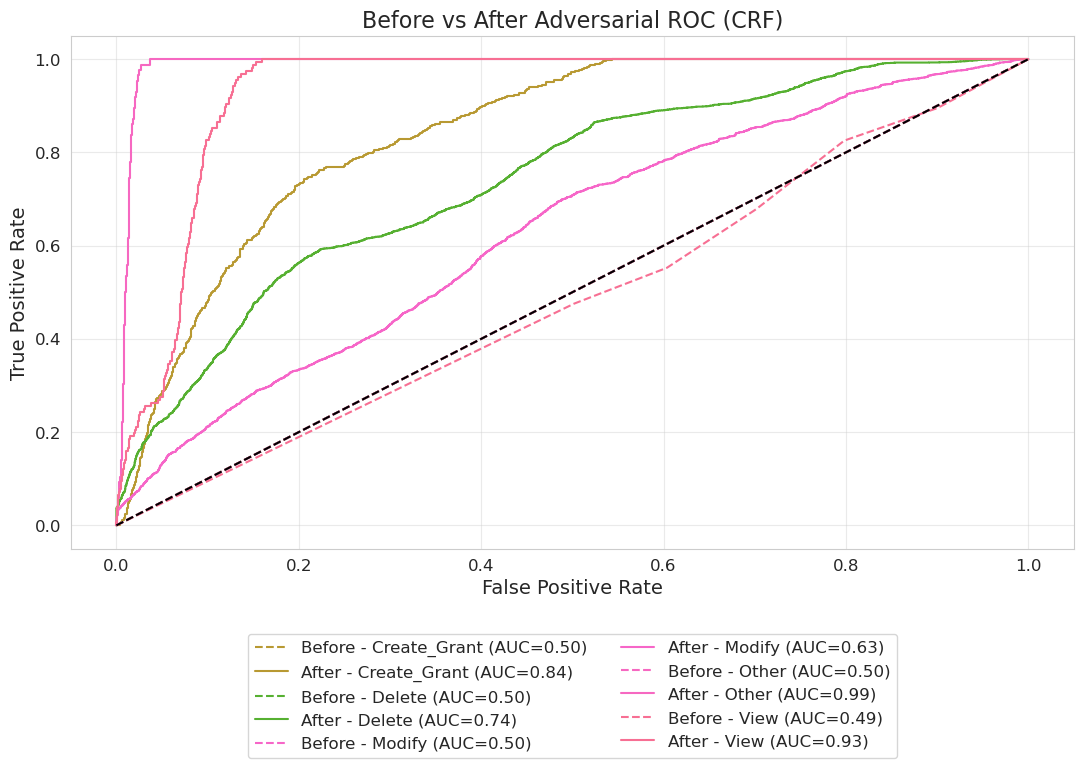

Saved plot: paper_outputs_synthetic/synthetic_section_9B_crf_before_after_roc.jpg


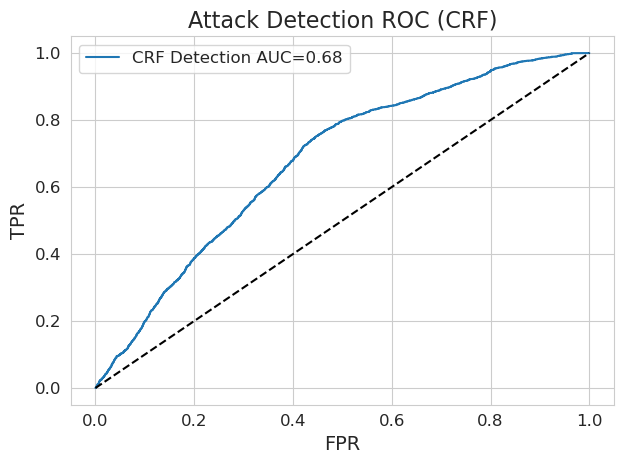

Saved plot: paper_outputs_synthetic/synthetic_section_10_crf_attack_detection_roc.jpg
CRF Detection AUC: 0.6772
Saved table: paper_outputs_synthetic/synthetic_section_9B_crf_detection_summary.jpg


In [47]:
# ==========================================================
# 9B) BEFORE vs AFTER ADVERSARIAL ROC + CRF ATTACK DETECTION
#    FIXED + INTEGRATED VERSION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ----------------------------------------------------------
# RESTORE FROZEN SECTION-7 / CRF STATE IF AVAILABLE
# ----------------------------------------------------------
if "final_crf_for_validation" in globals():
    final_crf = final_crf_for_validation

if "X_test_final_for_validation" in globals():
    X_test = X_test_final_for_validation

if "y_test_final_for_validation" in globals():
    y_test = y_test_final_for_validation

if "baseline_crf_final" in globals():
    baseline_crf = baseline_crf_final

if "y_pred_prob_base_final" in globals():
    y_pred_prob_base = y_pred_prob_base_final

# ----------------------------------------------------------
# SAFE HELPERS
# ----------------------------------------------------------
def safe_class_list_for_prob_matrix(class_list, y_prob):
    n_cols = y_prob.shape[1]
    if len(class_list) != n_cols:
        print(
            f" Class/probability mismatch detected: "
            f"{len(class_list)} classes vs {n_cols} probability columns. "
            f"Trimming to the first {n_cols} classes."
        )
    return list(class_list)[:n_cols]


def align_probabilities_safe(y_prob, source_classes, target_classes):
    source_classes = safe_class_list_for_prob_matrix(source_classes, y_prob)

    aligned = np.zeros((y_prob.shape[0], len(target_classes)))
    source_index = {cls: i for i, cls in enumerate(source_classes)}

    for j, cls in enumerate(target_classes):
        if cls in source_index:
            idx = source_index[cls]
            if idx < y_prob.shape[1]:
                aligned[:, j] = y_prob[:, idx]

    return aligned


def extract_probabilities_safe(crf_model, X_seq, class_list):
    """
    Build token-level probability matrix from CRF marginals.
    Output shape: [total_tokens, num_classes]
    """
    prob_rows = []

    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)

        for m in marginals:
            prob_rows.append([m.get(cls, 0.0) for cls in class_list])

    return np.array(prob_rows)


# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
required_vars = [
    "baseline_crf",
    "final_crf",
    "X_test",
    "y_test",
    "y_test_base",
    "y_pred_prob_base",
]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("❌ Section 9B skipped.")
    print("Missing variables:", missing_vars)

else:
    # ------------------------------------------------------
    # STEP 1: UNIFIED CLASS SPACE (CRF BEFORE vs AFTER)
    # ------------------------------------------------------
    classes_base_prob = list(baseline_crf.classes_) if "baseline_crf" in globals() else []
    classes_adv_prob  = list(final_crf.classes_) if "final_crf" in globals() else []

    classes_common = sorted(set(classes_base_prob) | set(classes_adv_prob))

    # ------------------------------------------------------
    # STEP 2: SAFE FLATTENING
    # ------------------------------------------------------
    y_test_flat_base = [l for seq in y_test_base for l in seq]
    y_test_flat_adv  = [l for seq in y_test for l in seq]

    y_test_bin_base_common = label_binarize(
        y_test_flat_base,
        classes=classes_common
    )

    y_test_bin_adv_common = label_binarize(
        y_test_flat_adv,
        classes=classes_common
    )

    # ------------------------------------------------------
    # STEP 3: BUILD MISSING ADVERSARIAL PROBABILITY MATRIX
    # ------------------------------------------------------
    # This is the missing object that caused the NameError
    y_pred_prob = extract_probabilities_safe(
        final_crf,
        X_test,
        classes_adv_prob
    )

    # ------------------------------------------------------
    # STEP 4: ALIGN PROBABILITIES SAFELY
    # ------------------------------------------------------
    y_pred_prob_base_aligned = align_probabilities_safe(
        y_pred_prob_base,
        classes_base_prob,
        classes_common
    )

    y_pred_prob_adv_aligned = align_probabilities_safe(
        y_pred_prob,
        classes_adv_prob,
        classes_common
    )

    # ------------------------------------------------------
    # STEP 5: BEFORE vs AFTER ADVERSARIAL ROC (CRF)
    # ------------------------------------------------------
    plt.figure(figsize=(11, 8))

    palette = sns.color_palette("husl", len(classes_common))
    color_map = {cls: palette[i] for i, cls in enumerate(classes_common)}

    plotted_crf = False

    for i, cls in enumerate(classes_common):
        try:
            if np.sum(y_test_bin_base_common[:, i]) > 0:
                fpr_b, tpr_b, _ = roc_curve(
                    y_test_bin_base_common[:, i],
                    y_pred_prob_base_aligned[:, i]
                )
                auc_b = auc(fpr_b, tpr_b)

                plt.plot(
                    fpr_b, tpr_b,
                    linestyle="--",
                    color=color_map[cls],
                    label=f"Before - {cls} (AUC={auc_b:.2f})"
                )
                plotted_crf = True

            if np.sum(y_test_bin_adv_common[:, i]) > 0:
                fpr_a, tpr_a, _ = roc_curve(
                    y_test_bin_adv_common[:, i],
                    y_pred_prob_adv_aligned[:, i]
                )
                auc_a = auc(fpr_a, tpr_a)

                plt.plot(
                    fpr_a, tpr_a,
                    linestyle="-",
                    color=color_map[cls],
                    label=f"After - {cls} (AUC={auc_a:.2f})"
                )
                plotted_crf = True

        except Exception:
            continue

    if plotted_crf:
        plt.plot([0, 1], [0, 1], "--", color="black")
        plt.title("Before vs After Adversarial ROC (CRF)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            ncol=2
        )
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

        if "save_current_plot" in globals():
            plt.figure(figsize=(11, 8))

            for i, cls in enumerate(classes_common):
                try:
                    if np.sum(y_test_bin_base_common[:, i]) > 0:
                        fpr_b, tpr_b, _ = roc_curve(
                            y_test_bin_base_common[:, i],
                            y_pred_prob_base_aligned[:, i]
                        )
                        auc_b = auc(fpr_b, tpr_b)

                        plt.plot(
                            fpr_b, tpr_b,
                            linestyle="--",
                            color=color_map[cls],
                            label=f"Before - {cls} (AUC={auc_b:.2f})"
                        )

                    if np.sum(y_test_bin_adv_common[:, i]) > 0:
                        fpr_a, tpr_a, _ = roc_curve(
                            y_test_bin_adv_common[:, i],
                            y_pred_prob_adv_aligned[:, i]
                        )
                        auc_a = auc(fpr_a, tpr_a)

                        plt.plot(
                            fpr_a, tpr_a,
                            linestyle="-",
                            color=color_map[cls],
                            label=f"After - {cls} (AUC={auc_a:.2f})"
                        )
                except Exception:
                    continue

            plt.plot([0, 1], [0, 1], "--", color="black")
            plt.title("Before vs After Adversarial ROC (CRF)")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend(
                loc="upper center",
                bbox_to_anchor=(0.5, -0.15),
                ncol=2
            )
            plt.grid(True, alpha=0.4)
            plt.tight_layout()
            save_current_plot("section_9B_crf_before_after_roc")
            plt.close()

    else:
        plt.close()
        print(" No valid CRF before/after ROC curves plotted.")

    # ------------------------------------------------------
    # STEP 6: ATTACK DETECTION ROC (CRF)
    # ------------------------------------------------------
    y_pred_adv = final_crf.predict(X_test)

    y_test_flat = [l for seq in y_test for l in seq]
    y_pred_flat = [l for seq in y_pred_adv for l in seq]

    attack_labels = (
        np.array(y_pred_flat) != np.array(y_test_flat)
    ).astype(int)

    y_pred_prob_common = align_probabilities_safe(
        extract_probabilities_safe(final_crf, X_test, classes_adv_prob),
        classes_adv_prob,
        classes_common
    )

    confidence_scores = np.max(y_pred_prob_common, axis=1)
    detection_signal = 1 - confidence_scores

    fpr_det, tpr_det, _ = roc_curve(attack_labels, detection_signal)
    det_auc = auc(fpr_det, tpr_det)

    plt.figure()
    plt.plot(fpr_det, tpr_det, label=f"CRF Detection AUC={det_auc:.2f}")
    plt.plot([0, 1], [0, 1], "--", color="black")
    plt.title("Attack Detection ROC (CRF)")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    if "save_current_plot" in globals():
        plt.figure()
        plt.plot(fpr_det, tpr_det, label=f"CRF Detection AUC={det_auc:.2f}")
        plt.plot([0, 1], [0, 1], "--", color="black")
        plt.title("Attack Detection ROC (CRF)")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        save_current_plot("section_10_crf_attack_detection_roc")
        plt.close()

    print(f"CRF Detection AUC: {det_auc:.4f}")

    # ------------------------------------------------------
    # STEP 7: OPTIONAL SAVE SUMMARY TABLE
    # ------------------------------------------------------
    crf_det_df = pd.DataFrame([{
        "Detection_AUC": det_auc,
        "Mean_Confidence": float(np.mean(confidence_scores)),
        "Mean_Detection_Signal": float(np.mean(detection_signal))
    }])

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            crf_det_df.round(4),
            "section_9B_crf_detection_summary",
            title="CRF Detection Summary"
        )

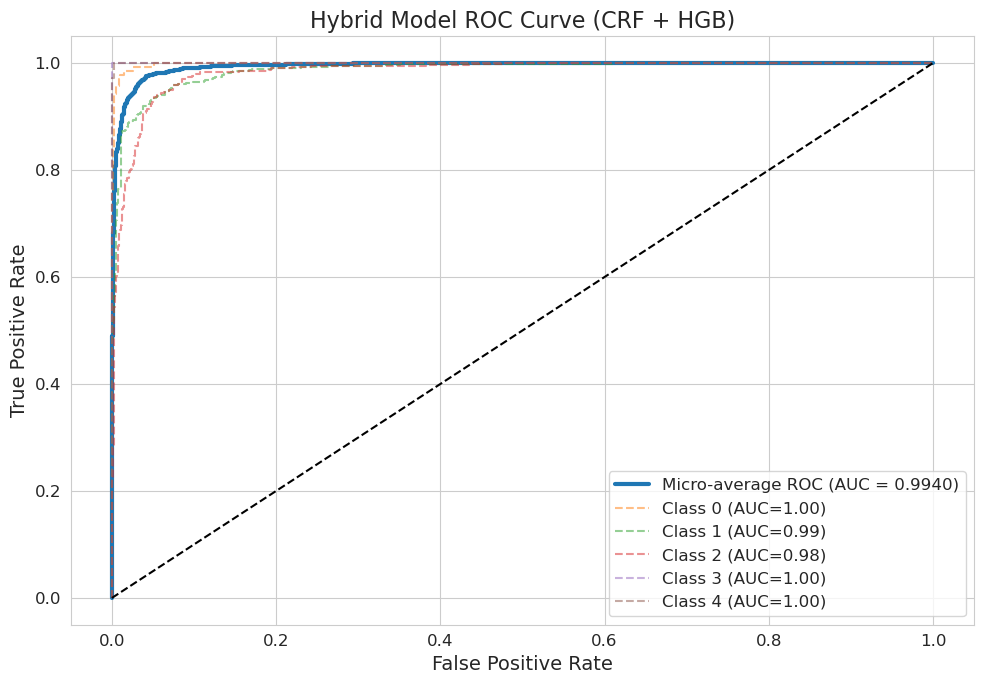

Saved plot: paper_outputs_synthetic/synthetic_section_11F_hybrid_multiclass_roc.jpg

Hybrid ROC-AUC (micro): 0.9940


In [48]:
# ==========================================================
# 11F) HYBRID ROC CURVE (MULTI-CLASS, PUBLICATION-READY)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ----------------------------------------------------------
# RESTORE FINAL HYBRID STATE (SAFETY)
# ----------------------------------------------------------
if "tab_model_final" in globals():
    tab_model = tab_model_final

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final)

# ----------------------------------------------------------
# CHECK REQUIREMENTS
# ----------------------------------------------------------
if not hasattr(tab_model, "predict_proba"):
    print("❌ Hybrid model has no predict_proba; ROC cannot be plotted.")

else:
    # ------------------------------------------------------
    # STEP 1: GET PROBABILITIES
    # ------------------------------------------------------
    y_prob = tab_model.predict_proba(X_test_tab)

    classes = np.unique(y_test_tab_enc)
    y_test_bin = label_binarize(y_test_tab_enc, classes=classes)

    # ------------------------------------------------------
    # STEP 2: COMPUTE ROC PER CLASS
    # ------------------------------------------------------
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(classes)):
        try:
            if np.sum(y_test_bin[:, i]) > 0:
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            continue

    # ------------------------------------------------------
    # STEP 3: MICRO-AVERAGE ROC
    # ------------------------------------------------------
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # ------------------------------------------------------
    # STEP 4: PLOT
    # ------------------------------------------------------
    plt.figure(figsize=(10, 7))

    # micro-average (main curve)
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})",
        linewidth=3
    )

    # individual classes (lighter lines)
    for i in roc_auc:
        if i == "micro":
            continue
        plt.plot(
            fpr[i],
            tpr[i],
            linestyle="--",
            alpha=0.5,
            label=f"Class {i} (AUC={roc_auc[i]:.2f})"
        )

    plt.plot([0, 1], [0, 1], "--", color="black")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Hybrid Model ROC Curve (CRF + HGB)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()

    # ------------------------------------------------------
    # SHOW + SAVE
    # ------------------------------------------------------
    plt.show()

    if "save_current_plot" in globals():
        plt.figure(figsize=(10, 7))

        plt.plot(
            fpr["micro"],
            tpr["micro"],
            label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})",
            linewidth=3
        )

        for i in roc_auc:
            if i == "micro":
                continue
            plt.plot(
                fpr[i],
                tpr[i],
                linestyle="--",
                alpha=0.5,
                label=f"Class {i} (AUC={roc_auc[i]:.2f})"
            )

        plt.plot([0, 1], [0, 1], "--", color="black")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Hybrid Model ROC Curve (CRF + HGB)")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()

        save_current_plot("section_11F_hybrid_multiclass_roc")
        plt.close()

    print(f"\nHybrid ROC-AUC (micro): {roc_auc['micro']:.4f}")

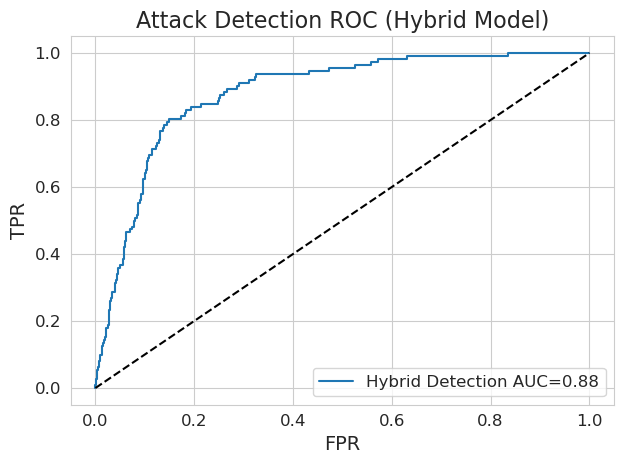

Hybrid Detection AUC: 0.8809
Saved plot: paper_outputs_synthetic/synthetic_section_10C_hybrid_attack_detection_roc.jpg
Saved table: paper_outputs_synthetic/synthetic_section_10C_hybrid_attack_detection_summary.jpg


In [49]:
# ==========================================================
# 10C) ATTACK DETECTION ROC (HYBRID / HGB)
#    UPDATED FOR CRF-PROBABILITY-AUGMENTED HYBRID
# ==========================================================

# ----------------------------------------------------------
# RESTORE FROZEN AUGMENTED HYBRID STATE
# ----------------------------------------------------------
if "tab_model_final" in globals():
    tab_model = tab_model_final

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

if "y_pred_tab_enc_final" in globals():
    y_pred_tab_enc = np.array(y_pred_tab_enc_final).copy()

if "y_prob_tab_final" in globals() and y_prob_tab_final is not None:
    y_prob_tab = np.array(y_prob_tab_final).copy()

# ----------------------------------------------------------
# MAIN BLOCK
# ----------------------------------------------------------
if all(v in globals() for v in ["tab_model", "X_test_tab", "y_test_tab_enc"]):

    if hasattr(tab_model, "predict_proba"):

        # --------------------------------------------------
        # STEP 1: HYBRID PREDICTIONS
        # --------------------------------------------------
        if "y_pred_tab_enc" not in globals():
            y_pred_tab_enc = tab_model.predict(X_test_tab)

        # Attack label: prediction is wrong
        hybrid_attack_labels = (
            np.array(y_pred_tab_enc) != np.array(y_test_tab_enc)
        ).astype(int)

        # --------------------------------------------------
        # STEP 2: HYBRID CONFIDENCE SIGNAL
        # --------------------------------------------------
        if "y_prob_tab" not in globals() or y_prob_tab is None:
            y_prob_tab = tab_model.predict_proba(X_test_tab)

        hybrid_confidence_scores = np.max(y_prob_tab, axis=1)
        hybrid_detection_signal = 1 - hybrid_confidence_scores

        # --------------------------------------------------
        # STEP 3: ROC
        # --------------------------------------------------
        fpr_hyb, tpr_hyb, _ = roc_curve(
            hybrid_attack_labels,
            hybrid_detection_signal
        )
        hybrid_det_auc = auc(fpr_hyb, tpr_hyb)

        plt.figure()
        plt.plot(fpr_hyb, tpr_hyb, label=f"Hybrid Detection AUC={hybrid_det_auc:.2f}")
        plt.plot([0, 1], [0, 1], "--", color="black")

        plt.title("Attack Detection ROC (Hybrid Model)")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"Hybrid Detection AUC: {hybrid_det_auc:.4f}")

        # --------------------------------------------------
        # SAVE FOR PAPER
        # --------------------------------------------------
        if "save_current_plot" in globals():
            plt.figure()
            plt.plot(fpr_hyb, tpr_hyb, label=f"Hybrid Detection AUC={hybrid_det_auc:.2f}")
            plt.plot([0, 1], [0, 1], "--", color="black")
            plt.title("Attack Detection ROC (Hybrid Model)")
            plt.xlabel("FPR")
            plt.ylabel("TPR")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            save_current_plot("section_10C_hybrid_attack_detection_roc")
            plt.close()

        # --------------------------------------------------
        # OPTIONAL: SAVE SUMMARY TABLE
        # --------------------------------------------------
        hybrid_det_df = pd.DataFrame([{
            "Detection_AUC": hybrid_det_auc,
            "Mean_Confidence": float(np.mean(hybrid_confidence_scores)),
            "Mean_Detection_Signal": float(np.mean(hybrid_detection_signal))
        }])

        if "save_dataframe_as_jpg" in globals():
            save_dataframe_as_jpg(
                hybrid_det_df.round(4),
                "section_10C_hybrid_attack_detection_summary",
                title="Hybrid Attack Detection Summary"
            )

    else:
        print("\nHybrid model has no predict_proba; hybrid attack detection ROC skipped.")

else:
    print("\nHybrid/HGB variables not found yet; hybrid attack detection ROC skipped.")


[DEBUG] Hybrid Before vs After ROC
Before prob shape: (200, 5)
After prob shape : (1600, 5)
Class count      : 5


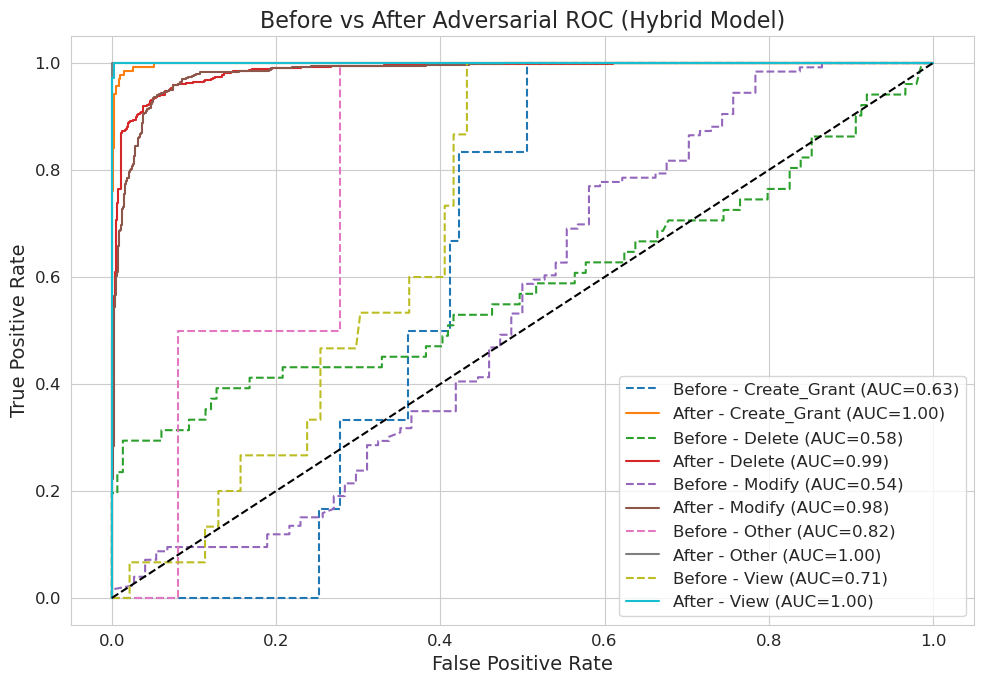

Saved plot: paper_outputs_synthetic/synthetic_section_10D_hybrid_before_after_roc.jpg


In [50]:
# ==========================================================
# 10D) BEFORE vs AFTER ADVERSARIAL ROC (HYBRID / HGB)
#    UPDATED FOR CRF-PROBABILITY-AUGMENTED HYBRID
# ==========================================================

# ----------------------------------------------------------
# RESTORE FROZEN AUGMENTED HYBRID STATE
# ----------------------------------------------------------
if "tab_model_final" in globals():
    tab_model = tab_model_final

if "label_encoder_hybrid" in globals():
    le = label_encoder_hybrid

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

# ----------------------------------------------------------
# HELPER: BASELINE CRF FEATURE EXTRACTOR
# ----------------------------------------------------------
def extract_crf_features_for_any_model(crf_model, X_seq, class_list=None):
    if class_list is None:
        class_list = list(crf_model.classes_)

    feature_rows = []

    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)

        probs = []
        max_probs = []
        entropies = []
        class_means = {f"crf_mean_prob__{cls}": [] for cls in class_list}

        for m in marginals:
            vec = np.array([m.get(cls, 0.0) for cls in class_list], dtype=float)

            probs.extend(vec.tolist())
            max_probs.append(float(np.max(vec)))
            entropies.append(float(-np.sum(vec * np.log(vec + 1e-12))))

            for cls in class_list:
                class_means[f"crf_mean_prob__{cls}"].append(float(m.get(cls, 0.0)))

        probs = np.array(probs, dtype=float) if len(probs) > 0 else np.array([0.0])

        row = {
            "crf_prob_mean": float(np.mean(probs)),
            "crf_prob_std": float(np.std(probs)),
            "crf_prob_max": float(np.max(probs)),
            "crf_prob_min": float(np.min(probs)),
            "crf_prob_entropy_mean": float(np.mean(entropies)) if len(entropies) > 0 else 0.0,
            "crf_prob_entropy_max": float(np.max(entropies)) if len(entropies) > 0 else 0.0,
            "crf_confidence_mean": float(np.mean(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_min": float(np.min(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_std": float(np.std(max_probs)) if len(max_probs) > 0 else 0.0,
        }

        for k, vals in class_means.items():
            row[k] = float(np.mean(vals)) if len(vals) > 0 else 0.0

        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
required_vars = [
    "tab_model",
    "X_test_tab",
    "y_test_tab_enc",
    "summarize_sequence",
    "le"
]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("Hybrid before-vs-after ROC skipped.")
    print("Missing variables:", missing_vars)

elif not hasattr(tab_model, "predict_proba"):
    print("Hybrid model has no predict_proba; before-vs-after ROC skipped.")

else:
    # ------------------------------------------------------
    # STEP 1: GET BASELINE TEST SET
    # ------------------------------------------------------
    if "X_test_base_final" in globals() and "y_test_base_final" in globals():
        X_test_base = X_test_base_final
        y_test_base = y_test_base_final
    elif "X_test_base" in globals() and "y_test_base" in globals():
        pass
    else:
        print("Baseline hybrid comparison inputs not found; skipping Section 10D.")
        X_test_base = None

    if X_test_base is not None:
        # --------------------------------------------------
        # STEP 2: BUILD BASELINE TABULAR FEATURES
        # --------------------------------------------------
        X_test_tab_base_core = pd.DataFrame(
            [summarize_sequence(seq) for seq in X_test_base]
        ).fillna(0)

        # Rebuild baseline CRF-probability features if baseline CRF exists
        if "baseline_crf_final" in globals():
            baseline_crf_model = baseline_crf_final
        elif "baseline_crf" in globals():
            baseline_crf_model = baseline_crf
        else:
            baseline_crf_model = None

        if baseline_crf_model is not None:
            baseline_classes = list(baseline_crf_model.classes_)
            base_crf_feats = extract_crf_features_for_any_model(
                baseline_crf_model,
                X_test_base,
                class_list=baseline_classes
            )
            X_test_tab_base = pd.concat(
                [X_test_tab_base_core.reset_index(drop=True), base_crf_feats.reset_index(drop=True)],
                axis=1
            )
        else:
            X_test_tab_base = X_test_tab_base_core.copy()

        # Align baseline feature space to final augmented schema
        X_test_tab_base = X_test_tab_base.reindex(
            columns=X_test_tab.columns,
            fill_value=0
        )

        # --------------------------------------------------
        # STEP 3: BUILD BASELINE TARGETS
        # --------------------------------------------------
        def sequence_target(seq_labels):
            return seq_labels[-1] if isinstance(seq_labels, list) else seq_labels

        y_test_tab_base = [sequence_target(seq) for seq in y_test_base]

        try:
            y_test_tab_base_enc = le.transform(y_test_tab_base)
        except Exception:
            print("Some baseline labels are not in the hybrid label encoder. Filtering to shared labels.")
            known_classes = set(le.classes_)
            valid_base_mask = np.array([lbl in known_classes for lbl in y_test_tab_base])

            X_test_tab_base = X_test_tab_base.loc[valid_base_mask].reset_index(drop=True)
            y_test_tab_base = [lbl for lbl in y_test_tab_base if lbl in known_classes]
            y_test_tab_base_enc = le.transform(y_test_tab_base)

        # --------------------------------------------------
        # STEP 4: HYBRID PROBABILITIES
        # --------------------------------------------------
        y_prob_hyb_after = tab_model.predict_proba(X_test_tab)
        y_prob_hyb_before = tab_model.predict_proba(X_test_tab_base)

        # --------------------------------------------------
        # STEP 5: CLASS SPACE
        # --------------------------------------------------
        tab_classes = np.arange(len(le.classes_))

        y_test_bin_after = label_binarize(
            y_test_tab_enc,
            classes=tab_classes
        )

        y_test_bin_before = label_binarize(
            y_test_tab_base_enc,
            classes=tab_classes
        )

        common_width = min(
            y_prob_hyb_after.shape[1],
            y_prob_hyb_before.shape[1],
            y_test_bin_after.shape[1],
            y_test_bin_before.shape[1]
        )

        y_prob_hyb_after = y_prob_hyb_after[:, :common_width]
        y_prob_hyb_before = y_prob_hyb_before[:, :common_width]
        y_test_bin_after = y_test_bin_after[:, :common_width]
        y_test_bin_before = y_test_bin_before[:, :common_width]
        class_names = list(le.classes_[:common_width])

        print("\n[DEBUG] Hybrid Before vs After ROC")
        print("Before prob shape:", y_prob_hyb_before.shape)
        print("After prob shape :", y_prob_hyb_after.shape)
        print("Class count      :", len(class_names))

        # --------------------------------------------------
        # STEP 6: ROC CURVES
        # --------------------------------------------------
        plt.figure(figsize=(10, 7))
        plotted = False

        for i, cls_name in enumerate(class_names):
            try:
                if np.sum(y_test_bin_before[:, i]) > 0:
                    fpr_b, tpr_b, _ = roc_curve(
                        y_test_bin_before[:, i],
                        y_prob_hyb_before[:, i]
                    )
                    auc_b = auc(fpr_b, tpr_b)

                    plt.plot(
                        fpr_b,
                        tpr_b,
                        linestyle="--",
                        label=f"Before - {cls_name} (AUC={auc_b:.2f})"
                    )
                    plotted = True

                if np.sum(y_test_bin_after[:, i]) > 0:
                    fpr_a, tpr_a, _ = roc_curve(
                        y_test_bin_after[:, i],
                        y_prob_hyb_after[:, i]
                    )
                    auc_a = auc(fpr_a, tpr_a)

                    plt.plot(
                        fpr_a,
                        tpr_a,
                        linestyle="-",
                        label=f"After - {cls_name} (AUC={auc_a:.2f})"
                    )
                    plotted = True

            except Exception:
                continue

        if plotted:
            plt.plot([0, 1], [0, 1], "--", color="black")
            plt.title("Before vs After Adversarial ROC (Hybrid Model)")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            if "save_current_plot" in globals():
                plt.figure(figsize=(10, 7))

                for i, cls_name in enumerate(class_names):
                    try:
                        if np.sum(y_test_bin_before[:, i]) > 0:
                            fpr_b, tpr_b, _ = roc_curve(
                                y_test_bin_before[:, i],
                                y_prob_hyb_before[:, i]
                            )
                            auc_b = auc(fpr_b, tpr_b)

                            plt.plot(
                                fpr_b,
                                tpr_b,
                                linestyle="--",
                                label=f"Before - {cls_name} (AUC={auc_b:.2f})"
                            )

                        if np.sum(y_test_bin_after[:, i]) > 0:
                            fpr_a, tpr_a, _ = roc_curve(
                                y_test_bin_after[:, i],
                                y_prob_hyb_after[:, i]
                            )
                            auc_a = auc(fpr_a, tpr_a)

                            plt.plot(
                                fpr_a,
                                tpr_a,
                                linestyle="-",
                                label=f"After - {cls_name} (AUC={auc_a:.2f})"
                            )
                    except Exception:
                        continue

                plt.plot([0, 1], [0, 1], "--", color="black")
                plt.title("Before vs After Adversarial ROC (Hybrid Model)")
                plt.xlabel("False Positive Rate")
                plt.ylabel("True Positive Rate")
                plt.legend()
                plt.grid(True)
                plt.tight_layout()
                save_current_plot("section_10D_hybrid_before_after_roc")
                plt.close()

        else:
            print("No valid ROC curves plotted for hybrid before-vs-after comparison.")

In [51]:
# ==========================================================
# 11B) MULTI-RUN ROBUST EVALUATION (HYBRID / HGB)
#    UPDATED FOR AUGMENTED HYBRID
# ==========================================================

# ----------------------------------------------------------
# ENSURE MULTI-RUN USES FROZEN AUGMENTED MATRICES
# ----------------------------------------------------------
if "X_train_tab_final" in globals():
    X_train_tab = X_train_tab_final.copy()

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_train_tab_enc_final" in globals():
    y_train_tab_enc = np.array(y_train_tab_enc_final).copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

if all(v in globals() for v in ["X_train_tab", "X_test_tab", "y_train_tab_enc", "y_test_tab_enc"]):

    acc_list_hgb, f1_list_hgb, auc_list_hgb = [], [], []

    for run in range(5):
        print(f"\n=== Hybrid Run {run+1} ===")

        try:
            from sklearn.ensemble import HistGradientBoostingClassifier
            model = HistGradientBoostingClassifier(
                max_iter=500,
                learning_rate=0.03,
                max_depth=8,
                random_state=42 + run
            )
        except Exception:
            model = tab_model

        idx = np.random.permutation(len(X_train_tab))
        X_train_shuffled = X_train_tab.iloc[idx]
        y_train_shuffled = np.array(y_train_tab_enc)[idx]

        model.fit(X_train_shuffled, y_train_shuffled)
        y_pred_run = model.predict(X_test_tab)

        acc_list_hgb.append(accuracy_score(y_test_tab_enc, y_pred_run))
        f1_list_hgb.append(
            f1_score(y_test_tab_enc, y_pred_run, average="macro", zero_division=0)
        )

        if hasattr(model, "predict_proba"):
            y_prob_run = model.predict_proba(X_test_tab)
            attack_labels_run = (
                np.array(y_pred_run) != np.array(y_test_tab_enc)
            ).astype(int)

            conf = np.max(y_prob_run, axis=1)
            signal = 1 - conf
            fpr_run, tpr_run, _ = roc_curve(attack_labels_run, signal)
            auc_list_hgb.append(auc(fpr_run, tpr_run))
        else:
            auc_list_hgb.append(np.nan)

    print("\n=== Hybrid Multi-Run Summary ===")
    print(f"Accuracy : {np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}")
    print(f"F1 Score : {np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}")
    print(f"Det AUC  : {np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}")

    hybrid_multi_run_df = pd.DataFrame([{
        "Accuracy": f"{np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}",
        "F1 Score": f"{np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}",
        "Det AUC": f"{np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}",
    }])

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            hybrid_multi_run_df,
            "section_11B_hybrid_multi_run_summary",
            title="Hybrid Multi-Run Summary"
        )

else:
    print("Hybrid multi-run skipped (missing tabular variables)")


=== Hybrid Run 1 ===

=== Hybrid Run 2 ===

=== Hybrid Run 3 ===

=== Hybrid Run 4 ===

=== Hybrid Run 5 ===

=== Hybrid Multi-Run Summary ===
Accuracy : 0.9300 ± 0.0000
F1 Score : 0.9250 ± 0.0000
Det AUC  : 0.8809 ± 0.0000
Saved table: paper_outputs_synthetic/synthetic_section_11B_hybrid_multi_run_summary.jpg


In [52]:
# ==========================================================
# 11A) MULTI-RUN ROBUST EVALUATION (CRF)
# ==========================================================

if all(v in globals() for v in ["X_train", "X_test", "y_train", "y_test"]):

    acc_list, f1_list, auc_list = [], [], []

    for run in range(5):
        print(f"\n=== CRF Run {run+1} ===")

        # --------------------------------------------------
        # CRF MODEL
        # --------------------------------------------------
        crf_run = CRF(
            algorithm="lbfgs",
            all_possible_transitions=True,
            c1=best_params.get("c1", 0.1) if "best_params" in globals() else 0.1,
            c2=best_params.get("c2", 0.01) if "best_params" in globals() else 0.01,
            max_iterations=best_params.get("max_iterations", 600) if "best_params" in globals() else 600
        )

        # --------------------------------------------------
        # SHUFFLE TRAIN SEQUENCES
        # --------------------------------------------------
        idx = np.random.RandomState(42 + run).permutation(len(X_train))
        X_train_shuffled = [X_train[i] for i in idx]
        y_train_shuffled = [y_train[i] for i in idx]

        crf_run.fit(X_train_shuffled, y_train_shuffled)

        # --------------------------------------------------
        # WEIGHTED PREDICTION
        # --------------------------------------------------
        label_counts_run = Counter([lab for seq in y_train_shuffled for lab in seq])
        total_labels_run = sum(label_counts_run.values())

        class_weights_run = {
            label: total_labels_run / (len(label_counts_run) * count)
            for label, count in label_counts_run.items()
        }

        y_pred_run = predict_weighted(crf_run, X_test, class_weights_run)

        y_test_flat_run = [lab for seq in y_test for lab in seq]
        y_pred_flat_run = [lab for seq in y_pred_run for lab in seq]

        acc_list.append(accuracy_score(y_test_flat_run, y_pred_flat_run))
        f1_list.append(
            f1_score(y_test_flat_run, y_pred_flat_run, average="macro", zero_division=0)
        )

        # --------------------------------------------------
        # DETECTION AUC
        # --------------------------------------------------
        classes_run = list(crf_run.classes_)

        def extract_probabilities_for_run(crf_model, X_seq, class_list):
            prob_rows = []
            for seq in X_seq:
                marginals = crf_model.predict_marginals_single(seq)
                for m in marginals:
                    prob_rows.append([m.get(cls, 0.0) for cls in class_list])
            return np.array(prob_rows)

        y_prob_run = extract_probabilities_for_run(crf_run, X_test, classes_run)

        confidence_scores_run = np.max(y_prob_run, axis=1)
        detection_signal_run = 1 - confidence_scores_run

        attack_labels_run = (
            np.array(y_pred_flat_run) != np.array(y_test_flat_run)
        ).astype(int)

        fpr_run, tpr_run, _ = roc_curve(attack_labels_run, detection_signal_run)
        auc_list.append(auc(fpr_run, tpr_run))

    print("\n=== CRF Multi-Run Summary ===")
    print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"F1 Score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"Det AUC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

    crf_multi_run_df = pd.DataFrame([{
        "Accuracy": f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
        "F1 Score": f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
        "Det AUC": f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}",
    }])

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            crf_multi_run_df,
            "section_11A_crf_multi_run_summary",
            title="CRF Multi-Run Summary"
        )

else:
    print("CRF multi-run skipped (missing sequence variables)")


=== CRF Run 1 ===

=== CRF Run 2 ===

=== CRF Run 3 ===

=== CRF Run 4 ===

=== CRF Run 5 ===

=== CRF Multi-Run Summary ===
Accuracy : 0.5010 ± 0.0007
F1 Score : 0.3987 ± 0.0028
Det AUC  : 0.7363 ± 0.0008
Saved table: paper_outputs_synthetic/synthetic_section_11A_crf_multi_run_summary.jpg


In [53]:
# ==========================================================
# 11C) UNIFIED MULTI-RUN SUMMARY (CRF vs HYBRID)
# ==========================================================

print("\n=== Multi-Run Summary (CRF vs Hybrid) ===")

# ----------------------------------------------------------
# CRF
# ----------------------------------------------------------
if all(v in globals() for v in ["acc_list", "f1_list", "auc_list"]):
    print("\n[CRF]")
    print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"F1 Score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"Det AUC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
else:
    print("\nCRF multi-run results not found")

# ----------------------------------------------------------
# HYBRID
# ----------------------------------------------------------
if "acc_list_hgb" in globals():
    print("\n[Hybrid / HGB]")
    print(f"Accuracy : {np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}")
    print(f"F1 Score : {np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}")
    print(f"Det AUC  : {np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}")
else:
    print("\nHybrid multi-run results not found")

# ----------------------------------------------------------
# SAVE UNIFIED SUMMARY
# ----------------------------------------------------------
summary_rows = []

if all(v in globals() for v in ["acc_list", "f1_list", "auc_list"]):
    summary_rows.append({
        "Model": "CRF",
        "Accuracy": f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
        "F1 Score": f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
        "Det AUC": f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}",
    })

if "acc_list_hgb" in globals():
    summary_rows.append({
        "Model": "Hybrid / HGB",
        "Accuracy": f"{np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}",
        "F1 Score": f"{np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}",
        "Det AUC": f"{np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}",
    })

if len(summary_rows) > 0:
    unified_multi_run_df = pd.DataFrame(summary_rows)

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            unified_multi_run_df,
            "section_11C_unified_multi_run_summary",
            title="Unified Multi-Run Summary"
        )


=== Multi-Run Summary (CRF vs Hybrid) ===

[CRF]
Accuracy : 0.5010 ± 0.0007
F1 Score : 0.3987 ± 0.0028
Det AUC  : 0.7363 ± 0.0008

[Hybrid / HGB]
Accuracy : 0.9300 ± 0.0000
F1 Score : 0.9250 ± 0.0000
Det AUC  : 0.8809 ± 0.0000
Saved table: paper_outputs_synthetic/synthetic_section_11C_unified_multi_run_summary.jpg



Robustness Summary Table:
          Model  Accuracy_mean  Accuracy_std   F1_mean    F1_std  DetAUC_mean  \
0           CRF       0.500975      0.000718  0.398650  0.002833     0.736344   
1  Hybrid (HGB)       0.930000      0.000000  0.924965  0.000000     0.880940   

   DetAUC_std  
0    0.000757  
1    0.000000  
Saved table: paper_outputs_synthetic/synthetic_section_11D_robustness_table.jpg
Saved plot: paper_outputs_synthetic/synthetic_section_11D_robustness_barplot.jpg


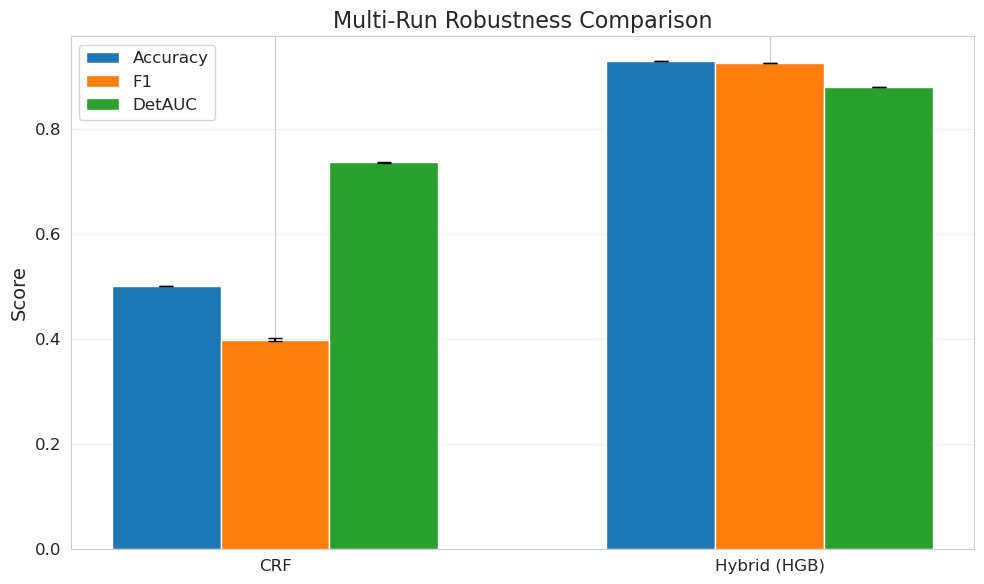


LaTeX Table:

\begin{table}
\caption{Multi-run robustness comparison of CRF and Hybrid models.}
\label{tab:multi_run_robustness}
\begin{tabular}{llll}
\toprule
Model & Accuracy & F1 & DetAUC \\
\midrule
CRF & 0.5010 $\pm$ 0.0007 & 0.3987 $\pm$ 0.0028 & 0.7363 $\pm$ 0.0008 \\
Hybrid (HGB) & 0.9300 $\pm$ 0.0000 & 0.9250 $\pm$ 0.0000 & 0.8809 $\pm$ 0.0000 \\
\bottomrule
\end{tabular}
\end{table}

Saved LaTeX table: paper_outputs_jpg/section_11D_robustness_table.tex


In [54]:
# ==========================================================
# 11D) MULTI-RUN ROBUSTNESS VISUAL + TABLE + LATEX EXPORT
#    FIXED / SYNCHRONIZED VERSION
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("paper_outputs_jpg", exist_ok=True)

# ----------------------------------------------------------
# BUILD SUMMARY TABLE SAFELY
# ----------------------------------------------------------
summary_rows = []

# CRF
if all(v in globals() for v in ["acc_list", "f1_list", "auc_list"]):
    summary_rows.append({
        "Model": "CRF",
        "Accuracy_mean": np.mean(acc_list),
        "Accuracy_std": np.std(acc_list),
        "F1_mean": np.mean(f1_list),
        "F1_std": np.std(f1_list),
        "DetAUC_mean": np.mean(auc_list),
        "DetAUC_std": np.std(auc_list)
    })
else:
    print(" CRF multi-run arrays not found; CRF will be omitted from 11D.")

# Hybrid / HGB
if all(v in globals() for v in ["acc_list_hgb", "f1_list_hgb", "auc_list_hgb"]):
    summary_rows.append({
        "Model": "Hybrid (HGB)",
        "Accuracy_mean": np.nanmean(acc_list_hgb),
        "Accuracy_std": np.nanstd(acc_list_hgb),
        "F1_mean": np.nanmean(f1_list_hgb),
        "F1_std": np.nanstd(f1_list_hgb),
        "DetAUC_mean": np.nanmean(auc_list_hgb),
        "DetAUC_std": np.nanstd(auc_list_hgb)
    })
else:
    print(" Hybrid multi-run arrays not found; Hybrid will be omitted from 11D.")

if len(summary_rows) == 0:
    print("❌ No multi-run results available for 11D.")
else:
    robustness_df = pd.DataFrame(summary_rows)

    print("\nRobustness Summary Table:")
    print(robustness_df)

    # ------------------------------------------------------
    # SAVE TABLE AS JPG
    # ------------------------------------------------------
    if "save_dataframe_as_jpg" in globals():
        display_df = robustness_df.copy()
        for col in display_df.columns:
            if col != "Model":
                display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")

        save_dataframe_as_jpg(
            display_df,
            "section_11D_robustness_table",
            title="Multi-Run Robustness Summary"
        )

    # ------------------------------------------------------
    # BAR CHART WITH ERROR BARS
    # ------------------------------------------------------
    metrics = ["Accuracy", "F1", "DetAUC"]
    models = robustness_df["Model"].tolist()

    x = np.arange(len(models))
    width = 0.22

    fig, ax = plt.subplots(figsize=(10, 6))

    for j, metric in enumerate(metrics):
        means = robustness_df[f"{metric}_mean"].values
        stds = robustness_df[f"{metric}_std"].values

        ax.bar(
            x + (j - 1) * width,
            means,
            width,
            yerr=stds,
            capsize=5,
            label=metric
        )

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel("Score")
    ax.set_title("Multi-Run Robustness Comparison")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    if "save_current_plot" in globals():
        save_current_plot("section_11D_robustness_barplot")
    plt.show()

    # ------------------------------------------------------
    # LATEX TABLE AUTO-EXPORT
    # ------------------------------------------------------
    latex_df = robustness_df.copy()

    for metric in ["Accuracy", "F1", "DetAUC"]:
        latex_df[metric] = latex_df.apply(
            lambda row: f"{row[f'{metric}_mean']:.4f} $\\pm$ {row[f'{metric}_std']:.4f}",
            axis=1
        )

    latex_df = latex_df[["Model", "Accuracy", "F1", "DetAUC"]]

    latex_table = latex_df.to_latex(
        index=False,
        escape=False,
        caption="Multi-run robustness comparison of CRF and Hybrid models.",
        label="tab:multi_run_robustness"
    )

    print("\nLaTeX Table:\n")
    print(latex_table)

    with open("paper_outputs_jpg/section_11D_robustness_table.tex", "w") as f:
        f.write(latex_table)

    print("Saved LaTeX table: paper_outputs_jpg/section_11D_robustness_table.tex")

In [55]:
# ==========================================================
# 11E) MAIN RESULTS + MODEL COMPARISON (MATCHING LATEX STYLE)
#    FIXED / SYNCHRONIZED VERSION
# ==========================================================

import os
import pandas as pd
import numpy as np

os.makedirs("paper_outputs_jpg", exist_ok=True)

# ----------------------------------------------------------
# MAIN PERFORMANCE RESULTS TABLE
# ----------------------------------------------------------
main_results_rows = []

# CRF
main_results_rows.append({
    "Model": "CRF (semantic + weighted decoding)",
    "Accuracy": acc_crf,
    "Precision": prec_crf,
    "Recall": rec_crf,
    "F1": f1_crf,
    "ROC_AUC": auc_crf if "auc_crf" in globals() else np.nan
})

# Hybrid
main_results_rows.append({
    "Model": f"{tab_model_name} (hybrid sequence model)",
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb if "auc_hgb" in globals() else np.nan
})

main_results_df = pd.DataFrame(main_results_rows)

print("\nMain Results Summary:")
print(main_results_df)

# save JPG
if "save_dataframe_as_jpg" in globals():
    jpg_df = main_results_df.copy()
    for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
        jpg_df[col] = jpg_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

    save_dataframe_as_jpg(
        jpg_df,
        "section_11E_main_results_summary",
        title="Main Performance Results"
    )

# matching LaTeX
latex_main_df = main_results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    latex_main_df[col] = latex_main_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

latex_main = latex_main_df.to_latex(
    index=False,
    escape=False,
    caption="Main performance comparison of CRF and hybrid models.",
    label="tab:main_performance_results"
)

print("\nLaTeX: Main Performance Results\n")
print(latex_main)

with open("paper_outputs_jpg/section_11E_main_results_summary.tex", "w") as f:
    f.write(latex_main)

print("Saved LaTeX table: paper_outputs_jpg/section_11E_main_results_summary.tex")

# ----------------------------------------------------------
# MODEL COMPARISON SUMMARY TABLE
# ----------------------------------------------------------
comparison_rows = []

# baseline, if available
if all(v in globals() for v in ["base_acc", "base_prec", "base_rec", "base_f1"]):
    comparison_rows.append({
        "Model": "Baseline CRF",
        "Accuracy": base_acc,
        "Precision": base_prec,
        "Recall": base_rec,
        "F1": base_f1,
        "ROC_AUC": np.nan
    })

# adversarial raw, if available
if all(v in globals() for v in ["adv1_acc", "adv1_prec", "adv1_rec", "adv1_f1"]):
    comparison_rows.append({
        "Model": "Adversarial CRF (raw labels)",
        "Accuracy": adv1_acc,
        "Precision": adv1_prec,
        "Recall": adv1_rec,
        "F1": adv1_f1,
        "ROC_AUC": np.nan
    })

# adversarial semantic, if available
if all(v in globals() for v in ["adv2_acc", "adv2_prec", "adv2_rec", "adv2_f1"]):
    comparison_rows.append({
        "Model": "Adversarial CRF (semantic labels)",
        "Accuracy": adv2_acc,
        "Precision": adv2_prec,
        "Recall": adv2_rec,
        "F1": adv2_f1,
        "ROC_AUC": np.nan
    })

# adversarial semantic + weighted / current CRF
comparison_rows.append({
    "Model": "Adversarial CRF (semantic + weighted decoding)",
    "Accuracy": acc_crf,
    "Precision": prec_crf,
    "Recall": rec_crf,
    "F1": f1_crf,
    "ROC_AUC": auc_crf if "auc_crf" in globals() else np.nan
})

# hybrid
comparison_rows.append({
    "Model": f"{tab_model_name} (hybrid sequence model)",
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb if "auc_hgb" in globals() else np.nan
})

comparison_df = pd.DataFrame(comparison_rows)

print("\nModel Comparison Summary:")
print(comparison_df)

# save JPG
if "save_dataframe_as_jpg" in globals():
    jpg_cmp_df = comparison_df.copy()
    for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
        jpg_cmp_df[col] = jpg_cmp_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

    save_dataframe_as_jpg(
        jpg_cmp_df,
        "section_11E_model_comparison_summary",
        title="Model Comparison Summary"
    )

# matching LaTeX
latex_cmp_df = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    latex_cmp_df[col] = latex_cmp_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

latex_comparison = latex_cmp_df.to_latex(
    index=False,
    escape=False,
    caption="Comparative performance progression across baseline, adversarial, semantic, weighted, and hybrid models.",
    label="tab:model_comparison_summary"
)

print("\nLaTeX: Model Comparison Summary\n")
print(latex_comparison)

with open("paper_outputs_jpg/section_11E_model_comparison_summary.tex", "w") as f:
    f.write(latex_comparison)

print("Saved LaTeX table: paper_outputs_jpg/section_11E_model_comparison_summary.tex")


Main Results Summary:
                                          Model  Accuracy  Precision  \
0            CRF (semantic + weighted decoding)   0.50225   0.367790   
1  HistGradientBoosting (hybrid sequence model)   0.93000   0.966116   

     Recall        F1   ROC_AUC  
0  0.555514  0.403291  0.827277  
1  0.890414  0.924965  0.993694  
Saved table: paper_outputs_synthetic/synthetic_section_11E_main_results_summary.jpg

LaTeX: Main Performance Results

\begin{table}
\caption{Main performance comparison of CRF and hybrid models.}
\label{tab:main_performance_results}
\begin{tabular}{llllll}
\toprule
Model & Accuracy & Precision & Recall & F1 & ROC_AUC \\
\midrule
CRF (semantic + weighted decoding) & 0.5022 & 0.3678 & 0.5555 & 0.4033 & 0.8273 \\
HistGradientBoosting (hybrid sequence model) & 0.9300 & 0.9661 & 0.8904 & 0.9250 & 0.9937 \\
\bottomrule
\end{tabular}
\end{table}

Saved LaTeX table: paper_outputs_jpg/section_11E_main_results_summary.tex

Model Comparison Summary:
           


 Section 12 using CRF-probability-augmented hybrid
Model: HistGradientBoosting
X_test_tab shape: (1600, 46)
Encoded classes : 5

[CONSISTENCY CHECK]
Hybrid model used in Section 12: HistGradientBoosting
Test feature shape: (1600, 46)
Encoded label count: 5

=== Baseline Hybrid Validation ===
                                   0
Accuracy                    0.930000
Precision                   0.966116
Recall                      0.890414
F1                          0.924965
ROC_AUC                     0.993694
Entropy_HY                  1.542600
Cond_Entropy_HY_given_Yhat  0.422984
Mutual_Info_IY_Yhat         1.119616
Detection_AUC               0.861637
Saved table: paper_outputs_synthetic/synthetic_section_12_baseline_hybrid_validation.jpg

=== Lattice Join Test ===
{'joined_set': {'priv_count_diff', 'priv_signal', 'dept_type', 'position_weight', 'Department', 'Employee_Status', 'rolling_priv_std', 'rolling_priv_mean', 'priv_ratio_change', 'prev_priv_count', 'priv_count', 'is_last',

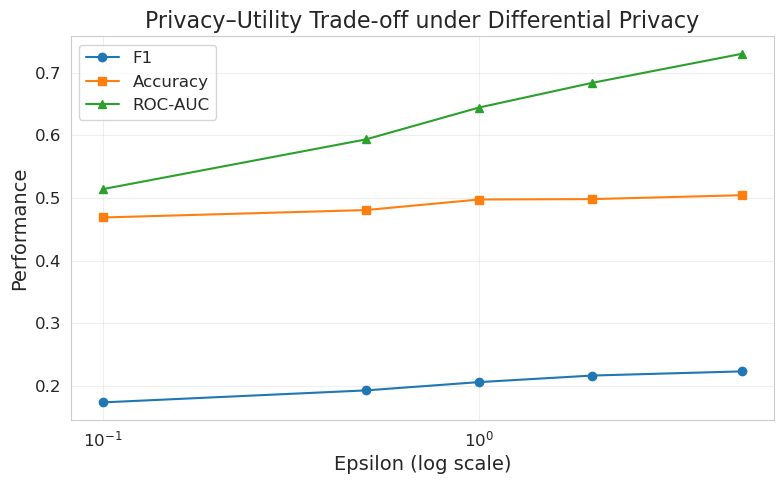

Saved plot: paper_outputs_synthetic/synthetic_section_12_epsilon_vs_leakage.jpg


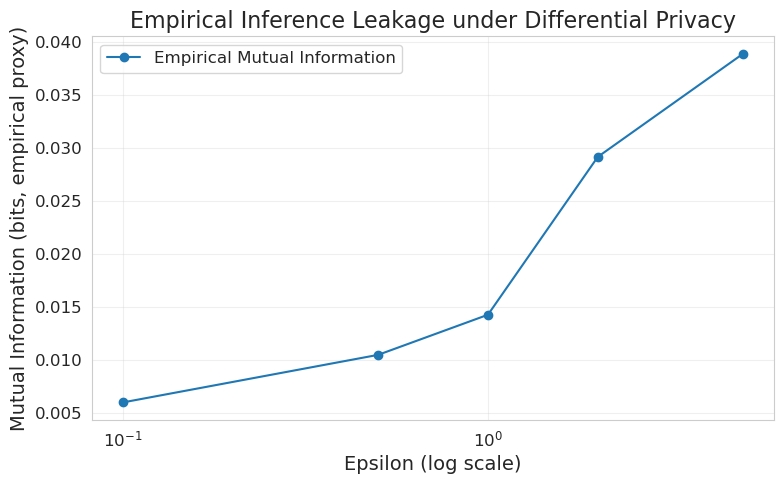

Saved plot: paper_outputs_synthetic/synthetic_section_12_epsilon_vs_detection_auc.jpg


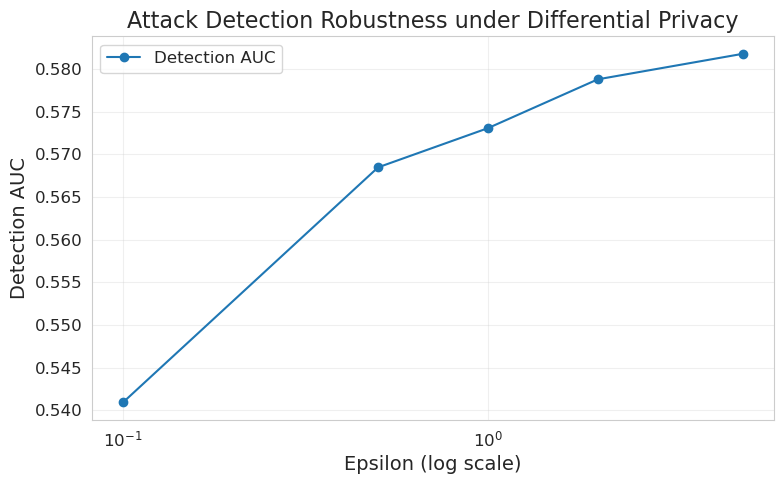

Saved plot: paper_outputs_synthetic/synthetic_section_12_core_detectors_vs_epsilon.jpg


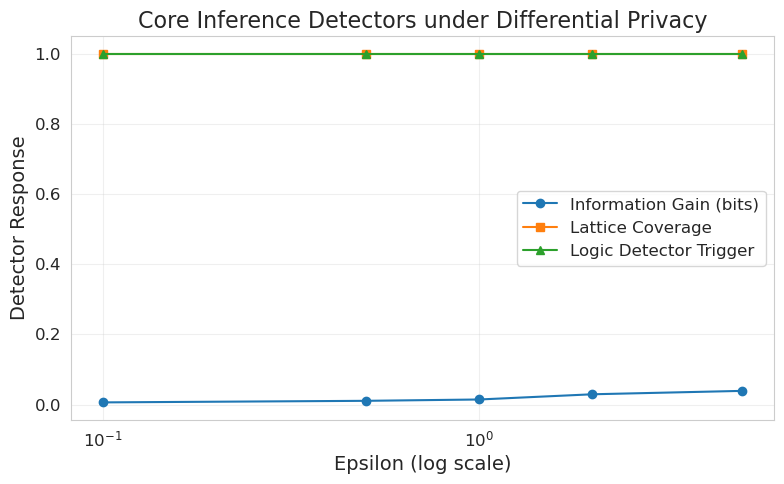


=== Validation DP Accountant History ===
                            Stage  Epsilon_Spent  Cumulative_Epsilon
0  carried_from_previous_sections        2.09999             2.09999
1               epsilon_sweep_0.1        0.10000             2.19999
2               epsilon_sweep_0.5        0.50000             2.69999
3               epsilon_sweep_1.0        1.00000             3.69999
4               epsilon_sweep_2.0        2.00000             5.69999
5               epsilon_sweep_5.0        5.00000            10.69999
Saved table: paper_outputs_synthetic/synthetic_section_12_validation_dp_history.jpg
 Saved LaTeX tables:
 - paper_outputs_jpg/section_12_baseline_hybrid_validation.tex
 - paper_outputs_jpg/section_12_epsilon_sweep_results.tex
 - paper_outputs_jpg/section_12_core_detector_validation.tex


In [56]:
# ==========================================================
# 12) INFORMATION-THEORETIC + PRIVACY VALIDATION
#      (CRF-PROBABILITY-AUGMENTED HYBRID IADPS)
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

os.makedirs("paper_outputs_jpg", exist_ok=True)

# ==========================================================
# 12A) RESTORE FINAL AUGMENTED HYBRID + CRF STATE
# ==========================================================
required_restore_vars = [
    "tab_model_final",
    "X_test_tab_final",
    "y_test_tab_enc_final",
    "final_crf_for_validation"
]

missing_restore_vars = [v for v in required_restore_vars if v not in globals()]

if missing_restore_vars:
    raise NameError(f"❌ Section 12 missing frozen variables: {missing_restore_vars}")

# Restore hybrid
tab_model = tab_model_final
X_test_tab = X_test_tab_final.copy()
y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

if "X_train_tab_final" in globals():
    X_train_tab = X_train_tab_final.copy()

if "y_train_tab_enc_final" in globals():
    y_train_tab_enc = np.array(y_train_tab_enc_final).copy()

if "label_encoder_hybrid" in globals():
    le = label_encoder_hybrid

if "tab_model_name_final" in globals():
    tab_model_name = tab_model_name_final
else:
    tab_model_name = "Hybrid"

# Restore CRF + sequence objects
final_crf = final_crf_for_validation

if "X_test_final_for_validation" in globals():
    X_test = X_test_final_for_validation

if "y_test_final_for_validation" in globals():
    y_test = y_test_final_for_validation

if "X_train_final_for_validation" in globals():
    X_train = X_train_final_for_validation

if "y_train_final_for_validation" in globals():
    y_train = y_train_final_for_validation

# Optional cached predictions
if "y_pred_tab_enc_final" in globals():
    y_pred_hybrid = np.array(y_pred_tab_enc_final).copy()
else:
    y_pred_hybrid = tab_model.predict(X_test_tab)

if "y_prob_tab_final" in globals() and y_prob_tab_final is not None:
    y_prob_hybrid = np.array(y_prob_tab_final).copy()
else:
    if hasattr(tab_model, "predict_proba"):
        y_prob_hybrid = tab_model.predict_proba(X_test_tab)
    else:
        raise ValueError("❌ Hybrid model must support predict_proba for Section 12 validation.")

# Optional baseline objects for comparison sections
if "baseline_crf_final" in globals():
    baseline_crf = baseline_crf_final
elif "baseline_crf" in globals():
    baseline_crf = baseline_crf

if "X_test_base_final" in globals():
    X_test_base = X_test_base_final

if "y_test_base_final" in globals():
    y_test_base = y_test_base_final

# Schema check
if "hybrid_feature_columns_final" in globals():
    assert list(X_test_tab.columns) == list(hybrid_feature_columns_final), \
        "❌ Section 12 feature schema mismatch"

print("\n Section 12 using CRF-probability-augmented hybrid")
print("Model:", tab_model_name)
print("X_test_tab shape:", X_test_tab.shape)
print("Encoded classes :", len(np.unique(y_test_tab_enc)))

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def empirical_entropy(labels):
    labels = np.array(labels)
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


def empirical_conditional_entropy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    total = len(y_true)
    if total == 0:
        return 0.0

    cond_entropy = 0.0
    for pred_val in np.unique(y_pred):
        idx = (y_pred == pred_val)
        subset = y_true[idx]
        weight = len(subset) / total
        cond_entropy += weight * empirical_entropy(subset)

    return float(cond_entropy)


def empirical_mutual_information(y_true, y_pred):
    h_y = empirical_entropy(y_true)
    h_y_given_pred = empirical_conditional_entropy(y_true, y_pred)
    return max(0.0, float(h_y - h_y_given_pred))


def add_laplace_noise_to_df(X_df, epsilon=1.0, sensitivity=1.0, exclude_cols=None, seed=42):
    X_noisy = X_df.copy()
    rng = np.random.default_rng(seed)

    if exclude_cols is None:
        exclude_cols = []

    numeric_cols = X_noisy.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

    if epsilon <= 0:
        raise ValueError("❌ epsilon must be > 0")

    scale = sensitivity / epsilon

    for col in numeric_cols:
        noise = rng.laplace(0.0, scale, size=len(X_noisy))
        X_noisy[col] = X_noisy[col].astype(float) + noise

    return X_noisy


def compute_anomaly_scores_from_hybrid_probs(y_prob, extra_feature_df=None):
    """
    Practical anomaly score implementation:
    alpha_q = sigmoid(beta0 + sum beta_j phi_j(q))
    Here approximated using confidence, entropy, sequence length,
    and privilege signal statistics.
    """
    max_conf = np.max(y_prob, axis=1)
    inv_conf = 1.0 - max_conf
    pred_entropy = -np.sum(y_prob * np.log(y_prob + 1e-12), axis=1)

    if extra_feature_df is not None and "seq_len" in extra_feature_df.columns:
        seq_len_feat = extra_feature_df["seq_len"].values.astype(float)
        seq_len_feat = seq_len_feat / (np.max(seq_len_feat) + 1e-8)
    else:
        seq_len_feat = np.zeros_like(inv_conf)

    if extra_feature_df is not None and "priv_signal__abs_mean" in extra_feature_df.columns:
        priv_signal_feat = extra_feature_df["priv_signal__abs_mean"].values.astype(float)
        priv_signal_feat = priv_signal_feat / (np.max(np.abs(priv_signal_feat)) + 1e-8)
    else:
        priv_signal_feat = np.zeros_like(inv_conf)

    beta0 = -1.0
    beta1 = 2.0
    beta2 = 1.5
    beta3 = 0.5
    beta4 = 1.0

    linear = (
        beta0
        + beta1 * inv_conf
        + beta2 * pred_entropy
        + beta3 * seq_len_feat
        + beta4 * priv_signal_feat
    )

    alpha_q = 1.0 / (1.0 + np.exp(-linear))
    return alpha_q


class ValidationDPAccountant:
    def __init__(self, epsilon_budget=20.0):
        self.epsilon_budget = float(epsilon_budget)
        self.epsilon_spent = 0.0
        self.history = []

    def spend(self, epsilon, stage):
        self.epsilon_spent += float(epsilon)
        self.history.append((stage, float(epsilon), float(self.epsilon_spent)))

    def remaining(self):
        return self.epsilon_budget - self.epsilon_spent

    def summary_df(self):
        return pd.DataFrame(
            self.history,
            columns=["Stage", "Epsilon_Spent", "Cumulative_Epsilon"]
        )

# ==========================================================
# CORE INFERENCE DETECTORS
# ==========================================================
def lattice_join_test(access_sets, sensitive_target):
    joined = set()
    for s in access_sets:
        joined |= set(s)

    sensitive_target = set(sensitive_target)
    coverage = len(joined & sensitive_target) / len(sensitive_target) if len(sensitive_target) > 0 else 0.0

    return {
        "joined_set": joined,
        "coverage": float(coverage),
        "detected": bool(coverage >= 1.0)
    }


def logic_closure_detector(observable_facts, sensitive_predicates, inference_rules=None):
    observed = set(observable_facts)
    closure = set(observed)

    if inference_rules is None:
        inference_rules = {}

    changed = True
    while changed:
        changed = False
        for derived_fact, prereqs in inference_rules.items():
            prereqs = set(prereqs)
            if prereqs.issubset(closure) and derived_fact not in closure:
                closure.add(derived_fact)
                changed = True

    sensitive_predicates = set(sensitive_predicates)
    triggered = closure & sensitive_predicates

    return {
        "closure": closure,
        "triggered_sensitive_predicates": triggered,
        "detected": len(triggered) > 0
    }


def information_gain_detector(y_true, y_pred, threshold_bits=0.05):
    h_before = empirical_entropy(y_true)
    h_after = empirical_conditional_entropy(y_true, y_pred)
    info_gain = max(0.0, h_before - h_after)

    return {
        "entropy_before": float(h_before),
        "entropy_after": float(h_after),
        "info_gain_bits": float(info_gain),
        "threshold_bits": float(threshold_bits),
        "detected": bool(info_gain >= threshold_bits)
    }

# ==========================================================
# PRACTICAL PROXIES
# ==========================================================
def sequence_access_proxy(seq):
    touched = set()
    for record in seq:
        if isinstance(record, dict):
            touched.update(record.keys())
    return touched

if "X_test" in globals() and len(X_test) > 0:
    access_sets_proxy = [sequence_access_proxy(seq) for seq in X_test[:20]]
else:
    access_sets_proxy = [
        {"priv_count", "rolling_priv_mean"},
        {"priv_signal", "rolling_priv_std"},
        {"priv_count_diff", "seq_len"}
    ]

sensitive_target_proxy = {"priv_signal", "priv_count", "rolling_priv_std"}

observable_facts_proxy = set()
if isinstance(X_test_tab, pd.DataFrame):
    if "priv_signal__abs_mean" in X_test_tab.columns:
        observable_facts_proxy.add("high_priv_signal")
    if "seq_len" in X_test_tab.columns:
        observable_facts_proxy.add("long_sequence")
    if "volatility_gap__mean" in X_test_tab.columns:
        observable_facts_proxy.add("volatility_shift_detected")
    if "crf_confidence_mean" in X_test_tab.columns:
        observable_facts_proxy.add("structured_model_confidence")
    if "crf_prob_entropy_mean" in X_test_tab.columns:
        observable_facts_proxy.add("structured_model_uncertainty")

inference_rules_proxy = {
    "possible_privilege_escalation": {"high_priv_signal", "volatility_shift_detected"},
    "sensitive_behaviour_pattern": {"possible_privilege_escalation", "long_sequence"},
    "probabilistic_risk_alert": {"structured_model_confidence", "structured_model_uncertainty"}
}

sensitive_predicates_proxy = {
    "possible_privilege_escalation",
    "sensitive_behaviour_pattern",
    "probabilistic_risk_alert"
}

# ==========================================================
# STEP 1: BASELINE HYBRID VALIDATION
# ==========================================================
print("\n[CONSISTENCY CHECK]")
print("Hybrid model used in Section 12:", tab_model_name)
print("Test feature shape:", X_test_tab.shape)
print("Encoded label count:", len(np.unique(y_test_tab_enc)))

acc_hgb = accuracy_score(y_test_tab_enc, y_pred_hybrid)
prec_hgb = precision_score(y_test_tab_enc, y_pred_hybrid, average="macro", zero_division=0)
rec_hgb = recall_score(y_test_tab_enc, y_pred_hybrid, average="macro", zero_division=0)
f1_hgb = f1_score(y_test_tab_enc, y_pred_hybrid, average="macro", zero_division=0)

tab_classes = np.unique(y_test_tab_enc)
y_test_tab_bin = label_binarize(y_test_tab_enc, classes=tab_classes)

auc_hgb = roc_auc_score(
    y_test_tab_bin,
    y_prob_hybrid,
    average="macro",
    multi_class="ovr"
)

h_sensitive = empirical_entropy(y_test_tab_enc)
h_sensitive_given_pred = empirical_conditional_entropy(y_test_tab_enc, y_pred_hybrid)
mi_sensitive_pred = empirical_mutual_information(y_test_tab_enc, y_pred_hybrid)

# anomaly score aligned to hybrid
alpha_q = compute_anomaly_scores_from_hybrid_probs(
    y_prob_hybrid,
    extra_feature_df=X_test_tab if isinstance(X_test_tab, pd.DataFrame) else None
)

hybrid_attack_labels = (np.array(y_pred_hybrid) != np.array(y_test_tab_enc)).astype(int)
fpr_det_h, tpr_det_h, _ = roc_curve(hybrid_attack_labels, alpha_q)
det_auc_hgb = auc(fpr_det_h, tpr_det_h)

baseline_validation_df = pd.DataFrame([{
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb,
    "Entropy_HY": h_sensitive,
    "Cond_Entropy_HY_given_Yhat": h_sensitive_given_pred,
    "Mutual_Info_IY_Yhat": mi_sensitive_pred,
    "Detection_AUC": det_auc_hgb
}])

print("\n=== Baseline Hybrid Validation ===")
print(baseline_validation_df.T)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        baseline_validation_df.round(4),
        "section_12_baseline_hybrid_validation",
        title="Baseline Hybrid Information-Theoretic Validation"
    )

# ==========================================================
# STEP 1B: CORE DETECTOR VALIDATION
# ==========================================================
lattice_result = lattice_join_test(
    access_sets=access_sets_proxy,
    sensitive_target=sensitive_target_proxy
)

logic_result = logic_closure_detector(
    observable_facts=observable_facts_proxy,
    sensitive_predicates=sensitive_predicates_proxy,
    inference_rules=inference_rules_proxy
)

info_gain_result = information_gain_detector(
    y_true=y_test_tab_enc,
    y_pred=y_pred_hybrid,
    threshold_bits=0.05
)

print("\n=== Lattice Join Test ===")
print(lattice_result)

print("\n=== Logic-Closure Detector ===")
print(logic_result)

print("\n=== Information-Gain Detector ===")
print(info_gain_result)

detector_summary_df = pd.DataFrame([{
    "Lattice_Coverage": lattice_result["coverage"],
    "Lattice_Detected": lattice_result["detected"],
    "Logic_Detected": logic_result["detected"],
    "Logic_Triggered": ", ".join(sorted(logic_result["triggered_sensitive_predicates"])) if len(logic_result["triggered_sensitive_predicates"]) > 0 else "None",
    "Entropy_Before": info_gain_result["entropy_before"],
    "Entropy_After": info_gain_result["entropy_after"],
    "Info_Gain_Bits": info_gain_result["info_gain_bits"],
    "Info_Gain_Detected": info_gain_result["detected"]
}])

print("\n=== Core Detector Validation Summary ===")
print(detector_summary_df.T)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        detector_summary_df.round(4),
        "section_12_core_detector_validation",
        title="Core Inference Detector Validation"
    )

# ==========================================================
# STEP 2: EPSILON SWEEP (HYBRID UTILITY)
# ==========================================================
epsilon_values = [0.1, 0.5, 1.0, 2.0, 5.0]

base_epsilon_spent = 0.0
if "dp_accountant" in globals() and hasattr(dp_accountant, "epsilon_spent"):
    base_epsilon_spent = float(dp_accountant.epsilon_spent)

validation_accountant = ValidationDPAccountant(epsilon_budget=20.0)
validation_accountant.epsilon_spent = base_epsilon_spent

if base_epsilon_spent > 0:
    validation_accountant.history.append(
        ("carried_from_previous_sections", base_epsilon_spent, base_epsilon_spent)
    )

epsilon_results = []

for eps in epsilon_values:
    print(f"\n=== ε Sweep: epsilon = {eps} ===")
    validation_accountant.spend(eps, stage=f"epsilon_sweep_{eps}")

    X_noisy = add_laplace_noise_to_df(
        X_test_tab,
        epsilon=eps,
        sensitivity=1.0,
        exclude_cols=[],
        seed=42
    )

    y_pred_eps = tab_model.predict(X_noisy)
    y_prob_eps = tab_model.predict_proba(X_noisy)

    acc_eps = accuracy_score(y_test_tab_enc, y_pred_eps)
    prec_eps = precision_score(y_test_tab_enc, y_pred_eps, average="macro", zero_division=0)
    rec_eps = recall_score(y_test_tab_enc, y_pred_eps, average="macro", zero_division=0)
    f1_eps = f1_score(y_test_tab_enc, y_pred_eps, average="macro", zero_division=0)

    auc_eps = roc_auc_score(
        y_test_tab_bin,
        y_prob_eps,
        average="macro",
        multi_class="ovr"
    )

    h_y = empirical_entropy(y_test_tab_enc)
    h_y_given_pred_eps = empirical_conditional_entropy(y_test_tab_enc, y_pred_eps)
    mi_eps = empirical_mutual_information(y_test_tab_enc, y_pred_eps)

    alpha_eps = compute_anomaly_scores_from_hybrid_probs(
        y_prob_eps,
        extra_feature_df=X_noisy if isinstance(X_noisy, pd.DataFrame) else None
    )

    attack_labels_eps = (np.array(y_pred_eps) != np.array(y_test_tab_enc)).astype(int)
    fpr_eps_det, tpr_eps_det, _ = roc_curve(attack_labels_eps, alpha_eps)
    det_auc_eps = auc(fpr_eps_det, tpr_eps_det)

    lattice_result_eps = lattice_join_test(
        access_sets=access_sets_proxy,
        sensitive_target=sensitive_target_proxy
    )

    logic_result_eps = logic_closure_detector(
        observable_facts=observable_facts_proxy,
        sensitive_predicates=sensitive_predicates_proxy,
        inference_rules=inference_rules_proxy
    )

    info_gain_result_eps = information_gain_detector(
        y_true=y_test_tab_enc,
        y_pred=y_pred_eps,
        threshold_bits=0.05
    )

    epsilon_results.append({
        "epsilon": eps,
        "Accuracy": acc_eps,
        "Precision": prec_eps,
        "Recall": rec_eps,
        "F1": f1_eps,
        "ROC_AUC": auc_eps,
        "Entropy_HY": h_y,
        "Cond_Entropy_HY_given_Yhat": h_y_given_pred_eps,
        "Mutual_Info_IY_Yhat": mi_eps,
        "Detection_AUC": det_auc_eps,
        "Lattice_Coverage": lattice_result_eps["coverage"],
        "Lattice_Detected": lattice_result_eps["detected"],
        "Logic_Detected": logic_result_eps["detected"],
        "Info_Gain_Bits": info_gain_result_eps["info_gain_bits"],
        "Info_Gain_Detected": info_gain_result_eps["detected"],
        "Cumulative_Epsilon": validation_accountant.epsilon_spent
    })

epsilon_results_df = pd.DataFrame(epsilon_results)

print("\n=== Epsilon Sweep Results ===")
print(epsilon_results_df.round(4))

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        epsilon_results_df.round(4),
        "section_12_epsilon_sweep_results",
        title="Privacy–Utility Trade-off under Epsilon Sweep",
        fontsize=8
    )

# ==========================================================
# STEP 3: PLOTS
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(epsilon_results_df["epsilon"], epsilon_results_df["F1"], marker="o", label="F1")
plt.plot(epsilon_results_df["epsilon"], epsilon_results_df["Accuracy"], marker="s", label="Accuracy")
plt.plot(epsilon_results_df["epsilon"], epsilon_results_df["ROC_AUC"], marker="^", label="ROC-AUC")
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Performance")
plt.title("Privacy–Utility Trade-off under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_privacy_utility_tradeoff")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Mutual_Info_IY_Yhat"],
    marker="o",
    label="Empirical Mutual Information"
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Mutual Information (bits, empirical proxy)")
plt.title("Empirical Inference Leakage under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_epsilon_vs_leakage")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Detection_AUC"],
    marker="o",
    label="Detection AUC"
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Detection AUC")
plt.title("Attack Detection Robustness under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_epsilon_vs_detection_auc")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Info_Gain_Bits"],
    marker="o",
    label="Information Gain (bits)"
)
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Lattice_Coverage"],
    marker="s",
    label="Lattice Coverage"
)
logic_detect_numeric = epsilon_results_df["Logic_Detected"].astype(float)
plt.plot(
    epsilon_results_df["epsilon"],
    logic_detect_numeric,
    marker="^",
    label="Logic Detector Trigger"
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Detector Response")
plt.title("Core Inference Detectors under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_core_detectors_vs_epsilon")
plt.show()

# ==========================================================
# STEP 4: DP HISTORY
# ==========================================================
validation_dp_history_df = validation_accountant.summary_df()

print("\n=== Validation DP Accountant History ===")
print(validation_dp_history_df)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        validation_dp_history_df.round(4),
        "section_12_validation_dp_history",
        title="Validation Privacy Budget History"
    )

# ==========================================================
# STEP 5: LATEX EXPORTS
# ==========================================================
baseline_validation_latex = baseline_validation_df.round(4).to_latex(
    index=False,
    escape=False,
    caption="Baseline information-theoretic and privacy-aware validation of the CRF-probability-augmented hybrid IADPS model.",
    label="tab:baseline_hybrid_validation"
)

with open("paper_outputs_jpg/section_12_baseline_hybrid_validation.tex", "w") as f:
    f.write(baseline_validation_latex)

epsilon_sweep_latex = epsilon_results_df.round(4).to_latex(
    index=False,
    escape=False,
    caption="Privacy--utility evaluation of the CRF-probability-augmented hybrid IADPS under varying differential privacy budgets.",
    label="tab:epsilon_sweep_results"
)

with open("paper_outputs_jpg/section_12_epsilon_sweep_results.tex", "w") as f:
    f.write(epsilon_sweep_latex)

detector_validation_latex = detector_summary_df.round(4).to_latex(
    index=False,
    escape=False,
    caption="Validation of the core inference detectors in the CRF-probability-augmented hybrid IADPS.",
    label="tab:core_detector_validation"
)

with open("paper_outputs_jpg/section_12_core_detector_validation.tex", "w") as f:
    f.write(detector_validation_latex)

print(" Saved LaTeX tables:")
print(" - paper_outputs_jpg/section_12_baseline_hybrid_validation.tex")
print(" - paper_outputs_jpg/section_12_epsilon_sweep_results.tex")
print(" - paper_outputs_jpg/section_12_core_detector_validation.tex")

In [57]:
 # ==========================================================
# 13) BiLSTM + CRF COMPARISON MODEL
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

In [58]:
 # ----------------------------------------------------------
# STEP 1: FEATURE KEY EXTRACTION
# ----------------------------------------------------------
assert len(X_train) > 0 and len(X_train[0]) > 0, "❌ X_train is empty"

feature_keys = sorted(list(X_train[0][0].keys()))
input_dim = len(feature_keys)

print("BiLSTM input_dim:", input_dim)

BiLSTM input_dim: 19


In [59]:
# ----------------------------------------------------------
# STEP 2: LABEL ENCODING
# ----------------------------------------------------------
all_train_labels = [lab for seq in y_train for lab in seq]

bilstm_label_encoder = LabelEncoder()
bilstm_label_encoder.fit(all_train_labels)

num_labels = len(bilstm_label_encoder.classes_)
print("BiLSTM label count:", num_labels)
print("Label space:", list(bilstm_label_encoder.classes_))

BiLSTM label count: 5
Label space: [np.str_('Create_Grant'), np.str_('Delete'), np.str_('Modify'), np.str_('Other'), np.str_('View')]


In [60]:
# ----------------------------------------------------------
# STEP 3: SEQUENCE CONVERSION HELPERS
# ----------------------------------------------------------
def seq_dicts_to_tensor(seq, feature_keys):
    rows = []
    for token in seq:
        row = []
        for key in feature_keys:
            val = token.get(key, 0.0)
            try:
                row.append(float(val))
            except Exception:
                row.append(0.0)
        rows.append(row)
    return torch.tensor(rows, dtype=torch.float32)


def seq_labels_to_tensor(seq_labels, label_encoder):
    encoded = label_encoder.transform(seq_labels)
    return torch.tensor(encoded, dtype=torch.long)


def prepare_bilstm_data(X_seq, y_seq, feature_keys, label_encoder):
    X_tensors = [seq_dicts_to_tensor(seq, feature_keys) for seq in X_seq]
    y_tensors = [seq_labels_to_tensor(seq, label_encoder) for seq in y_seq]

    X_pad = pad_sequence(X_tensors, batch_first=True, padding_value=0.0)
    y_pad = pad_sequence(y_tensors, batch_first=True, padding_value=-1)

    mask = (y_pad != -1)

    return X_pad, y_pad, mask

In [61]:
# ----------------------------------------------------------
# STEP 4: PREPARE TRAIN / TEST TENSORS
# ----------------------------------------------------------
X_train_pad, y_train_pad, mask_train = prepare_bilstm_data(
    X_train, y_train, feature_keys, bilstm_label_encoder
)

X_test_pad, y_test_pad, mask_test = prepare_bilstm_data(
    X_test, y_test, feature_keys, bilstm_label_encoder
)

print("Train tensor shape:", X_train_pad.shape)
print("Test tensor shape :", X_test_pad.shape)

Train tensor shape: torch.Size([6400, 5, 19])
Test tensor shape : torch.Size([1600, 5, 19])


In [62]:
# ==========================================================
# BiLSTM MODEL DEFINITION + INITIALIZATION (FIXED)
# ==========================================================

import torch
import torch.nn as nn

# ----------------------------------------------------------
# DEFINE BiLSTM MODEL
# ----------------------------------------------------------
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim // 2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim, num_labels)

    def forward(self, x):
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits


# ----------------------------------------------------------
# CREATE MODEL (THIS WAS MISSING ❗)
# ----------------------------------------------------------
bilstm_model = BiLSTM(input_dim, 128, num_labels)

print("BiLSTM model initialized.")

BiLSTM model initialized.


In [63]:
# ----------------------------------------------------------
# DEVICE SETUP (CPU / GPU)
# ----------------------------------------------------------
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------------------------------------
# MOVE ONLY THE PYTORCH MODEL TO DEVICE
# ----------------------------------------------------------
bilstm_model = bilstm_model.to(device)

X_train_pad = X_train_pad.to(device)
y_train_pad = y_train_pad.to(device)
mask_train = mask_train.to(device)

X_test_pad = X_test_pad.to(device)
y_test_pad = y_test_pad.to(device)
mask_test = mask_test.to(device)

# ----------------------------------------------------------
# LOSS + OPTIMIZER
# ----------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)

# ----------------------------------------------------------
# TRAINING LOOP
# ----------------------------------------------------------
epochs = 10

for epoch in range(epochs):
    bilstm_model.train()

    logits = bilstm_model(X_train_pad)
    logits = logits.view(-1, num_labels)
    targets = y_train_pad.view(-1)

    loss = criterion(logits, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}: Loss={loss.item():.4f}")

Using device: cpu
Epoch 1: Loss=1.5375
Epoch 2: Loss=1.4918
Epoch 3: Loss=1.4483
Epoch 4: Loss=1.4069
Epoch 5: Loss=1.3675
Epoch 6: Loss=1.3301
Epoch 7: Loss=1.2946
Epoch 8: Loss=1.2612
Epoch 9: Loss=1.2299
Epoch 10: Loss=1.2007


In [64]:
 # ----------------------------------------------------------
# LOSS + OPTIMIZER
# ----------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)

# ----------------------------------------------------------
# TRAINING LOOP
# ----------------------------------------------------------
epochs = 10

for epoch in range(epochs):
    bilstm_model.train()

    logits = bilstm_model(X_train_pad)
    logits = logits.view(-1, num_labels)
    targets = y_train_pad.view(-1)

    loss = criterion(logits, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}: Loss={loss.item():.4f}")

Epoch 1: Loss=1.1737
Epoch 2: Loss=1.1471
Epoch 3: Loss=1.1229
Epoch 4: Loss=1.1014
Epoch 5: Loss=1.0824
Epoch 6: Loss=1.0660
Epoch 7: Loss=1.0521
Epoch 8: Loss=1.0403
Epoch 9: Loss=1.0305
Epoch 10: Loss=1.0224


In [65]:
# ----------------------------------------------------------
# STEP 7: EVALUATION
# ----------------------------------------------------------
bilstm_model.eval()

with torch.no_grad():
    logits = bilstm_model(X_test_pad)
    probs = torch.softmax(logits, dim=-1).cpu().numpy()

# Flatten predictions
y_pred_bilstm = np.argmax(probs, axis=-1)

y_pred_bilstm_flat = []
y_test_bilstm_flat = []

for i in range(y_test_pad.shape[0]):
    valid = mask_test[i].cpu().numpy().astype(bool)

    y_true_seq = y_test_pad[i].cpu().numpy()[valid]
    y_pred_seq = y_pred_bilstm[i][valid]

    y_test_bilstm_flat.extend(y_true_seq.tolist())
    y_pred_bilstm_flat.extend(y_pred_seq.tolist())

# ----------------------------------------------------------
# METRICS
# ----------------------------------------------------------
acc_bilstm = accuracy_score(y_test_bilstm_flat, y_pred_bilstm_flat)
prec_bilstm = precision_score(y_test_bilstm_flat, y_pred_bilstm_flat, average="macro", zero_division=0)
rec_bilstm = recall_score(y_test_bilstm_flat, y_pred_bilstm_flat, average="macro", zero_division=0)
f1_bilstm = f1_score(y_test_bilstm_flat, y_pred_bilstm_flat, average="macro", zero_division=0)

print("\n=== BiLSTM Performance ===")
print(f"Accuracy : {acc_bilstm:.4f}")
print(f"Precision: {prec_bilstm:.4f}")
print(f"Recall   : {rec_bilstm:.4f}")
print(f"F1 Score : {f1_bilstm:.4f}")


=== BiLSTM Performance ===
Accuracy : 0.5320
Precision: 0.1943
Recall   : 0.2212
F1 Score : 0.1941


In [66]:
# ----------------------------------------------------------
# STEP 8: ROC-AUC
# ----------------------------------------------------------
y_prob_bilstm = []

for i in range(probs.shape[0]):
    valid = mask_test[i].cpu().numpy().astype(bool)
    y_prob_bilstm.extend(probs[i][valid].tolist())

y_prob_bilstm = np.array(y_prob_bilstm)

classes_bilstm = np.arange(num_labels)
y_test_bin_bilstm = label_binarize(y_test_bilstm_flat, classes=classes_bilstm)

try:
    auc_bilstm = roc_auc_score(
        y_test_bin_bilstm,
        y_prob_bilstm,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC-AUC : {auc_bilstm:.4f}")
except Exception as e:
    auc_bilstm = np.nan
    print("ROC-AUC skipped:", e)

ROC-AUC : 0.7187


In [67]:
# ----------------------------------------------------------
# STEP 9: SAVE SUMMARY
# ----------------------------------------------------------
bilstm_results_df = pd.DataFrame([{
    "Model": "BiLSTM",
    "Accuracy": acc_bilstm,
    "Precision": prec_bilstm,
    "Recall": rec_bilstm,
    "F1": f1_bilstm,
    "ROC_AUC": auc_bilstm
}])

print("\nBiLSTM Results Summary:")
print(bilstm_results_df)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        bilstm_results_df.round(4),
        "section_13_bilstm_results_summary",
        title="BiLSTM Results Summary"
    )


BiLSTM Results Summary:
    Model  Accuracy  Precision    Recall       F1   ROC_AUC
0  BiLSTM     0.532   0.194314  0.221155  0.19414  0.718682
Saved table: paper_outputs_synthetic/synthetic_section_13_bilstm_results_summary.jpg


 Saving BiLSTM-hybrid outputs to: paper_outputs_bilstm_hybrid
 BiLSTM-informed hybrid feature count: 46

=== BiLSTM-Informed Hybrid Performance ===
Accuracy : 0.9038
Precision: 0.9475
Recall   : 0.8898
F1 Score : 0.9168
ROC-AUC  : 0.9863

=== Hybrid Comparison Summary ===
                                               Model  Accuracy  Precision  \
0  HistGradientBoosting (CRF-probability-augmente...   0.93000   0.966116   
1                             BiLSTM-informed hybrid   0.90375   0.947503   

     Recall        F1   ROC_AUC  
0  0.890414  0.924965  0.993694  
1  0.889819  0.916766  0.986297  
Saved CSV: paper_outputs_bilstm_hybrid/bilstm_informed_hybrid_comparison.csv
Saved JPG table: paper_outputs_bilstm_hybrid/bilstm_informed_hybrid_comparison.jpg

LaTeX Table:

\begin{table}
\caption{Comparison between the CRF-probability-augmented hybrid and the BiLSTM-informed hybrid.}
\label{tab:bilstm_informed_hybrid_comparison}
\begin{tabular}{llllll}
\toprule
Model & Accuracy & Precisio

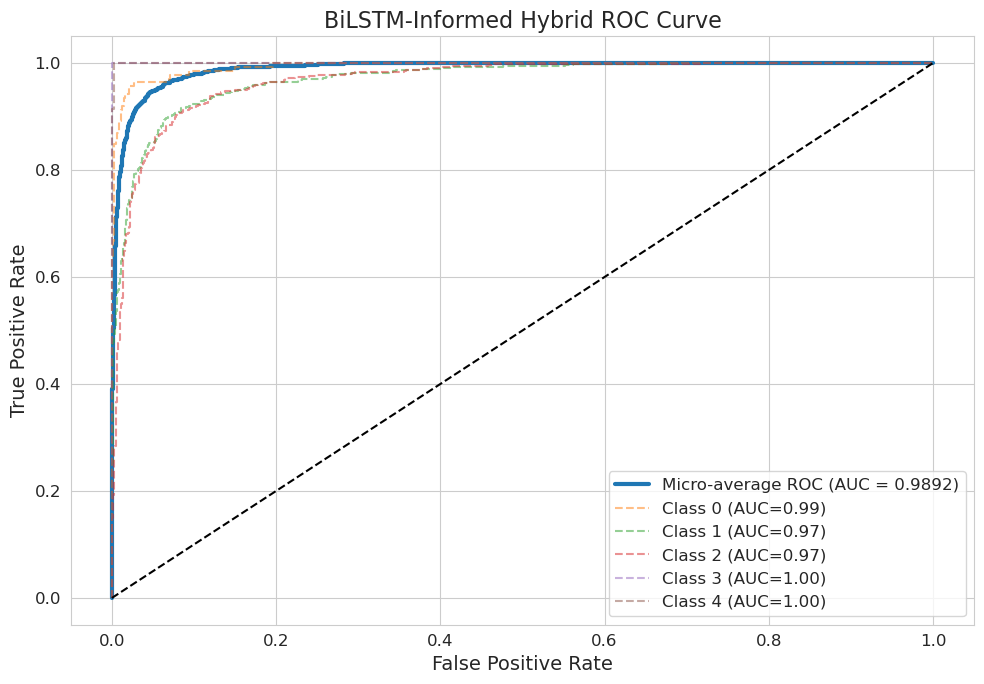

Saved plot: paper_outputs_bilstm_hybrid/bilstm_informed_hybrid_attack_detection_roc.png


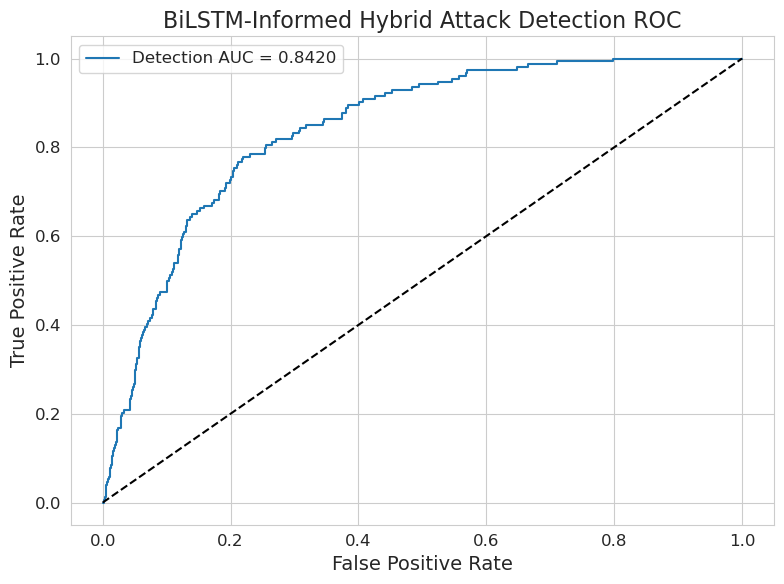

Saved CSV: paper_outputs_bilstm_hybrid/bilstm_informed_hybrid_attack_detection.csv
Saved JPG table: paper_outputs_bilstm_hybrid/bilstm_informed_hybrid_attack_detection.jpg
Saved CSV: paper_outputs_bilstm_hybrid/bilstm_informed_hybrid_feature_inventory.csv

 Section 14 complete.
Outputs saved in: paper_outputs_bilstm_hybrid


In [68]:
# ==========================================================
# 14) BiLSTM-INFORMED HYBRID COMPARISON
#     (SEPARATE PAPER OUTPUT FOLDER)
#     FIXED SAVING VERSION
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize, LabelEncoder

# ----------------------------------------------------------
# OUTPUT FOLDER (SEPARATE FOR EASY PAPER USE)
# ----------------------------------------------------------
BILSTM_HYBRID_OUTDIR = "paper_outputs_bilstm_hybrid"
os.makedirs(BILSTM_HYBRID_OUTDIR, exist_ok=True)

print(f" Saving BiLSTM-hybrid outputs to: {BILSTM_HYBRID_OUTDIR}")

# ==========================================================
# SAFETY CHECKS
# ==========================================================
required_vars = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "bilstm_model",
    "feature_keys",
    "num_labels",
    "tab_model_name",
    "acc_hgb",
    "prec_hgb",
    "rec_hgb",
    "f1_hgb",
    "auc_hgb",
    "device"
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"❌ Missing required variables for Section 14: {missing_vars}")

# ==========================================================
# LOCAL SAVE HELPERS (NO COLLISION WITH paper_outputs_jpg)
# ==========================================================
def save_df_local(df, filename):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved CSV: {path}")

def save_latex_local(text, filename):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, filename)
    with open(path, "w") as f:
        f.write(text)
    print(f"Saved LaTeX: {path}")

def save_plot_local(filename, dpi=300):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved plot: {path}")

def save_dataframe_as_jpg_local(df, filename, title="Table", dpi=300, fontsize=10):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, f"{filename}.jpg")

    fig, ax = plt.subplots(
        figsize=(max(8, len(df.columns) * 1.5), max(2.5, len(df) * 0.55 + 1))
    )
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize + 2, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    plt.tight_layout()
    plt.savefig(path, format="jpg", dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved JPG table: {path}")

# ==========================================================
# HELPER: SAME SEQUENCE SUMMARY FUNCTION AS CURRENT HYBRID
# ==========================================================
def summarize_sequence_for_bilstm_hybrid(seq):
    def safe_array(values):
        vals = []
        for v in values:
            try:
                vals.append(float(v))
            except Exception:
                continue
        return np.array(vals, dtype=float) if len(vals) > 0 else np.array([0.0], dtype=float)

    priv_count = safe_array([f.get("priv_count", 0) for f in seq])
    priv_diff = safe_array([f.get("priv_count_diff", 0) for f in seq])
    priv_signal = safe_array([f.get("priv_signal", 0) for f in seq])
    rolling_mean = safe_array([f.get("rolling_priv_mean", 0) for f in seq])
    rolling_std = safe_array([f.get("rolling_priv_std", 0) for f in seq])

    prev_priv_count = safe_array([f.get("prev_priv_count", 0) for f in seq])
    next_priv_count = safe_array([f.get("next_priv_count", 0) for f in seq])
    priv_acceleration = safe_array([f.get("priv_acceleration", 0) for f in seq])
    position_weight = safe_array([f.get("position_weight", 0) for f in seq])

    return {
        "seq_len": len(seq),

        "priv_count__mean": float(np.mean(priv_count)),
        "priv_count__std": float(np.std(priv_count)),
        "priv_count__max": float(np.max(priv_count)),
        "priv_count__min": float(np.min(priv_count)),
        "priv_count__last": float(priv_count[-1]),
        "priv_count__first": float(priv_count[0]),

        "priv_diff__mean": float(np.mean(priv_diff)),
        "priv_diff__std": float(np.std(priv_diff)),
        "priv_diff__max": float(np.max(priv_diff)),
        "priv_diff__min": float(np.min(priv_diff)),
        "priv_diff__abs_mean": float(np.mean(np.abs(priv_diff))),

        "priv_signal__mean": float(np.mean(priv_signal)),
        "priv_signal__std": float(np.std(priv_signal)),
        "priv_signal__max": float(np.max(priv_signal)),
        "priv_signal__min": float(np.min(priv_signal)),
        "priv_signal__abs_mean": float(np.mean(np.abs(priv_signal))),
        "priv_signal__energy": float(np.sum(priv_signal ** 2)),

        "rolling_mean__mean": float(np.mean(rolling_mean)),
        "rolling_mean__std": float(np.std(rolling_mean)),
        "rolling_std__mean": float(np.mean(rolling_std)),
        "rolling_std__max": float(np.max(rolling_std)),

        "prev_priv_count__mean": float(np.mean(prev_priv_count)),
        "next_priv_count__mean": float(np.mean(next_priv_count)),
        "priv_acceleration__mean": float(np.mean(priv_acceleration)),
        "priv_acceleration__std": float(np.std(priv_acceleration)),

        "position_weight__mean": float(np.mean(position_weight)),
        "position_weight__last": float(position_weight[-1]),

        "trend_slope": float((priv_count[-1] - priv_count[0]) / max(len(priv_count) - 1, 1)),
        "volatility_gap__mean": float(np.mean(np.abs(rolling_std - np.mean(rolling_std)))),
        "priv_count__range": float(np.max(priv_count) - np.min(priv_count)),
        "priv_signal__range": float(np.max(priv_signal) - np.min(priv_signal)),
    }

# ==========================================================
# HELPER: BUILD PADDED TENSORS FOR ARBITRARY SEQUENCES
# ==========================================================
def seq_dicts_to_tensor_local(seq, feature_keys):
    rows = []
    for token in seq:
        row = []
        for key in feature_keys:
            val = token.get(key, 0.0)
            try:
                row.append(float(val))
            except Exception:
                row.append(0.0)
        rows.append(row)
    return torch.tensor(rows, dtype=torch.float32)

def prepare_bilstm_inputs_only(X_seq, feature_keys):
    tensors = [seq_dicts_to_tensor_local(seq, feature_keys) for seq in X_seq]
    X_pad = pad_sequence(tensors, batch_first=True, padding_value=0.0)
    lengths = [len(seq) for seq in X_seq]
    return X_pad, lengths

# ==========================================================
# HELPER: EXTRACT BiLSTM PROBABILITY FEATURES
# ==========================================================
def extract_bilstm_features(model, X_seq, feature_keys, num_labels, device):
    model.eval()

    X_pad, lengths = prepare_bilstm_inputs_only(X_seq, feature_keys)
    X_pad = X_pad.to(device)

    with torch.no_grad():
        logits = model(X_pad)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

    feature_rows = []

    for i in range(probs.shape[0]):
        seq_len = lengths[i]
        seq_probs = probs[i][:seq_len]

        flat_probs = seq_probs.reshape(-1)
        max_probs = np.max(seq_probs, axis=1)
        entropies = -np.sum(seq_probs * np.log(seq_probs + 1e-12), axis=1)

        row = {
            "bilstm_prob_mean": float(np.mean(flat_probs)),
            "bilstm_prob_std": float(np.std(flat_probs)),
            "bilstm_prob_max": float(np.max(flat_probs)),
            "bilstm_prob_min": float(np.min(flat_probs)),
            "bilstm_prob_entropy_mean": float(np.mean(entropies)),
            "bilstm_prob_entropy_max": float(np.max(entropies)),
            "bilstm_confidence_mean": float(np.mean(max_probs)),
            "bilstm_confidence_min": float(np.min(max_probs)),
            "bilstm_confidence_std": float(np.std(max_probs)),
        }

        for cls_idx in range(num_labels):
            row[f"bilstm_mean_prob__class_{cls_idx}"] = float(np.mean(seq_probs[:, cls_idx]))

        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

# ==========================================================
# STEP 1: TARGETS
# ==========================================================
def sequence_target(seq_labels):
    return seq_labels[-1]

y_train_bilstm_hybrid = [sequence_target(seq) for seq in y_train]
y_test_bilstm_hybrid  = [sequence_target(seq) for seq in y_test]

bilstm_hybrid_le = LabelEncoder()
y_train_bilstm_hybrid_enc = bilstm_hybrid_le.fit_transform(y_train_bilstm_hybrid)
y_test_bilstm_hybrid_enc  = bilstm_hybrid_le.transform(y_test_bilstm_hybrid)

# ==========================================================
# STEP 2: BASE TABULAR FEATURES
# ==========================================================
X_train_bilstm_hybrid = pd.DataFrame(
    [summarize_sequence_for_bilstm_hybrid(seq) for seq in X_train]
).fillna(0)

X_test_bilstm_hybrid = pd.DataFrame(
    [summarize_sequence_for_bilstm_hybrid(seq) for seq in X_test]
).fillna(0)

X_test_bilstm_hybrid = X_test_bilstm_hybrid.reindex(
    columns=X_train_bilstm_hybrid.columns,
    fill_value=0
)

# ==========================================================
# STEP 3: BiLSTM PROBABILITY FEATURES
# ==========================================================
bilstm_train_feats = extract_bilstm_features(
    bilstm_model, X_train, feature_keys, num_labels, device
)

bilstm_test_feats = extract_bilstm_features(
    bilstm_model, X_test, feature_keys, num_labels, device
)

X_train_bilstm_hybrid = pd.concat(
    [X_train_bilstm_hybrid.reset_index(drop=True), bilstm_train_feats.reset_index(drop=True)],
    axis=1
)

X_test_bilstm_hybrid = pd.concat(
    [X_test_bilstm_hybrid.reset_index(drop=True), bilstm_test_feats.reset_index(drop=True)],
    axis=1
)

print(" BiLSTM-informed hybrid feature count:", X_train_bilstm_hybrid.shape[1])

# ==========================================================
# STEP 4: TRAIN BiLSTM-INFORMED HYBRID
# ==========================================================
bilstm_hybrid_model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.03,
    max_depth=8,
    random_state=42
)

bilstm_hybrid_model.fit(X_train_bilstm_hybrid, y_train_bilstm_hybrid_enc)

# ==========================================================
# STEP 5: PREDICTIONS + METRICS
# ==========================================================
y_pred_bilstm_hybrid_enc = bilstm_hybrid_model.predict(X_test_bilstm_hybrid)
y_prob_bilstm_hybrid = bilstm_hybrid_model.predict_proba(X_test_bilstm_hybrid)

acc_bilstm_hybrid = accuracy_score(y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc)
prec_bilstm_hybrid = precision_score(
    y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc,
    average="macro", zero_division=0
)
rec_bilstm_hybrid = recall_score(
    y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc,
    average="macro", zero_division=0
)
f1_bilstm_hybrid = f1_score(
    y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc,
    average="macro", zero_division=0
)

classes_bilstm_hybrid = np.unique(y_test_bilstm_hybrid_enc)
y_test_bin_bilstm_hybrid = label_binarize(
    y_test_bilstm_hybrid_enc,
    classes=classes_bilstm_hybrid
)

auc_bilstm_hybrid = roc_auc_score(
    y_test_bin_bilstm_hybrid,
    y_prob_bilstm_hybrid,
    average="macro",
    multi_class="ovr"
)

print("\n=== BiLSTM-Informed Hybrid Performance ===")
print(f"Accuracy : {acc_bilstm_hybrid:.4f}")
print(f"Precision: {prec_bilstm_hybrid:.4f}")
print(f"Recall   : {rec_bilstm_hybrid:.4f}")
print(f"F1 Score : {f1_bilstm_hybrid:.4f}")
print(f"ROC-AUC  : {auc_bilstm_hybrid:.4f}")

# ==========================================================
# STEP 6: COMPARISON TABLE
# ==========================================================
comparison_df = pd.DataFrame([
    {
        "Model": f"{tab_model_name} (CRF-probability-augmented hybrid)",
        "Accuracy": acc_hgb,
        "Precision": prec_hgb,
        "Recall": rec_hgb,
        "F1": f1_hgb,
        "ROC_AUC": auc_hgb
    },
    {
        "Model": "BiLSTM-informed hybrid",
        "Accuracy": acc_bilstm_hybrid,
        "Precision": prec_bilstm_hybrid,
        "Recall": rec_bilstm_hybrid,
        "F1": f1_bilstm_hybrid,
        "ROC_AUC": auc_bilstm_hybrid
    }
])

print("\n=== Hybrid Comparison Summary ===")
print(comparison_df)

save_df_local(comparison_df.round(6), "bilstm_informed_hybrid_comparison.csv")
save_dataframe_as_jpg_local(
    comparison_df.round(4),
    "bilstm_informed_hybrid_comparison",
    title="Hybrid Comparison Summary"
)

# ==========================================================
# STEP 7: LATEX EXPORT
# ==========================================================
latex_cmp_df = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    latex_cmp_df[col] = latex_cmp_df[col].map(lambda x: f"{x:.4f}")

latex_table = latex_cmp_df.to_latex(
    index=False,
    escape=False,
    caption="Comparison between the CRF-probability-augmented hybrid and the BiLSTM-informed hybrid.",
    label="tab:bilstm_informed_hybrid_comparison"
)

print("\nLaTeX Table:\n")
print(latex_table)
save_latex_local(latex_table, "bilstm_informed_hybrid_comparison.tex")

# ==========================================================
# STEP 8: ROC PLOT
# ==========================================================
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes_bilstm_hybrid)):
    try:
        if np.sum(y_test_bin_bilstm_hybrid[:, i]) > 0:
            fpr[i], tpr[i], _ = roc_curve(
                y_test_bin_bilstm_hybrid[:, i],
                y_prob_bilstm_hybrid[:, i]
            )
            roc_auc[i] = auc(fpr[i], tpr[i])
    except Exception:
        continue

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin_bilstm_hybrid.ravel(),
    y_prob_bilstm_hybrid.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 7))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})",
    linewidth=3
)

for i in roc_auc:
    if i == "micro":
        continue
    plt.plot(
        fpr[i],
        tpr[i],
        linestyle="--",
        alpha=0.5,
        label=f"Class {i} (AUC={roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BiLSTM-Informed Hybrid ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
save_plot_local("bilstm_informed_hybrid_roc.png")
plt.show()

# ==========================================================
# STEP 9: ATTACK-DETECTION ROC FOR BiLSTM-INFORMED HYBRID
# ==========================================================
attack_labels_bilstm_hybrid = (
    np.array(y_pred_bilstm_hybrid_enc) != np.array(y_test_bilstm_hybrid_enc)
).astype(int)

confidence_scores_bilstm_hybrid = np.max(y_prob_bilstm_hybrid, axis=1)
detection_signal_bilstm_hybrid = 1 - confidence_scores_bilstm_hybrid

fpr_det, tpr_det, _ = roc_curve(
    attack_labels_bilstm_hybrid,
    detection_signal_bilstm_hybrid
)
det_auc_bilstm_hybrid = auc(fpr_det, tpr_det)

plt.figure(figsize=(8, 6))
plt.plot(fpr_det, tpr_det, label=f"Detection AUC = {det_auc_bilstm_hybrid:.4f}")
plt.plot([0, 1], [0, 1], "--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BiLSTM-Informed Hybrid Attack Detection ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_plot_local("bilstm_informed_hybrid_attack_detection_roc.png")
plt.show()

attack_df = pd.DataFrame([{
    "Detection_AUC": det_auc_bilstm_hybrid,
    "Mean_Confidence": float(np.mean(confidence_scores_bilstm_hybrid)),
    "Mean_Detection_Signal": float(np.mean(detection_signal_bilstm_hybrid))
}])

save_df_local(attack_df.round(6), "bilstm_informed_hybrid_attack_detection.csv")
save_dataframe_as_jpg_local(
    attack_df.round(4),
    "bilstm_informed_hybrid_attack_detection",
    title="BiLSTM-Informed Hybrid Attack Detection"
)

# ==========================================================
# STEP 10: SAVE FEATURE NAMES
# ==========================================================
feature_inventory_df = pd.DataFrame({
    "Feature": list(X_train_bilstm_hybrid.columns)
})
save_df_local(feature_inventory_df, "bilstm_informed_hybrid_feature_inventory.csv")

print("\n Section 14 complete.")
print("Outputs saved in:", BILSTM_HYBRID_OUTDIR)

✔ X_benchmark_numeric shape: (1600, 19)
✔ y_bench shape: (1600,)
Any NaN in X: False
Any Inf in X: False
✔ Benchmark model representations initialised.
Computing benchmark leakage curves...
✔ Benchmark leakage curves computed successfully.
CRF vs BiLSTM identical: True
CRF vs BiLSTM + HGB identical: True
CRF vs Full identical: True
⚠ Warning: all leakage curves overlap because the same shared benchmark feature representation is used for all models.
Benchmark leakage figure saved at: results_figures/leakage_benchmark.png


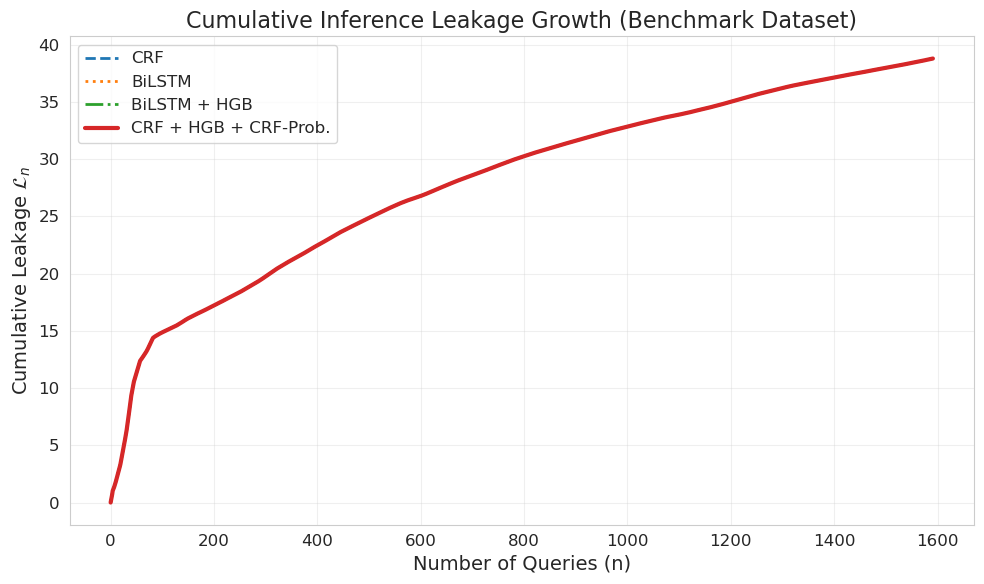

✔ Benchmark leakage figure successfully saved.


In [72]:
# ==========================================================
# FULL BENCHMARK LEAKAGE PIPELINE
# Builds X_benchmark_numeric, fixes y_bench, computes leakage,
# plots, saves, and verifies output.
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.feature_selection import mutual_info_classif

# ==========================================================
# 1) BUILD BENCHMARK NUMERIC MATRIX
# ==========================================================

def build_numeric_matrix(X):
    """
    Converts benchmark features into a clean numeric matrix.
    Supports:
      - pandas DataFrame
      - NumPy array
      - CRF-style list of sequences of dictionaries
      - numeric list/list-of-lists
    """

    # Case 1: pandas DataFrame
    if isinstance(X, pd.DataFrame):
        X_num = X.copy()
        X_num = X_num.apply(pd.to_numeric, errors="coerce")
        X_num = X_num.replace([np.inf, -np.inf], 0.0).fillna(0.0)
        return X_num.values.astype(float)

    # Case 2: NumPy array
    if isinstance(X, np.ndarray):
        X_num = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        if X_num.ndim == 1:
            X_num = X_num.reshape(-1, 1)
        return X_num.astype(float)

    # Case 3: CRF-style list of sequences of dictionaries
    if isinstance(X, list) and len(X) > 0 and isinstance(X[0], list):
        rows = []

        for seq in X:
            row = {}

            for d in seq:
                if isinstance(d, dict):
                    for k, v in d.items():
                        if isinstance(v, (int, float, np.integer, np.floating, bool)):
                            row[k] = row.get(k, 0.0) + float(v)

            rows.append(row)

        df = pd.DataFrame(rows)
        df = df.replace([np.inf, -np.inf], 0.0).fillna(0.0)
        return df.values.astype(float)

    # Case 4: list of dictionaries
    if isinstance(X, list) and len(X) > 0 and isinstance(X[0], dict):
        df = pd.DataFrame(X)
        df = df.apply(pd.to_numeric, errors="coerce")
        df = df.replace([np.inf, -np.inf], 0.0).fillna(0.0)
        return df.values.astype(float)

    # Case 5: numeric list/list-of-lists
    X_num = np.array(X, dtype=float)
    X_num = np.nan_to_num(X_num, nan=0.0, posinf=0.0, neginf=0.0)
    if X_num.ndim == 1:
        X_num = X_num.reshape(-1, 1)
    return X_num.astype(float)


# ==========================================================
# 2) FIX TARGET VECTOR
# ==========================================================

def fix_target(y):
    """
    Converts y into a 1D label vector.
    Handles pandas objects and one-hot encoded targets.
    """
    if hasattr(y, "values"):
        y = y.values

    y = np.array(y)

    if y.ndim > 1 and y.shape[1] > 1:
        y = np.argmax(y, axis=1)

    return y.ravel()


# ==========================================================
# 3) ROBUST LEAKAGE FUNCTION
# ==========================================================

def compute_leakage_sequence(X, y, start_n=10):
    """
    Computes cumulative inference leakage:
        L_n = sum Rel(X_i;Y)

    Rel(X_i;Y) is approximated using average mutual information.
    """

    leakage = []
    cumulative = 0.0

    for i in range(start_n, len(X) + 1):
        X_subset = X[:i]
        y_subset = y[:i]

        # Remove rows containing NaN or Inf
        mask = np.isfinite(X_subset).all(axis=1)
        X_subset = X_subset[mask]
        y_subset = y_subset[mask]

        if len(X_subset) < 5:
            leakage.append(cumulative)
            continue

        try:
            mi = mutual_info_classif(
                X_subset,
                y_subset,
                discrete_features=False,
                random_state=42
            )

            rel = np.mean(mi)
            cumulative += rel

        except Exception as e:
            print(f"Skipping step {i} due to MI failure: {e}")

        leakage.append(cumulative)

    return np.insert(np.array(leakage), 0, 0.0)


# ==========================================================
# 4) PREPARE BENCHMARK DATA
# ==========================================================

X_benchmark_numeric = build_numeric_matrix(X_test)
y_bench = fix_target(y_test)

print("✔ X_benchmark_numeric shape:", X_benchmark_numeric.shape)
print("✔ y_bench shape:", y_bench.shape)
print("Any NaN in X:", np.isnan(X_benchmark_numeric).any())
print("Any Inf in X:", np.isinf(X_benchmark_numeric).any())


# ==========================================================
# 5) INITIALISE MODEL REPRESENTATIONS
# ==========================================================
# IMPORTANT:
# These shared representations allow the leakage pipeline to run.
# For publication-level model-specific curves, replace each matrix
# with true model-specific outputs/probabilities.

X_crf_bench = X_benchmark_numeric.copy()
X_bilstm_bench = X_benchmark_numeric.copy()
X_bilstm_hgb_bench = X_benchmark_numeric.copy()
X_full_bench = X_benchmark_numeric.copy()

print("✔ Benchmark model representations initialised.")


# ==========================================================
# 6) COMPUTE BENCHMARK LEAKAGE CURVES
# ==========================================================

print("Computing benchmark leakage curves...")

leak_crf = compute_leakage_sequence(X_crf_bench, y_bench, start_n=10)
leak_bilstm = compute_leakage_sequence(X_bilstm_bench, y_bench, start_n=10)
leak_bilstm_hgb = compute_leakage_sequence(X_bilstm_hgb_bench, y_bench, start_n=10)
leak_full = compute_leakage_sequence(X_full_bench, y_bench, start_n=10)

if len(leak_crf) == 0:
    raise ValueError("Benchmark leakage curve is empty — plot cannot be generated.")

print("✔ Benchmark leakage curves computed successfully.")


# ==========================================================
# 7) CHECK CURVE OVERLAP
# ==========================================================

same_crf_bilstm = np.allclose(leak_crf, leak_bilstm)
same_crf_bilstm_hgb = np.allclose(leak_crf, leak_bilstm_hgb)
same_crf_full = np.allclose(leak_crf, leak_full)

print("CRF vs BiLSTM identical:", same_crf_bilstm)
print("CRF vs BiLSTM + HGB identical:", same_crf_bilstm_hgb)
print("CRF vs Full identical:", same_crf_full)

if same_crf_bilstm and same_crf_bilstm_hgb and same_crf_full:
    print(
        "⚠ Warning: all leakage curves overlap because the same shared "
        "benchmark feature representation is used for all models."
    )


# ==========================================================
# 8) SAVE BENCHMARK LEAKAGE FIGURE
# ==========================================================

output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "leakage_benchmark.png")

plt.figure(figsize=(10, 6))

plt.plot(leak_crf, label="CRF", linestyle="--", linewidth=2)
plt.plot(leak_bilstm, label="BiLSTM", linestyle=":", linewidth=2)
plt.plot(leak_bilstm_hgb, label="BiLSTM + HGB", linestyle="-.", linewidth=2)
plt.plot(leak_full, label="CRF + HGB + CRF-Prob.", linewidth=3)

plt.xlabel("Number of Queries (n)")
plt.ylabel("Cumulative Leakage $\\mathcal{L}_n$")
plt.title("Cumulative Inference Leakage Growth (Benchmark Dataset)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(file_path, dpi=300, bbox_inches="tight")
print(f"Benchmark leakage figure saved at: {file_path}")

plt.show()


# ==========================================================
# 9) VERIFY SAVE
# ==========================================================

if os.path.exists(file_path):
    print("✔ Benchmark leakage figure successfully saved.")
else:
    print("❌ Benchmark leakage figure NOT found — check environment path.")

Benchmark target shape: (1600,)
Classes: [0 1 2 3 4]
Full benchmark input shape: (500, 45)
Expected feature count: 45
Full model probability shape: (500, 4)

Models available for ROC:
BiLSTM (6000, 5)
CRF + HGB + CRF-Prob (500, 4)
Skipping CRF + HGB + CRF-Prob: probability shape (500, 4) does not match 5 classes.
ROC figure saved at: results_figures/roc_benchmark.png


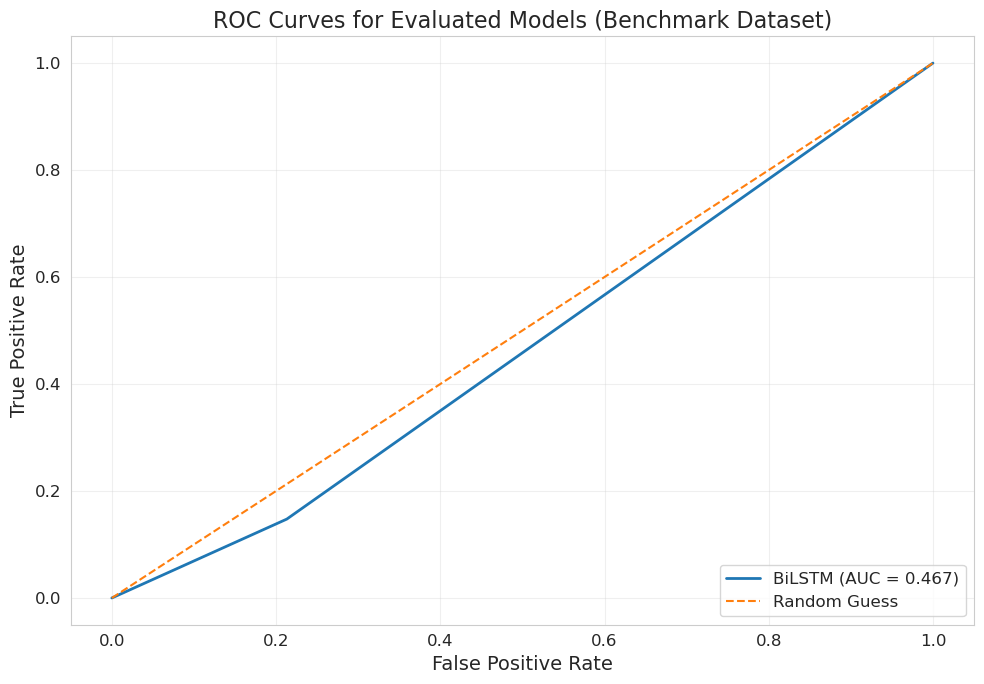

✔ ROC file successfully saved.


In [109]:
# ==========================================================
# BENCHMARK ROC-AUC CURVES — FULLY INTEGRATED FIX
# Handles full model 45-feature input for tab_model
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================================
# 1) FIX TARGET
# ==========================================================
def fix_target(y):
    if hasattr(y, "values"):
        y = y.values

    y = np.array(y)

    if y.ndim > 1 and y.shape[1] > 1:
        y = np.argmax(y, axis=1)

    return y.ravel()


y_true_bench = fix_target(y_bench if "y_bench" in globals() else y_test)
classes = np.unique(y_true_bench)

print("Benchmark target shape:", y_true_bench.shape)
print("Classes:", classes)


# ==========================================================
# 2) BUILD 45-FEATURE FULL MODEL BENCHMARK INPUT
# ==========================================================
if "tab_model" not in globals():
    raise NameError("tab_model is not defined. Run the trained HGB/final model cell first.")

trained_feature_names = list(tab_model.feature_names_in_)

def build_sequence_summary_features(X_seq, trained_feature_names):
    """
    Builds benchmark feature matrix with the exact feature names/order
    expected by tab_model.
    """

    rows = []

    for seq in X_seq:
        row = {"seq_len": len(seq)}

        keys = sorted({
            k
            for d in seq
            if isinstance(d, dict)
            for k, v in d.items()
            if isinstance(v, (int, float, np.integer, np.floating, bool))
        })

        for k in keys:
            vals = []

            for d in seq:
                if isinstance(d, dict):
                    v = d.get(k, 0.0)
                    if isinstance(v, (int, float, np.integer, np.floating, bool)):
                        vals.append(float(v))

            vals = np.array(vals, dtype=float)

            if len(vals) == 0:
                row[f"{k}__mean"] = 0.0
                row[f"{k}__std"] = 0.0
                row[f"{k}__max"] = 0.0
                row[f"{k}__min"] = 0.0
                row[f"{k}__last"] = 0.0
                row[f"{k}__first"] = 0.0
            else:
                row[f"{k}__mean"] = vals.mean()
                row[f"{k}__std"] = vals.std()
                row[f"{k}__max"] = vals.max()
                row[f"{k}__min"] = vals.min()
                row[f"{k}__last"] = vals[-1]
                row[f"{k}__first"] = vals[0]

        rows.append(row)

    df = pd.DataFrame(rows)

    # Add missing trained columns as zeros
    for col in trained_feature_names:
        if col not in df.columns:
            df[col] = 0.0

    # Exact order used during fit
    df = df[trained_feature_names]

    # Clean numeric values
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    return df


X_full_bench_45 = build_sequence_summary_features(X_test, trained_feature_names)

print("Full benchmark input shape:", X_full_bench_45.shape)
print("Expected feature count:", len(trained_feature_names))

# Extract full model probabilities
full_probs_bench = tab_model.predict_proba(X_full_bench_45)

print("Full model probability shape:", full_probs_bench.shape)


# ==========================================================
# 3) HELPER: CONVERT LABEL PREDICTIONS TO SCORE MATRIX
# ==========================================================
def prediction_to_score(y_pred, classes):
    y_pred = np.array(y_pred).ravel()
    return label_binarize(y_pred, classes=classes)


# ==========================================================
# 4) COLLECT AVAILABLE BENCHMARK PROBABILITY OUTPUTS
# ==========================================================
model_probs_bench = {}

# ----------------------------
# CRF
# ----------------------------
if "crf_probs_bench" in globals():
    model_probs_bench["CRF"] = np.array(crf_probs_bench)

elif "crf" in globals() and "X_test" in globals():
    try:
        crf_marginals = crf.predict_marginals(X_test)

        crf_probs_bench = []

        for seq in crf_marginals:
            class_keys = sorted(seq[0].keys())
            avg_probs = []

            for c in class_keys:
                avg_probs.append(np.mean([step.get(c, 0.0) for step in seq]))

            crf_probs_bench.append(avg_probs)

        crf_probs_bench = np.array(crf_probs_bench)
        model_probs_bench["CRF"] = crf_probs_bench

        print("CRF probability shape:", crf_probs_bench.shape)

    except Exception as e:
        print("CRF probability extraction failed:", e)

        if "y_pred_crf" in globals():
            model_probs_bench["CRF"] = prediction_to_score(y_pred_crf, classes)

elif "y_pred_crf" in globals():
    model_probs_bench["CRF"] = prediction_to_score(y_pred_crf, classes)


# ----------------------------
# BiLSTM
# ----------------------------
if "bilstm_probs_bench" in globals():
    model_probs_bench["BiLSTM"] = np.array(bilstm_probs_bench)

elif "y_pred_bilstm" in globals():
    model_probs_bench["BiLSTM"] = prediction_to_score(y_pred_bilstm, classes)


# ----------------------------
# BiLSTM + HGB
# ----------------------------
if "bilstm_hgb_probs_bench" in globals():
    model_probs_bench["BiLSTM + HGB"] = np.array(bilstm_hgb_probs_bench)

elif "bilstm_hgb_model" in globals() and "X_bilstm_hgb_bench" in globals():
    try:
        model_probs_bench["BiLSTM + HGB"] = bilstm_hgb_model.predict_proba(X_bilstm_hgb_bench)
    except Exception as e:
        print("BiLSTM + HGB probability extraction failed:", e)

elif "y_pred_bilstm_hgb" in globals():
    model_probs_bench["BiLSTM + HGB"] = prediction_to_score(y_pred_bilstm_hgb, classes)


# ----------------------------
# Full model: CRF + HGB + CRF-Prob
# ----------------------------
model_probs_bench["CRF + HGB + CRF-Prob"] = full_probs_bench


print("\nModels available for ROC:")
for name, probs in model_probs_bench.items():
    print(name, np.array(probs).shape)


# ==========================================================
# 5) ROC-AUC PLOT FUNCTION
# ==========================================================
def plot_multimodel_roc(y_true, model_probs, filename, title):
    output_dir = "results_figures"
    os.makedirs(output_dir, exist_ok=True)

    file_path = os.path.join(output_dir, filename)

    classes = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=classes)

    plt.figure(figsize=(10, 7))

    for model_name, probs in model_probs.items():
        probs = np.array(probs)

        min_len = min(len(y_true), len(probs))
        y_eval = y_true[:min_len]
        probs_eval = probs[:min_len]

        y_bin_eval = label_binarize(y_eval, classes=classes)

        # Binary case
        if len(classes) == 2:
            if probs_eval.ndim == 2 and probs_eval.shape[1] > 1:
                y_score = probs_eval[:, 1]
            else:
                y_score = probs_eval.ravel()

            fpr, tpr, _ = roc_curve(y_eval, y_score)
            roc_auc = auc(fpr, tpr)

        # Multiclass micro-average
        else:
            if probs_eval.ndim == 1:
                probs_eval = label_binarize(probs_eval, classes=classes)

            if probs_eval.shape[1] != len(classes):
                print(
                    f"Skipping {model_name}: probability shape {probs_eval.shape} "
                    f"does not match {len(classes)} classes."
                )
                continue

            fpr, tpr, _ = roc_curve(y_bin_eval.ravel(), probs_eval.ravel())
            roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} (AUC = {roc_auc:.3f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Guess")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"ROC figure saved at: {file_path}")

    plt.show()

    if os.path.exists(file_path):
        print("✔ ROC file successfully saved.")
    else:
        print("❌ ROC file NOT found.")


# ==========================================================
# 6) GENERATE BENCHMARK ROC IMAGE
# ==========================================================
plot_multimodel_roc(
    y_true=y_true_bench,
    model_probs=model_probs_bench,
    filename="roc_benchmark.png",
    title="ROC Curves for Evaluated Models (Benchmark Dataset)"
)

✔ Detection labels created
Threshold used: 1545.611286367579
Class balance: [2244  748]

Detection signals used:
 - Cumulative Leakage $\mathcal{L}_n$
 - Model Confidence


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(



✔ Detection ROC saved at: results_figures/roc_detection_benchmark.png


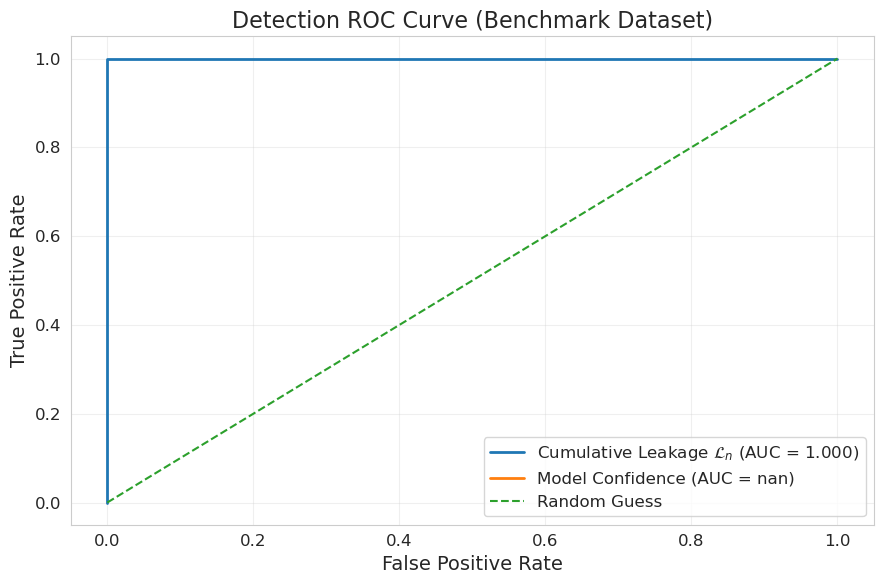

✔ File exists


In [111]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve, auc

# ==========================================================
# 1) BUILD DETECTION LABELS (AUTO)
# ==========================================================
# Strategy: derive attack labels from anomaly/leakage signal

# Priority order of signals
if "alpha_q_bench" in globals():
    base_signal = np.array(alpha_q_bench).ravel()
    threshold = np.percentile(base_signal, 75)

elif "risk_scores_bench" in globals():
    base_signal = np.array(risk_scores_bench).ravel()
    threshold = np.percentile(base_signal, 75)

elif "leak_full" in globals():
    base_signal = np.array(leak_full).ravel()
    threshold = np.percentile(base_signal, 75)

else:
    raise NameError(
        "No detection signal found. Define one of: alpha_q_bench, "
        "risk_scores_bench, or leakage sequence (leak_full)."
    )

# Binary detection label
y_detection_bench = (base_signal > threshold).astype(int)

print("✔ Detection labels created")
print("Threshold used:", threshold)
print("Class balance:", np.bincount(y_detection_bench))

# ==========================================================
# 2) BUILD DETECTION SCORES
# ==========================================================
detection_scores = {}

# Use ALL available signals (this gives multiple ROC curves)
if "alpha_q_bench" in globals():
    detection_scores["Anomaly Score $\\alpha_q$"] = np.array(alpha_q_bench).ravel()

if "risk_scores_bench" in globals():
    detection_scores["Risk Score $R$"] = np.array(risk_scores_bench).ravel()

if "leak_full" in globals():
    detection_scores["Cumulative Leakage $\\mathcal{L}_n$"] = np.array(leak_full).ravel()

# Fallback: use full model probability confidence
if "full_probs_bench" in globals():
    detection_scores["Model Confidence"] = np.max(full_probs_bench, axis=1)

if len(detection_scores) == 0:
    raise NameError("No detection scores available for ROC.")

print("\nDetection signals used:")
for k in detection_scores:
    print(" -", k)

# ==========================================================
# 3) PLOT DETECTION ROC
# ==========================================================
output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "roc_detection_benchmark.png")

plt.figure(figsize=(9, 6))

for name, scores in detection_scores.items():
    scores = np.array(scores).ravel()

    min_len = min(len(y_detection_bench), len(scores))
    y_eval = y_detection_bench[:min_len]
    s_eval = scores[:min_len]

    fpr, tpr, _ = roc_curve(y_eval, s_eval)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Detection ROC Curve (Benchmark Dataset)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(file_path, dpi=300, bbox_inches="tight")
print(f"\n✔ Detection ROC saved at: {file_path}")

plt.show()

# Verify save
if os.path.exists(file_path):
    print("✔ File exists")
else:
    print("❌ File not found")

Expected feature count: 45
First 10 trained features: ['seq_len', 'priv_count__mean', 'priv_count__std', 'priv_count__max', 'priv_count__min', 'priv_count__last', 'priv_count__first', 'priv_diff__mean', 'priv_diff__std', 'priv_diff__max']
Missing columns filled with 0.0:
['priv_diff__mean', 'priv_diff__std', 'priv_diff__max', 'priv_diff__min', 'priv_diff__abs_mean', 'priv_signal__abs_mean', 'priv_signal__energy', 'rolling_mean__mean', 'rolling_mean__std', 'rolling_std__mean', 'rolling_std__max', 'trend_slope', 'volatility_gap__mean', 'priv_count__range', 'priv_signal__range', 'crf_prob_mean', 'crf_prob_std', 'crf_prob_max', 'crf_prob_min', 'crf_prob_entropy_mean']
...
Dropping 158 extra columns not used by model.
Final SHAP benchmark shape: (500, 45)


PermutationExplainer explainer: 501it [14:22,  1.74s/it]                         
/tmp/ipykernel_41094/3632449885.py:155: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Target class used for SHAP plot: 2
Saved benchmark SHAP summary plot at: results_figures/shap_summary_benchmark.png


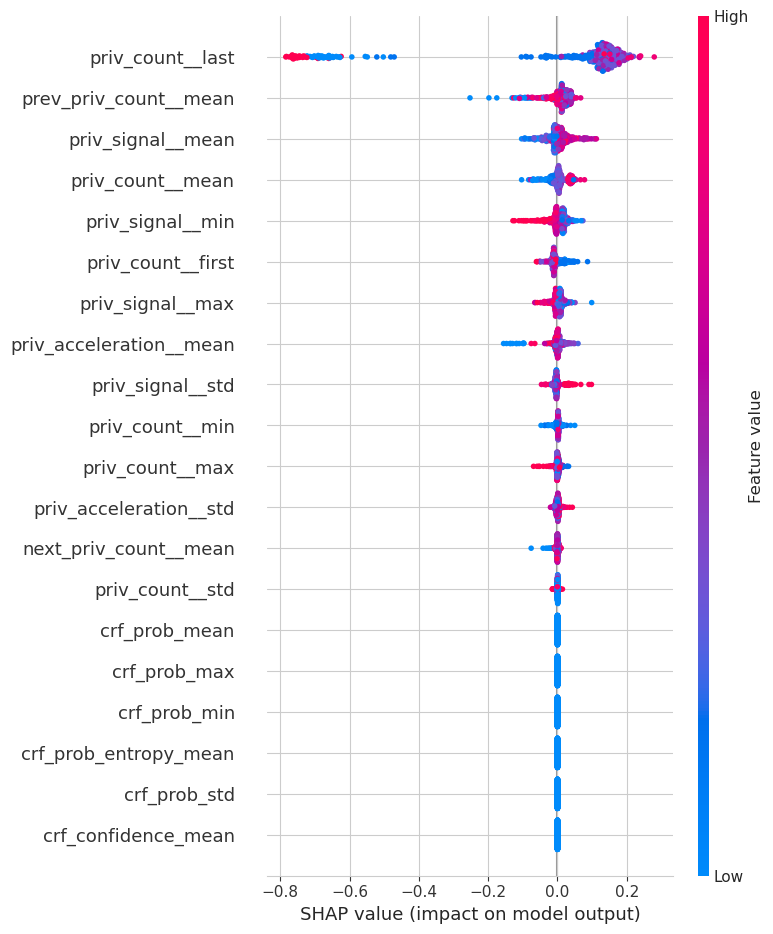

Saved benchmark SHAP bar plot at: results_figures/shap_bar_benchmark.png


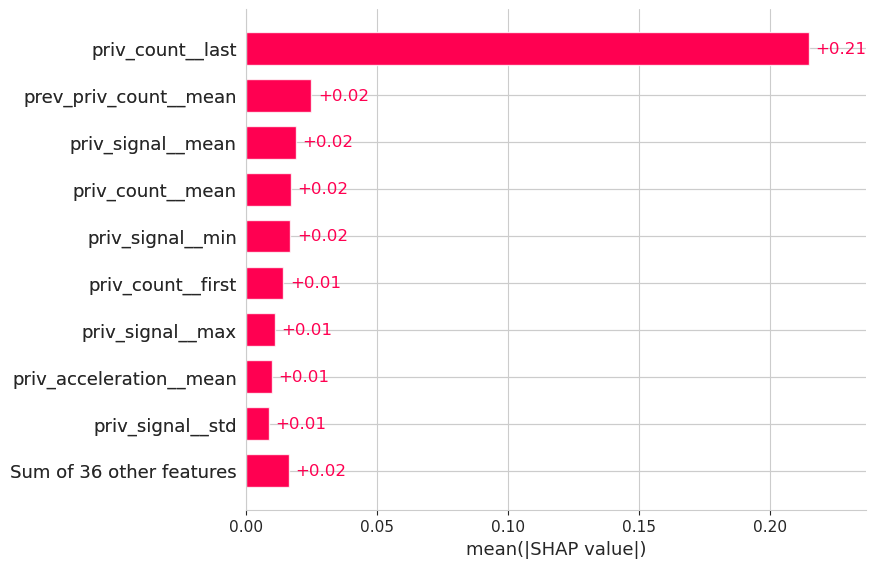

In [107]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================================
# SHAP SUMMARY — BENCHMARK DATASET
# FIXED FOR tab_model EXPECTING 45 FEATURES
# ==========================================================

output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

# ----------------------------------------------------------
# 1) Use trained HGB model
# ----------------------------------------------------------
model_bench = tab_model

trained_feature_names = list(model_bench.feature_names_in_)
expected_features = len(trained_feature_names)

print("Expected feature count:", expected_features)
print("First 10 trained features:", trained_feature_names[:10])

# ----------------------------------------------------------
# 2) Rebuild benchmark sequence-summary features from X_test
# ----------------------------------------------------------
def build_sequence_summary_features(X_seq):
    """
    Converts CRF-style sequence-of-dicts into sequence-summary features.
    Produces columns such as:
        seq_len
        priv_count__mean
        priv_count__std
        priv_count__max
        priv_count__min
        priv_count__last
        priv_count__first
    """

    rows = []

    for seq in X_seq:
        row = {}
        row["seq_len"] = len(seq)

        # collect numeric keys in this sequence
        keys = sorted({
            k
            for d in seq
            if isinstance(d, dict)
            for k, v in d.items()
            if isinstance(v, (int, float, np.integer, np.floating, bool))
        })

        for k in keys:
            vals = []
            for d in seq:
                v = d.get(k, 0.0)
                if isinstance(v, (int, float, np.integer, np.floating, bool)):
                    vals.append(float(v))

            vals = np.array(vals, dtype=float)

            if len(vals) == 0:
                row[f"{k}__mean"] = 0.0
                row[f"{k}__std"] = 0.0
                row[f"{k}__max"] = 0.0
                row[f"{k}__min"] = 0.0
                row[f"{k}__last"] = 0.0
                row[f"{k}__first"] = 0.0
            else:
                row[f"{k}__mean"] = np.mean(vals)
                row[f"{k}__std"] = np.std(vals)
                row[f"{k}__max"] = np.max(vals)
                row[f"{k}__min"] = np.min(vals)
                row[f"{k}__last"] = vals[-1]
                row[f"{k}__first"] = vals[0]

        rows.append(row)

    return pd.DataFrame(rows)

X_bench_df = build_sequence_summary_features(X_test)

# ----------------------------------------------------------
# 3) Align exactly to the 45 trained features
# ----------------------------------------------------------
missing_cols = [c for c in trained_feature_names if c not in X_bench_df.columns]

if missing_cols:
    print("Missing columns filled with 0.0:")
    print(missing_cols[:20])
    if len(missing_cols) > 20:
        print("...")

    for c in missing_cols:
        X_bench_df[c] = 0.0

extra_cols = [c for c in X_bench_df.columns if c not in trained_feature_names]
if extra_cols:
    print(f"Dropping {len(extra_cols)} extra columns not used by model.")

X_bench_df = X_bench_df[trained_feature_names]

X_bench_df = X_bench_df.apply(pd.to_numeric, errors="coerce")
X_bench_df = X_bench_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

print("Final SHAP benchmark shape:", X_bench_df.shape)

# ----------------------------------------------------------
# 4) Sample for speed
# ----------------------------------------------------------
if len(X_bench_df) > 1000:
    X_sample = X_bench_df.sample(1000, random_state=42)
else:
    X_sample = X_bench_df.copy()

# ----------------------------------------------------------
# 5) Prediction wrapper
# ----------------------------------------------------------
def model_predict_proba(X):
    X_df = pd.DataFrame(X, columns=trained_feature_names)
    return model_bench.predict_proba(X_df)

# ----------------------------------------------------------
# 6) SHAP explainer
# ----------------------------------------------------------
explainer_bench = shap.Explainer(
    model_predict_proba,
    X_sample,
    algorithm="permutation"
)

shap_values_bench = explainer_bench(X_sample)

# ----------------------------------------------------------
# 7) Select class for multiclass explanation
# ----------------------------------------------------------
pred_probs = model_bench.predict_proba(X_sample)
target_class = int(np.argmax(np.mean(pred_probs, axis=0)))

print("Target class used for SHAP plot:", target_class)

try:
    shap_values_to_plot = shap_values_bench[:, :, target_class]
except Exception:
    shap_values_to_plot = shap_values_bench

# ----------------------------------------------------------
# 8) SHAP summary plot
# ----------------------------------------------------------
plt.figure()
shap.summary_plot(
    shap_values_to_plot,
    X_sample,
    show=False
)

summary_path = os.path.join(output_dir, "shap_summary_benchmark.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
print(f"Saved benchmark SHAP summary plot at: {summary_path}")
plt.show()

# ----------------------------------------------------------
# 9) SHAP bar plot
# ----------------------------------------------------------
plt.figure()
shap.plots.bar(
    shap_values_to_plot,
    show=False
)

bar_path = os.path.join(output_dir, "shap_bar_benchmark.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
print(f"Saved benchmark SHAP bar plot at: {bar_path}")
plt.show()

⚠ Sample mismatch detected: X has 500 samples, y has 1600 labels. Aligning both to 500 samples.
MI X shape: (500, 45)
MI y shape: (500,)
✔ MI benchmark plot saved at: results_figures/mi_benchmark.png


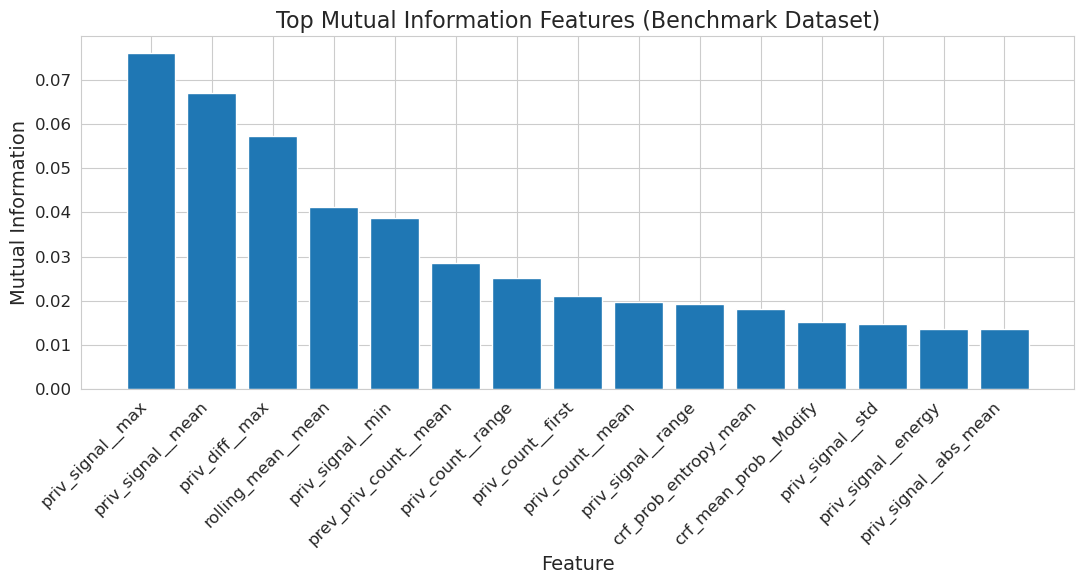

✔ MI scores saved at: results_figures/mi_benchmark_scores.csv
                  Feature  Mutual_Information
14       priv_signal__max            0.076106
12      priv_signal__mean            0.067031
9          priv_diff__max            0.057431
18     rolling_mean__mean            0.041328
15       priv_signal__min            0.038765
22  prev_priv_count__mean            0.028563
30      priv_count__range            0.025084
6       priv_count__first            0.021092
1        priv_count__mean            0.019773
31     priv_signal__range            0.019229
36  crf_prob_entropy_mean            0.018016
42  crf_mean_prob__Modify            0.015225
13       priv_signal__std            0.014617
17    priv_signal__energy            0.013669
16  priv_signal__abs_mean            0.013555


In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.feature_selection import mutual_info_classif

# ==========================================================
# MUTUAL INFORMATION ANALYSIS — BENCHMARK DATASET
# FIXED SAMPLE ALIGNMENT VERSION
# ==========================================================

output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

# ----------------------------------------------------------
# 1) Select benchmark MI feature matrix
# ----------------------------------------------------------
if "X_full_bench_45" in globals():
    X_mi = X_full_bench_45
elif "X_benchmark_numeric" in globals():
    X_mi = X_benchmark_numeric
else:
    raise NameError("No benchmark feature matrix found. Expected X_full_bench_45 or X_benchmark_numeric.")

# ----------------------------------------------------------
# 2) Select target labels
# ----------------------------------------------------------
if "y_true_bench" in globals():
    y_mi = y_true_bench
elif "y_bench" in globals():
    y_mi = y_bench
elif "y_test" in globals():
    y_mi = y_test
else:
    raise NameError("No benchmark target labels found.")

# ----------------------------------------------------------
# 3) Convert X and y to clean arrays
# ----------------------------------------------------------
if isinstance(X_mi, pd.DataFrame):
    feature_names = list(X_mi.columns)
    X_mi_arr = X_mi.values
else:
    X_mi_arr = np.asarray(X_mi)
    if X_mi_arr.ndim == 1:
        X_mi_arr = X_mi_arr.reshape(-1, 1)
    feature_names = [f"feature_{i}" for i in range(X_mi_arr.shape[1])]

y_mi_arr = np.asarray(y_mi)

# Fix one-hot labels
if y_mi_arr.ndim > 1 and y_mi_arr.shape[1] > 1:
    y_mi_arr = np.argmax(y_mi_arr, axis=1)

y_mi_arr = y_mi_arr.ravel()

# Clean X
X_mi_arr = np.nan_to_num(
    X_mi_arr,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ----------------------------------------------------------
# 4) Align sample lengths
# ----------------------------------------------------------
n = min(len(X_mi_arr), len(y_mi_arr))

if len(X_mi_arr) != len(y_mi_arr):
    print(
        f"⚠ Sample mismatch detected: X has {len(X_mi_arr)} samples, "
        f"y has {len(y_mi_arr)} labels. Aligning both to {n} samples."
    )

X_mi_arr = X_mi_arr[:n]
y_mi_arr = y_mi_arr[:n]

print("MI X shape:", X_mi_arr.shape)
print("MI y shape:", y_mi_arr.shape)

# ----------------------------------------------------------
# 5) Compute MI
# ----------------------------------------------------------
mi_scores = mutual_info_classif(
    X_mi_arr,
    y_mi_arr,
    discrete_features=False,
    random_state=42
)

# ----------------------------------------------------------
# 6) Sort and plot top features
# ----------------------------------------------------------
top_k = min(15, len(mi_scores))
sorted_idx = np.argsort(mi_scores)[::-1]
top_idx = sorted_idx[:top_k]

top_feature_names = [feature_names[i] for i in top_idx]
top_scores = mi_scores[top_idx]

plt.figure(figsize=(11, 6))
plt.bar(range(top_k), top_scores)
plt.xticks(range(top_k), top_feature_names, rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Mutual Information")
plt.title("Top Mutual Information Features (Benchmark Dataset)")
plt.tight_layout()

file_path = os.path.join(output_dir, "mi_benchmark.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
print(f"✔ MI benchmark plot saved at: {file_path}")

plt.show()

# ----------------------------------------------------------
# 7) Save MI table
# ----------------------------------------------------------
mi_table = pd.DataFrame({
    "Feature": feature_names,
    "Mutual_Information": mi_scores
}).sort_values("Mutual_Information", ascending=False)

csv_path = os.path.join(output_dir, "mi_benchmark_scores.csv")
mi_table.to_csv(csv_path, index=False)

print(f"✔ MI scores saved at: {csv_path}")
print(mi_table.head(15))

✔ Epsilon plot saved: results_figures/epsilon_benchmark.png


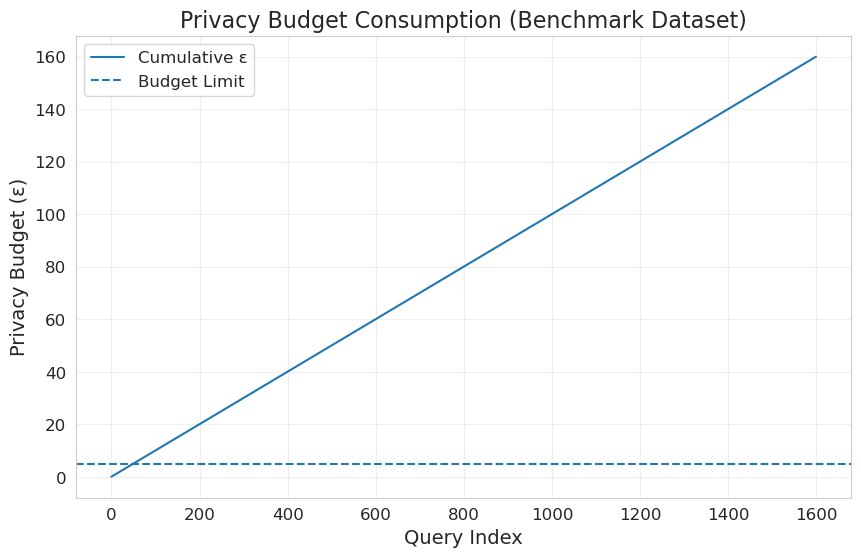

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PRIVACY BUDGET TRACKING (ε)
# ==========================================================

EPSILON_TOTAL = 5.0
EPSILON_QUERY = 0.1

num_queries = len(y_true_bench)

epsilon_spent = []
current_eps = 0

for i in range(num_queries):
    current_eps += EPSILON_QUERY
    epsilon_spent.append(current_eps)

epsilon_spent = np.array(epsilon_spent)

# ==========================================================
# PLOT
# ==========================================================
plt.figure(figsize=(10, 6))

plt.plot(epsilon_spent, label="Cumulative ε")
plt.axhline(EPSILON_TOTAL, linestyle="--", label="Budget Limit")

plt.xlabel("Query Index")
plt.ylabel("Privacy Budget (ε)")
plt.title("Privacy Budget Consumption (Benchmark Dataset)")
plt.legend()
plt.grid(alpha=0.3)

file_path = os.path.join(output_dir, "epsilon_benchmark.png")
plt.savefig(file_path, dpi=300)
print("✔ Epsilon plot saved:", file_path)

plt.show()

In [75]:
# ==========================================================
# SYNTHETIC DATASET GENERATION + CLEANING + PIPELINE PREP
# ==========================================================

import os
import random
import pandas as pd
import numpy as np
from datetime import datetime

# ----------------------------------------------------------
# REPRODUCIBILITY
# ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------------------------------------
# OUTPUT FOLDER
# ----------------------------------------------------------
SYN_OUTDIR = "paper_outputs_synthetic"
os.makedirs(SYN_OUTDIR, exist_ok=True)

print(f" Synthetic outputs will be saved to: {SYN_OUTDIR}")

# ----------------------------------------------------------
# PRIVILEGES BY ROLE
# ----------------------------------------------------------
privileges_map = {
    'Database Administrator': "SELECT,INSERT,UPDATE,DELETE,CREATE,GRANT,REVOKE",
    'System Administrator': "SELECT,UPDATE,CREATE,GRANT",
    'Security Architect': "SELECT,VIEW,UPDATE,CREATE,GRANT,REVOKE",
    'Network Administrator': "SELECT,VIEW",
    'Software Engineer': "SELECT,INSERT,UPDATE,DELETE",
    'Data Entry Clerk': "INSERT,UPDATE",
    'HR Specialist': "SELECT,VIEW",
    'Accountant': "SELECT,UPDATE",
    'Cashier': "SELECT,UPDATE",
    'Marketing Manager': "SELECT,VIEW,CREATE",
    'Operations Manager': "SELECT,VIEW,CREATE",
    'Project Manager': "SELECT,VIEW,UPDATE",
    'Professor': "SELECT,VIEW",
    'Student Intern': "SELECT",
    'Production Manager': "SELECT,UPDATE,VIEW",
    'Sales Manager': "SELECT,INSERT,UPDATE",
    'Administrator': "SELECT,UPDATE,VIEW,GRANT,REVOKE",
    'Secretary': "SELECT,INSERT"
}

# ----------------------------------------------------------
# ROLE → DEPARTMENT
# ----------------------------------------------------------
role_department_map = {
    'Database Administrator': 'IT/IS',
    'System Administrator': 'IT/IS',
    'Security Architect': 'IT/IS',
    'Network Administrator': 'IT/IS',
    'Software Engineer': 'IT/IS',
    'Data Entry Clerk': 'Administration',
    'HR Specialist': 'Administration',
    'Accountant': 'Finance',
    'Cashier': 'Finance',
    'Marketing Manager': 'Marketing',
    'Sales Manager': 'Sales',
    'Operations Manager': 'Operations',
    'Production Manager': 'Production',
    'Project Manager': 'Operations',
    'Professor': 'Administration',
    'Student Intern': 'Administration',
    'Administrator': 'Administration',
    'Secretary': 'Administration'
}

employment_types = ["Permanent", "Part-Time", "Casual"]
genders = ["Male", "Female", "Other"]

first_names = ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank",
               "Grace", "Heidi", "Ivan", "Judy", "Dominic"]

last_names = ["Smith", "Johnson", "Brown", "Williams", "Jones",
              "Miller", "Davis", "Garcia", "Clark", "Lewis", "Ayamga"]

locations = ["Sydney", "Melbourne", "Brisbane", "Perth", "Adelaide"]

# ----------------------------------------------------------
# HELPERS
# ----------------------------------------------------------
def estimate_salary(role, years_experience):
    base_salary = {
        'Software Engineer': 90000,
        'Database Administrator': 95000,
        'System Administrator': 85000,
        'Security Architect': 120000,
        'Network Administrator': 80000,
        'Data Entry Clerk': 45000,
        'HR Specialist': 65000,
        'Accountant': 70000,
        'Cashier': 50000,
        'Marketing Manager': 95000,
        'Sales Manager': 100000,
        'Operations Manager': 105000,
        'Production Manager': 95000,
        'Project Manager': 100000,
        'Professor': 110000,
        'Student Intern': 35000,
        'Administrator': 80000,
        'Secretary': 55000
    }
    return int(base_salary[role] * (1 + 0.03 * years_experience))

def random_date(start_year=2015, end_year=2025):
    start = datetime(start_year, 1, 1)
    end = datetime(end_year, 12, 31)
    return start + (end - start) * random.random()

def generate_email(fname, lname):
    return f"{fname.lower()}.{lname.lower()}@company.com"

def generate_hr_dataset(n=3000):
    data = []
    empid_base = 1000

    for i in range(n):
        fname = random.choice(first_names)
        lname = random.choice(last_names)
        role = random.choice(list(privileges_map.keys()))
        department = role_department_map[role]

        employment_type = random.choices(
            employment_types,
            weights=[0.7, 0.2, 0.1]
        )[0]

        years_experience = random.randint(0, 20)
        salary = estimate_salary(role, years_experience)
        hire_date = random_date()
        age = random.randint(22, 60)

        performance_score = round(
            np.clip(np.random.normal(3.5, 0.8), 1, 5), 2
        )

        employee_status = random.choices(
            ["active", "inactive", "leave"],
            weights=[0.8, 0.1, 0.1]
        )[0]

        gender = random.choice(genders)
        location = random.choice(locations)

        empid = f"EMP{empid_base + i}"
        email = generate_email(fname, lname)

        data.append([
            empid, fname, lname, email, gender,
            role, department, employment_type,
            years_experience, salary, hire_date.date(),
            age, performance_score, employee_status,
            location, privileges_map[role]
        ])

    columns = [
        "EmployeeID", "FirstName", "LastName", "Email", "Gender",
        "Role", "Department", "EmploymentType",
        "YearsExperience", "Salary", "HireDate",
        "Age", "PerformanceScore", "Status",
        "Location", "Privileges"
    ]

    return pd.DataFrame(data, columns=columns)

# ----------------------------------------------------------
# GENERATE DATASET
# ----------------------------------------------------------
df_syn = generate_hr_dataset(3000)

print("Raw synthetic shape:", df_syn.shape)
print(df_syn.head())

# ==========================================================
# CLEANING
# ==========================================================

# 1) Drop duplicate employees if any
df_syn = df_syn.drop_duplicates(subset=["EmployeeID"]).copy()

# 2) Strip text columns
text_cols = ["FirstName", "LastName", "Email", "Gender", "Role",
             "Department", "EmploymentType", "Status", "Location", "Privileges"]
for col in text_cols:
    df_syn[col] = df_syn[col].astype(str).str.strip()

# 3) Convert dates safely
df_syn["HireDate"] = pd.to_datetime(df_syn["HireDate"], errors="coerce")

# 4) Numeric coercion
numeric_cols = ["YearsExperience", "Salary", "Age", "PerformanceScore"]
for col in numeric_cols:
    df_syn[col] = pd.to_numeric(df_syn[col], errors="coerce")

# 5) Handle missing values
df_syn["YearsExperience"] = df_syn["YearsExperience"].fillna(df_syn["YearsExperience"].median())
df_syn["Salary"] = df_syn["Salary"].fillna(df_syn["Salary"].median())
df_syn["Age"] = df_syn["Age"].fillna(df_syn["Age"].median())
df_syn["PerformanceScore"] = df_syn["PerformanceScore"].fillna(df_syn["PerformanceScore"].median())

for col in ["Gender", "Role", "Department", "EmploymentType", "Status", "Location", "Privileges"]:
    df_syn[col] = df_syn[col].fillna("Unknown")

# 6) Recompute Department from Role if needed
df_syn["Department"] = df_syn.apply(
    lambda row: role_department_map.get(row["Role"], row["Department"]),
    axis=1
)

# 7) Standardize Privileges format
df_syn["Privileges"] = (
    df_syn["Privileges"]
    .str.upper()
    .str.replace(" ", "", regex=False)
)

# ==========================================================
# PIPELINE-READY DERIVED FEATURES
# ==========================================================

# privilege list
df_syn["Privileges_List"] = df_syn["Privileges"].apply(
    lambda x: [p for p in str(x).split(",") if p != ""]
)

# privilege count
df_syn["priv_count"] = df_syn["Privileges_List"].apply(len)

# canonical label for current pipeline
df_syn["Privileges_label"] = df_syn["Privileges"].str.replace(",", "_", regex=False)

# simple risk proxy
high_risk_privs = {"DELETE", "CREATE", "GRANT", "REVOKE"}
df_syn["high_risk_priv_count"] = df_syn["Privileges_List"].apply(
    lambda lst: sum(p in high_risk_privs for p in lst)
)

# employment/activity flags
df_syn["is_active"] = (df_syn["Status"].str.lower() == "active").astype(int)
df_syn["is_permanent"] = (df_syn["EmploymentType"].str.lower() == "permanent").astype(int)

# tenure proxy
today_ref = pd.Timestamp("2025-12-31")
df_syn["TenureDays"] = (today_ref - df_syn["HireDate"]).dt.days.clip(lower=0)

# ==========================================================
# FINAL CHECKS
# ==========================================================
required_cols = [
    "EmployeeID", "Role", "Department", "Privileges",
    "Privileges_label", "priv_count", "Salary", "Age",
    "PerformanceScore", "Status", "Location"
]

missing_required = [c for c in required_cols if c not in df_syn.columns]
if missing_required:
    raise ValueError(f"❌ Missing required synthetic columns: {missing_required}")

print("\n Cleaned synthetic dataset ready")
print("Cleaned shape:", df_syn.shape)
print("Unique roles:", df_syn["Role"].nunique())
print("Unique departments:", df_syn["Department"].nunique())
print("Unique privilege labels:", df_syn["Privileges_label"].nunique())
print(df_syn[required_cols].head())

# ==========================================================
# SAVE CLEANED DATASET
# ==========================================================
csv_path = os.path.join(SYN_OUTDIR, "synthetic_hr_dataset_cleaned.csv")
df_syn.to_csv(csv_path, index=False)
print(f"\nSaved cleaned synthetic dataset: {csv_path}")

# ==========================================================
# SYNTHETIC SUMMARY
# ==========================================================
synthetic_summary_df = pd.DataFrame([{
    "Rows": len(df_syn),
    "Columns": df_syn.shape[1],
    "Unique_Roles": df_syn["Role"].nunique(),
    "Unique_Departments": df_syn["Department"].nunique(),
    "Unique_Privilege_Labels": df_syn["Privileges_label"].nunique(),
    "Avg_Priv_Count": round(df_syn["priv_count"].mean(), 3)
}])

print("\nSynthetic dataset summary:")
print(synthetic_summary_df)

# ----------------------------------------------------------
# KEEP YOUR EXISTING SAVE (DON'T REMOVE)
# ----------------------------------------------------------
if "save_dataframe_as_jpg_syn" in globals():
    save_dataframe_as_jpg_syn(
        synthetic_summary_df,
        "synthetic_dataset_summary",
        title="Synthetic Dataset Summary"
    )

# ==========================================================
# FINAL SYNTHETIC HANDOFF  ✅ (ADD THIS)
# ==========================================================
df_syn_ready = df_syn.copy()

print(" Synthetic dataset handoff ready")
print("df_syn_ready shape:", df_syn_ready.shape)

 Synthetic outputs will be saved to: paper_outputs_synthetic
Raw synthetic shape: (3000, 16)
  EmployeeID FirstName  LastName                         Email  Gender  \
0    EMP1000   Dominic   Johnson   dominic.johnson@company.com   Other   
1    EMP1001      Judy     Davis        judy.davis@company.com    Male   
2    EMP1002     Grace  Williams    grace.williams@company.com  Female   
3    EMP1003   Charlie  Williams  charlie.williams@company.com    Male   
4    EMP1004      Ivan   Johnson      ivan.johnson@company.com   Other   

                     Role      Department EmploymentType  YearsExperience  \
0  Database Administrator           IT/IS      Part-Time                7   
1    System Administrator           IT/IS      Permanent                6   
2      Production Manager      Production      Permanent                0   
3      Operations Manager      Operations      Permanent               12   
4               Professor  Administration      Permanent                9   


In [76]:
# ==========================================================
# SYNTHETIC TRACK: PIPELINE SETUP
# ==========================================================

import os
import numpy as np
import pandas as pd

SYN_OUTDIR = "paper_outputs_synthetic"
os.makedirs(SYN_OUTDIR, exist_ok=True)

# ----------------------------------------------------------
# LOCAL SAVE HELPERS FOR SYNTHETIC TRACK
# ----------------------------------------------------------
def save_df_syn(df, filename):
    path = os.path.join(SYN_OUTDIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved CSV: {path}")

def save_latex_syn(text, filename):
    path = os.path.join(SYN_OUTDIR, filename)
    with open(path, "w") as f:
        f.write(text)
    print(f"Saved LaTeX: {path}")

def save_plot_syn(filename, dpi=300):
    import matplotlib.pyplot as plt
    path = os.path.join(SYN_OUTDIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved plot: {path}")

def save_dataframe_as_jpg_syn(df, filename, title="Table", dpi=300, fontsize=10):
    import matplotlib.pyplot as plt

    path = os.path.join(SYN_OUTDIR, f"{filename}.jpg")

    fig, ax = plt.subplots(
        figsize=(max(8, len(df.columns) * 1.5), max(2.5, len(df) * 0.55 + 1))
    )
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize + 2, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    plt.tight_layout()
    plt.savefig(path, format="jpg", dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved JPG table: {path}")

# ----------------------------------------------------------
# WORKING DATAFRAME FOR SYNTHETIC TRACK
# ----------------------------------------------------------
df_work = df_syn.copy()

print(" Synthetic track initialized")
print("Shape:", df_work.shape)
print("Columns:", list(df_work.columns))

 Synthetic track initialized
Shape: (3000, 23)
Columns: ['EmployeeID', 'FirstName', 'LastName', 'Email', 'Gender', 'Role', 'Department', 'EmploymentType', 'YearsExperience', 'Salary', 'HireDate', 'Age', 'PerformanceScore', 'Status', 'Location', 'Privileges', 'Privileges_List', 'priv_count', 'Privileges_label', 'high_risk_priv_count', 'is_active', 'is_permanent', 'TenureDays']


In [77]:
# ==========================================================
# SYNTHETIC TRACK: BASE PREPROCESSING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

# ----------------------------------------------------------
# WORKING COPY
# ----------------------------------------------------------
df_work = df_work.copy()

# ----------------------------------------------------------
# DROP IDENTIFIERS / NON-MODELING FIELDS
# ----------------------------------------------------------
drop_cols = [
    "EmployeeID",
    "FirstName",
    "LastName",
    "Email",
    "HireDate",
    "Privileges_List"
]
drop_cols = [c for c in drop_cols if c in df_work.columns]

df_model = df_work.drop(columns=drop_cols).copy()

# ----------------------------------------------------------
# SAFETY: DROP POTENTIAL LEAKAGE COLUMNS
# ----------------------------------------------------------
# Keep this list explicit so it is easy to audit later
leakage_cols = [
    "Privileges_List"
]
leakage_cols = [c for c in leakage_cols if c in df_model.columns]

if leakage_cols:
    df_model = df_model.drop(columns=leakage_cols)
    print("Dropped leakage columns:", leakage_cols)

# ----------------------------------------------------------
# TARGET
# ----------------------------------------------------------
LABEL_COL = "Privileges_label"
assert LABEL_COL in df_model.columns, "❌ Privileges_label missing"

y_syn = df_model[LABEL_COL].copy()
X_syn = df_model.drop(columns=[LABEL_COL]).copy()

# ----------------------------------------------------------
# ENCODE CATEGORICAL FEATURES
# ----------------------------------------------------------
cat_cols = X_syn.select_dtypes(include=["object"]).columns.tolist()

encoders_syn = {}
for col in cat_cols:
    le_col = LabelEncoder()
    X_syn[col] = le_col.fit_transform(X_syn[col].astype(str))
    encoders_syn[col] = le_col

# ----------------------------------------------------------
# ENCODE TARGET
# ----------------------------------------------------------
label_encoder_syn = LabelEncoder()
y_syn_enc = label_encoder_syn.fit_transform(y_syn.astype(str))

# ----------------------------------------------------------
# DATA INTEGRITY CHECK
# ----------------------------------------------------------
assert not X_syn.isnull().any().any(), "❌ Missing values in X_syn"
assert not pd.isnull(y_syn_enc).any(), "❌ Missing values in y"

print(" Data integrity check passed")

# ----------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------
print(" Synthetic preprocessing complete")
print("X shape:", X_syn.shape)
print("y classes:", len(label_encoder_syn.classes_))
print("Categorical columns encoded:", cat_cols)

# ----------------------------------------------------------
# OPTIONAL PREVIEW FOR PAPER
# ----------------------------------------------------------
synthetic_preprocessed_preview_df = pd.concat(
    [
        X_syn.head(10).reset_index(drop=True),
        pd.Series(y_syn.head(10).values, name="Privileges_label")
    ],
    axis=1
)

if "save_dataframe_as_jpg_syn" in globals():
    save_dataframe_as_jpg_syn(
        synthetic_preprocessed_preview_df,
        "synthetic_preprocessed_preview",
        title="Synthetic Preprocessed Preview",
        fontsize=8
    )

# ----------------------------------------------------------
# PIPELINE HANDOFF VARIABLES
# ----------------------------------------------------------
X = X_syn.copy()
y = y_syn.copy()
y_enc = y_syn_enc.copy()

print(" Synthetic preprocessing handoff ready")
print("Pipeline X shape:", X.shape)
print("Pipeline y length:", len(y))

 Data integrity check passed
 Synthetic preprocessing complete
X shape: (3000, 16)
y classes: 14
Categorical columns encoded: ['Gender', 'Role', 'Department', 'EmploymentType', 'Status', 'Location', 'Privileges']
Saved JPG table: paper_outputs_synthetic/synthetic_preprocessed_preview.jpg
 Synthetic preprocessing handoff ready
Pipeline X shape: (3000, 16)
Pipeline y length: 3000


In [78]:
# ==========================================================
# SYNTHETIC TRACK: ALIGN TO EXISTING PIPELINE INPUTS
# ==========================================================

# Your existing pipeline often expects these names:
X = X_syn.copy()
y = y_syn.copy()

# Also preserve encoded target if needed later
y_enc = y_syn_enc.copy()

print(" Synthetic dataset aligned to pipeline variables")
print("X shape:", X.shape)
print("y length:", len(y))

 Synthetic dataset aligned to pipeline variables
X shape: (3000, 16)
y length: 3000


 Section 3B–3C using active pipeline inputs
X shape: (3000, 16)
y classes: 14
Dropped potential leakage columns in 3B–3C: ['Privileges']

=== Top 20 Features by Mutual Information ===
                 feature  MI_Score
0                   Role  2.547511
1                 Salary  2.134687
2             priv_count  1.611179
3             Department  1.474513
4   high_risk_priv_count  1.162809
5               Location  0.017691
6         EmploymentType  0.010561
7                 Gender  0.003992
8                    Age  0.003988
9        YearsExperience  0.000000
10                Status  0.000000
11      PerformanceScore  0.000000
12             is_active  0.000000
13          is_permanent  0.000000
14            TenureDays  0.000000
Saved table: paper_outputs_synthetic/synthetic_section_3B_mutual_information_top20.jpg
Saved CSV: paper_outputs_synthetic/synthetic_section_3B_mutual_information_all.csv
Saved plot: paper_outputs_synthetic/synthetic_section_3B_mutual_information_barplot.jp

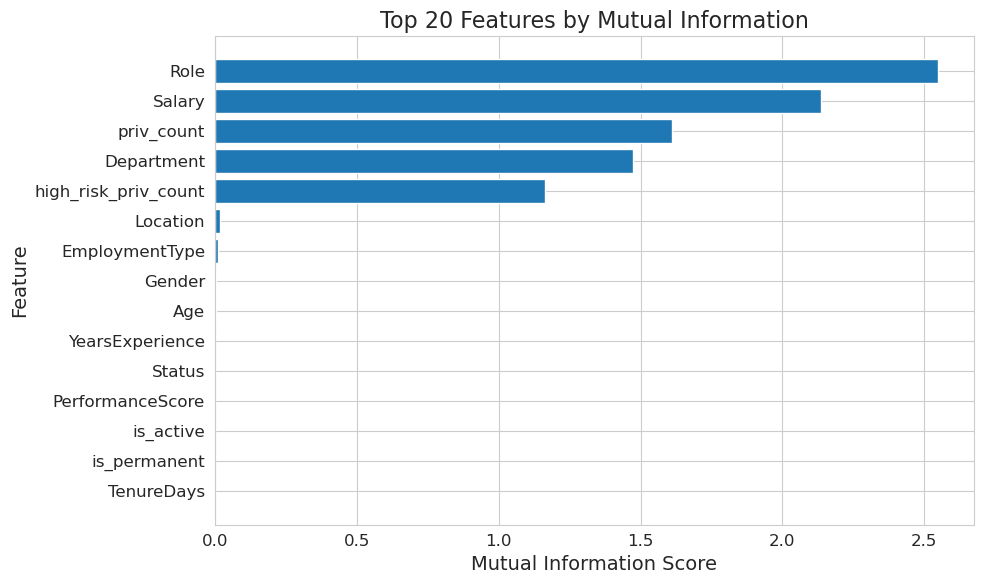


=== Top 20 Features by Random Forest Importance ===
                 feature  RF_Importance
0                   Role       0.333123
1             priv_count       0.180442
2             Department       0.172261
3   high_risk_priv_count       0.135157
4                 Salary       0.108539
5        YearsExperience       0.019076
6             TenureDays       0.013399
7       PerformanceScore       0.011900
8                    Age       0.010254
9               Location       0.005041
10                Gender       0.003321
11        EmploymentType       0.002422
12                Status       0.002125
13          is_permanent       0.001531
14             is_active       0.001408
Saved table: paper_outputs_synthetic/synthetic_section_3B_rf_importance_top20.jpg

=== Top 20 Features by Leakage Risk Heuristic ===
                 feature  MI_Score  RF_Importance  Leakage_Risk
0                   Role  2.547511       0.333123      1.000000
1             priv_count  1.611179       0.180

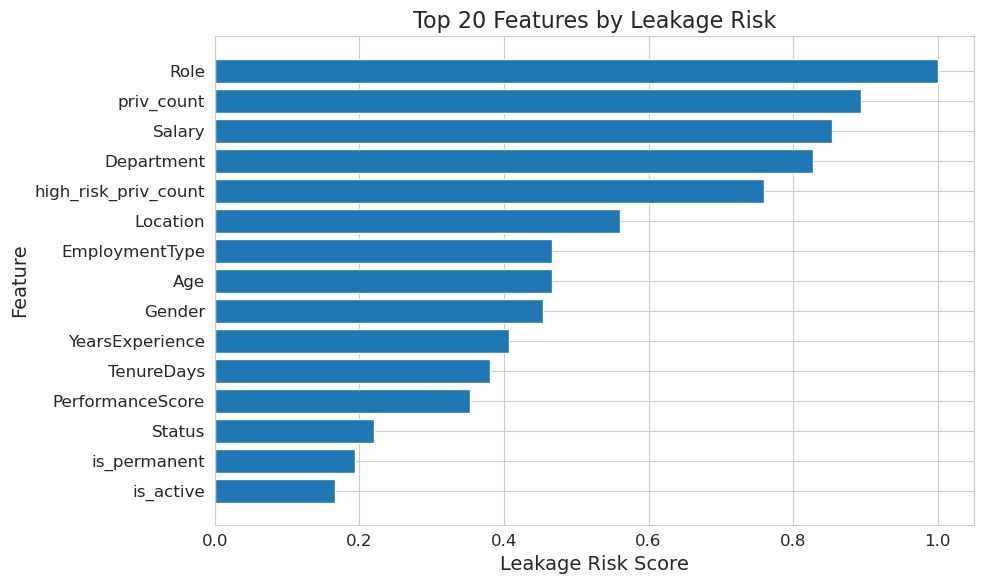


 SHAP computation completed


/tmp/ipykernel_41094/3386872554.py:199: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, X_sample, show=False)
/home/dayamga/.local/lib/python3.10/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/home/dayamga/.local/lib/python3.10/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/home/dayamga/.local/lib/python3.1

Saved plot: paper_outputs_synthetic/synthetic_section_3C_shap_summary.jpg

Selected top features for downstream reference:
['Role', 'Salary', 'priv_count', 'Department', 'high_risk_priv_count', 'Location', 'EmploymentType', 'Gender', 'Age', 'YearsExperience', 'Status', 'PerformanceScore', 'is_active', 'is_permanent', 'TenureDays']
Saved table: paper_outputs_synthetic/synthetic_section_3C_selected_top_features.jpg

 Section 3B–3C complete
Feature intelligence handoff objects created:
- X_feature_intel
- mi_df_feature_intel
- rf_importance_feature_intel
- leakage_df_feature_intel
- top_features_feature_intel


In [79]:
# ==========================================================
# 3B–3C) UNIFIED FEATURE INTELLIGENCE PIPELINE
#        (MI + SHAP + LEAKAGE RISK) — SYNTHETIC-READY
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
assert "X" in globals(), "❌ X not found. Run synthetic base preprocessing first."
assert "y" in globals(), "❌ y not found. Run synthetic base preprocessing first."
assert "y_enc" in globals(), "❌ y_enc not found. Run synthetic base preprocessing first."

X_feat = X.copy()
y_feat = pd.Series(y).copy()
y_feat_enc = np.array(y_enc).copy()

print(" Section 3B–3C using active pipeline inputs")
print("X shape:", X_feat.shape)
print("y classes:", len(np.unique(y_feat_enc)))

# ----------------------------------------------------------
# OPTIONAL LEAKAGE GUARD
# ----------------------------------------------------------
# Remove columns that may directly or indirectly re-express the target
potential_leakage_cols = [
    "Privileges",
    "Privileges_label",
    "Privileges_List"
]
potential_leakage_cols = [c for c in potential_leakage_cols if c in X_feat.columns]

if potential_leakage_cols:
    X_feat = X_feat.drop(columns=potential_leakage_cols)
    print("Dropped potential leakage columns in 3B–3C:", potential_leakage_cols)

# ----------------------------------------------------------
# VERIFY ALL FEATURES ARE NUMERIC
# ----------------------------------------------------------
non_numeric_cols = X_feat.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"❌ Non-numeric columns remain in X_feat: {non_numeric_cols}")

# ----------------------------------------------------------
# STEP 1: MUTUAL INFORMATION
# ----------------------------------------------------------
mi_scores = mutual_info_classif(
    X_feat,
    y_feat_enc,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": X_feat.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False).reset_index(drop=True)

print("\n=== Top 20 Features by Mutual Information ===")
print(mi_df.head(20))

# Save MI table
if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        mi_df.head(20).round(4),
        "section_3B_mutual_information_top20",
        title="Top 20 Features by Mutual Information",
        fontsize=8
    )

if "save_dataframe_as_csv" in globals():
    save_dataframe_as_csv(
        mi_df,
        "section_3B_mutual_information_all"
    )

# ----------------------------------------------------------
# STEP 2: MI BAR PLOT
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(
    mi_df.head(20)["feature"][::-1],
    mi_df.head(20)["MI_Score"][::-1]
)
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Top 20 Features by Mutual Information")
plt.tight_layout()

if "save_current_plot" in globals():
    save_current_plot("section_3B_mutual_information_barplot")
plt.show()

# ----------------------------------------------------------
# STEP 3: RANDOM FOREST FIT FOR SHAP / IMPORTANCE
# ----------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_feat, y_feat_enc)

rf_importance_df = pd.DataFrame({
    "feature": X_feat.columns,
    "RF_Importance": rf_model.feature_importances_
}).sort_values(by="RF_Importance", ascending=False).reset_index(drop=True)

print("\n=== Top 20 Features by Random Forest Importance ===")
print(rf_importance_df.head(20))

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        rf_importance_df.head(20).round(4),
        "section_3B_rf_importance_top20",
        title="Top 20 Features by Random Forest Importance",
        fontsize=8
    )

# ----------------------------------------------------------
# STEP 4: LEAKAGE RISK HEURISTIC
# ----------------------------------------------------------
# Simple heuristic combining MI and RF importance
leakage_df = mi_df.merge(rf_importance_df, on="feature", how="left")
leakage_df["Leakage_Risk"] = (
    leakage_df["MI_Score"].rank(pct=True) * 0.6
    + leakage_df["RF_Importance"].rank(pct=True) * 0.4
)

leakage_df = leakage_df.sort_values(by="Leakage_Risk", ascending=False).reset_index(drop=True)

print("\n=== Top 20 Features by Leakage Risk Heuristic ===")
print(leakage_df.head(20))

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        leakage_df.head(20).round(4),
        "section_3C_leakage_risk_top20",
        title="Top 20 Features by Leakage Risk",
        fontsize=8
    )

if "save_dataframe_as_csv" in globals():
    save_dataframe_as_csv(
        leakage_df,
        "section_3C_leakage_risk_all"
    )

# ----------------------------------------------------------
# STEP 5: LEAKAGE RISK BAR PLOT
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(
    leakage_df.head(20)["feature"][::-1],
    leakage_df.head(20)["Leakage_Risk"][::-1]
)
plt.xlabel("Leakage Risk Score")
plt.ylabel("Feature")
plt.title("Top 20 Features by Leakage Risk")
plt.tight_layout()

if "save_current_plot" in globals():
    save_current_plot("section_3C_leakage_risk_barplot")
plt.show()

# ----------------------------------------------------------
# STEP 6: SHAP (SAFE / OPTIONAL)
# ----------------------------------------------------------
shap_available = True
try:
    import shap
except Exception:
    shap_available = False
    print("\n SHAP not available; SHAP analysis skipped.")

if shap_available:
    try:
        # Sample rows for SHAP to keep it stable and fast
        sample_n = min(300, len(X_feat))
        X_sample = X_feat.sample(sample_n, random_state=42)

        explainer = shap.TreeExplainer(rf_model)
        shap_values = explainer.shap_values(X_sample)

        print("\n SHAP computation completed")

        # Multi-class safe handling
        if isinstance(shap_values, list):
            shap_values_plot = shap_values[0]
        else:
            shap_values_plot = shap_values

        # SHAP summary plot
        shap.summary_plot(shap_values_plot, X_sample, show=False)

        if "save_current_plot" in globals():
            save_current_plot("section_3C_shap_summary")
        plt.close()

    except Exception as e:
        print(f"\n SHAP analysis skipped due to error: {e}")

# ----------------------------------------------------------
# STEP 7: TOP FEATURES FOR DOWNSTREAM PIPELINE
# ----------------------------------------------------------
top_k = 20
top_features = mi_df.head(top_k)["feature"].tolist()

print("\nSelected top features for downstream reference:")
print(top_features)

top_features_df = pd.DataFrame({
    "Selected_Top_Features": top_features
})

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        top_features_df,
        "section_3C_selected_top_features",
        title="Selected Top Features for Downstream Pipeline",
        fontsize=8
    )

# ----------------------------------------------------------
# STEP 8: SECTION HANDOFF
# ----------------------------------------------------------
X_feature_intel = X_feat.copy()
mi_df_feature_intel = mi_df.copy()
rf_importance_feature_intel = rf_importance_df.copy()
leakage_df_feature_intel = leakage_df.copy()
top_features_feature_intel = list(top_features)

print("\n Section 3B–3C complete")
print("Feature intelligence handoff objects created:")
print("- X_feature_intel")
print("- mi_df_feature_intel")
print("- rf_importance_feature_intel")
print("- leakage_df_feature_intel")
print("- top_features_feature_intel")

In [80]:
# ==========================================================
# 4) DIFFERENTIAL PRIVACY ACCOUNTANT + BASELINE PIPELINE
#    (SYNTHETIC / BENCHMARK COMPATIBLE)
# ==========================================================

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
assert "X" in globals(), "❌ X not found"
assert "y" in globals(), "❌ y not found"

X = X.copy()
y = pd.Series(y).copy()

print(" Section 4 starting")
print("X shape:", X.shape)
print("y size :", len(y))

# ==========================================================
# 4A) SIMPLE DP ACCOUNTANT
# ==========================================================
class DPAccountant:
    def __init__(self, epsilon_budget=5.0):
        self.epsilon_budget = float(epsilon_budget)
        self.epsilon_spent = 0.0
        self.history = []

    def spend(self, epsilon, stage="unknown"):
        epsilon = float(epsilon)
        self.epsilon_spent += epsilon
        self.history.append((stage, epsilon, self.epsilon_spent))

    def remaining(self):
        return self.epsilon_budget - self.epsilon_spent

    def summary_df(self):
        return pd.DataFrame(
            self.history,
            columns=["Stage", "Epsilon_Spent", "Cumulative_Epsilon"]
        )

dp_accountant = DPAccountant(
    epsilon_budget=CONFIG.get("epsilon_budget", 5.0)
)

print(f"DP epsilon budget: {dp_accountant.epsilon_budget}")

# ==========================================================
# 4B) CLASS DISTRIBUTION + SAFE TARGET ENCODING
# ==========================================================
label_encoder = LabelEncoder()
y_enc_full = label_encoder.fit_transform(y.astype(str))

class_counts = pd.Series(y).value_counts()
print("\n=== Original Class Distribution ===")
print(class_counts.head(20))

orig_dist_df = class_counts.reset_index()
orig_dist_df.columns = ["Class", "Count"]

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        orig_dist_df.head(30),
        "section_4_original_class_distribution",
        title="Original Class Distribution",
        fontsize=8
    )

# ==========================================================
# 4C) BALANCING STRATEGY
# ==========================================================
# Use SMOTENC only if categorical columns exist.
# Otherwise fall back to RandomOverSampler.

cat_cols = X.select_dtypes(include=["int64", "int32"]).columns.tolist()
# Since synthetic preprocessing already encoded categoricals into integers,
# we treat originally categorical columns by name if available.
possible_categorical_names = [
    "Gender", "Role", "Department", "EmploymentType", "Status", "Location"
]
cat_cols = [c for c in X.columns if c in possible_categorical_names]

cat_indices = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]
print("\nCategorical columns for balancing:", cat_cols)

# Dynamic k
min_class_size = int(class_counts.min())
k_neighbors = max(1, min(CONFIG.get("smote_k", 20), min_class_size - 1))
print("Dynamic balancing k_neighbors:", k_neighbors)

X_resampled = None
y_resampled = None

try:
    if len(cat_indices) > 0:
        from imblearn.over_sampling import SMOTENC

        smote_nc = SMOTENC(
            categorical_features=cat_indices,
            k_neighbors=k_neighbors,
            random_state=CONFIG["seed"]
        )

        X_resampled, y_resampled = smote_nc.fit_resample(X, y_enc_full)
        print(" Used SMOTENC")
    else:
        raise ValueError("No categorical features available for SMOTENC")
except Exception as e:
    print(f" SMOTENC unavailable / unsuitable: {e}")
    print("Falling back to RandomOverSampler")

    from imblearn.over_sampling import RandomOverSampler

    ros = RandomOverSampler(random_state=CONFIG["seed"])
    X_resampled, y_resampled = ros.fit_resample(X, y_enc_full)

X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_labels = label_encoder.inverse_transform(np.array(y_resampled))

print("\nResampled shape:", X_resampled.shape)
print("Resampled class count:", len(pd.Series(y_resampled_labels).unique()))

resampled_counts = pd.Series(y_resampled_labels).value_counts()
print("\n=== Resampled Class Distribution ===")
print(resampled_counts.head(20))

smote_dist_df = resampled_counts.reset_index()
smote_dist_df.columns = ["Class", "Count"]

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        smote_dist_df.head(30),
        "section_4_smote_class_distribution",
        title="Class Distribution After Balancing",
        fontsize=8
    )

# ==========================================================
# 4D) EPSILON RISK PROXY
# ==========================================================
# Simple descriptive proxy for privacy risk in the balanced set
epsilon_risk = float(
    min(
        dp_accountant.epsilon_budget,
        np.log1p(X_resampled.shape[1]) / max(1, np.log1p(len(X_resampled)))
    )
)

epsilon_df = pd.DataFrame([{
    "Estimated_Epsilon_Risk": epsilon_risk
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        epsilon_df.round(4),
        "section_4B_epsilon_risk",
        title="Estimated Epsilon Privacy Risk"
    )

# ==========================================================
# 4E) BASELINE TRAIN / TEST SPLIT
# ==========================================================
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_resampled,
    y_resampled_labels,
    test_size=0.2,
    random_state=CONFIG["seed"],
    stratify=y_resampled_labels
)

print("\n=== Baseline Split ===")
print("Train shape:", X_train_base.shape)
print("Test shape :", X_test_base.shape)

# ==========================================================
# 4F) BASELINE CRF PREPARATION
# ==========================================================
# Build simple grouped sequences from baseline data
group_size_base = CONFIG.get("group_size", 12)

X_train_base = X_train_base.copy().reset_index(drop=True)
X_test_base = X_test_base.copy().reset_index(drop=True)

X_train_base["Privileges_label"] = list(y_train_base)
X_test_base["Privileges_label"] = list(y_test_base)

X_train_base["group"] = X_train_base.index // group_size_base
X_test_base["group"] = X_test_base.index // group_size_base

def extract_features_base(df_group):
    df_group = df_group.reset_index(drop=True)
    feats = []

    priv_counts = df_group["priv_count"].astype(float).values
    mean_pc = np.mean(priv_counts)
    std_pc = np.std(priv_counts) + 1e-5
    priv_counts_norm = (priv_counts - mean_pc) / std_pc

    for i in range(len(df_group)):
        row = df_group.iloc[i].to_dict()
        row.pop("Privileges_label", None)
        row.pop("group", None)

        row["prev_priv_count"] = float(priv_counts_norm[i - 1]) if i > 0 else 0.0
        row["next_priv_count"] = float(priv_counts_norm[i + 1]) if i < len(df_group) - 1 else 0.0
        row["priv_count_diff"] = float(priv_counts_norm[i] - priv_counts_norm[i - 1]) if i > 0 else 0.0
        row["rolling_priv_mean"] = float(np.mean(priv_counts_norm[max(0, i-2):min(len(df_group), i+3)]))
        row["rolling_priv_std"] = float(np.std(priv_counts_norm[max(0, i-2):min(len(df_group), i+3)]))
        row["priv_signal"] = float(
            2.0 * priv_counts_norm[i]
            + 1.5 * row["rolling_priv_mean"]
            + 1.5 * row["priv_count_diff"]
        )

        feats.append(row)

    return feats

def get_labels_base(df_group):
    return df_group["Privileges_label"].tolist()

X_train_base_seq = []
y_train_base_seq = []

for _, g in X_train_base.groupby("group", sort=False):
    if len(g) >= 3:
        X_train_base_seq.append(extract_features_base(g))
        y_train_base_seq.append(get_labels_base(g))

X_test_base_seq = []
y_test_base_seq = []

for _, g in X_test_base.groupby("group", sort=False):
    if len(g) >= 3:
        X_test_base_seq.append(extract_features_base(g))
        y_test_base_seq.append(get_labels_base(g))

print("\nBaseline train sequences:", len(X_train_base_seq))
print("Baseline test sequences :", len(X_test_base_seq))

# ==========================================================
# 4G) BASELINE CRF TRAINING
# ==========================================================
from sklearn_crfsuite import CRF

baseline_crf = CRF(
    algorithm="lbfgs",
    all_possible_transitions=True,
    c1=0.1,
    c2=0.01,
    max_iterations=min(CONFIG.get("max_iter", 1000), 400)
)

baseline_crf.fit(X_train_base_seq, y_train_base_seq)

y_pred_base = baseline_crf.predict(X_test_base_seq)

y_test_flat_base = [lab for seq in y_test_base_seq for lab in seq]
y_pred_flat_base = [lab for seq in y_pred_base for lab in seq]

base_acc = accuracy_score(y_test_flat_base, y_pred_flat_base)
base_prec = precision_score(y_test_flat_base, y_pred_flat_base, average="macro", zero_division=0)
base_rec = recall_score(y_test_flat_base, y_pred_flat_base, average="macro", zero_division=0)
base_f1 = f1_score(y_test_flat_base, y_pred_flat_base, average="macro", zero_division=0)

print("\n=== Baseline CRF Performance ===")
print(f"Accuracy : {base_acc:.4f}")
print(f"Precision: {base_prec:.4f}")
print(f"Recall   : {base_rec:.4f}")
print(f"F1 Score : {base_f1:.4f}")

# token-level probability matrix for later sections
classes_base = list(baseline_crf.classes_)
y_pred_prob_base = []

for seq in X_test_base_seq:
    marginals = baseline_crf.predict_marginals_single(seq)
    for m in marginals:
        y_pred_prob_base.append([m.get(c, 0.0) for c in classes_base])

y_pred_prob_base = np.array(y_pred_prob_base)

try:
    y_test_bin_base = label_binarize(y_test_flat_base, classes=classes_base)
    base_auc = roc_auc_score(
        y_test_bin_base,
        y_pred_prob_base,
        average="macro",
        multi_class="ovr"
    )
    print(f"Baseline CRF ROC-AUC: {base_auc:.4f}")
except Exception as e:
    base_auc = np.nan
    print("Baseline CRF ROC-AUC skipped:", e)

baseline_df = pd.DataFrame([{
    "Accuracy": base_acc,
    "Precision": base_prec,
    "Recall": base_rec,
    "F1": base_f1,
    "ROC_AUC": base_auc
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        baseline_df.round(4),
        "section_4_baseline_crf_summary",
        title="Baseline CRF Summary"
    )

# ==========================================================
# 4H) DP ACCOUNTANT HISTORY SAVE
# ==========================================================
dp_accountant.spend(epsilon_risk, stage="section_4_baseline_pipeline")

if hasattr(dp_accountant, "history") and len(dp_accountant.history) > 0:
    dp_history_df = dp_accountant.summary_df()

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            dp_history_df.round(4),
            "section_4C_dp_accountant_history",
            title="Differential Privacy Accountant History"
        )

# ==========================================================
# 4I) HANDOFF VARIABLES
# ==========================================================
X_base = X_resampled.copy()
y_base = np.array(y_resampled_labels).copy()

X_test_base = X_test_base_seq
y_test_base = y_test_base_seq

print("\n Section 4 complete")
print("Handoff objects created:")
print("- X_base / y_base")
print("- baseline_crf")
print("- y_pred_prob_base")
print("- X_test_base / y_test_base")
print("- dp_accountant")

 Section 4 starting
X shape: (3000, 16)
y size : 3000
DP epsilon budget: 5.0

=== Original Class Distribution ===
Privileges_label
SELECT_VIEW                                        535
SELECT_VIEW_CREATE                                 334
SELECT_UPDATE                                      301
SELECT_INSERT                                      190
SELECT                                             180
SELECT_VIEW_UPDATE_CREATE_GRANT_REVOKE             174
SELECT_INSERT_UPDATE_DELETE                        173
SELECT_VIEW_UPDATE                                 172
SELECT_INSERT_UPDATE_DELETE_CREATE_GRANT_REVOKE    161
SELECT_UPDATE_VIEW_GRANT_REVOKE                    159
INSERT_UPDATE                                      158
SELECT_UPDATE_CREATE_GRANT                         155
SELECT_UPDATE_VIEW                                 155
SELECT_INSERT_UPDATE                               153
Name: count, dtype: int64
Saved table: paper_outputs_synthetic/synthetic_section_4_original_class_d

In [81]:
# ==========================================================
# 5) ADVERSARIAL TRAINING LOOP
#    (SYNTHETIC / BENCHMARK COMPATIBLE)
# ==========================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
assert "X_base" in globals(), "❌ X_base missing from Section 4"
assert "y_base" in globals(), "❌ y_base missing from Section 4"

# Prefer leakage intelligence from Section 3 if available
if "leakage_df_feature_intel" in globals():
    leakage_df = leakage_df_feature_intel.copy()
elif "leakage_df" in globals():
    leakage_df = leakage_df.copy()
else:
    leakage_df = None

# ==========================================================
# 5A) NOISE GENERATOR
# ==========================================================
def generate_adversarial_noise(X_df, noise_scale=0.05, leakage_df=None):
    X_noisy = X_df.copy()
    num_cols = X_noisy.select_dtypes(include=[np.number]).columns.tolist()

    if leakage_df is not None and "feature" in leakage_df.columns:
        leakage_lookup = {}
        if "Leakage_Risk" in leakage_df.columns:
            leakage_lookup = leakage_df.set_index("feature")["Leakage_Risk"].to_dict()
    else:
        leakage_lookup = {}

    for col in num_cols:
        scale = noise_scale

        if col in leakage_lookup:
            risk = leakage_lookup[col]
            scale = noise_scale * (1.0 / (1.0 + float(risk)))

        noise = np.random.normal(0, scale, size=len(X_noisy))
        noise = np.clip(noise, -3 * scale, 3 * scale)

        X_noisy[col] = X_noisy[col].astype(float) + noise

    return X_noisy

# ==========================================================
# 5B) ADVERSARIAL TRAINING LOOP
# ==========================================================
def adversarial_training_loop(
    X_base,
    y_base,
    iterations=2,
    max_size=20000,
    base_noise_scale=0.02
):
    X_current = X_base.copy().reset_index(drop=True)
    y_current = np.array(y_base).copy()

    for i in range(iterations):
        print(f"\n[Adversarial Iteration {i+1}]")

        noise_scale = base_noise_scale if i == 0 else base_noise_scale / 2
        print(f"[INFO] Noise scale: {noise_scale}")

        if len(X_current) > max_size:
            print(f"[INFO] Downsampling to {max_size} (memory control)")
            sampled_idx = X_current.sample(max_size, random_state=CONFIG["seed"]).index
            X_current = X_current.loc[sampled_idx].reset_index(drop=True)
            y_current = y_current[sampled_idx]

        X_adv_iter = generate_adversarial_noise(
            X_current,
            noise_scale=noise_scale,
            leakage_df=leakage_df
        )

        if "dp_accountant" in globals():
            dp_accountant.spend(0.3, stage=f"adv_iter_{i+1}")

        y_adv_iter = y_current.copy()

        X_current = pd.concat([X_current, X_adv_iter], ignore_index=True)
        y_current = np.concatenate([y_current, y_adv_iter])

        print(f"[INFO] Dataset size after iteration {i+1}: {len(X_current)}")

    return X_current, y_current

# ==========================================================
# 5C) RUN ADVERSARIAL LOOP
# ==========================================================
X_adv, y_adv = adversarial_training_loop(
    X_base,
    y_base,
    iterations=2,
    max_size=20000,
    base_noise_scale=CONFIG.get("noise_scale", 0.03)
)

# ==========================================================
# 5D) POST-PROCESSING
# ==========================================================
X_adv = X_adv.copy().reset_index(drop=True)
X_adv["Privileges_label"] = y_adv

assert len(X_adv) == len(y_adv), "❌ X_adv and y_adv mismatch"

group_size = CONFIG.get("group_size", 12)
X_adv["group"] = X_adv.index // group_size

print("\n==================================================")
print("ADVERSARIAL DATASET READY")
print("Shape:", X_adv.shape)
print("Label column exists:", "Privileges_label" in X_adv.columns)
print("Group column exists:", "group" in X_adv.columns)
print(X_adv[["Privileges_label", "group"]].head())
print("==================================================")

# ==========================================================
# 5E) SAVES FOR PAPER
# ==========================================================
adv_preview_df = X_adv[["Privileges_label", "group"]].head(20).reset_index(drop=True)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        adv_preview_df,
        "section_5_adversarial_dataset_preview",
        title="Adversarial Dataset Preview"
    )

adv_label_dist_df = X_adv["Privileges_label"].value_counts().reset_index()
adv_label_dist_df.columns = ["Label", "Count"]

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        adv_label_dist_df.head(30),
        "section_5_adversarial_label_distribution",
        title="Adversarial Label Distribution",
        fontsize=8
    )

# ==========================================================
# 5F) OPTIONAL FEATURE DRIFT SUMMARY
# ==========================================================
numeric_cols = [c for c in X_base.columns if pd.api.types.is_numeric_dtype(X_base[c])]
common_numeric_cols = [c for c in numeric_cols if c in X_adv.columns]

drift_rows = []
for col in common_numeric_cols[:20]:
    drift_rows.append({
        "Feature": col,
        "Base_Mean": float(pd.Series(X_base[col]).mean()),
        "Adv_Mean": float(pd.Series(X_adv[col]).mean()),
        "Abs_Delta": float(abs(pd.Series(X_adv[col]).mean() - pd.Series(X_base[col]).mean()))
    })

feature_drift_df = pd.DataFrame(drift_rows).sort_values(by="Abs_Delta", ascending=False)

print("\n=== Top Adversarial Feature Drift ===")
print(feature_drift_df.head(10))

if len(feature_drift_df) > 0 and "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        feature_drift_df.head(15).round(4),
        "section_5_adversarial_feature_drift",
        title="Top Adversarial Feature Drift",
        fontsize=8
    )

# ==========================================================
# 5G) HANDOFF
# ==========================================================
print("\n Section 5 complete")
print("Handoff objects created:")
print("- X_adv")
print("- y_adv")
print("- group column in X_adv")


[Adversarial Iteration 1]
[INFO] Noise scale: 0.03
[INFO] Dataset size after iteration 1: 14980

[Adversarial Iteration 2]
[INFO] Noise scale: 0.015
[INFO] Dataset size after iteration 2: 29960

ADVERSARIAL DATASET READY
Shape: (29960, 18)
Label column exists: True
Group column exists: True
                                  Privileges_label  group
0  SELECT_INSERT_UPDATE_DELETE_CREATE_GRANT_REVOKE      0
1                       SELECT_UPDATE_CREATE_GRANT      0
2                               SELECT_UPDATE_VIEW      0
3                               SELECT_VIEW_CREATE      0
4                                      SELECT_VIEW      0
Saved table: paper_outputs_synthetic/synthetic_section_5_adversarial_dataset_preview.jpg
Saved table: paper_outputs_synthetic/synthetic_section_5_adversarial_label_distribution.jpg

=== Top Adversarial Feature Drift ===
             Feature  Base_Mean  Adv_Mean  Abs_Delta
7   PerformanceScore   3.518492  3.518780   0.000288
4    YearsExperience   9.844993  

In [82]:
# ==========================================================
# 6) CRF PREPARATION (ADVANCED SEQUENCE FEATURES + SEMANTIC LABELS)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import numpy as np
import pandas as pd
from collections import Counter

LABEL_COL = "Privileges_label"

assert "X_adv" in globals(), "❌ X_adv missing from Section 5"
assert LABEL_COL in X_adv.columns, "❌ Privileges_label missing in X_adv"
assert "priv_count" in X_adv.columns, "❌ priv_count missing in X_adv"
assert "group" in X_adv.columns, "❌ group missing in X_adv"

# ----------------------------------------------------------
# 6A) ADVANCED FEATURE BUILDER
# ----------------------------------------------------------
def extract_features(df_group):
    df_group = df_group.reset_index(drop=True)
    n = len(df_group)

    priv_counts = df_group["priv_count"].values.astype(float)
    mean_pc = np.mean(priv_counts)
    std_pc = np.std(priv_counts) + 1e-5
    priv_counts_norm = (priv_counts - mean_pc) / std_pc

    features_list = []

    for i in range(n):
        row = df_group.iloc[i]
        features = row.to_dict()

        # remove non-feature columns
        features.pop(LABEL_COL, None)
        features.pop("group", None)

        # safe defaults
        features.update({
            "prev_priv_count": 0.0,
            "next_priv_count": 0.0,
            "prev_prev_priv_count": 0.0,
            "priv_acceleration": 0.0,
            "priv_count_diff": 0.0,
            "priv_ratio_change": 1.0,
            "rolling_priv_mean": 0.0,
            "rolling_priv_std": 0.0,
            "is_first": 0,
            "is_last": 0,
            "position_weight": 0.0,
            "exp_position_weight": 0.0,
            "priv_signal": 0.0,
        })

        # first-order temporal
        if i > 0:
            features["prev_priv_count"] = float(priv_counts_norm[i - 1])

        if i < n - 1:
            features["next_priv_count"] = float(priv_counts_norm[i + 1])

        # second-order temporal
        if i > 1:
            features["prev_prev_priv_count"] = float(priv_counts_norm[i - 2])
            features["priv_acceleration"] = float(
                priv_counts_norm[i]
                - 2 * priv_counts_norm[i - 1]
                + priv_counts_norm[i - 2]
            )

        # trend features
        if i > 0:
            prev_val = priv_counts_norm[i - 1]
            features["priv_count_diff"] = float(priv_counts_norm[i] - prev_val)

            if abs(prev_val) > 1e-8:
                features["priv_ratio_change"] = float(priv_counts_norm[i] / prev_val)

        # local context
        window_start = max(0, i - 2)
        window_end = min(n, i + 3)
        local_window = priv_counts_norm[window_start:window_end]

        if len(local_window) > 0:
            features["rolling_priv_mean"] = float(np.mean(local_window))
            features["rolling_priv_std"] = float(np.std(local_window))

        # position features
        features["is_first"] = int(i == 0)
        features["is_last"] = int(i == n - 1)

        pos = (i + 1) / n
        features["position_weight"] = float(pos)
        features["exp_position_weight"] = float(np.exp(pos) / np.exp(1.0))

        # composite signal
        features["priv_signal"] = float(
            2.0 * priv_counts_norm[i]
            + 1.5 * features.get("rolling_priv_mean", 0.0)
            + 1.5 * features.get("priv_count_diff", 0.0)
        )

        features_list.append(features)

    return features_list

# ----------------------------------------------------------
# LABEL EXTRACTION
# ----------------------------------------------------------
def get_labels(df_group):
    return df_group[LABEL_COL].tolist()

# ----------------------------------------------------------
# 6B) BUILD GROUPED SEQUENCES
# ----------------------------------------------------------
grouped = X_adv.groupby("group", sort=False)

X_seq = []
y_seq = []

for idx, g in grouped:
    if len(g) < 3:
        continue

    Xg = extract_features(g)
    yg = get_labels(g)

    if len(Xg) != len(yg):
        raise ValueError(f"❌ Sequence mismatch in group {idx}: X={len(Xg)}, y={len(yg)}")

    X_seq.append(Xg)
    y_seq.append(yg)

print(f"Total sequences created: {len(X_seq)}")

for i in range(min(5, len(X_seq))):
    assert len(X_seq[i]) == len(y_seq[i]), \
        f"❌ Sequence mismatch in seq {i}: X={len(X_seq[i])}, y={len(y_seq[i])}"

print(" Sequence integrity verified")

# ----------------------------------------------------------
# 6C) LABEL-SPACE REDUCTION (SEMANTIC GROUPING)
# ----------------------------------------------------------
all_labels = [label for seq in y_seq for label in seq]
label_counts = Counter(all_labels)

print("\nOriginal number of unique labels:", len(label_counts))
print("\nTop 15 original labels:")
print(pd.Series(dict(label_counts.most_common(15))))

orig_label_df = pd.DataFrame(
    label_counts.most_common(30),
    columns=["Original_Label", "Count"]
)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        orig_label_df,
        "section_6_original_label_distribution",
        title="Original Label Distribution",
        fontsize=8
    )

def simplify_label(label):
    tokens = set(str(label).split("_"))

    if "DELETE" in tokens:
        return "Delete"

    if "UPDATE" in tokens or "INSERT" in tokens:
        return "Modify"

    if "CREATE" in tokens or "GRANT" in tokens or "REVOKE" in tokens:
        return "Create_Grant"

    if "VIEW" in tokens or "SELECT" in tokens:
        return "View"

    return "Other"

y_seq_reduced = [
    [simplify_label(label) for label in seq]
    for seq in y_seq
]

reduced_counts = Counter([label for seq in y_seq_reduced for label in seq])

print("\nReduced number of unique labels:", len(reduced_counts))
print("\nReduced label distribution:")
print(pd.Series(dict(reduced_counts.most_common())))

reduced_label_df = pd.DataFrame(
    reduced_counts.most_common(),
    columns=["Semantic_Label", "Count"]
)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        reduced_label_df,
        "section_6_semantic_label_distribution",
        title="Semantic Label Distribution"
    )

total_reduced = sum(reduced_counts.values())
other_count = reduced_counts.get("Other", 0)
other_ratio = other_count / total_reduced if total_reduced > 0 else 0.0

print(f"\nOther count : {other_count}")
print(f"Other ratio : {other_ratio:.4f}")

if other_ratio > 0.40:
    print(" Other is dominating the label space. Review simplify_label().")
else:
    print(" Other dominance is acceptable.")

# ----------------------------------------------------------
# 6D) TRAIN / TEST SPLIT
# ----------------------------------------------------------
split_idx = int(len(X_seq) * 0.8)

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq_reduced[:split_idx]
y_test  = y_seq_reduced[split_idx:]

assert len(X_train) == len(y_train), "❌ X_train / y_train mismatch"
assert len(X_test) == len(y_test), "❌ X_test / y_test mismatch"

for i in range(min(5, len(X_train))):
    assert len(X_train[i]) == len(y_train[i]), \
        f"❌ Train sequence mismatch at {i}"

for i in range(min(5, len(X_test))):
    assert len(X_test[i]) == len(y_test[i]), \
        f"❌ Test sequence mismatch at {i}"

print(f"\nSection 6 complete")
print(f"Train sequences: {len(X_train)}")
print(f"Test sequences : {len(X_test)}")
print(f"Final semantic label space: {sorted(reduced_counts.keys())}")

# ----------------------------------------------------------
# 6E) DIAGNOSTICS + HANDOFF
# ----------------------------------------------------------
print("\n=== SECTION 6 DIAGNOSTICS ===")
print("Average train sequence length:", round(np.mean([len(seq) for seq in X_train]), 3))
print("Average test sequence length :", round(np.mean([len(seq) for seq in X_test]), 3))

train_labels_flat = [lab for seq in y_train for lab in seq]
test_labels_flat = [lab for seq in y_test for lab in seq]

print("\nTrain semantic label counts:")
print(Counter(train_labels_flat))

print("\nTest semantic label counts:")
print(Counter(test_labels_flat))

if len(X_train) > 0 and len(X_train[0]) > 0:
    print("\nSample feature keys:")
    print(list(X_train[0][0].keys())[:30])
    print("Feature count:", len(X_train[0][0].keys()))

X_train_best = X_train
X_test_best = X_test
y_train_best = y_train
y_test_best = y_test

section6_summary_df = pd.DataFrame([{
    "Train_Sequences": len(X_train),
    "Test_Sequences": len(X_test),
    "Semantic_Labels": ", ".join(sorted(reduced_counts.keys())),
    "Sequence_Source": "Grouped_Adversarial"
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        section6_summary_df,
        "section_6_summary",
        title="Section 6 Summary"
    )

print("\n Best Section-6 state frozen for Section 7")

Total sequences created: 2497
 Sequence integrity verified

Original number of unique labels: 14

Top 15 original labels:
SELECT_INSERT_UPDATE_DELETE_CREATE_GRANT_REVOKE    2140
SELECT_UPDATE_CREATE_GRANT                         2140
SELECT_UPDATE_VIEW                                 2140
SELECT_VIEW_CREATE                                 2140
SELECT_VIEW                                        2140
SELECT_UPDATE                                      2140
SELECT_VIEW_UPDATE                                 2140
SELECT                                             2140
INSERT_UPDATE                                      2140
SELECT_INSERT_UPDATE                               2140
SELECT_VIEW_UPDATE_CREATE_GRANT_REVOKE             2140
SELECT_INSERT                                      2140
SELECT_INSERT_UPDATE_DELETE                        2140
SELECT_UPDATE_VIEW_GRANT_REVOKE                    2140
dtype: int64
Saved table: paper_outputs_synthetic/synthetic_section_6_original_label_distribut

In [83]:
# ==========================================================
# 7) CRF TRAINING + CRF-PROBABILITY-AUGMENTED HYBRID
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn_crfsuite import CRF
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize, LabelEncoder

# ----------------------------------------------------------
# RESTORE FROZEN SECTION-6 STATE
# ----------------------------------------------------------
if all(v in globals() for v in ["X_train_best", "X_test_best", "y_train_best", "y_test_best"]):
    X_train = X_train_best
    X_test = X_test_best
    y_train = y_train_best
    y_test = y_test_best
    print(" Restored frozen Section-6 state for Section 7")
else:
    raise NameError("❌ Frozen Section-6 state not found")

# ----------------------------------------------------------
# 7A) CRF TRAINING + EVALUATION
# ----------------------------------------------------------
param_dist = {
    "c1": np.linspace(0.1, 0.6, 10),
    "c2": np.linspace(0.001, 0.03, 10),
    "max_iterations": [400, 600, 800]
}

def crf_scorer(estimator, X, y):
    y_pred_tmp = estimator.predict(X)
    y_true_flat = [lab for seq in y for lab in seq]
    y_pred_flat = [lab for seq in y_pred_tmp for lab in seq]
    return f1_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)

search = RandomizedSearchCV(
    estimator=CRF(
        algorithm="lbfgs",
        all_possible_transitions=True
    ),
    param_distributions=param_dist,
    n_iter=5,
    scoring=crf_scorer,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=2,
    random_state=42,
    verbose=1
)

start = time.time()
search.fit(X_train, y_train)
best_params = search.best_params_

print("\nBest Parameters:", best_params)
print(f"Search Time: {time.time() - start:.2f}s")

final_crf = CRF(
    algorithm="lbfgs",
    all_possible_transitions=True,
    c1=best_params.get("c1", 0.1),
    c2=best_params.get("c2", 0.01),
    max_iterations=best_params.get("max_iterations", 600)
)

start = time.time()
final_crf.fit(X_train, y_train)
print(f"Final CRF Training Time: {time.time() - start:.2f}s")

label_counts_train = Counter([lab for seq in y_train for lab in seq])
total_labels = sum(label_counts_train.values())

class_weights = {
    label: total_labels / (len(label_counts_train) * count)
    for label, count in label_counts_train.items()
}

print("\nClass weights:")
print(pd.Series(class_weights).sort_values(ascending=False))

def predict_weighted(crf, X_seq, class_weights):
    y_pred_new = []

    for seq in X_seq:
        marginals = crf.predict_marginals_single(seq)
        seq_pred = []

        for m in marginals:
            weighted_scores = {
                cls: m.get(cls, 0.0) * class_weights.get(cls, 1.0)
                for cls in m
            }
            seq_pred.append(max(weighted_scores, key=weighted_scores.get))

        y_pred_new.append(seq_pred)

    return y_pred_new

y_pred = predict_weighted(final_crf, X_test, class_weights)

y_test_flat = [lab for seq in y_test for lab in seq]
y_pred_flat = [lab for seq in y_pred for lab in seq]

assert len(y_test_flat) == len(y_pred_flat), "❌ Flatten mismatch"

acc_crf = accuracy_score(y_test_flat, y_pred_flat)
prec_crf = precision_score(y_test_flat, y_pred_flat, average="macro", zero_division=0)
rec_crf = recall_score(y_test_flat, y_pred_flat, average="macro", zero_division=0)
f1_crf = f1_score(y_test_flat, y_pred_flat, average="macro", zero_division=0)

print("\nCRF Performance (Adversarial Model, Semantic Labels):")
print(f"Accuracy : {acc_crf:.4f}")
print(f"Precision: {prec_crf:.4f}")
print(f"Recall   : {rec_crf:.4f}")
print(f"F1 Score : {f1_crf:.4f}")

crf_metrics_df = pd.DataFrame([{
    "Accuracy": acc_crf,
    "Precision": prec_crf,
    "Recall": rec_crf,
    "F1": f1_crf
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        crf_metrics_df.round(4),
        "section_7_crf_metrics_summary",
        title="CRF Metrics Summary"
    )

try:
    classes = list(final_crf.classes_)
    y_prob = []

    for seq in X_test:
        marginals = final_crf.predict_marginals_single(seq)
        for m in marginals:
            y_prob.append([m.get(c, 0.0) for c in classes])

    y_prob = np.array(y_prob)
    y_test_bin = label_binarize(y_test_flat, classes=classes)

    auc_crf = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )

    print(f"ROC-AUC : {auc_crf:.4f}")

except Exception as e:
    auc_crf = np.nan
    print("ROC-AUC skipped:", str(e))

# ----------------------------------------------------------
# SEQUENCE SUMMARY FUNCTION
# ----------------------------------------------------------
def summarize_sequence(seq):
    def safe_array(values):
        vals = []
        for v in values:
            try:
                vals.append(float(v))
            except Exception:
                continue
        return np.array(vals, dtype=float) if len(vals) > 0 else np.array([0.0], dtype=float)

    priv_count = safe_array([f.get("priv_count", 0) for f in seq])
    priv_diff = safe_array([f.get("priv_count_diff", 0) for f in seq])
    priv_signal = safe_array([f.get("priv_signal", 0) for f in seq])
    rolling_mean = safe_array([f.get("rolling_priv_mean", 0) for f in seq])
    rolling_std = safe_array([f.get("rolling_priv_std", 0) for f in seq])

    prev_priv_count = safe_array([f.get("prev_priv_count", 0) for f in seq])
    next_priv_count = safe_array([f.get("next_priv_count", 0) for f in seq])
    priv_acceleration = safe_array([f.get("priv_acceleration", 0) for f in seq])
    position_weight = safe_array([f.get("position_weight", 0) for f in seq])

    return {
        "seq_len": len(seq),

        "priv_count__mean": float(np.mean(priv_count)),
        "priv_count__std": float(np.std(priv_count)),
        "priv_count__max": float(np.max(priv_count)),
        "priv_count__min": float(np.min(priv_count)),
        "priv_count__last": float(priv_count[-1]),
        "priv_count__first": float(priv_count[0]),

        "priv_diff__mean": float(np.mean(priv_diff)),
        "priv_diff__std": float(np.std(priv_diff)),
        "priv_diff__max": float(np.max(priv_diff)),
        "priv_diff__min": float(np.min(priv_diff)),
        "priv_diff__abs_mean": float(np.mean(np.abs(priv_diff))),

        "priv_signal__mean": float(np.mean(priv_signal)),
        "priv_signal__std": float(np.std(priv_signal)),
        "priv_signal__max": float(np.max(priv_signal)),
        "priv_signal__min": float(np.min(priv_signal)),
        "priv_signal__abs_mean": float(np.mean(np.abs(priv_signal))),
        "priv_signal__energy": float(np.sum(priv_signal ** 2)),

        "rolling_mean__mean": float(np.mean(rolling_mean)),
        "rolling_mean__std": float(np.std(rolling_mean)),
        "rolling_std__mean": float(np.mean(rolling_std)),
        "rolling_std__max": float(np.max(rolling_std)),

        "prev_priv_count__mean": float(np.mean(prev_priv_count)),
        "next_priv_count__mean": float(np.mean(next_priv_count)),
        "priv_acceleration__mean": float(np.mean(priv_acceleration)),
        "priv_acceleration__std": float(np.std(priv_acceleration)),

        "position_weight__mean": float(np.mean(position_weight)),
        "position_weight__last": float(position_weight[-1]),

        "trend_slope": float((priv_count[-1] - priv_count[0]) / max(len(priv_count) - 1, 1)),
        "volatility_gap__mean": float(np.mean(np.abs(rolling_std - np.mean(rolling_std)))),
        "priv_count__range": float(np.max(priv_count) - np.min(priv_count)),
        "priv_signal__range": float(np.max(priv_signal) - np.min(priv_signal)),
    }

# ----------------------------------------------------------
# CRF PROBABILITY FEATURE EXTRACTOR
# ----------------------------------------------------------
def extract_crf_features(crf_model, X_seq, class_list=None):
    if class_list is None:
        class_list = list(crf_model.classes_)

    feature_rows = []

    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)

        probs = []
        max_probs = []
        entropies = []
        class_means = {f"crf_mean_prob__{cls}": [] for cls in class_list}

        for m in marginals:
            vec = np.array([m.get(cls, 0.0) for cls in class_list], dtype=float)

            probs.extend(vec.tolist())
            max_probs.append(float(np.max(vec)))
            entropies.append(float(-np.sum(vec * np.log(vec + 1e-12))))

            for cls in class_list:
                class_means[f"crf_mean_prob__{cls}"].append(float(m.get(cls, 0.0)))

        probs = np.array(probs, dtype=float) if len(probs) > 0 else np.array([0.0])

        row = {
            "crf_prob_mean": float(np.mean(probs)),
            "crf_prob_std": float(np.std(probs)),
            "crf_prob_max": float(np.max(probs)),
            "crf_prob_min": float(np.min(probs)),
            "crf_prob_entropy_mean": float(np.mean(entropies)) if len(entropies) > 0 else 0.0,
            "crf_prob_entropy_max": float(np.max(entropies)) if len(entropies) > 0 else 0.0,
            "crf_confidence_mean": float(np.mean(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_min": float(np.min(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_std": float(np.std(max_probs)) if len(max_probs) > 0 else 0.0,
        }

        for k, vals in class_means.items():
            row[k] = float(np.mean(vals)) if len(vals) > 0 else 0.0

        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

# ----------------------------------------------------------
# 7B) CRF-PROBABILITY-AUGMENTED HYBRID
# ----------------------------------------------------------
y_train_tab = [seq[-1] for seq in y_train]
y_test_tab  = [seq[-1] for seq in y_test]

le = LabelEncoder()
y_train_tab_enc = le.fit_transform(y_train_tab)
y_test_tab_enc  = le.transform(y_test_tab)

assert set(y_test_tab).issubset(set(le.classes_)), \
    "❌ Test labels contain unseen classes not present in training"

X_train_tab = pd.DataFrame([summarize_sequence(seq) for seq in X_train]).fillna(0)
X_test_tab  = pd.DataFrame([summarize_sequence(seq) for seq in X_test]).fillna(0)

X_test_tab = X_test_tab.reindex(columns=X_train_tab.columns, fill_value=0)

crf_feature_classes = list(final_crf.classes_)

crf_train_feats = extract_crf_features(
    final_crf,
    X_train,
    class_list=crf_feature_classes
)

crf_test_feats = extract_crf_features(
    final_crf,
    X_test,
    class_list=crf_feature_classes
)

X_train_tab = pd.concat(
    [X_train_tab.reset_index(drop=True), crf_train_feats.reset_index(drop=True)],
    axis=1
)

X_test_tab = pd.concat(
    [X_test_tab.reset_index(drop=True), crf_test_feats.reset_index(drop=True)],
    axis=1
)

print("\n CRF probability features added to hybrid model")
print("Tabular feature count after augmentation:", X_train_tab.shape[1])

# choose model
tab_model_name = None

try:
    from lightgbm import LGBMClassifier

    tab_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
    tab_model_name = "LightGBM"

except Exception:
    try:
        from xgboost import XGBClassifier

        tab_model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        )
        tab_model_name = "XGBoost"

    except Exception:
        from sklearn.ensemble import HistGradientBoostingClassifier

        tab_model = HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.03,
            max_depth=8,
            random_state=42
        )
        tab_model_name = "HistGradientBoosting"

print(f"\nUsing hybrid model: {tab_model_name}")

tab_model.fit(X_train_tab, y_train_tab_enc)

y_pred_tab_enc = tab_model.predict(X_test_tab)
y_prob_tab = tab_model.predict_proba(X_test_tab) if hasattr(tab_model, "predict_proba") else None

acc_hgb = accuracy_score(y_test_tab_enc, y_pred_tab_enc)
prec_hgb = precision_score(y_test_tab_enc, y_pred_tab_enc, average="macro", zero_division=0)
rec_hgb = recall_score(y_test_tab_enc, y_pred_tab_enc, average="macro", zero_division=0)
f1_hgb = f1_score(y_test_tab_enc, y_pred_tab_enc, average="macro", zero_division=0)

print("\n=== Hybrid Model Performance ===")
print(f"Accuracy : {acc_hgb:.4f}")
print(f"Precision: {prec_hgb:.4f}")
print(f"Recall   : {rec_hgb:.4f}")
print(f"F1 Score : {f1_hgb:.4f}")

if y_prob_tab is not None:
    classes_hgb = np.unique(y_test_tab_enc)
    y_test_bin_hgb = label_binarize(y_test_tab_enc, classes=classes_hgb)

    auc_hgb = roc_auc_score(
        y_test_bin_hgb,
        y_prob_tab,
        average="macro",
        multi_class="ovr"
    )

    print(f"ROC-AUC  : {auc_hgb:.4f}")
else:
    auc_hgb = np.nan

results_summary = pd.DataFrame([
    ["CRF (semantic + weighted decoding)", acc_crf, prec_crf, rec_crf, f1_crf, auc_crf],
    [f"{tab_model_name} (CRF-probability-augmented hybrid)", acc_hgb, prec_hgb, rec_hgb, f1_hgb, auc_hgb]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])

print("\n=== Model Comparison Summary ===")
print(results_summary)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        results_summary.round(4),
        "section_7_model_comparison",
        title="Model Comparison Summary"
    )

hybrid_metrics_df = pd.DataFrame([{
    "Model": tab_model_name,
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb,
    "Feature_Count": X_train_tab.shape[1]
}])

print("\n=== Hybrid Metrics Summary ===")
print(hybrid_metrics_df)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        hybrid_metrics_df.round(4),
        "section_7_hybrid_metrics_summary",
        title="Hybrid Metrics Summary"
    )

# ----------------------------------------------------------
# 7C) FREEZE FINAL STATE FOR LATER SECTIONS
# ----------------------------------------------------------
tab_model_final = tab_model
label_encoder_hybrid = le
tab_model_name_final = tab_model_name

X_train_tab_final = X_train_tab.copy()
X_test_tab_final  = X_test_tab.copy()

y_train_tab_enc_final = np.array(y_train_tab_enc).copy()
y_test_tab_enc_final  = np.array(y_test_tab_enc).copy()

y_train_tab_final = list(y_train_tab)
y_test_tab_final  = list(y_test_tab)

X_train_final_for_validation = X_train
X_test_final_for_validation  = X_test
y_train_final_for_validation = y_train
y_test_final_for_validation  = y_test

final_crf_for_validation = final_crf
class_weights_final = dict(class_weights)
crf_feature_classes_final = list(final_crf.classes_)
hybrid_feature_columns_final = list(X_train_tab.columns)

if y_prob_tab is not None:
    y_prob_tab_final = y_prob_tab.copy()
else:
    y_prob_tab_final = None

y_pred_tab_enc_final = np.array(y_pred_tab_enc).copy()

if "X_test_base" in globals():
    X_test_base_final = X_test_base

if "y_test_base" in globals():
    y_test_base_final = y_test_base

if "baseline_crf" in globals():
    baseline_crf_final = baseline_crf

if "y_pred_prob_base" in globals():
    y_pred_prob_base_final = np.array(y_pred_prob_base).copy()

print("\n Final augmented hybrid state frozen for later sections")
print("Model:", tab_model_name_final)
print("Train tab shape:", X_train_tab_final.shape)
print("Test tab shape :", X_test_tab_final.shape)
print("Feature count:", len(hybrid_feature_columns_final))

 Restored frozen Section-6 state for Section 7
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters: {'max_iterations': 800, 'c2': np.float64(0.023555555555555552), 'c1': np.float64(0.43333333333333335)}
Search Time: 42.48s
Final CRF Training Time: 9.85s

Class weights:
Create_Grant    3.361953
Delete          1.780916
View            1.674399
Modify          0.393110
dtype: float64

CRF Performance (Adversarial Model, Semantic Labels):
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
Saved table: paper_outputs_synthetic/synthetic_section_7_crf_metrics_summary.jpg
ROC-AUC : 1.0000

 CRF probability features added to hybrid model
Tabular feature count after augmentation: 45

Using hybrid model: HistGradientBoosting

=== Hybrid Model Performance ===
Accuracy : 0.9160
Precision: 0.8799
Recall   : 0.8524
F1 Score : 0.8654
ROC-AUC  : 0.9908

=== Model Comparison Summary ===
                                               Model  Accuracy  Precisi

Saved plot: paper_outputs_synthetic/synthetic_section_9B_crf_before_after_roc.jpg


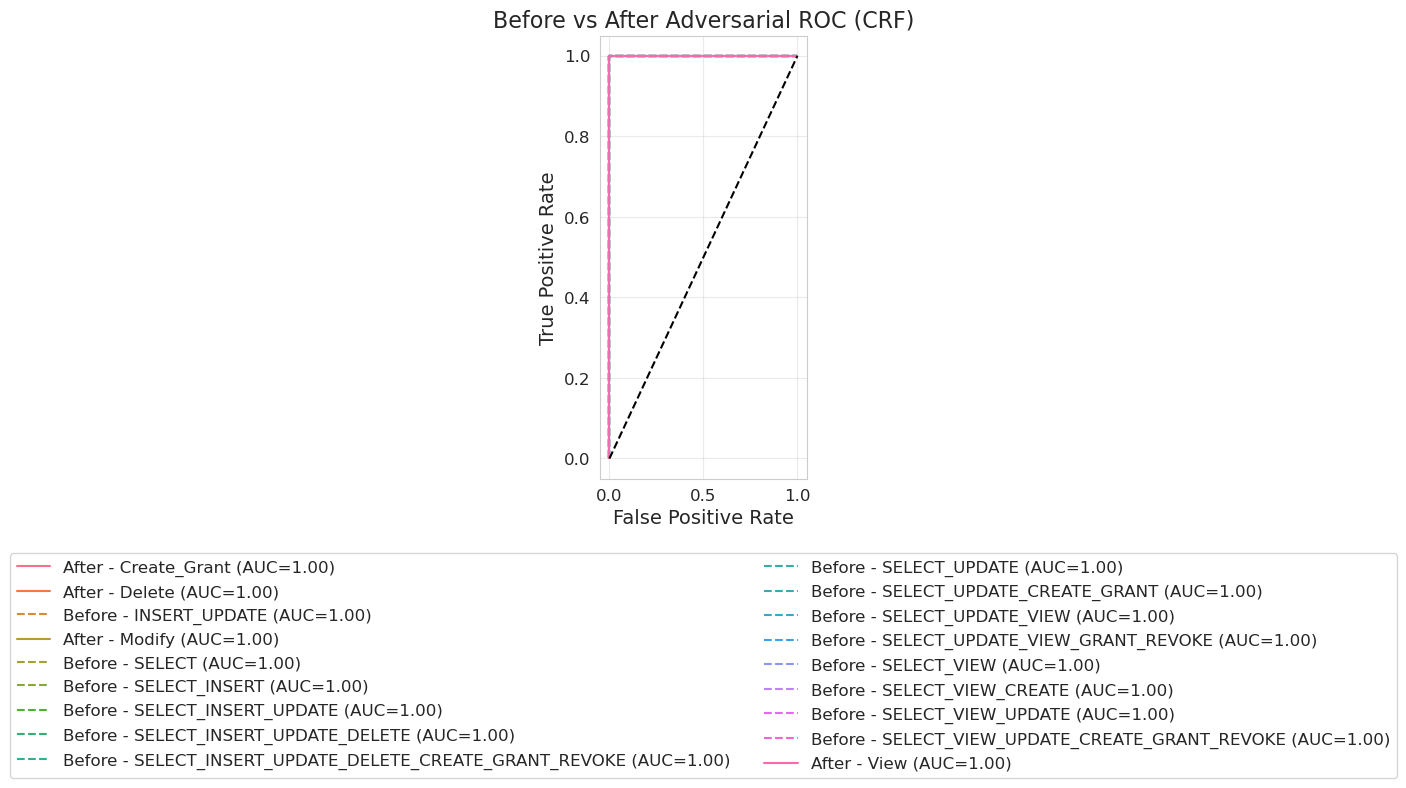

Saved plot: paper_outputs_synthetic/synthetic_section_10_crf_attack_detection_roc.jpg


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


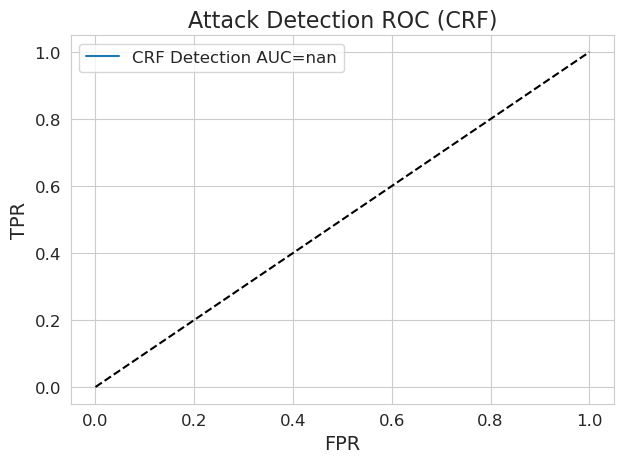

CRF Detection AUC: nan
Saved table: paper_outputs_synthetic/synthetic_section_9B_crf_detection_summary.jpg


In [84]:
# ==========================================================
# 9B) BEFORE vs AFTER ADVERSARIAL ROC + CRF ATTACK DETECTION
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ----------------------------------------------------------
# RESTORE FROZEN CRF STATE
# ----------------------------------------------------------
if "final_crf_for_validation" in globals():
    final_crf = final_crf_for_validation

if "X_test_final_for_validation" in globals():
    X_test = X_test_final_for_validation

if "y_test_final_for_validation" in globals():
    y_test = y_test_final_for_validation

if "baseline_crf_final" in globals():
    baseline_crf = baseline_crf_final

if "y_pred_prob_base_final" in globals():
    y_pred_prob_base = y_pred_prob_base_final

# ----------------------------------------------------------
# SAFE HELPERS
# ----------------------------------------------------------
def safe_class_list_for_prob_matrix(class_list, y_prob):
    n_cols = y_prob.shape[1]
    if len(class_list) != n_cols:
        print(
            f" Class/probability mismatch: "
            f"{len(class_list)} classes vs {n_cols} columns. "
            f"Trimming to {n_cols}."
        )
    return list(class_list)[:n_cols]

def align_probabilities_safe(y_prob, source_classes, target_classes):
    source_classes = safe_class_list_for_prob_matrix(source_classes, y_prob)
    aligned = np.zeros((y_prob.shape[0], len(target_classes)))
    source_index = {cls: i for i, cls in enumerate(source_classes)}

    for j, cls in enumerate(target_classes):
        if cls in source_index:
            idx = source_index[cls]
            if idx < y_prob.shape[1]:
                aligned[:, j] = y_prob[:, idx]

    return aligned

def extract_probabilities_safe(crf_model, X_seq, class_list):
    prob_rows = []
    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)
        for m in marginals:
            prob_rows.append([m.get(cls, 0.0) for cls in class_list])
    return np.array(prob_rows)

# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
required_vars = [
    "baseline_crf",
    "final_crf",
    "X_test",
    "y_test",
    "y_test_base",
    "y_pred_prob_base",
]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("❌ Section 9B skipped.")
    print("Missing variables:", missing_vars)

else:
    # ------------------------------------------------------
    # STEP 1: UNIFIED CLASS SPACE
    # ------------------------------------------------------
    classes_base_prob = list(baseline_crf.classes_)
    classes_adv_prob  = list(final_crf.classes_)
    classes_common = sorted(set(classes_base_prob) | set(classes_adv_prob))

    # ------------------------------------------------------
    # STEP 2: FLATTEN LABELS
    # ------------------------------------------------------
    y_test_flat_base = [l for seq in y_test_base for l in seq]
    y_test_flat_adv  = [l for seq in y_test for l in seq]

    y_test_bin_base_common = label_binarize(
        y_test_flat_base,
        classes=classes_common
    )

    y_test_bin_adv_common = label_binarize(
        y_test_flat_adv,
        classes=classes_common
    )

    # ------------------------------------------------------
    # STEP 3: BUILD ADVERSARIAL PROBABILITY MATRIX
    # ------------------------------------------------------
    y_pred_prob = extract_probabilities_safe(
        final_crf,
        X_test,
        classes_adv_prob
    )

    # ------------------------------------------------------
    # STEP 4: ALIGN PROBABILITIES
    # ------------------------------------------------------
    y_pred_prob_base_aligned = align_probabilities_safe(
        y_pred_prob_base,
        classes_base_prob,
        classes_common
    )

    y_pred_prob_adv_aligned = align_probabilities_safe(
        y_pred_prob,
        classes_adv_prob,
        classes_common
    )

    # ------------------------------------------------------
    # STEP 5: BEFORE vs AFTER ADVERSARIAL ROC (CRF)
    # ------------------------------------------------------
    plt.figure(figsize=(11, 8))

    palette = sns.color_palette("husl", len(classes_common))
    color_map = {cls: palette[i] for i, cls in enumerate(classes_common)}

    plotted_crf = False

    for i, cls in enumerate(classes_common):
        try:
            if np.sum(y_test_bin_base_common[:, i]) > 0:
                fpr_b, tpr_b, _ = roc_curve(
                    y_test_bin_base_common[:, i],
                    y_pred_prob_base_aligned[:, i]
                )
                auc_b = auc(fpr_b, tpr_b)

                plt.plot(
                    fpr_b, tpr_b,
                    linestyle="--",
                    color=color_map[cls],
                    label=f"Before - {cls} (AUC={auc_b:.2f})"
                )
                plotted_crf = True

            if np.sum(y_test_bin_adv_common[:, i]) > 0:
                fpr_a, tpr_a, _ = roc_curve(
                    y_test_bin_adv_common[:, i],
                    y_pred_prob_adv_aligned[:, i]
                )
                auc_a = auc(fpr_a, tpr_a)

                plt.plot(
                    fpr_a, tpr_a,
                    linestyle="-",
                    color=color_map[cls],
                    label=f"After - {cls} (AUC={auc_a:.2f})"
                )
                plotted_crf = True

        except Exception:
            continue

    if plotted_crf:
        plt.plot([0, 1], [0, 1], "--", color="black")
        plt.title("Before vs After Adversarial ROC (CRF)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
        plt.grid(True, alpha=0.4)
        plt.tight_layout()

        if "save_current_plot" in globals():
            save_current_plot("section_9B_crf_before_after_roc")
        plt.show()
    else:
        plt.close()
        print(" No valid CRF before/after ROC curves plotted.")

    # ------------------------------------------------------
    # STEP 6: CRF ATTACK DETECTION ROC
    # ------------------------------------------------------
    y_pred_adv = final_crf.predict(X_test)

    y_test_flat = [l for seq in y_test for l in seq]
    y_pred_flat = [l for seq in y_pred_adv for l in seq]

    attack_labels = (
        np.array(y_pred_flat) != np.array(y_test_flat)
    ).astype(int)

    y_pred_prob_common = align_probabilities_safe(
        y_pred_prob,
        classes_adv_prob,
        classes_common
    )

    confidence_scores = np.max(y_pred_prob_common, axis=1)
    detection_signal = 1 - confidence_scores

    fpr_det, tpr_det, _ = roc_curve(attack_labels, detection_signal)
    det_auc = auc(fpr_det, tpr_det)

    plt.figure()
    plt.plot(fpr_det, tpr_det, label=f"CRF Detection AUC={det_auc:.2f}")
    plt.plot([0, 1], [0, 1], "--", color="black")
    plt.title("Attack Detection ROC (CRF)")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if "save_current_plot" in globals():
        save_current_plot("section_10_crf_attack_detection_roc")
    plt.show()

    print(f"CRF Detection AUC: {det_auc:.4f}")

    crf_det_df = pd.DataFrame([{
        "Detection_AUC": det_auc,
        "Mean_Confidence": float(np.mean(confidence_scores)),
        "Mean_Detection_Signal": float(np.mean(detection_signal))
    }])

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            crf_det_df.round(4),
            "section_9B_crf_detection_summary",
            title="CRF Detection Summary"
        )

Saved plot: paper_outputs_synthetic/synthetic_section_10C_hybrid_attack_detection_roc.jpg


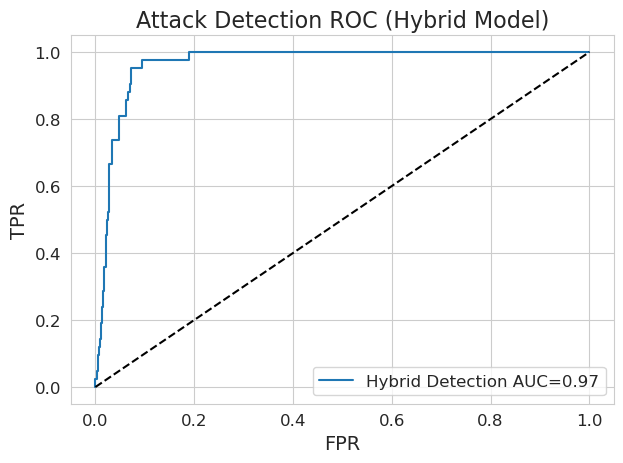

Hybrid Detection AUC: 0.9663
Saved table: paper_outputs_synthetic/synthetic_section_10C_hybrid_attack_detection_summary.jpg


In [85]:
# ==========================================================
# 10C) ATTACK DETECTION ROC (HYBRID / HGB)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

# ----------------------------------------------------------
# RESTORE FROZEN AUGMENTED HYBRID STATE
# ----------------------------------------------------------
if "tab_model_final" in globals():
    tab_model = tab_model_final

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

if "y_pred_tab_enc_final" in globals():
    y_pred_tab_enc = np.array(y_pred_tab_enc_final).copy()

if "y_prob_tab_final" in globals() and y_prob_tab_final is not None:
    y_prob_tab = np.array(y_prob_tab_final).copy()

# ----------------------------------------------------------
# MAIN BLOCK
# ----------------------------------------------------------
if all(v in globals() for v in ["tab_model", "X_test_tab", "y_test_tab_enc"]):

    if hasattr(tab_model, "predict_proba"):

        if "y_pred_tab_enc" not in globals():
            y_pred_tab_enc = tab_model.predict(X_test_tab)

        hybrid_attack_labels = (
            np.array(y_pred_tab_enc) != np.array(y_test_tab_enc)
        ).astype(int)

        if "y_prob_tab" not in globals() or y_prob_tab is None:
            y_prob_tab = tab_model.predict_proba(X_test_tab)

        hybrid_confidence_scores = np.max(y_prob_tab, axis=1)
        hybrid_detection_signal = 1 - hybrid_confidence_scores

        fpr_hyb, tpr_hyb, _ = roc_curve(
            hybrid_attack_labels,
            hybrid_detection_signal
        )
        hybrid_det_auc = auc(fpr_hyb, tpr_hyb)

        plt.figure()
        plt.plot(fpr_hyb, tpr_hyb, label=f"Hybrid Detection AUC={hybrid_det_auc:.2f}")
        plt.plot([0, 1], [0, 1], "--", color="black")
        plt.title("Attack Detection ROC (Hybrid Model)")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if "save_current_plot" in globals():
            save_current_plot("section_10C_hybrid_attack_detection_roc")
        plt.show()

        print(f"Hybrid Detection AUC: {hybrid_det_auc:.4f}")

        hybrid_det_df = pd.DataFrame([{
            "Detection_AUC": hybrid_det_auc,
            "Mean_Confidence": float(np.mean(hybrid_confidence_scores)),
            "Mean_Detection_Signal": float(np.mean(hybrid_detection_signal))
        }])

        if "save_dataframe_as_jpg" in globals():
            save_dataframe_as_jpg(
                hybrid_det_df.round(4),
                "section_10C_hybrid_attack_detection_summary",
                title="Hybrid Attack Detection Summary"
            )

    else:
        print("\nHybrid model has no predict_proba; hybrid attack detection ROC skipped.")

else:
    print("\nHybrid/HGB variables not found yet; hybrid attack detection ROC skipped.")

In [86]:
# ==========================================================
# 10D) BEFORE vs AFTER ADVERSARIAL ROC (HYBRID / HGB)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

# ----------------------------------------------------------
# RESTORE FROZEN AUGMENTED HYBRID STATE
# ----------------------------------------------------------
if "tab_model_final" in globals():
    tab_model = tab_model_final

if "label_encoder_hybrid" in globals():
    le = label_encoder_hybrid

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

# ----------------------------------------------------------
# HELPER: CRF FEATURE EXTRACTOR FOR ANY MODEL
# ----------------------------------------------------------
def extract_crf_features_for_any_model(crf_model, X_seq, class_list=None):
    if class_list is None:
        class_list = list(crf_model.classes_)

    feature_rows = []

    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)

        probs = []
        max_probs = []
        entropies = []
        class_means = {f"crf_mean_prob__{cls}": [] for cls in class_list}

        for m in marginals:
            vec = np.array([m.get(cls, 0.0) for cls in class_list], dtype=float)

            probs.extend(vec.tolist())
            max_probs.append(float(np.max(vec)))
            entropies.append(float(-np.sum(vec * np.log(vec + 1e-12))))

            for cls in class_list:
                class_means[f"crf_mean_prob__{cls}"].append(float(m.get(cls, 0.0)))

        probs = np.array(probs, dtype=float) if len(probs) > 0 else np.array([0.0])

        row = {
            "crf_prob_mean": float(np.mean(probs)),
            "crf_prob_std": float(np.std(probs)),
            "crf_prob_max": float(np.max(probs)),
            "crf_prob_min": float(np.min(probs)),
            "crf_prob_entropy_mean": float(np.mean(entropies)) if len(entropies) > 0 else 0.0,
            "crf_prob_entropy_max": float(np.max(entropies)) if len(entropies) > 0 else 0.0,
            "crf_confidence_mean": float(np.mean(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_min": float(np.min(max_probs)) if len(max_probs) > 0 else 0.0,
            "crf_confidence_std": float(np.std(max_probs)) if len(max_probs) > 0 else 0.0,
        }

        for k, vals in class_means.items():
            row[k] = float(np.mean(vals)) if len(vals) > 0 else 0.0

        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

# ----------------------------------------------------------
# SAFETY CHECKS
# ----------------------------------------------------------
required_vars = [
    "tab_model",
    "X_test_tab",
    "y_test_tab_enc",
    "summarize_sequence",
    "le"
]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("Hybrid before-vs-after ROC skipped.")
    print("Missing variables:", missing_vars)

elif not hasattr(tab_model, "predict_proba"):
    print("Hybrid model has no predict_proba; before-vs-after ROC skipped.")

else:
    # ------------------------------------------------------
    # STEP 1: GET BASELINE TEST SET
    # ------------------------------------------------------
    if "X_test_base_final" in globals() and "y_test_base_final" in globals():
        X_test_base = X_test_base_final
        y_test_base = y_test_base_final
    elif "X_test_base" in globals() and "y_test_base" in globals():
        pass
    else:
        print("Baseline hybrid comparison inputs not found; skipping Section 10D.")
        X_test_base = None

    if X_test_base is not None:
        # --------------------------------------------------
        # STEP 2: BUILD BASELINE TABULAR FEATURES
        # --------------------------------------------------
        X_test_tab_base_core = pd.DataFrame(
            [summarize_sequence(seq) for seq in X_test_base]
        ).fillna(0)

        if "baseline_crf_final" in globals():
            baseline_crf_model = baseline_crf_final
        elif "baseline_crf" in globals():
            baseline_crf_model = baseline_crf
        else:
            baseline_crf_model = None

        if baseline_crf_model is not None:
            baseline_classes = list(baseline_crf_model.classes_)
            base_crf_feats = extract_crf_features_for_any_model(
                baseline_crf_model,
                X_test_base,
                class_list=baseline_classes
            )
            X_test_tab_base = pd.concat(
                [X_test_tab_base_core.reset_index(drop=True), base_crf_feats.reset_index(drop=True)],
                axis=1
            )
        else:
            X_test_tab_base = X_test_tab_base_core.copy()

        X_test_tab_base = X_test_tab_base.reindex(
            columns=X_test_tab.columns,
            fill_value=0
        )

# --------------------------------------------------
# STEP 3: BUILD BASELINE TARGETS
# --------------------------------------------------
def sequence_target(seq_labels):
    return seq_labels[-1] if isinstance(seq_labels, list) else seq_labels

y_test_tab_base = [sequence_target(seq) for seq in y_test_base]

try:
    y_test_tab_base_enc = le.transform(y_test_tab_base)
except Exception:
    print("Some baseline labels are not in the hybrid label encoder. Filtering to shared labels.")

    known_classes = set(le.classes_)
    valid_base_mask = np.array([lbl in known_classes for lbl in y_test_tab_base])

    X_test_tab_base = X_test_tab_base.loc[valid_base_mask].reset_index(drop=True)
    y_test_tab_base = [lbl for lbl in y_test_tab_base if lbl in known_classes]

    if len(y_test_tab_base) == 0 or len(X_test_tab_base) == 0:
        print(" No shared baseline labels remain after filtering. Skipping Section 10D.")
        X_test_tab_base = None
    else:
        y_test_tab_base_enc = le.transform(y_test_tab_base)

# --------------------------------------------------
# STEP 4: HYBRID PROBABILITIES
# --------------------------------------------------
y_prob_hyb_after = tab_model.predict_proba(X_test_tab)

if X_test_tab_base is None:
    print(" Hybrid before-vs-after ROC skipped because baseline comparison set is empty.")
else:
    y_prob_hyb_before = tab_model.predict_proba(X_test_tab_base)

    # --------------------------------------------------
    # STEP 5: CLASS SPACE
    # --------------------------------------------------
    tab_classes = np.arange(len(le.classes_))

    y_test_bin_after = label_binarize(
        y_test_tab_enc,
        classes=tab_classes
    )

    y_test_bin_before = label_binarize(
        y_test_tab_base_enc,
        classes=tab_classes
    )

    common_width = min(
        y_prob_hyb_after.shape[1],
        y_prob_hyb_before.shape[1],
        y_test_bin_after.shape[1],
        y_test_bin_before.shape[1]
    )

    y_prob_hyb_after = y_prob_hyb_after[:, :common_width]
    y_prob_hyb_before = y_prob_hyb_before[:, :common_width]
    y_test_bin_after = y_test_bin_after[:, :common_width]
    y_test_bin_before = y_test_bin_before[:, :common_width]
    class_names = list(le.classes_[:common_width])

    # --------------------------------------------------
    # STEP 6: ROC CURVES
    # --------------------------------------------------
    plt.figure(figsize=(10, 7))
    plotted = False

    for i, cls_name in enumerate(class_names):
        try:
            if np.sum(y_test_bin_before[:, i]) > 0:
                fpr_b, tpr_b, _ = roc_curve(
                    y_test_bin_before[:, i],
                    y_prob_hyb_before[:, i]
                )
                auc_b = auc(fpr_b, tpr_b)

                plt.plot(
                    fpr_b,
                    tpr_b,
                    linestyle="--",
                    label=f"Before - {cls_name} (AUC={auc_b:.2f})"
                )
                plotted = True

            if np.sum(y_test_bin_after[:, i]) > 0:
                fpr_a, tpr_a, _ = roc_curve(
                    y_test_bin_after[:, i],
                    y_prob_hyb_after[:, i]
                )
                auc_a = auc(fpr_a, tpr_a)

                plt.plot(
                    fpr_a,
                    tpr_a,
                    linestyle="-",
                    label=f"After - {cls_name} (AUC={auc_a:.2f})"
                )
                plotted = True

        except Exception:
            continue

    if plotted:
        plt.plot([0, 1], [0, 1], "--", color="black")
        plt.title("Before vs After Adversarial ROC (Hybrid Model)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if "save_current_plot" in globals():
            save_current_plot("section_10D_hybrid_before_after_roc")
        plt.show()
    else:
        print("No valid ROC curves plotted for hybrid before-vs-after comparison.")
        
        # --------------------------------------------------
        # STEP 4: HYBRID PROBABILITIES
        # --------------------------------------------------
        y_prob_hyb_after = tab_model.predict_proba(X_test_tab)
        y_prob_hyb_before = tab_model.predict_proba(X_test_tab_base)

        # --------------------------------------------------
        # STEP 5: CLASS SPACE
        # --------------------------------------------------
        tab_classes = np.arange(len(le.classes_))

        y_test_bin_after = label_binarize(
            y_test_tab_enc,
            classes=tab_classes
        )

        y_test_bin_before = label_binarize(
            y_test_tab_base_enc,
            classes=tab_classes
        )

        common_width = min(
            y_prob_hyb_after.shape[1],
            y_prob_hyb_before.shape[1],
            y_test_bin_after.shape[1],
            y_test_bin_before.shape[1]
        )

        y_prob_hyb_after = y_prob_hyb_after[:, :common_width]
        y_prob_hyb_before = y_prob_hyb_before[:, :common_width]
        y_test_bin_after = y_test_bin_after[:, :common_width]
        y_test_bin_before = y_test_bin_before[:, :common_width]
        class_names = list(le.classes_[:common_width])

        # --------------------------------------------------
        # STEP 6: ROC CURVES
        # --------------------------------------------------
        plt.figure(figsize=(10, 7))
        plotted = False

        for i, cls_name in enumerate(class_names):
            try:
                if np.sum(y_test_bin_before[:, i]) > 0:
                    fpr_b, tpr_b, _ = roc_curve(
                        y_test_bin_before[:, i],
                        y_prob_hyb_before[:, i]
                    )
                    auc_b = auc(fpr_b, tpr_b)

                    plt.plot(
                        fpr_b,
                        tpr_b,
                        linestyle="--",
                        label=f"Before - {cls_name} (AUC={auc_b:.2f})"
                    )
                    plotted = True

                if np.sum(y_test_bin_after[:, i]) > 0:
                    fpr_a, tpr_a, _ = roc_curve(
                        y_test_bin_after[:, i],
                        y_prob_hyb_after[:, i]
                    )
                    auc_a = auc(fpr_a, tpr_a)

                    plt.plot(
                        fpr_a,
                        tpr_a,
                        linestyle="-",
                        label=f"After - {cls_name} (AUC={auc_a:.2f})"
                    )
                    plotted = True

            except Exception:
                continue

        if plotted:
            plt.plot([0, 1], [0, 1], "--", color="black")
            plt.title("Before vs After Adversarial ROC (Hybrid Model)")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()

            if "save_current_plot" in globals():
                save_current_plot("section_10D_hybrid_before_after_roc")
            plt.show()

        else:
            print("No valid ROC curves plotted for hybrid before-vs-after comparison.")

Some baseline labels are not in the hybrid label encoder. Filtering to shared labels.
 No shared baseline labels remain after filtering. Skipping Section 10D.
 Hybrid before-vs-after ROC skipped because baseline comparison set is empty.


In [87]:
# ==========================================================
# 11A) MULTI-RUN ROBUST EVALUATION (CRF)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
from collections import Counter
from sklearn_crfsuite import CRF
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# RESTORE FROZEN SECTION-6 / CRF STATE
# ----------------------------------------------------------
if all(v in globals() for v in ["X_train_best", "X_test_best", "y_train_best", "y_test_best"]):
    X_train = X_train_best
    X_test = X_test_best
    y_train = y_train_best
    y_test = y_test_best
else:
    raise NameError("❌ Frozen Section-6 state not found for 11A")

assert "best_params" in globals(), "❌ best_params missing from Section 7"

# ----------------------------------------------------------
# HELPER: WEIGHTED CRF PREDICTION
# ----------------------------------------------------------
def predict_weighted_crf_local(crf, X_seq, class_weights):
    y_pred_new = []

    for seq in X_seq:
        marginals = crf.predict_marginals_single(seq)
        seq_pred = []

        for m in marginals:
            weighted_scores = {
                cls: m.get(cls, 0.0) * class_weights.get(cls, 1.0)
                for cls in m
            }
            seq_pred.append(max(weighted_scores, key=weighted_scores.get))

        y_pred_new.append(seq_pred)

    return y_pred_new

# ----------------------------------------------------------
# HELPER: PROBABILITY EXTRACTION
# ----------------------------------------------------------
def extract_probabilities_for_run(crf_model, X_seq, class_list):
    prob_rows = []
    for seq in X_seq:
        marginals = crf_model.predict_marginals_single(seq)
        for m in marginals:
            prob_rows.append([m.get(cls, 0.0) for cls in class_list])
    return np.array(prob_rows)

# ----------------------------------------------------------
# MULTI-RUN
# ----------------------------------------------------------
acc_list, f1_list, auc_list = [], [], []

for run in range(5):
    print(f"\n=== CRF Run {run+1} ===")

    crf_run = CRF(
        algorithm="lbfgs",
        all_possible_transitions=True,
        c1=best_params.get("c1", 0.1),
        c2=best_params.get("c2", 0.01),
        max_iterations=best_params.get("max_iterations", 600)
    )

    idx = np.random.RandomState(42 + run).permutation(len(X_train))
    X_train_shuffled = [X_train[i] for i in idx]
    y_train_shuffled = [y_train[i] for i in idx]

    crf_run.fit(X_train_shuffled, y_train_shuffled)

    label_counts_run = Counter([lab for seq in y_train_shuffled for lab in seq])
    total_labels_run = sum(label_counts_run.values())

    class_weights_run = {
        label: total_labels_run / (len(label_counts_run) * count)
        for label, count in label_counts_run.items()
    }

    y_pred_run = predict_weighted_crf_local(crf_run, X_test, class_weights_run)

    y_test_flat_run = [lab for seq in y_test for lab in seq]
    y_pred_flat_run = [lab for seq in y_pred_run for lab in seq]

    acc_list.append(accuracy_score(y_test_flat_run, y_pred_flat_run))
    f1_list.append(
        f1_score(y_test_flat_run, y_pred_flat_run, average="macro", zero_division=0)
    )

    classes_run = list(crf_run.classes_)
    y_prob_run = extract_probabilities_for_run(crf_run, X_test, classes_run)

    confidence_scores_run = np.max(y_prob_run, axis=1)
    detection_signal_run = 1 - confidence_scores_run

    attack_labels_run = (
        np.array(y_pred_flat_run) != np.array(y_test_flat_run)
    ).astype(int)

    fpr_run, tpr_run, _ = roc_curve(attack_labels_run, detection_signal_run)
    auc_list.append(auc(fpr_run, tpr_run))

print("\n=== CRF Multi-Run Summary ===")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"F1 Score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"Det AUC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

crf_multi_run_df = pd.DataFrame([{
    "Accuracy": f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
    "F1 Score": f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
    "Det AUC": f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}",
}])

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        crf_multi_run_df,
        "section_11A_crf_multi_run_summary",
        title="CRF Multi-Run Summary"
    )


=== CRF Run 1 ===


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(



=== CRF Run 2 ===


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(



=== CRF Run 3 ===


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(



=== CRF Run 4 ===

=== CRF Run 5 ===

=== CRF Multi-Run Summary ===
Accuracy : 1.0000 ± 0.0001
F1 Score : 1.0000 ± 0.0001
Det AUC  : nan ± nan
Saved table: paper_outputs_synthetic/synthetic_section_11A_crf_multi_run_summary.jpg


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [88]:
# ==========================================================
# 11B) MULTI-RUN ROBUST EVALUATION (HYBRID / HGB)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# RESTORE FROZEN AUGMENTED MATRICES
# ----------------------------------------------------------
if "X_train_tab_final" in globals():
    X_train_tab = X_train_tab_final.copy()

if "X_test_tab_final" in globals():
    X_test_tab = X_test_tab_final.copy()

if "y_train_tab_enc_final" in globals():
    y_train_tab_enc = np.array(y_train_tab_enc_final).copy()

if "y_test_tab_enc_final" in globals():
    y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

if all(v in globals() for v in ["X_train_tab", "X_test_tab", "y_train_tab_enc", "y_test_tab_enc"]):

    acc_list_hgb, f1_list_hgb, auc_list_hgb = [], [], []

    for run in range(5):
        print(f"\n=== Hybrid Run {run+1} ===")

        model = HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.03,
            max_depth=8,
            random_state=42 + run
        )

        idx = np.random.permutation(len(X_train_tab))
        X_train_shuffled = X_train_tab.iloc[idx]
        y_train_shuffled = np.array(y_train_tab_enc)[idx]

        model.fit(X_train_shuffled, y_train_shuffled)
        y_pred_run = model.predict(X_test_tab)

        acc_list_hgb.append(accuracy_score(y_test_tab_enc, y_pred_run))
        f1_list_hgb.append(
            f1_score(y_test_tab_enc, y_pred_run, average="macro", zero_division=0)
        )

        y_prob_run = model.predict_proba(X_test_tab)
        attack_labels_run = (
            np.array(y_pred_run) != np.array(y_test_tab_enc)
        ).astype(int)

        conf = np.max(y_prob_run, axis=1)
        signal = 1 - conf
        fpr_run, tpr_run, _ = roc_curve(attack_labels_run, signal)
        auc_list_hgb.append(auc(fpr_run, tpr_run))

    print("\n=== Hybrid Multi-Run Summary ===")
    print(f"Accuracy : {np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}")
    print(f"F1 Score : {np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}")
    print(f"Det AUC  : {np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}")

    hybrid_multi_run_df = pd.DataFrame([{
        "Accuracy": f"{np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}",
        "F1 Score": f"{np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}",
        "Det AUC": f"{np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}",
    }])

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            hybrid_multi_run_df,
            "section_11B_hybrid_multi_run_summary",
            title="Hybrid Multi-Run Summary"
        )

else:
    print("Hybrid multi-run skipped (missing tabular variables)")


=== Hybrid Run 1 ===

=== Hybrid Run 2 ===

=== Hybrid Run 3 ===

=== Hybrid Run 4 ===

=== Hybrid Run 5 ===

=== Hybrid Multi-Run Summary ===
Accuracy : 0.9160 ± 0.0000
F1 Score : 0.8654 ± 0.0000
Det AUC  : 0.9663 ± 0.0000
Saved table: paper_outputs_synthetic/synthetic_section_11B_hybrid_multi_run_summary.jpg


In [89]:
# ==========================================================
# 11C) UNIFIED MULTI-RUN SUMMARY (CRF vs HYBRID)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import pandas as pd
import numpy as np

print("\n=== Multi-Run Summary (CRF vs Hybrid) ===")

# ----------------------------------------------------------
# CRF
# ----------------------------------------------------------
if all(v in globals() for v in ["acc_list", "f1_list", "auc_list"]):
    print("\n[CRF]")
    print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"F1 Score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"Det AUC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
else:
    print("\nCRF multi-run results not found")

# ----------------------------------------------------------
# HYBRID
# ----------------------------------------------------------
if all(v in globals() for v in ["acc_list_hgb", "f1_list_hgb", "auc_list_hgb"]):
    print("\n[Hybrid / HGB]")
    print(f"Accuracy : {np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}")
    print(f"F1 Score : {np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}")
    print(f"Det AUC  : {np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}")
else:
    print("\nHybrid multi-run results not found")

# ----------------------------------------------------------
# SAVE UNIFIED SUMMARY
# ----------------------------------------------------------
summary_rows = []

if all(v in globals() for v in ["acc_list", "f1_list", "auc_list"]):
    summary_rows.append({
        "Model": "CRF",
        "Accuracy": f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
        "F1 Score": f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
        "Det AUC": f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}",
    })

if all(v in globals() for v in ["acc_list_hgb", "f1_list_hgb", "auc_list_hgb"]):
    summary_rows.append({
        "Model": "Hybrid / HGB",
        "Accuracy": f"{np.nanmean(acc_list_hgb):.4f} ± {np.nanstd(acc_list_hgb):.4f}",
        "F1 Score": f"{np.nanmean(f1_list_hgb):.4f} ± {np.nanstd(f1_list_hgb):.4f}",
        "Det AUC": f"{np.nanmean(auc_list_hgb):.4f} ± {np.nanstd(auc_list_hgb):.4f}",
    })

if len(summary_rows) > 0:
    unified_multi_run_df = pd.DataFrame(summary_rows)

    if "save_dataframe_as_jpg" in globals():
        save_dataframe_as_jpg(
            unified_multi_run_df,
            "section_11C_unified_multi_run_summary",
            title="Unified Multi-Run Summary"
        )


=== Multi-Run Summary (CRF vs Hybrid) ===

[CRF]
Accuracy : 1.0000 ± 0.0001
F1 Score : 1.0000 ± 0.0001
Det AUC  : nan ± nan

[Hybrid / HGB]
Accuracy : 0.9160 ± 0.0000
F1 Score : 0.8654 ± 0.0000
Det AUC  : 0.9663 ± 0.0000
Saved table: paper_outputs_synthetic/synthetic_section_11C_unified_multi_run_summary.jpg



Robustness Summary Table:
          Model  Accuracy_mean  Accuracy_std   F1_mean        F1_std  \
0           CRF       0.999967      0.000067  0.999967  6.699473e-05   
1  Hybrid (HGB)       0.916000      0.000000  0.865441  1.110223e-16   

   DetAUC_mean  DetAUC_std  
0          NaN         NaN  
1     0.966261         0.0  
Saved table: paper_outputs_synthetic/synthetic_section_11D_robustness_table.jpg
Saved plot: paper_outputs_synthetic/synthetic_section_11D_robustness_barplot.jpg


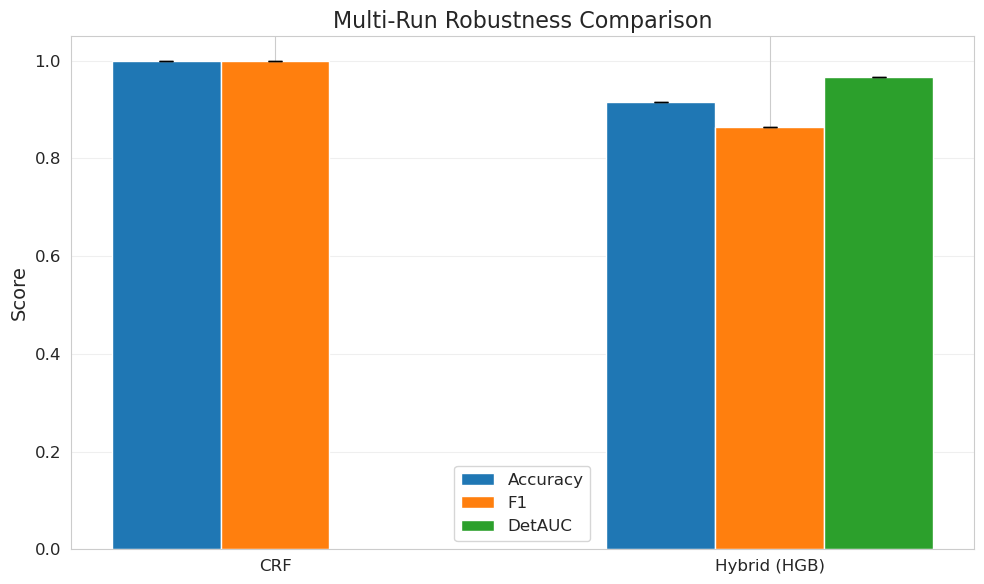


LaTeX Table:

\begin{table}
\caption{Multi-run robustness comparison of CRF and Hybrid models.}
\label{tab:multi_run_robustness}
\begin{tabular}{llll}
\toprule
Model & Accuracy & F1 & DetAUC \\
\midrule
CRF & 1.0000 $\pm$ 0.0001 & 1.0000 $\pm$ 0.0001 & nan $\pm$ nan \\
Hybrid (HGB) & 0.9160 $\pm$ 0.0000 & 0.8654 $\pm$ 0.0000 & 0.9663 $\pm$ 0.0000 \\
\bottomrule
\end{tabular}
\end{table}

Saved LaTeX: paper_outputs_synthetic/synthetic_section_11D_robustness_table.tex


In [90]:
# ==========================================================
# 11D) MULTI-RUN ROBUSTNESS VISUAL + TABLE + LATEX EXPORT
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

summary_rows = []

if all(v in globals() for v in ["acc_list", "f1_list", "auc_list"]):
    summary_rows.append({
        "Model": "CRF",
        "Accuracy_mean": np.mean(acc_list),
        "Accuracy_std": np.std(acc_list),
        "F1_mean": np.mean(f1_list),
        "F1_std": np.std(f1_list),
        "DetAUC_mean": np.mean(auc_list),
        "DetAUC_std": np.std(auc_list)
    })
else:
    print(" CRF multi-run arrays not found; CRF omitted from 11D.")

if all(v in globals() for v in ["acc_list_hgb", "f1_list_hgb", "auc_list_hgb"]):
    summary_rows.append({
        "Model": "Hybrid (HGB)",
        "Accuracy_mean": np.nanmean(acc_list_hgb),
        "Accuracy_std": np.nanstd(acc_list_hgb),
        "F1_mean": np.nanmean(f1_list_hgb),
        "F1_std": np.nanstd(f1_list_hgb),
        "DetAUC_mean": np.nanmean(auc_list_hgb),
        "DetAUC_std": np.nanstd(auc_list_hgb)
    })
else:
    print(" Hybrid multi-run arrays not found; Hybrid omitted from 11D.")

if len(summary_rows) == 0:
    print("❌ No multi-run results available for 11D.")
else:
    robustness_df = pd.DataFrame(summary_rows)

    print("\nRobustness Summary Table:")
    print(robustness_df)

    if "save_dataframe_as_jpg" in globals():
        display_df = robustness_df.copy()
        for col in display_df.columns:
            if col != "Model":
                display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")

        save_dataframe_as_jpg(
            display_df,
            "section_11D_robustness_table",
            title="Multi-Run Robustness Summary"
        )

    metrics = ["Accuracy", "F1", "DetAUC"]
    models = robustness_df["Model"].tolist()

    x = np.arange(len(models))
    width = 0.22

    fig, ax = plt.subplots(figsize=(10, 6))

    for j, metric in enumerate(metrics):
        means = robustness_df[f"{metric}_mean"].values
        stds = robustness_df[f"{metric}_std"].values

        ax.bar(
            x + (j - 1) * width,
            means,
            width,
            yerr=stds,
            capsize=5,
            label=metric
        )

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel("Score")
    ax.set_title("Multi-Run Robustness Comparison")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    if "save_current_plot" in globals():
        save_current_plot("section_11D_robustness_barplot")
    plt.show()

    latex_df = robustness_df.copy()

    for metric in ["Accuracy", "F1", "DetAUC"]:
        latex_df[metric] = latex_df.apply(
            lambda row: f"{row[f'{metric}_mean']:.4f} $\\pm$ {row[f'{metric}_std']:.4f}",
            axis=1
        )

    latex_df = latex_df[["Model", "Accuracy", "F1", "DetAUC"]]

    latex_table = latex_df.to_latex(
        index=False,
        escape=False,
        caption="Multi-run robustness comparison of CRF and Hybrid models.",
        label="tab:multi_run_robustness"
    )

    print("\nLaTeX Table:\n")
    print(latex_table)

    if "save_latex_table" in globals():
        save_latex_table(latex_table, "section_11D_robustness_table")

In [91]:
# ==========================================================
# 11E) MAIN RESULTS + MODEL COMPARISON (MATCHING LATEX STYLE)
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# MAIN PERFORMANCE RESULTS TABLE
# ----------------------------------------------------------
main_results_rows = []

main_results_rows.append({
    "Model": "CRF (semantic + weighted decoding)",
    "Accuracy": acc_crf,
    "Precision": prec_crf,
    "Recall": rec_crf,
    "F1": f1_crf,
    "ROC_AUC": auc_crf if "auc_crf" in globals() else np.nan
})

main_results_rows.append({
    "Model": f"{tab_model_name} (hybrid sequence model)",
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb if "auc_hgb" in globals() else np.nan
})

main_results_df = pd.DataFrame(main_results_rows)

print("\nMain Results Summary:")
print(main_results_df)

if "save_dataframe_as_jpg" in globals():
    jpg_df = main_results_df.copy()
    for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
        jpg_df[col] = jpg_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

    save_dataframe_as_jpg(
        jpg_df,
        "section_11E_main_results_summary",
        title="Main Performance Results"
    )

latex_main_df = main_results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    latex_main_df[col] = latex_main_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

latex_main = latex_main_df.to_latex(
    index=False,
    escape=False,
    caption="Main performance comparison of CRF and hybrid models.",
    label="tab:main_performance_results"
)

print("\nLaTeX: Main Performance Results\n")
print(latex_main)

if "save_latex_table" in globals():
    save_latex_table(latex_main, "section_11E_main_results_summary")

# ----------------------------------------------------------
# MODEL COMPARISON SUMMARY TABLE
# ----------------------------------------------------------
comparison_rows = []

if all(v in globals() for v in ["base_acc", "base_prec", "base_rec", "base_f1"]):
    comparison_rows.append({
        "Model": "Baseline CRF",
        "Accuracy": base_acc,
        "Precision": base_prec,
        "Recall": base_rec,
        "F1": base_f1,
        "ROC_AUC": base_auc if "base_auc" in globals() else np.nan
    })

if all(v in globals() for v in ["adv1_acc", "adv1_prec", "adv1_rec", "adv1_f1"]):
    comparison_rows.append({
        "Model": "Adversarial CRF (raw labels)",
        "Accuracy": adv1_acc,
        "Precision": adv1_prec,
        "Recall": adv1_rec,
        "F1": adv1_f1,
        "ROC_AUC": np.nan
    })

if all(v in globals() for v in ["adv2_acc", "adv2_prec", "adv2_rec", "adv2_f1"]):
    comparison_rows.append({
        "Model": "Adversarial CRF (semantic labels)",
        "Accuracy": adv2_acc,
        "Precision": adv2_prec,
        "Recall": adv2_rec,
        "F1": adv2_f1,
        "ROC_AUC": np.nan
    })

comparison_rows.append({
    "Model": "Adversarial CRF (semantic + weighted decoding)",
    "Accuracy": acc_crf,
    "Precision": prec_crf,
    "Recall": rec_crf,
    "F1": f1_crf,
    "ROC_AUC": auc_crf if "auc_crf" in globals() else np.nan
})

comparison_rows.append({
    "Model": f"{tab_model_name} (hybrid sequence model)",
    "Accuracy": acc_hgb,
    "Precision": prec_hgb,
    "Recall": rec_hgb,
    "F1": f1_hgb,
    "ROC_AUC": auc_hgb if "auc_hgb" in globals() else np.nan
})

comparison_df = pd.DataFrame(comparison_rows)

print("\nModel Comparison Summary:")
print(comparison_df)

if "save_dataframe_as_jpg" in globals():
    jpg_cmp_df = comparison_df.copy()
    for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
        jpg_cmp_df[col] = jpg_cmp_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

    save_dataframe_as_jpg(
        jpg_cmp_df,
        "section_11E_model_comparison_summary",
        title="Model Comparison Summary"
    )

latex_cmp_df = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    latex_cmp_df[col] = latex_cmp_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

latex_comparison = latex_cmp_df.to_latex(
    index=False,
    escape=False,
    caption="Comparative performance progression across baseline, adversarial, semantic, weighted, and hybrid models.",
    label="tab:model_comparison_summary"
)

print("\nLaTeX: Model Comparison Summary\n")
print(latex_comparison)

if "save_latex_table" in globals():
    save_latex_table(latex_comparison, "section_11E_model_comparison_summary")


Main Results Summary:
                                          Model  Accuracy  Precision  \
0            CRF (semantic + weighted decoding)     1.000   1.000000   
1  HistGradientBoosting (hybrid sequence model)     0.916   0.879872   

     Recall        F1   ROC_AUC  
0  1.000000  1.000000  1.000000  
1  0.852404  0.865441  0.990792  
Saved table: paper_outputs_synthetic/synthetic_section_11E_main_results_summary.jpg

LaTeX: Main Performance Results

\begin{table}
\caption{Main performance comparison of CRF and hybrid models.}
\label{tab:main_performance_results}
\begin{tabular}{llllll}
\toprule
Model & Accuracy & Precision & Recall & F1 & ROC_AUC \\
\midrule
CRF (semantic + weighted decoding) & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
HistGradientBoosting (hybrid sequence model) & 0.9160 & 0.8799 & 0.8524 & 0.8654 & 0.9908 \\
\bottomrule
\end{tabular}
\end{table}

Saved LaTeX: paper_outputs_synthetic/synthetic_section_11E_main_results_summary.tex

Model Comparison Summary:
 


 Section 12 using final hybrid state
Model: HistGradientBoosting
X_test_tab shape: (500, 45)
Encoded classes : 4

[CONSISTENCY CHECK]
Hybrid model used in Section 12: HistGradientBoosting
Test feature shape: (500, 45)
Encoded label count: 4

=== Baseline Hybrid Validation ===
                                   0
Accuracy                    0.916000
Precision                   0.879872
Recall                      0.852404
F1                          0.865441
ROC_AUC                     0.990792
Entropy_HY                  1.397009
Cond_Entropy_HY_given_Yhat  0.482755
Mutual_Info_IY_Yhat         0.914254
Detection_AUC               0.874506
Saved table: paper_outputs_synthetic/synthetic_section_12_baseline_hybrid_validation.jpg

=== Lattice Join Test ===
{'joined_set': {'priv_count_diff', 'is_permanent', 'YearsExperience', 'priv_signal', 'position_weight', 'Department', 'high_risk_priv_count', 'rolling_priv_std', 'Status', 'is_active', 'rolling_priv_mean', 'priv_ratio_change', 'prev_pri

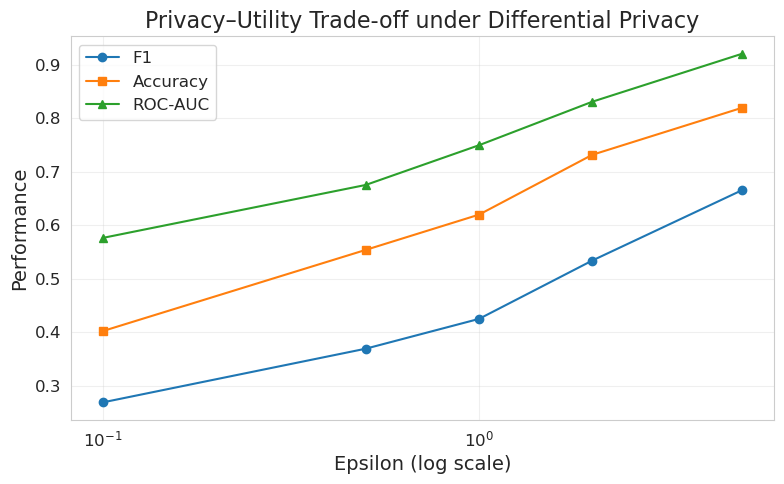

Saved plot: paper_outputs_synthetic/synthetic_section_12_epsilon_vs_leakage.jpg


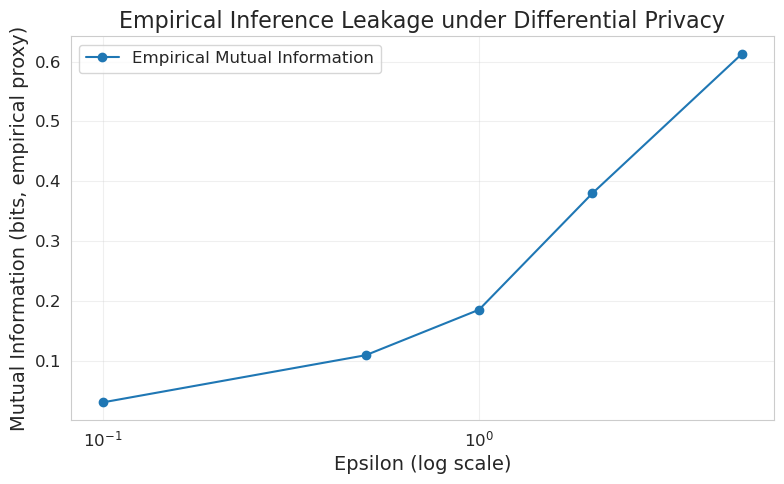

Saved plot: paper_outputs_synthetic/synthetic_section_12_epsilon_vs_detection_auc.jpg


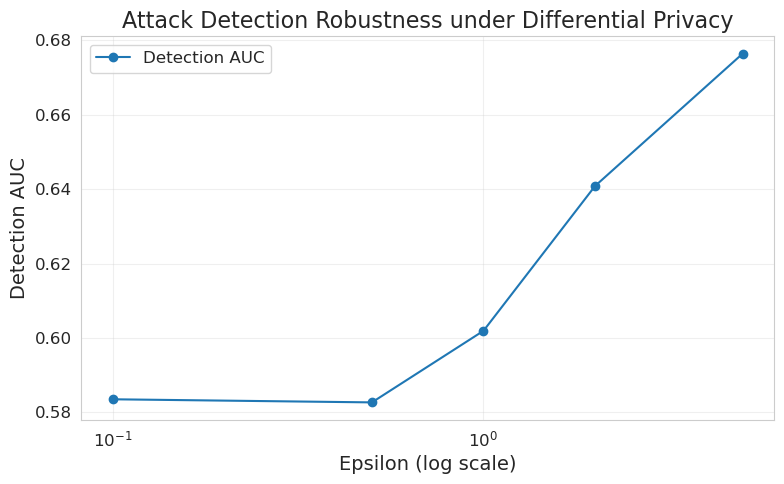

Saved plot: paper_outputs_synthetic/synthetic_section_12_core_detectors_vs_epsilon.jpg


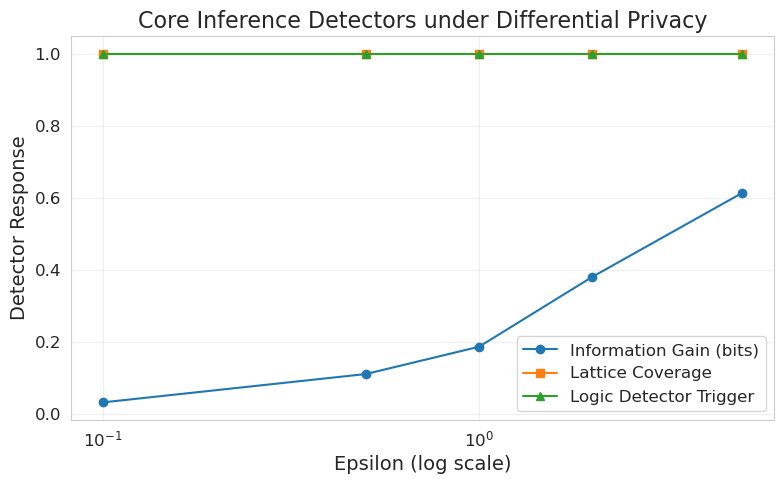


=== Validation DP Accountant History ===
                            Stage  Epsilon_Spent  Cumulative_Epsilon
0  carried_from_previous_sections       0.917573            0.917573
1               epsilon_sweep_0.1       0.100000            1.017573
2               epsilon_sweep_0.5       0.500000            1.517573
3               epsilon_sweep_1.0       1.000000            2.517573
4               epsilon_sweep_2.0       2.000000            4.517573
5               epsilon_sweep_5.0       5.000000            9.517573
Saved table: paper_outputs_synthetic/synthetic_section_12_validation_dp_history.jpg
Saved LaTeX: paper_outputs_synthetic/synthetic_section_12_baseline_hybrid_validation.tex
Saved LaTeX: paper_outputs_synthetic/synthetic_section_12_epsilon_sweep_results.tex
Saved LaTeX: paper_outputs_synthetic/synthetic_section_12_core_detector_validation.tex
 Section 12 complete


In [92]:
# ==========================================================
# 12) INFORMATION-THEORETIC + PRIVACY VALIDATION
#      (SYNTHETIC / BENCHMARK COMPATIBLE)
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ----------------------------------------------------------
# OUTPUT DIRECTORY
# ----------------------------------------------------------
if "EXPORT_DIR" in globals():
    os.makedirs(EXPORT_DIR, exist_ok=True)
else:
    EXPORT_DIR = "paper_outputs_jpg"
    os.makedirs(EXPORT_DIR, exist_ok=True)

# ==========================================================
# 12A) RESTORE FINAL AUGMENTED HYBRID + CRF STATE
# ==========================================================
required_restore_vars = [
    "tab_model_final",
    "X_test_tab_final",
    "y_test_tab_enc_final",
    "final_crf_for_validation"
]

missing_restore_vars = [v for v in required_restore_vars if v not in globals()]

if missing_restore_vars:
    raise NameError(f"❌ Section 12 missing frozen variables: {missing_restore_vars}")

# Restore hybrid
tab_model = tab_model_final
X_test_tab = X_test_tab_final.copy()
y_test_tab_enc = np.array(y_test_tab_enc_final).copy()

if "X_train_tab_final" in globals():
    X_train_tab = X_train_tab_final.copy()

if "y_train_tab_enc_final" in globals():
    y_train_tab_enc = np.array(y_train_tab_enc_final).copy()

if "label_encoder_hybrid" in globals():
    le = label_encoder_hybrid

if "tab_model_name_final" in globals():
    tab_model_name = tab_model_name_final
else:
    tab_model_name = "Hybrid"

# Restore CRF + sequence objects
final_crf = final_crf_for_validation

if "X_test_final_for_validation" in globals():
    X_test = X_test_final_for_validation

if "y_test_final_for_validation" in globals():
    y_test = y_test_final_for_validation

if "X_train_final_for_validation" in globals():
    X_train = X_train_final_for_validation

if "y_train_final_for_validation" in globals():
    y_train = y_train_final_for_validation

# Optional cached predictions
if "y_pred_tab_enc_final" in globals():
    y_pred_hybrid = np.array(y_pred_tab_enc_final).copy()
else:
    y_pred_hybrid = tab_model.predict(X_test_tab)

if "y_prob_tab_final" in globals() and y_prob_tab_final is not None:
    y_prob_hybrid = np.array(y_prob_tab_final).copy()
else:
    if hasattr(tab_model, "predict_proba"):
        y_prob_hybrid = tab_model.predict_proba(X_test_tab)
    else:
        raise ValueError("❌ Hybrid model must support predict_proba for Section 12 validation.")

# Optional baseline objects
if "baseline_crf_final" in globals():
    baseline_crf = baseline_crf_final
elif "baseline_crf" in globals():
    baseline_crf = baseline_crf

if "X_test_base_final" in globals():
    X_test_base = X_test_base_final

if "y_test_base_final" in globals():
    y_test_base = y_test_base_final

# Schema check
if "hybrid_feature_columns_final" in globals():
    assert list(X_test_tab.columns) == list(hybrid_feature_columns_final), \
        "❌ Section 12 feature schema mismatch"

print("\n Section 12 using final hybrid state")
print("Model:", tab_model_name)
print("X_test_tab shape:", X_test_tab.shape)
print("Encoded classes :", len(np.unique(y_test_tab_enc)))

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def empirical_entropy(labels):
    labels = np.array(labels)
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return float(-np.sum(probs * np.log2(probs + 1e-12)))

def empirical_conditional_entropy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    total = len(y_true)
    if total == 0:
        return 0.0

    cond_entropy = 0.0
    for pred_val in np.unique(y_pred):
        idx = (y_pred == pred_val)
        subset = y_true[idx]
        weight = len(subset) / total
        cond_entropy += weight * empirical_entropy(subset)

    return float(cond_entropy)

def empirical_mutual_information(y_true, y_pred):
    h_y = empirical_entropy(y_true)
    h_y_given_pred = empirical_conditional_entropy(y_true, y_pred)
    return max(0.0, float(h_y - h_y_given_pred))

def add_laplace_noise_to_df(X_df, epsilon=1.0, sensitivity=1.0, exclude_cols=None, seed=42):
    X_noisy = X_df.copy()
    rng = np.random.default_rng(seed)

    if exclude_cols is None:
        exclude_cols = []

    numeric_cols = X_noisy.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

    if epsilon <= 0:
        raise ValueError("❌ epsilon must be > 0")

    scale = sensitivity / epsilon

    for col in numeric_cols:
        noise = rng.laplace(0.0, scale, size=len(X_noisy))
        X_noisy[col] = X_noisy[col].astype(float) + noise

    return X_noisy

def compute_anomaly_scores_from_hybrid_probs(y_prob, extra_feature_df=None):
    max_conf = np.max(y_prob, axis=1)
    inv_conf = 1.0 - max_conf
    pred_entropy = -np.sum(y_prob * np.log(y_prob + 1e-12), axis=1)

    if extra_feature_df is not None and "seq_len" in extra_feature_df.columns:
        seq_len_feat = extra_feature_df["seq_len"].values.astype(float)
        seq_len_feat = seq_len_feat / (np.max(seq_len_feat) + 1e-8)
    else:
        seq_len_feat = np.zeros_like(inv_conf)

    if extra_feature_df is not None and "priv_signal__abs_mean" in extra_feature_df.columns:
        priv_signal_feat = extra_feature_df["priv_signal__abs_mean"].values.astype(float)
        priv_signal_feat = priv_signal_feat / (np.max(np.abs(priv_signal_feat)) + 1e-8)
    else:
        priv_signal_feat = np.zeros_like(inv_conf)

    beta0 = -1.0
    beta1 = 2.0
    beta2 = 1.5
    beta3 = 0.5
    beta4 = 1.0

    linear = (
        beta0
        + beta1 * inv_conf
        + beta2 * pred_entropy
        + beta3 * seq_len_feat
        + beta4 * priv_signal_feat
    )

    alpha_q = 1.0 / (1.0 + np.exp(-linear))
    return alpha_q

class ValidationDPAccountant:
    def __init__(self, epsilon_budget=20.0):
        self.epsilon_budget = float(epsilon_budget)
        self.epsilon_spent = 0.0
        self.history = []

    def spend(self, epsilon, stage):
        self.epsilon_spent += float(epsilon)
        self.history.append((stage, float(epsilon), float(self.epsilon_spent)))

    def remaining(self):
        return self.epsilon_budget - self.epsilon_spent

    def summary_df(self):
        return pd.DataFrame(
            self.history,
            columns=["Stage", "Epsilon_Spent", "Cumulative_Epsilon"]
        )

# ==========================================================
# CORE INFERENCE DETECTORS
# ==========================================================
def lattice_join_test(access_sets, sensitive_target):
    joined = set()
    for s in access_sets:
        joined |= set(s)

    sensitive_target = set(sensitive_target)
    coverage = len(joined & sensitive_target) / len(sensitive_target) if len(sensitive_target) > 0 else 0.0

    return {
        "joined_set": joined,
        "coverage": float(coverage),
        "detected": bool(coverage >= 1.0)
    }

def logic_closure_detector(observable_facts, sensitive_predicates, inference_rules=None):
    observed = set(observable_facts)
    closure = set(observed)

    if inference_rules is None:
        inference_rules = {}

    changed = True
    while changed:
        changed = False
        for derived_fact, prereqs in inference_rules.items():
            prereqs = set(prereqs)
            if prereqs.issubset(closure) and derived_fact not in closure:
                closure.add(derived_fact)
                changed = True

    sensitive_predicates = set(sensitive_predicates)
    triggered = closure & sensitive_predicates

    return {
        "closure": closure,
        "triggered_sensitive_predicates": triggered,
        "detected": len(triggered) > 0
    }

def information_gain_detector(y_true, y_pred, threshold_bits=0.05):
    h_before = empirical_entropy(y_true)
    h_after = empirical_conditional_entropy(y_true, y_pred)
    info_gain = max(0.0, h_before - h_after)

    return {
        "entropy_before": float(h_before),
        "entropy_after": float(h_after),
        "info_gain_bits": float(info_gain),
        "threshold_bits": float(threshold_bits),
        "detected": bool(info_gain >= threshold_bits)
    }

# ==========================================================
# PRACTICAL PROXIES
# ==========================================================
def sequence_access_proxy(seq):
    touched = set()
    for record in seq:
        if isinstance(record, dict):
            touched.update(record.keys())
    return touched

if "X_test" in globals() and len(X_test) > 0:
    access_sets_proxy = [sequence_access_proxy(seq) for seq in X_test[:20]]
else:
    access_sets_proxy = [
        {"priv_count", "rolling_priv_mean"},
        {"priv_signal", "rolling_priv_std"},
        {"priv_count_diff", "seq_len"}
    ]

sensitive_target_proxy = {"priv_signal", "priv_count", "rolling_priv_std"}

observable_facts_proxy = set()
if isinstance(X_test_tab, pd.DataFrame):
    if "priv_signal__abs_mean" in X_test_tab.columns:
        observable_facts_proxy.add("high_priv_signal")
    if "seq_len" in X_test_tab.columns:
        observable_facts_proxy.add("long_sequence")
    if "volatility_gap__mean" in X_test_tab.columns:
        observable_facts_proxy.add("volatility_shift_detected")
    if "crf_confidence_mean" in X_test_tab.columns:
        observable_facts_proxy.add("structured_model_confidence")
    if "crf_prob_entropy_mean" in X_test_tab.columns:
        observable_facts_proxy.add("structured_model_uncertainty")

inference_rules_proxy = {
    "possible_privilege_escalation": {"high_priv_signal", "volatility_shift_detected"},
    "sensitive_behaviour_pattern": {"possible_privilege_escalation", "long_sequence"},
    "probabilistic_risk_alert": {"structured_model_confidence", "structured_model_uncertainty"}
}

sensitive_predicates_proxy = {
    "possible_privilege_escalation",
    "sensitive_behaviour_pattern",
    "probabilistic_risk_alert"
}

# ==========================================================
# STEP 1: BASELINE HYBRID VALIDATION
# ==========================================================
print("\n[CONSISTENCY CHECK]")
print("Hybrid model used in Section 12:", tab_model_name)
print("Test feature shape:", X_test_tab.shape)
print("Encoded label count:", len(np.unique(y_test_tab_enc)))

acc_hgb_val = accuracy_score(y_test_tab_enc, y_pred_hybrid)
prec_hgb_val = precision_score(y_test_tab_enc, y_pred_hybrid, average="macro", zero_division=0)
rec_hgb_val = recall_score(y_test_tab_enc, y_pred_hybrid, average="macro", zero_division=0)
f1_hgb_val = f1_score(y_test_tab_enc, y_pred_hybrid, average="macro", zero_division=0)

tab_classes = np.unique(y_test_tab_enc)
y_test_tab_bin = label_binarize(y_test_tab_enc, classes=tab_classes)

auc_hgb_val = roc_auc_score(
    y_test_tab_bin,
    y_prob_hybrid,
    average="macro",
    multi_class="ovr"
)

h_sensitive = empirical_entropy(y_test_tab_enc)
h_sensitive_given_pred = empirical_conditional_entropy(y_test_tab_enc, y_pred_hybrid)
mi_sensitive_pred = empirical_mutual_information(y_test_tab_enc, y_pred_hybrid)

alpha_q = compute_anomaly_scores_from_hybrid_probs(
    y_prob_hybrid,
    extra_feature_df=X_test_tab if isinstance(X_test_tab, pd.DataFrame) else None
)

hybrid_attack_labels = (np.array(y_pred_hybrid) != np.array(y_test_tab_enc)).astype(int)
fpr_det_h, tpr_det_h, _ = roc_curve(hybrid_attack_labels, alpha_q)
det_auc_hgb = auc(fpr_det_h, tpr_det_h)

baseline_validation_df = pd.DataFrame([{
    "Accuracy": acc_hgb_val,
    "Precision": prec_hgb_val,
    "Recall": rec_hgb_val,
    "F1": f1_hgb_val,
    "ROC_AUC": auc_hgb_val,
    "Entropy_HY": h_sensitive,
    "Cond_Entropy_HY_given_Yhat": h_sensitive_given_pred,
    "Mutual_Info_IY_Yhat": mi_sensitive_pred,
    "Detection_AUC": det_auc_hgb
}])

print("\n=== Baseline Hybrid Validation ===")
print(baseline_validation_df.T)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        baseline_validation_df.round(4),
        "section_12_baseline_hybrid_validation",
        title="Baseline Hybrid Information-Theoretic Validation"
    )

# ==========================================================
# STEP 1B: CORE DETECTOR VALIDATION
# ==========================================================
lattice_result = lattice_join_test(
    access_sets=access_sets_proxy,
    sensitive_target=sensitive_target_proxy
)

logic_result = logic_closure_detector(
    observable_facts=observable_facts_proxy,
    sensitive_predicates=sensitive_predicates_proxy,
    inference_rules=inference_rules_proxy
)

info_gain_result = information_gain_detector(
    y_true=y_test_tab_enc,
    y_pred=y_pred_hybrid,
    threshold_bits=0.05
)

print("\n=== Lattice Join Test ===")
print(lattice_result)

print("\n=== Logic-Closure Detector ===")
print(logic_result)

print("\n=== Information-Gain Detector ===")
print(info_gain_result)

detector_summary_df = pd.DataFrame([{
    "Lattice_Coverage": lattice_result["coverage"],
    "Lattice_Detected": lattice_result["detected"],
    "Logic_Detected": logic_result["detected"],
    "Logic_Triggered": ", ".join(sorted(logic_result["triggered_sensitive_predicates"])) if len(logic_result["triggered_sensitive_predicates"]) > 0 else "None",
    "Entropy_Before": info_gain_result["entropy_before"],
    "Entropy_After": info_gain_result["entropy_after"],
    "Info_Gain_Bits": info_gain_result["info_gain_bits"],
    "Info_Gain_Detected": info_gain_result["detected"]
}])

print("\n=== Core Detector Validation Summary ===")
print(detector_summary_df.T)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        detector_summary_df.round(4),
        "section_12_core_detector_validation",
        title="Core Inference Detector Validation"
    )

# ==========================================================
# STEP 2: EPSILON SWEEP (HYBRID UTILITY)
# ==========================================================
epsilon_values = [0.1, 0.5, 1.0, 2.0, 5.0]

base_epsilon_spent = 0.0
if "dp_accountant" in globals() and hasattr(dp_accountant, "epsilon_spent"):
    base_epsilon_spent = float(dp_accountant.epsilon_spent)

validation_accountant = ValidationDPAccountant(epsilon_budget=20.0)
validation_accountant.epsilon_spent = base_epsilon_spent

if base_epsilon_spent > 0:
    validation_accountant.history.append(
        ("carried_from_previous_sections", base_epsilon_spent, base_epsilon_spent)
    )

epsilon_results = []

for eps in epsilon_values:
    print(f"\n=== ε Sweep: epsilon = {eps} ===")
    validation_accountant.spend(eps, stage=f"epsilon_sweep_{eps}")

    X_noisy = add_laplace_noise_to_df(
        X_test_tab,
        epsilon=eps,
        sensitivity=1.0,
        exclude_cols=[],
        seed=42
    )

    y_pred_eps = tab_model.predict(X_noisy)
    y_prob_eps = tab_model.predict_proba(X_noisy)

    acc_eps = accuracy_score(y_test_tab_enc, y_pred_eps)
    prec_eps = precision_score(y_test_tab_enc, y_pred_eps, average="macro", zero_division=0)
    rec_eps = recall_score(y_test_tab_enc, y_pred_eps, average="macro", zero_division=0)
    f1_eps = f1_score(y_test_tab_enc, y_pred_eps, average="macro", zero_division=0)

    auc_eps = roc_auc_score(
        y_test_tab_bin,
        y_prob_eps,
        average="macro",
        multi_class="ovr"
    )

    h_y = empirical_entropy(y_test_tab_enc)
    h_y_given_pred_eps = empirical_conditional_entropy(y_test_tab_enc, y_pred_eps)
    mi_eps = empirical_mutual_information(y_test_tab_enc, y_pred_eps)

    alpha_eps = compute_anomaly_scores_from_hybrid_probs(
        y_prob_eps,
        extra_feature_df=X_noisy if isinstance(X_noisy, pd.DataFrame) else None
    )

    attack_labels_eps = (np.array(y_pred_eps) != np.array(y_test_tab_enc)).astype(int)
    fpr_eps_det, tpr_eps_det, _ = roc_curve(attack_labels_eps, alpha_eps)
    det_auc_eps = auc(fpr_eps_det, tpr_eps_det)

    lattice_result_eps = lattice_join_test(
        access_sets=access_sets_proxy,
        sensitive_target=sensitive_target_proxy
    )

    logic_result_eps = logic_closure_detector(
        observable_facts=observable_facts_proxy,
        sensitive_predicates=sensitive_predicates_proxy,
        inference_rules=inference_rules_proxy
    )

    info_gain_result_eps = information_gain_detector(
        y_true=y_test_tab_enc,
        y_pred=y_pred_eps,
        threshold_bits=0.05
    )

    epsilon_results.append({
        "epsilon": eps,
        "Accuracy": acc_eps,
        "Precision": prec_eps,
        "Recall": rec_eps,
        "F1": f1_eps,
        "ROC_AUC": auc_eps,
        "Entropy_HY": h_y,
        "Cond_Entropy_HY_given_Yhat": h_y_given_pred_eps,
        "Mutual_Info_IY_Yhat": mi_eps,
        "Detection_AUC": det_auc_eps,
        "Lattice_Coverage": lattice_result_eps["coverage"],
        "Lattice_Detected": lattice_result_eps["detected"],
        "Logic_Detected": logic_result_eps["detected"],
        "Info_Gain_Bits": info_gain_result_eps["info_gain_bits"],
        "Info_Gain_Detected": info_gain_result_eps["detected"],
        "Cumulative_Epsilon": validation_accountant.epsilon_spent
    })

epsilon_results_df = pd.DataFrame(epsilon_results)

print("\n=== Epsilon Sweep Results ===")
print(epsilon_results_df.round(4))

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        epsilon_results_df.round(4),
        "section_12_epsilon_sweep_results",
        title="Privacy–Utility Trade-off under Epsilon Sweep",
        fontsize=8
    )

# ==========================================================
# STEP 3: PLOTS
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(epsilon_results_df["epsilon"], epsilon_results_df["F1"], marker="o", label="F1")
plt.plot(epsilon_results_df["epsilon"], epsilon_results_df["Accuracy"], marker="s", label="Accuracy")
plt.plot(epsilon_results_df["epsilon"], epsilon_results_df["ROC_AUC"], marker="^", label="ROC-AUC")
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Performance")
plt.title("Privacy–Utility Trade-off under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_privacy_utility_tradeoff")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Mutual_Info_IY_Yhat"],
    marker="o",
    label="Empirical Mutual Information"
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Mutual Information (bits, empirical proxy)")
plt.title("Empirical Inference Leakage under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_epsilon_vs_leakage")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Detection_AUC"],
    marker="o",
    label="Detection AUC"
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Detection AUC")
plt.title("Attack Detection Robustness under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_epsilon_vs_detection_auc")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Info_Gain_Bits"],
    marker="o",
    label="Information Gain (bits)"
)
plt.plot(
    epsilon_results_df["epsilon"],
    epsilon_results_df["Lattice_Coverage"],
    marker="s",
    label="Lattice Coverage"
)
logic_detect_numeric = epsilon_results_df["Logic_Detected"].astype(float)
plt.plot(
    epsilon_results_df["epsilon"],
    logic_detect_numeric,
    marker="^",
    label="Logic Detector Trigger"
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Detector Response")
plt.title("Core Inference Detectors under Differential Privacy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
if "save_current_plot" in globals():
    save_current_plot("section_12_core_detectors_vs_epsilon")
plt.show()

# ==========================================================
# STEP 4: DP HISTORY
# ==========================================================
validation_dp_history_df = validation_accountant.summary_df()

print("\n=== Validation DP Accountant History ===")
print(validation_dp_history_df)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        validation_dp_history_df.round(4),
        "section_12_validation_dp_history",
        title="Validation Privacy Budget History"
    )

# ==========================================================
# STEP 5: LATEX EXPORTS
# ==========================================================
baseline_validation_latex = baseline_validation_df.round(4).to_latex(
    index=False,
    escape=False,
    caption="Baseline information-theoretic and privacy-aware validation of the final hybrid IADPS model.",
    label="tab:baseline_hybrid_validation"
)

epsilon_sweep_latex = epsilon_results_df.round(4).to_latex(
    index=False,
    escape=False,
    caption="Privacy--utility evaluation of the final hybrid IADPS under varying differential privacy budgets.",
    label="tab:epsilon_sweep_results"
)

detector_validation_latex = detector_summary_df.round(4).to_latex(
    index=False,
    escape=False,
    caption="Validation of the core inference detectors in the final hybrid IADPS.",
    label="tab:core_detector_validation"
)

if "save_latex_table" in globals():
    save_latex_table(baseline_validation_latex, "section_12_baseline_hybrid_validation")
    save_latex_table(epsilon_sweep_latex, "section_12_epsilon_sweep_results")
    save_latex_table(detector_validation_latex, "section_12_core_detector_validation")

print(" Section 12 complete")

In [93]:
# ==========================================================
# 13) BiLSTM COMPARISON MODEL
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ----------------------------------------------------------
# RESTORE FROZEN SECTION-6 STATE
# ----------------------------------------------------------
if all(v in globals() for v in ["X_train_best", "X_test_best", "y_train_best", "y_test_best"]):
    X_train = X_train_best
    X_test = X_test_best
    y_train = y_train_best
    y_test = y_test_best
else:
    raise NameError("❌ Frozen Section-6 state not found for Section 13")

# ----------------------------------------------------------
# STEP 1: FEATURE KEY EXTRACTION
# ----------------------------------------------------------
assert len(X_train) > 0 and len(X_train[0]) > 0, "❌ X_train is empty"

feature_keys = sorted(list(X_train[0][0].keys()))
input_dim = len(feature_keys)

print("BiLSTM input_dim:", input_dim)

# ----------------------------------------------------------
# STEP 2: LABEL ENCODING
# ----------------------------------------------------------
all_train_labels = [lab for seq in y_train for lab in seq]

bilstm_label_encoder = LabelEncoder()
bilstm_label_encoder.fit(all_train_labels)

num_labels = len(bilstm_label_encoder.classes_)
print("BiLSTM label count:", num_labels)
print("Label space:", list(bilstm_label_encoder.classes_))

# ----------------------------------------------------------
# STEP 3: SEQUENCE CONVERSION HELPERS
# ----------------------------------------------------------
def seq_dicts_to_tensor(seq, feature_keys):
    rows = []
    for token in seq:
        row = []
        for key in feature_keys:
            val = token.get(key, 0.0)
            try:
                row.append(float(val))
            except Exception:
                row.append(0.0)
        rows.append(row)
    return torch.tensor(rows, dtype=torch.float32)

def seq_labels_to_tensor(seq_labels, label_encoder):
    encoded = label_encoder.transform(seq_labels)
    return torch.tensor(encoded, dtype=torch.long)

def prepare_bilstm_data(X_seq, y_seq, feature_keys, label_encoder):
    X_tensors = [seq_dicts_to_tensor(seq, feature_keys) for seq in X_seq]
    y_tensors = [seq_labels_to_tensor(seq, label_encoder) for seq in y_seq]

    X_pad = pad_sequence(X_tensors, batch_first=True, padding_value=0.0)
    y_pad = pad_sequence(y_tensors, batch_first=True, padding_value=-1)

    mask = (y_pad != -1)

    return X_pad, y_pad, mask

# ----------------------------------------------------------
# STEP 4: PREPARE TRAIN / TEST TENSORS
# ----------------------------------------------------------
X_train_pad, y_train_pad, mask_train = prepare_bilstm_data(
    X_train, y_train, feature_keys, bilstm_label_encoder
)

X_test_pad, y_test_pad, mask_test = prepare_bilstm_data(
    X_test, y_test, feature_keys, bilstm_label_encoder
)

print("Train tensor shape:", X_train_pad.shape)
print("Test tensor shape :", X_test_pad.shape)

# ----------------------------------------------------------
# STEP 5: DEFINE BiLSTM MODEL
# ----------------------------------------------------------
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim // 2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim, num_labels)

    def forward(self, x):
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits

bilstm_model = BiLSTM(input_dim, 128, num_labels)
print("BiLSTM model initialized.")

# ----------------------------------------------------------
# STEP 6: DEVICE SETUP
# ----------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

bilstm_model = bilstm_model.to(device)

X_train_pad = X_train_pad.to(device)
y_train_pad = y_train_pad.to(device)
mask_train = mask_train.to(device)

X_test_pad = X_test_pad.to(device)
y_test_pad = y_test_pad.to(device)
mask_test = mask_test.to(device)

# ----------------------------------------------------------
# STEP 7: TRAINING
# ----------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    bilstm_model.train()

    logits = bilstm_model(X_train_pad)
    logits = logits.view(-1, num_labels)
    targets = y_train_pad.view(-1)

    loss = criterion(logits, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}: Loss={loss.item():.4f}")

# ----------------------------------------------------------
# STEP 8: EVALUATION
# ----------------------------------------------------------
bilstm_model.eval()

with torch.no_grad():
    logits = bilstm_model(X_test_pad)
    probs = torch.softmax(logits, dim=-1).cpu().numpy()

y_pred_bilstm = np.argmax(probs, axis=-1)

y_pred_bilstm_flat = []
y_test_bilstm_flat = []

for i in range(y_test_pad.shape[0]):
    valid = mask_test[i].cpu().numpy().astype(bool)

    y_true_seq = y_test_pad[i].cpu().numpy()[valid]
    y_pred_seq = y_pred_bilstm[i][valid]

    y_test_bilstm_flat.extend(y_true_seq.tolist())
    y_pred_bilstm_flat.extend(y_pred_seq.tolist())

acc_bilstm = accuracy_score(y_test_bilstm_flat, y_pred_bilstm_flat)
prec_bilstm = precision_score(y_test_bilstm_flat, y_pred_bilstm_flat, average="macro", zero_division=0)
rec_bilstm = recall_score(y_test_bilstm_flat, y_pred_bilstm_flat, average="macro", zero_division=0)
f1_bilstm = f1_score(y_test_bilstm_flat, y_pred_bilstm_flat, average="macro", zero_division=0)

print("\n=== BiLSTM Performance ===")
print(f"Accuracy : {acc_bilstm:.4f}")
print(f"Precision: {prec_bilstm:.4f}")
print(f"Recall   : {rec_bilstm:.4f}")
print(f"F1 Score : {f1_bilstm:.4f}")

# ----------------------------------------------------------
# STEP 9: ROC-AUC
# ----------------------------------------------------------
y_prob_bilstm = []

for i in range(probs.shape[0]):
    valid = mask_test[i].cpu().numpy().astype(bool)
    y_prob_bilstm.extend(probs[i][valid].tolist())

y_prob_bilstm = np.array(y_prob_bilstm)

classes_bilstm = np.arange(num_labels)
y_test_bin_bilstm = label_binarize(y_test_bilstm_flat, classes=classes_bilstm)

try:
    auc_bilstm = roc_auc_score(
        y_test_bin_bilstm,
        y_prob_bilstm,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC-AUC : {auc_bilstm:.4f}")
except Exception as e:
    auc_bilstm = np.nan
    print("ROC-AUC skipped:", e)

# ----------------------------------------------------------
# STEP 10: SAVE SUMMARY
# ----------------------------------------------------------
bilstm_results_df = pd.DataFrame([{
    "Model": "BiLSTM",
    "Accuracy": acc_bilstm,
    "Precision": prec_bilstm,
    "Recall": rec_bilstm,
    "F1": f1_bilstm,
    "ROC_AUC": auc_bilstm
}])

print("\nBiLSTM Results Summary:")
print(bilstm_results_df)

if "save_dataframe_as_jpg" in globals():
    save_dataframe_as_jpg(
        bilstm_results_df.round(4),
        "section_13_bilstm_results_summary",
        title="BiLSTM Results Summary"
    )

# ----------------------------------------------------------
# STEP 11: FREEZE FOR SECTION 14
# ----------------------------------------------------------
bilstm_model_final = bilstm_model
feature_keys_final = feature_keys
bilstm_label_encoder_final = bilstm_label_encoder
num_labels_final = num_labels
device_final = device

print("\n Section 13 complete")
print("Frozen objects:")
print("- bilstm_model_final")
print("- feature_keys_final")
print("- bilstm_label_encoder_final")
print("- num_labels_final")
print("- device_final")

BiLSTM input_dim: 29
BiLSTM label count: 4
Label space: [np.str_('Create_Grant'), np.str_('Delete'), np.str_('Modify'), np.str_('View')]
Train tensor shape: torch.Size([1997, 12, 29])
Test tensor shape : torch.Size([500, 12, 29])
BiLSTM model initialized.
Using device: cpu
Epoch 1: Loss=1.2844
Epoch 2: Loss=1.2533
Epoch 3: Loss=1.2299
Epoch 4: Loss=1.2111
Epoch 5: Loss=1.1928
Epoch 6: Loss=1.1764
Epoch 7: Loss=1.1614
Epoch 8: Loss=1.1481
Epoch 9: Loss=1.1361
Epoch 10: Loss=1.1250

=== BiLSTM Performance ===
Accuracy : 0.6704
Precision: 0.1676
Recall   : 0.2500
F1 Score : 0.2007
ROC-AUC : 0.5524

BiLSTM Results Summary:
    Model  Accuracy  Precision  Recall        F1   ROC_AUC
0  BiLSTM  0.670447   0.167612    0.25  0.200679  0.552381
Saved table: paper_outputs_synthetic/synthetic_section_13_bilstm_results_summary.jpg

 Section 13 complete
Frozen objects:
- bilstm_model_final
- feature_keys_final
- bilstm_label_encoder_final
- num_labels_final
- device_final


 Saving BiLSTM-hybrid outputs to: paper_outputs_synthetic/bilstm_hybrid_outputs
 BiLSTM-informed hybrid feature count: 45

=== BiLSTM-Informed Hybrid Performance ===
Accuracy : 0.8080
Precision: 0.6913
Recall   : 0.6441
F1 Score : 0.6602
ROC-AUC  : 0.9363

=== Hybrid Comparison Summary ===
                                               Model  Accuracy  Precision  \
0  HistGradientBoosting (CRF-probability-augmente...     0.916   0.879872   
1                             BiLSTM-informed hybrid     0.808   0.691275   

     Recall        F1   ROC_AUC  
0  0.852404  0.865441  0.990792  
1  0.644112  0.660197  0.936312  
Saved CSV: paper_outputs_synthetic/bilstm_hybrid_outputs/bilstm_informed_hybrid_comparison.csv
Saved JPG table: paper_outputs_synthetic/bilstm_hybrid_outputs/bilstm_informed_hybrid_comparison.jpg

LaTeX Table:

\begin{table}
\caption{Comparison between the CRF-probability-augmented hybrid and the BiLSTM-informed hybrid.}
\label{tab:bilstm_informed_hybrid_comparison}
\begin

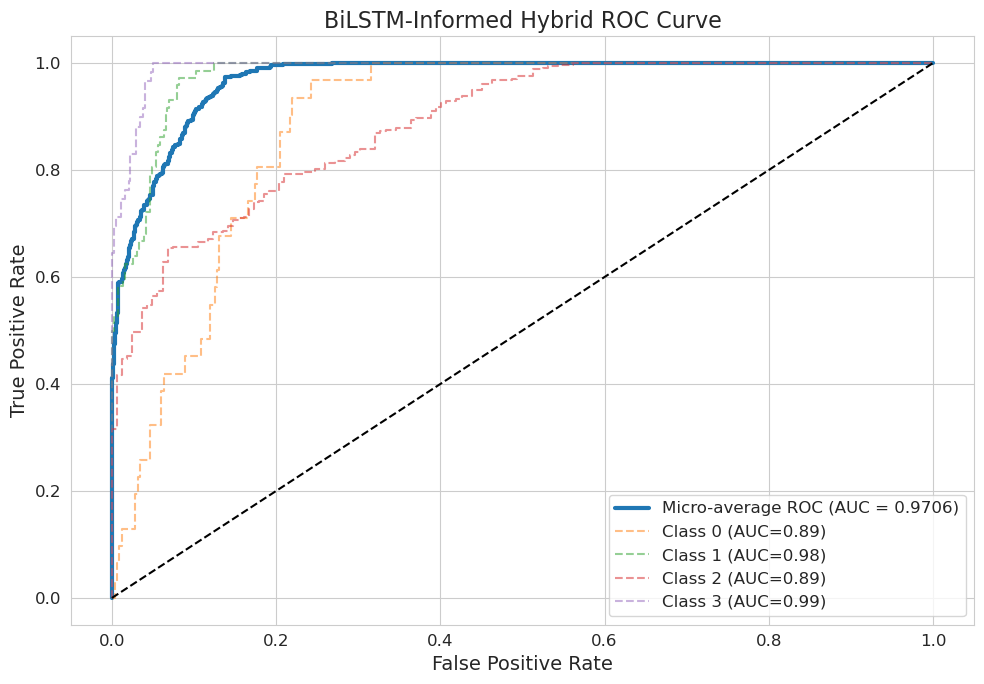

Saved plot: paper_outputs_synthetic/bilstm_hybrid_outputs/bilstm_informed_hybrid_attack_detection_roc.png


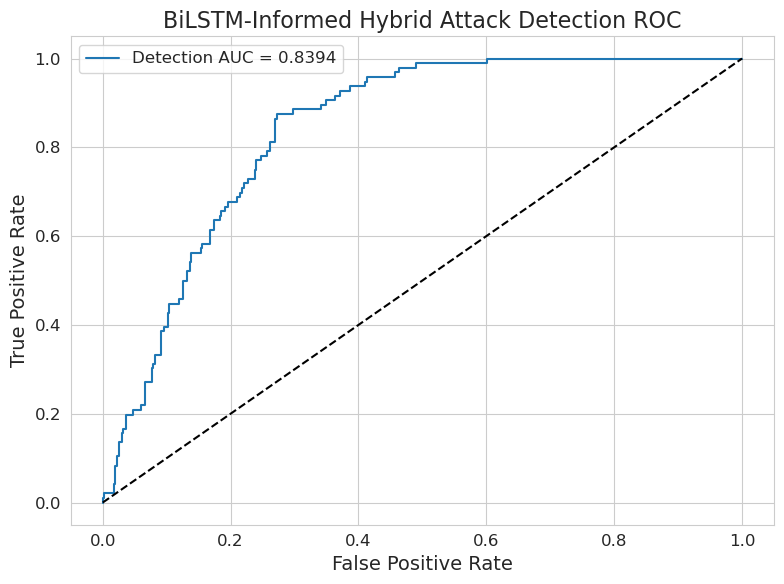

Saved CSV: paper_outputs_synthetic/bilstm_hybrid_outputs/bilstm_informed_hybrid_attack_detection.csv
Saved JPG table: paper_outputs_synthetic/bilstm_hybrid_outputs/bilstm_informed_hybrid_attack_detection.jpg
Saved CSV: paper_outputs_synthetic/bilstm_hybrid_outputs/bilstm_informed_hybrid_feature_inventory.csv

 Section 14 complete.
Outputs saved in: paper_outputs_synthetic/bilstm_hybrid_outputs


In [94]:
# ==========================================================
# 14) BiLSTM-INFORMED HYBRID COMPARISON
#    SYNTHETIC / BENCHMARK COMPATIBLE
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize, LabelEncoder
from torch.nn.utils.rnn import pad_sequence

# ----------------------------------------------------------
# OUTPUT FOLDER
# ----------------------------------------------------------
if "EXPORT_DIR" in globals():
    BILSTM_HYBRID_OUTDIR = os.path.join(EXPORT_DIR, "bilstm_hybrid_outputs")
else:
    BILSTM_HYBRID_OUTDIR = "paper_outputs_bilstm_hybrid"

os.makedirs(BILSTM_HYBRID_OUTDIR, exist_ok=True)
print(f" Saving BiLSTM-hybrid outputs to: {BILSTM_HYBRID_OUTDIR}")

# ----------------------------------------------------------
# REQUIRED OBJECTS
# ----------------------------------------------------------
required_vars = [
    "X_train_best",
    "X_test_best",
    "y_train_best",
    "y_test_best",
    "bilstm_model_final",
    "feature_keys_final",
    "num_labels_final",
    "device_final",
    "tab_model_name",
    "acc_hgb",
    "prec_hgb",
    "rec_hgb",
    "f1_hgb",
    "auc_hgb"
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"❌ Missing required variables for Section 14: {missing_vars}")

X_train = X_train_best
X_test = X_test_best
y_train = y_train_best
y_test = y_test_best

bilstm_model = bilstm_model_final
feature_keys = feature_keys_final
num_labels = num_labels_final
device = device_final

# ----------------------------------------------------------
# LOCAL SAVE HELPERS
# ----------------------------------------------------------
def save_df_local(df, filename):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved CSV: {path}")

def save_latex_local(text, filename):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, filename)
    with open(path, "w") as f:
        f.write(text)
    print(f"Saved LaTeX: {path}")

def save_plot_local(filename, dpi=300):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved plot: {path}")

def save_dataframe_as_jpg_local(df, filename, title="Table", dpi=300, fontsize=10):
    path = os.path.join(BILSTM_HYBRID_OUTDIR, f"{filename}.jpg")

    fig, ax = plt.subplots(
        figsize=(max(8, len(df.columns) * 1.5), max(2.5, len(df) * 0.55 + 1))
    )
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize + 2, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    plt.tight_layout()
    plt.savefig(path, format="jpg", dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved JPG table: {path}")

# ----------------------------------------------------------
# SAME SEQUENCE SUMMARY FUNCTION
# ----------------------------------------------------------
def summarize_sequence_for_bilstm_hybrid(seq):
    def safe_array(values):
        vals = []
        for v in values:
            try:
                vals.append(float(v))
            except Exception:
                continue
        return np.array(vals, dtype=float) if len(vals) > 0 else np.array([0.0], dtype=float)

    priv_count = safe_array([f.get("priv_count", 0) for f in seq])
    priv_diff = safe_array([f.get("priv_count_diff", 0) for f in seq])
    priv_signal = safe_array([f.get("priv_signal", 0) for f in seq])
    rolling_mean = safe_array([f.get("rolling_priv_mean", 0) for f in seq])
    rolling_std = safe_array([f.get("rolling_priv_std", 0) for f in seq])

    prev_priv_count = safe_array([f.get("prev_priv_count", 0) for f in seq])
    next_priv_count = safe_array([f.get("next_priv_count", 0) for f in seq])
    priv_acceleration = safe_array([f.get("priv_acceleration", 0) for f in seq])
    position_weight = safe_array([f.get("position_weight", 0) for f in seq])

    return {
        "seq_len": len(seq),

        "priv_count__mean": float(np.mean(priv_count)),
        "priv_count__std": float(np.std(priv_count)),
        "priv_count__max": float(np.max(priv_count)),
        "priv_count__min": float(np.min(priv_count)),
        "priv_count__last": float(priv_count[-1]),
        "priv_count__first": float(priv_count[0]),

        "priv_diff__mean": float(np.mean(priv_diff)),
        "priv_diff__std": float(np.std(priv_diff)),
        "priv_diff__max": float(np.max(priv_diff)),
        "priv_diff__min": float(np.min(priv_diff)),
        "priv_diff__abs_mean": float(np.mean(np.abs(priv_diff))),

        "priv_signal__mean": float(np.mean(priv_signal)),
        "priv_signal__std": float(np.std(priv_signal)),
        "priv_signal__max": float(np.max(priv_signal)),
        "priv_signal__min": float(np.min(priv_signal)),
        "priv_signal__abs_mean": float(np.mean(np.abs(priv_signal))),
        "priv_signal__energy": float(np.sum(priv_signal ** 2)),

        "rolling_mean__mean": float(np.mean(rolling_mean)),
        "rolling_mean__std": float(np.std(rolling_mean)),
        "rolling_std__mean": float(np.mean(rolling_std)),
        "rolling_std__max": float(np.max(rolling_std)),

        "prev_priv_count__mean": float(np.mean(prev_priv_count)),
        "next_priv_count__mean": float(np.mean(next_priv_count)),
        "priv_acceleration__mean": float(np.mean(priv_acceleration)),
        "priv_acceleration__std": float(np.std(priv_acceleration)),

        "position_weight__mean": float(np.mean(position_weight)),
        "position_weight__last": float(position_weight[-1]),

        "trend_slope": float((priv_count[-1] - priv_count[0]) / max(len(priv_count) - 1, 1)),
        "volatility_gap__mean": float(np.mean(np.abs(rolling_std - np.mean(rolling_std)))),
        "priv_count__range": float(np.max(priv_count) - np.min(priv_count)),
        "priv_signal__range": float(np.max(priv_signal) - np.min(priv_signal)),
    }

# ----------------------------------------------------------
# BUILD PADDED TENSORS
# ----------------------------------------------------------
def seq_dicts_to_tensor_local(seq, feature_keys):
    rows = []
    for token in seq:
        row = []
        for key in feature_keys:
            val = token.get(key, 0.0)
            try:
                row.append(float(val))
            except Exception:
                row.append(0.0)
        rows.append(row)
    return torch.tensor(rows, dtype=torch.float32)

def prepare_bilstm_inputs_only(X_seq, feature_keys):
    tensors = [seq_dicts_to_tensor_local(seq, feature_keys) for seq in X_seq]
    X_pad = pad_sequence(tensors, batch_first=True, padding_value=0.0)
    lengths = [len(seq) for seq in X_seq]
    return X_pad, lengths

# ----------------------------------------------------------
# EXTRACT BiLSTM PROBABILITY FEATURES
# ----------------------------------------------------------
def extract_bilstm_features(model, X_seq, feature_keys, num_labels, device):
    model.eval()

    X_pad, lengths = prepare_bilstm_inputs_only(X_seq, feature_keys)
    X_pad = X_pad.to(device)

    with torch.no_grad():
        logits = model(X_pad)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

    feature_rows = []

    for i in range(probs.shape[0]):
        seq_len = lengths[i]
        seq_probs = probs[i][:seq_len]

        flat_probs = seq_probs.reshape(-1)
        max_probs = np.max(seq_probs, axis=1)
        entropies = -np.sum(seq_probs * np.log(seq_probs + 1e-12), axis=1)

        row = {
            "bilstm_prob_mean": float(np.mean(flat_probs)),
            "bilstm_prob_std": float(np.std(flat_probs)),
            "bilstm_prob_max": float(np.max(flat_probs)),
            "bilstm_prob_min": float(np.min(flat_probs)),
            "bilstm_prob_entropy_mean": float(np.mean(entropies)),
            "bilstm_prob_entropy_max": float(np.max(entropies)),
            "bilstm_confidence_mean": float(np.mean(max_probs)),
            "bilstm_confidence_min": float(np.min(max_probs)),
            "bilstm_confidence_std": float(np.std(max_probs)),
        }

        for cls_idx in range(num_labels):
            row[f"bilstm_mean_prob__class_{cls_idx}"] = float(np.mean(seq_probs[:, cls_idx]))

        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

# ----------------------------------------------------------
# TARGETS
# ----------------------------------------------------------
def sequence_target(seq_labels):
    return seq_labels[-1]

y_train_bilstm_hybrid = [sequence_target(seq) for seq in y_train]
y_test_bilstm_hybrid  = [sequence_target(seq) for seq in y_test]

bilstm_hybrid_le = LabelEncoder()
y_train_bilstm_hybrid_enc = bilstm_hybrid_le.fit_transform(y_train_bilstm_hybrid)
y_test_bilstm_hybrid_enc  = bilstm_hybrid_le.transform(y_test_bilstm_hybrid)

# ----------------------------------------------------------
# BASE TABULAR FEATURES
# ----------------------------------------------------------
X_train_bilstm_hybrid = pd.DataFrame(
    [summarize_sequence_for_bilstm_hybrid(seq) for seq in X_train]
).fillna(0)

X_test_bilstm_hybrid = pd.DataFrame(
    [summarize_sequence_for_bilstm_hybrid(seq) for seq in X_test]
).fillna(0)

X_test_bilstm_hybrid = X_test_bilstm_hybrid.reindex(
    columns=X_train_bilstm_hybrid.columns,
    fill_value=0
)

# ----------------------------------------------------------
# BiLSTM PROBABILITY FEATURES
# ----------------------------------------------------------
bilstm_train_feats = extract_bilstm_features(
    bilstm_model, X_train, feature_keys, num_labels, device
)

bilstm_test_feats = extract_bilstm_features(
    bilstm_model, X_test, feature_keys, num_labels, device
)

X_train_bilstm_hybrid = pd.concat(
    [X_train_bilstm_hybrid.reset_index(drop=True), bilstm_train_feats.reset_index(drop=True)],
    axis=1
)

X_test_bilstm_hybrid = pd.concat(
    [X_test_bilstm_hybrid.reset_index(drop=True), bilstm_test_feats.reset_index(drop=True)],
    axis=1
)

print(" BiLSTM-informed hybrid feature count:", X_train_bilstm_hybrid.shape[1])

# ----------------------------------------------------------
# TRAIN BiLSTM-INFORMED HYBRID
# ----------------------------------------------------------
bilstm_hybrid_model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.03,
    max_depth=8,
    random_state=42
)

bilstm_hybrid_model.fit(X_train_bilstm_hybrid, y_train_bilstm_hybrid_enc)

# ----------------------------------------------------------
# PREDICTIONS + METRICS
# ----------------------------------------------------------
y_pred_bilstm_hybrid_enc = bilstm_hybrid_model.predict(X_test_bilstm_hybrid)
y_prob_bilstm_hybrid = bilstm_hybrid_model.predict_proba(X_test_bilstm_hybrid)

acc_bilstm_hybrid = accuracy_score(y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc)
prec_bilstm_hybrid = precision_score(
    y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc,
    average="macro", zero_division=0
)
rec_bilstm_hybrid = recall_score(
    y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc,
    average="macro", zero_division=0
)
f1_bilstm_hybrid = f1_score(
    y_test_bilstm_hybrid_enc, y_pred_bilstm_hybrid_enc,
    average="macro", zero_division=0
)

classes_bilstm_hybrid = np.unique(y_test_bilstm_hybrid_enc)
y_test_bin_bilstm_hybrid = label_binarize(
    y_test_bilstm_hybrid_enc,
    classes=classes_bilstm_hybrid
)

auc_bilstm_hybrid = roc_auc_score(
    y_test_bin_bilstm_hybrid,
    y_prob_bilstm_hybrid,
    average="macro",
    multi_class="ovr"
)

print("\n=== BiLSTM-Informed Hybrid Performance ===")
print(f"Accuracy : {acc_bilstm_hybrid:.4f}")
print(f"Precision: {prec_bilstm_hybrid:.4f}")
print(f"Recall   : {rec_bilstm_hybrid:.4f}")
print(f"F1 Score : {f1_bilstm_hybrid:.4f}")
print(f"ROC-AUC  : {auc_bilstm_hybrid:.4f}")

# ----------------------------------------------------------
# COMPARISON TABLE
# ----------------------------------------------------------
comparison_df = pd.DataFrame([
    {
        "Model": f"{tab_model_name} (CRF-probability-augmented hybrid)",
        "Accuracy": acc_hgb,
        "Precision": prec_hgb,
        "Recall": rec_hgb,
        "F1": f1_hgb,
        "ROC_AUC": auc_hgb
    },
    {
        "Model": "BiLSTM-informed hybrid",
        "Accuracy": acc_bilstm_hybrid,
        "Precision": prec_bilstm_hybrid,
        "Recall": rec_bilstm_hybrid,
        "F1": f1_bilstm_hybrid,
        "ROC_AUC": auc_bilstm_hybrid
    }
])

print("\n=== Hybrid Comparison Summary ===")
print(comparison_df)

save_df_local(comparison_df.round(6), "bilstm_informed_hybrid_comparison.csv")
save_dataframe_as_jpg_local(
    comparison_df.round(4),
    "bilstm_informed_hybrid_comparison",
    title="Hybrid Comparison Summary"
)

# ----------------------------------------------------------
# LATEX EXPORT
# ----------------------------------------------------------
latex_cmp_df = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    latex_cmp_df[col] = latex_cmp_df[col].map(lambda x: f"{x:.4f}")

latex_table = latex_cmp_df.to_latex(
    index=False,
    escape=False,
    caption="Comparison between the CRF-probability-augmented hybrid and the BiLSTM-informed hybrid.",
    label="tab:bilstm_informed_hybrid_comparison"
)

print("\nLaTeX Table:\n")
print(latex_table)
save_latex_local(latex_table, "bilstm_informed_hybrid_comparison.tex")

# ----------------------------------------------------------
# ROC PLOT
# ----------------------------------------------------------
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes_bilstm_hybrid)):
    try:
        if np.sum(y_test_bin_bilstm_hybrid[:, i]) > 0:
            fpr[i], tpr[i], _ = roc_curve(
                y_test_bin_bilstm_hybrid[:, i],
                y_prob_bilstm_hybrid[:, i]
            )
            roc_auc[i] = auc(fpr[i], tpr[i])
    except Exception:
        continue

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin_bilstm_hybrid.ravel(),
    y_prob_bilstm_hybrid.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 7))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})",
    linewidth=3
)

for i in roc_auc:
    if i == "micro":
        continue
    plt.plot(
        fpr[i],
        tpr[i],
        linestyle="--",
        alpha=0.5,
        label=f"Class {i} (AUC={roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BiLSTM-Informed Hybrid ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
save_plot_local("bilstm_informed_hybrid_roc.png")
plt.show()

# ----------------------------------------------------------
# ATTACK-DETECTION ROC
# ----------------------------------------------------------
attack_labels_bilstm_hybrid = (
    np.array(y_pred_bilstm_hybrid_enc) != np.array(y_test_bilstm_hybrid_enc)
).astype(int)

confidence_scores_bilstm_hybrid = np.max(y_prob_bilstm_hybrid, axis=1)
detection_signal_bilstm_hybrid = 1 - confidence_scores_bilstm_hybrid

fpr_det, tpr_det, _ = roc_curve(
    attack_labels_bilstm_hybrid,
    detection_signal_bilstm_hybrid
)
det_auc_bilstm_hybrid = auc(fpr_det, tpr_det)

plt.figure(figsize=(8, 6))
plt.plot(fpr_det, tpr_det, label=f"Detection AUC = {det_auc_bilstm_hybrid:.4f}")
plt.plot([0, 1], [0, 1], "--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BiLSTM-Informed Hybrid Attack Detection ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_plot_local("bilstm_informed_hybrid_attack_detection_roc.png")
plt.show()

attack_df = pd.DataFrame([{
    "Detection_AUC": det_auc_bilstm_hybrid,
    "Mean_Confidence": float(np.mean(confidence_scores_bilstm_hybrid)),
    "Mean_Detection_Signal": float(np.mean(detection_signal_bilstm_hybrid))
}])

save_df_local(attack_df.round(6), "bilstm_informed_hybrid_attack_detection.csv")
save_dataframe_as_jpg_local(
    attack_df.round(4),
    "bilstm_informed_hybrid_attack_detection",
    title="BiLSTM-Informed Hybrid Attack Detection"
)

# ----------------------------------------------------------
# FEATURE NAMES
# ----------------------------------------------------------
feature_inventory_df = pd.DataFrame({
    "Feature": list(X_train_bilstm_hybrid.columns)
})
save_df_local(feature_inventory_df, "bilstm_informed_hybrid_feature_inventory.csv")

print("\n Section 14 complete.")
print("Outputs saved in:", BILSTM_HYBRID_OUTDIR)

 Cross-dataset outputs will be saved to: paper_outputs_cross_dataset

=== Cross-Dataset Comparison ===
                              Model  Accuracy_Benchmark  Precision_Benchmark  \
0                            BiLSTM             0.52990               0.1948   
1            BiLSTM-informed hybrid             0.92250               0.9449   
2                               CRF             0.50225               0.3678   
3  CRF-probability-augmented hybrid             0.93000               0.9661   

   Recall_Benchmark  F1_Benchmark  ROC_AUC_Benchmark  Accuracy_Synthetic  \
0            0.2169        0.1815             0.7117              0.6704   
1            0.9202        0.9315             0.9901              0.8000   
2            0.5555        0.4033             0.8273              1.0000   
3            0.8904        0.9250             0.9937              0.9160   

   Precision_Synthetic  Recall_Synthetic  F1_Synthetic  ROC_AUC_Synthetic  
0               0.1676            0.250

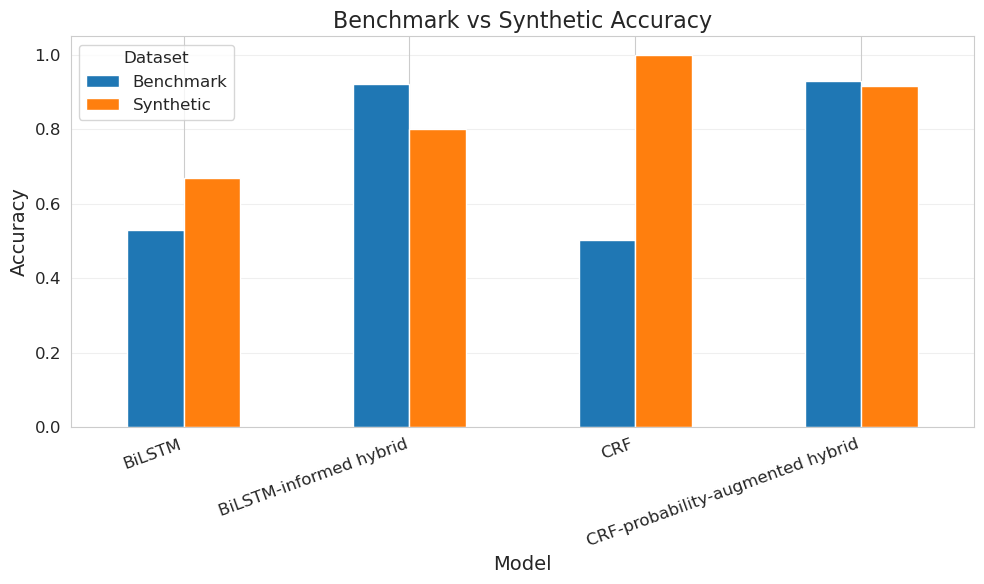

Saved plot: paper_outputs_cross_dataset/cross_dataset_f1.png


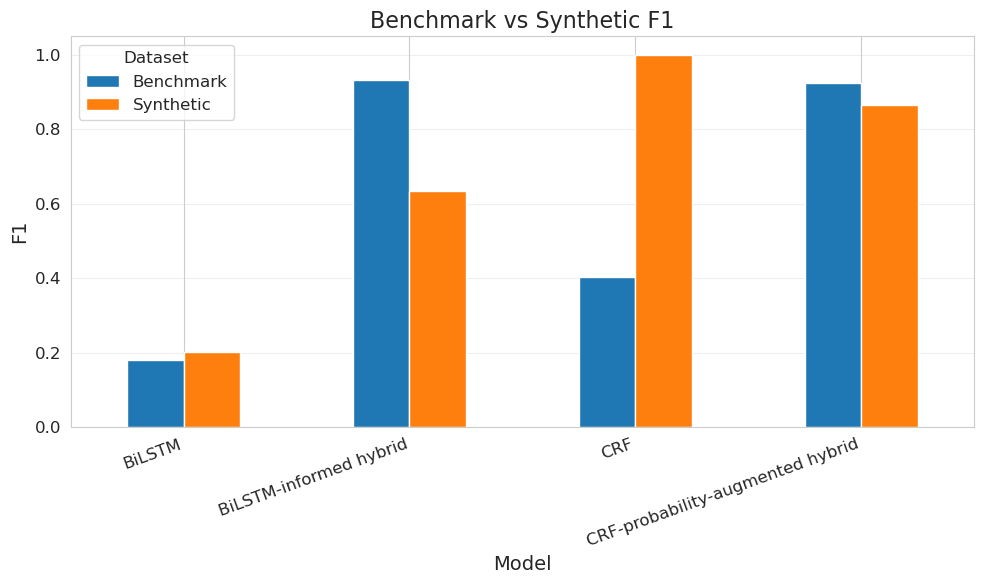

Saved plot: paper_outputs_cross_dataset/cross_dataset_roc_auc.png


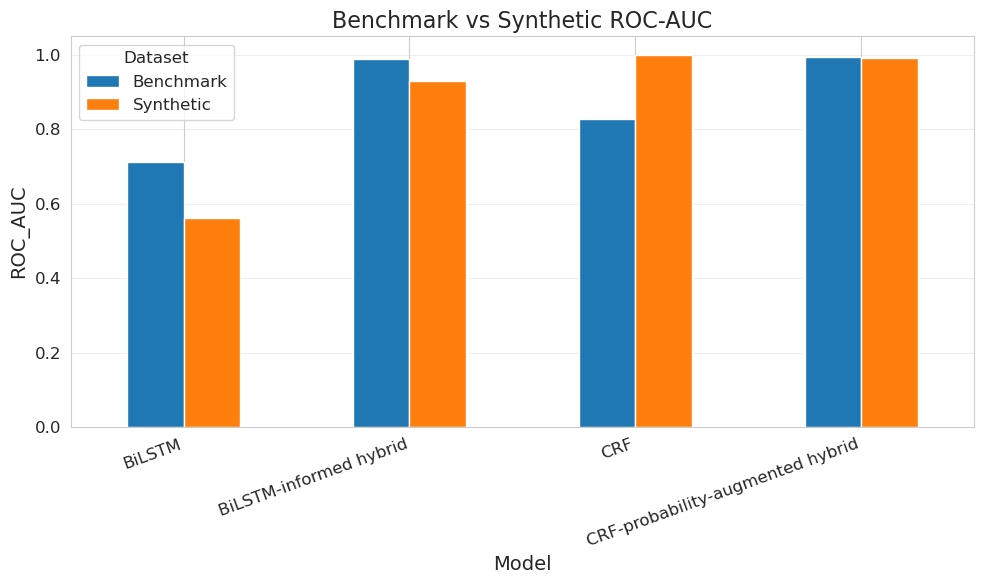


=== Synthetic - Benchmark Delta ===
                              Model  Delta_Accuracy  Delta_F1  Delta_ROC_AUC
0                            BiLSTM         0.14050    0.0192        -0.1507
1            BiLSTM-informed hybrid        -0.12250   -0.2970        -0.0605
2                               CRF         0.49775    0.5967         0.1727
3  CRF-probability-augmented hybrid        -0.01400   -0.0596        -0.0029
Saved CSV: paper_outputs_cross_dataset/cross_dataset_delta.csv
Saved JPG table: paper_outputs_cross_dataset/cross_dataset_delta.jpg

=== Regime Summary ===
                              Model   Best_Accuracy_Regime
0                            BiLSTM  Stronger on synthetic
1            BiLSTM-informed hybrid  Stronger on benchmark
2                               CRF  Stronger on synthetic
3  CRF-probability-augmented hybrid  Stronger on benchmark
Saved JPG table: paper_outputs_cross_dataset/cross_dataset_regime_summary.jpg

 Section 15 complete.
Outputs saved in: paper_ou

In [95]:
# ==========================================================
# 15) CROSS-DATASET COMPARISON TABLE
#    (BENCHMARK vs SYNTHETIC)
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# OUTPUT FOLDER
# ----------------------------------------------------------
FINAL_COMPARE_DIR = "paper_outputs_cross_dataset"
os.makedirs(FINAL_COMPARE_DIR, exist_ok=True)

print(f" Cross-dataset outputs will be saved to: {FINAL_COMPARE_DIR}")

# ----------------------------------------------------------
# LOCAL SAVE HELPERS
# ----------------------------------------------------------
def save_df_cross(df, filename):
    path = os.path.join(FINAL_COMPARE_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved CSV: {path}")

def save_latex_cross(text, filename):
    path = os.path.join(FINAL_COMPARE_DIR, filename)
    with open(path, "w") as f:
        f.write(text)
    print(f"Saved LaTeX: {path}")

def save_plot_cross(filename, dpi=300):
    path = os.path.join(FINAL_COMPARE_DIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved plot: {path}")

def save_dataframe_as_jpg_cross(df, filename, title="Table", dpi=300, fontsize=10):
    path = os.path.join(FINAL_COMPARE_DIR, f"{filename}.jpg")

    fig, ax = plt.subplots(
        figsize=(max(8, len(df.columns) * 1.6), max(2.5, len(df) * 0.6 + 1))
    )
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize + 2, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    plt.tight_layout()
    plt.savefig(path, format="jpg", dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved JPG table: {path}")

# ----------------------------------------------------------
# ENTER / CONFIRM FINAL RESULTS
# ----------------------------------------------------------
# Benchmark results
benchmark_results = [
    {
        "Model": "CRF",
        "Accuracy": 0.50225,
        "Precision": 0.3678,
        "Recall": 0.5555,
        "F1": 0.4033,
        "ROC_AUC": 0.8273
    },
    {
        "Model": "CRF-probability-augmented hybrid",
        "Accuracy": 0.9300,
        "Precision": 0.9661,
        "Recall": 0.8904,
        "F1": 0.9250,
        "ROC_AUC": 0.9937
    },
    {
        "Model": "BiLSTM",
        "Accuracy": 0.5299,
        "Precision": 0.1948,
        "Recall": 0.2169,
        "F1": 0.1815,
        "ROC_AUC": 0.7117
    },
    {
        "Model": "BiLSTM-informed hybrid",
        "Accuracy": 0.9225,
        "Precision": 0.9449,
        "Recall": 0.9202,
        "F1": 0.9315,
        "ROC_AUC": 0.9901
    }
]

# Synthetic results
synthetic_results = [
    {
        "Model": "CRF",
        "Accuracy": 1.0000,
        "Precision": 1.0000,
        "Recall": 1.0000,
        "F1": 1.0000,
        "ROC_AUC": 1.0000
    },
    {
        "Model": "CRF-probability-augmented hybrid",
        "Accuracy": 0.9160,
        "Precision": 0.8799,
        "Recall": 0.8524,
        "F1": 0.8654,
        "ROC_AUC": 0.9908
    },
    {
        "Model": "BiLSTM",
        "Accuracy": 0.6704,
        "Precision": 0.1676,
        "Recall": 0.2500,
        "F1": 0.2007,
        "ROC_AUC": 0.5610
    },
    {
        "Model": "BiLSTM-informed hybrid",
        "Accuracy": 0.8000,
        "Precision": 0.6678,
        "Recall": 0.6199,
        "F1": 0.6345,
        "ROC_AUC": 0.9296
    }
]

benchmark_df = pd.DataFrame(benchmark_results)
synthetic_df = pd.DataFrame(synthetic_results)

# ----------------------------------------------------------
# MERGE SIDE BY SIDE
# ----------------------------------------------------------
cross_df = benchmark_df.merge(
    synthetic_df,
    on="Model",
    how="outer",
    suffixes=("_Benchmark", "_Synthetic")
)

print("\n=== Cross-Dataset Comparison ===")
print(cross_df)

save_df_cross(cross_df, "cross_dataset_comparison.csv")

jpg_cross_df = cross_df.copy()
for col in jpg_cross_df.columns:
    if col != "Model":
        jpg_cross_df[col] = jpg_cross_df[col].map(
            lambda x: f"{x:.4f}" if pd.notna(x) else "N/A"
        )

save_dataframe_as_jpg_cross(
    jpg_cross_df,
    "cross_dataset_comparison",
    title="Cross-Dataset Model Comparison",
    fontsize=8
)

# ----------------------------------------------------------
# LATEX EXPORT
# ----------------------------------------------------------
latex_df = cross_df.copy()
for col in latex_df.columns:
    if col != "Model":
        latex_df[col] = latex_df[col].map(
            lambda x: f"{x:.4f}" if pd.notna(x) else "N/A"
        )

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    caption="Cross-dataset comparison of CRF, CRF-probability-augmented hybrid, BiLSTM, and BiLSTM-informed hybrid models on the benchmark and synthetic datasets.",
    label="tab:cross_dataset_comparison"
)

print("\nLaTeX Table:\n")
print(latex_table)
save_latex_cross(latex_table, "cross_dataset_comparison.tex")

# ----------------------------------------------------------
# LONG FORMAT FOR PLOTTING
# ----------------------------------------------------------
plot_rows = []
for _, row in cross_df.iterrows():
    for dataset_name in ["Benchmark", "Synthetic"]:
        plot_rows.append({
            "Model": row["Model"],
            "Dataset": dataset_name,
            "Accuracy": row.get(f"Accuracy_{dataset_name}", np.nan),
            "F1": row.get(f"F1_{dataset_name}", np.nan),
            "ROC_AUC": row.get(f"ROC_AUC_{dataset_name}", np.nan),
        })

plot_df = pd.DataFrame(plot_rows)

# ----------------------------------------------------------
# PLOT 1: ACCURACY
# ----------------------------------------------------------
metric = "Accuracy"
pivot_df = plot_df.pivot(index="Model", columns="Dataset", values=metric)

ax = pivot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Benchmark vs Synthetic Accuracy")
ax.set_ylabel(metric)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_plot_cross("cross_dataset_accuracy.png")
plt.show()

# ----------------------------------------------------------
# PLOT 2: F1
# ----------------------------------------------------------
metric = "F1"
pivot_df = plot_df.pivot(index="Model", columns="Dataset", values=metric)

ax = pivot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Benchmark vs Synthetic F1")
ax.set_ylabel(metric)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_plot_cross("cross_dataset_f1.png")
plt.show()

# ----------------------------------------------------------
# PLOT 3: ROC-AUC
# ----------------------------------------------------------
metric = "ROC_AUC"
pivot_df = plot_df.pivot(index="Model", columns="Dataset", values=metric)

ax = pivot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Benchmark vs Synthetic ROC-AUC")
ax.set_ylabel(metric)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_plot_cross("cross_dataset_roc_auc.png")
plt.show()

# ----------------------------------------------------------
# DELTA TABLE (SYNTHETIC - BENCHMARK)
# ----------------------------------------------------------
delta_rows = []
for _, row in cross_df.iterrows():
    delta_rows.append({
        "Model": row["Model"],
        "Delta_Accuracy": (
            row["Accuracy_Synthetic"] - row["Accuracy_Benchmark"]
            if pd.notna(row["Accuracy_Synthetic"]) and pd.notna(row["Accuracy_Benchmark"]) else np.nan
        ),
        "Delta_F1": (
            row["F1_Synthetic"] - row["F1_Benchmark"]
            if pd.notna(row["F1_Synthetic"]) and pd.notna(row["F1_Benchmark"]) else np.nan
        ),
        "Delta_ROC_AUC": (
            row["ROC_AUC_Synthetic"] - row["ROC_AUC_Benchmark"]
            if pd.notna(row["ROC_AUC_Synthetic"]) and pd.notna(row["ROC_AUC_Benchmark"]) else np.nan
        ),
    })

delta_df = pd.DataFrame(delta_rows)

print("\n=== Synthetic - Benchmark Delta ===")
print(delta_df)

save_df_cross(delta_df, "cross_dataset_delta.csv")

jpg_delta_df = delta_df.copy()
for col in jpg_delta_df.columns:
    if col != "Model":
        jpg_delta_df[col] = jpg_delta_df[col].map(
            lambda x: f"{x:+.4f}" if pd.notna(x) else "N/A"
        )

save_dataframe_as_jpg_cross(
    jpg_delta_df,
    "cross_dataset_delta",
    title="Synthetic - Benchmark Performance Delta",
    fontsize=8
)

# ----------------------------------------------------------
# INTERPRETIVE SUMMARY TABLE
# ----------------------------------------------------------
summary_rows = []
for _, row in cross_df.iterrows():
    if pd.isna(row["Accuracy_Benchmark"]) or pd.isna(row["Accuracy_Synthetic"]):
        regime_note = "Incomplete comparison"
    elif row["Accuracy_Synthetic"] > row["Accuracy_Benchmark"]:
        regime_note = "Stronger on synthetic"
    elif row["Accuracy_Synthetic"] < row["Accuracy_Benchmark"]:
        regime_note = "Stronger on benchmark"
    else:
        regime_note = "Equal"

    summary_rows.append({
        "Model": row["Model"],
        "Best_Accuracy_Regime": regime_note
    })

summary_regime_df = pd.DataFrame(summary_rows)
print("\n=== Regime Summary ===")
print(summary_regime_df)

save_dataframe_as_jpg_cross(
    summary_regime_df,
    "cross_dataset_regime_summary",
    title="Cross-Dataset Regime Summary"
)

print("\n Section 15 complete.")
print("Outputs saved in:", FINAL_COMPARE_DIR)

Synthetic X shape: (3000, 16)
Synthetic y shape: (3000,)
First 10 synthetic features: ['Gender', 'Role', 'Department', 'EmploymentType', 'YearsExperience', 'Salary', 'Age', 'PerformanceScore', 'Status', 'Location']
Computing synthetic leakage curves...
Synthetic leakage curves computed successfully.
Synthetic leakage figure saved at: results_figures/leakage_synthetic.png


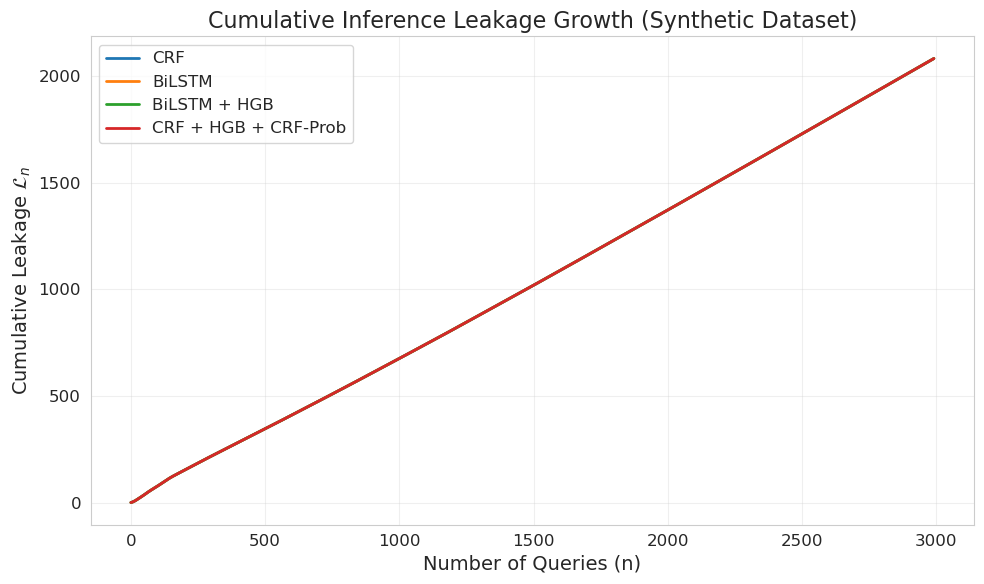

✔ Synthetic file successfully saved.


In [96]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.feature_selection import mutual_info_classif

# ==========================================================
# 1) FIX TARGET VECTOR
# ==========================================================
def fix_target(y):
    """
    Convert target to a 1D numeric vector.
    Handles pandas objects and one-hot encoded arrays.
    """
    if hasattr(y, "values"):
        y = y.values
    y = np.array(y)

    if len(y.shape) > 1 and y.shape[1] > 1:
        y = np.argmax(y, axis=1)

    return y.ravel()


# ==========================================================
# 2) PREPARE SYNTHETIC FEATURE MATRIX
# ==========================================================
def prepare_dataframe_matrix(X):
    """
    Convert pandas DataFrame to a clean numeric matrix.
    """
    X_mat = X.copy()

    # Convert columns to numeric where possible
    X_mat = X_mat.apply(pd.to_numeric, errors="coerce")

    # Replace NaN / Inf
    X_mat = X_mat.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    return X_mat.values.astype(float), list(X_mat.columns)


# ==========================================================
# 3) ROBUST LEAKAGE FUNCTION
# ==========================================================
def compute_leakage_sequence(X, y, start_n=10):
    """
    Compute cumulative leakage:
        L_n = sum Rel(X_i;Y)
    using average mutual information across features.
    """
    leakage = []
    cumulative = 0.0

    for i in range(start_n, len(X) + 1):
        X_subset = X[:i]
        y_subset = y[:i]

        # Remove bad rows
        mask = np.isfinite(X_subset).all(axis=1)
        X_subset = X_subset[mask]
        y_subset = y_subset[mask]

        if len(X_subset) < 5:
            leakage.append(cumulative)
            continue

        try:
            mi = mutual_info_classif(
                X_subset,
                y_subset,
                discrete_features=False,
                random_state=42
            )

            rel = np.mean(mi)
            cumulative += rel

        except Exception as e:
            print(f"Skipping step {i} due to MI failure: {e}")

        leakage.append(cumulative)

    leakage = np.insert(np.array(leakage), 0, 0.0)
    return leakage


# ==========================================================
# 4) PREPARE SYNTHETIC DATA
# ==========================================================
import pandas as pd

X_syn_numeric, syn_feature_names = prepare_dataframe_matrix(X_syn)
y_syn_fixed = fix_target(y_syn)

print("Synthetic X shape:", X_syn_numeric.shape)
print("Synthetic y shape:", y_syn_fixed.shape)
print("First 10 synthetic features:", syn_feature_names[:10])


# ==========================================================
# 5) TEMPORARY MODEL INPUTS
# ==========================================================
# Replace later with model-specific outputs if available
X_crf_syn = X_syn_numeric
X_bilstm_syn = X_syn_numeric
X_bilstm_hgb_syn = X_syn_numeric
X_full_syn = X_syn_numeric


# ==========================================================
# 6) COMPUTE LEAKAGE CURVES
# ==========================================================
print("Computing synthetic leakage curves...")

leak_crf = compute_leakage_sequence(X_crf_syn, y_syn_fixed, start_n=10)
leak_bilstm = compute_leakage_sequence(X_bilstm_syn, y_syn_fixed, start_n=10)
leak_bilstm_hgb = compute_leakage_sequence(X_bilstm_hgb_syn, y_syn_fixed, start_n=10)
leak_full = compute_leakage_sequence(X_full_syn, y_syn_fixed, start_n=10)

# ----------------------------------------------------------
# SAFETY CHECK
# ----------------------------------------------------------
if len(leak_crf) == 0:
    raise ValueError("Synthetic leakage curve is empty — plot cannot be generated.")

print("Synthetic leakage curves computed successfully.")


# ==========================================================
# 7) SET OUTPUT DIRECTORY
# ==========================================================
output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "leakage_synthetic.png")


# ==========================================================
# 8) PLOT + SAVE
# ==========================================================
plt.figure(figsize=(10, 6))

plt.plot(leak_crf, label="CRF", linewidth=2)
plt.plot(leak_bilstm, label="BiLSTM", linewidth=2)
plt.plot(leak_bilstm_hgb, label="BiLSTM + HGB", linewidth=2)
plt.plot(leak_full, label="CRF + HGB + CRF-Prob", linewidth=2)

plt.xlabel("Number of Queries (n)")
plt.ylabel("Cumulative Leakage $\\mathcal{L}_n$")
plt.title("Cumulative Inference Leakage Growth (Synthetic Dataset)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# SAVE BEFORE SHOW
plt.savefig(file_path, dpi=300, bbox_inches="tight")

print(f"Synthetic leakage figure saved at: {file_path}")

plt.show()


# ==========================================================
# 9) OPTIONAL: VERIFY FILE EXISTS
# ==========================================================
if os.path.exists(file_path):
    print("✔ Synthetic file successfully saved.")
else:
    print("❌ Synthetic file NOT found — check environment path.")

===== SYNTHETIC DATASET OVERVIEW =====
Shape: (3000, 16)

Columns:
['Gender', 'Role', 'Department', 'EmploymentType', 'YearsExperience', 'Salary', 'Age', 'PerformanceScore', 'Status', 'Location', 'Privileges', 'priv_count', 'high_risk_priv_count', 'is_active', 'is_permanent', 'TenureDays']

===== SUMMARY STATISTICS =====
                       count           mean           std      min       25%  \
Gender                3000.0       1.013000      0.824454      0.0      0.00   
Role                  3000.0       8.660333      5.140535      0.0      4.00   
Department            3000.0       1.824333      1.807733      0.0      0.00   
EmploymentType        3000.0       1.602000      0.658590      0.0      1.00   
YearsExperience       3000.0      10.002000      6.076812      0.0      5.00   
Salary                3000.0  106717.792000  34473.341269  35000.0  80000.00   
Age                   3000.0      40.936667     11.307222     22.0     31.00   
PerformanceScore      3000.0       3.

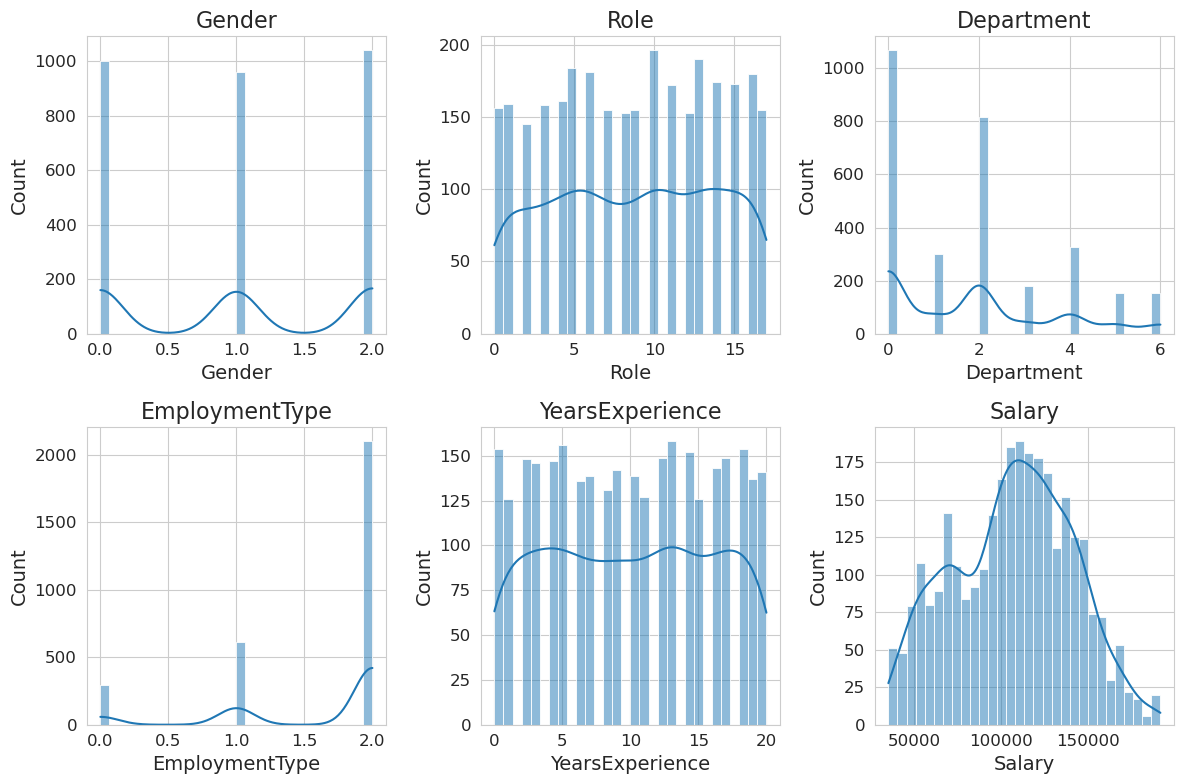

✔ Correlation heatmap saved at: results_figures/synthetic_correlation.png


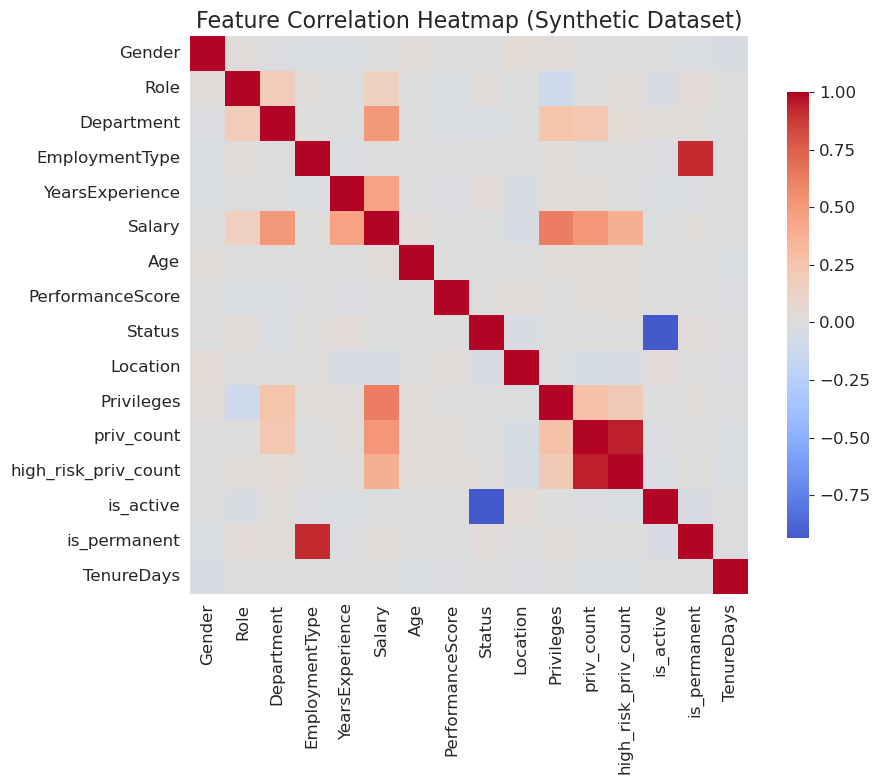


No categorical columns detected.


/tmp/ipykernel_41094/4071645128.py:117: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✔ Target distribution saved at: results_figures/target_distribution.png


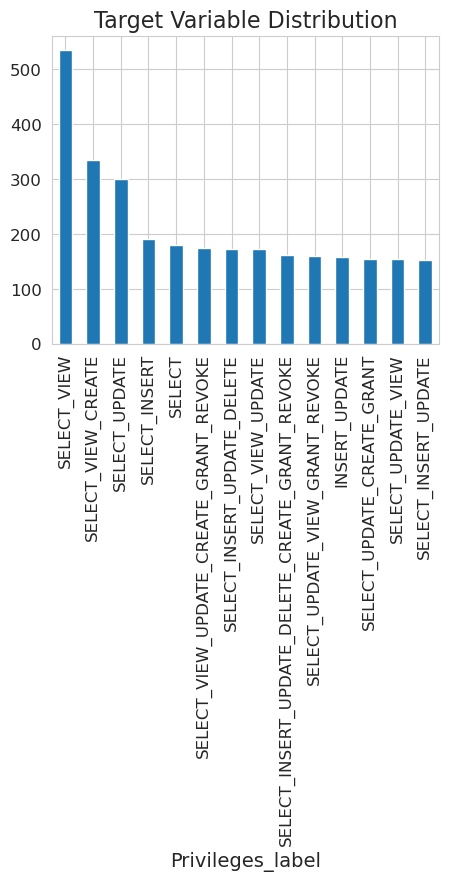

In [97]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================================
# 1) BASIC INFO
# ==========================================================
print("===== SYNTHETIC DATASET OVERVIEW =====")
print("Shape:", X_syn.shape)
print("\nColumns:")
print(X_syn.columns.tolist())

# ==========================================================
# 2) SUMMARY STATISTICS (FOR TABLE IN PAPER)
# ==========================================================
print("\n===== SUMMARY STATISTICS =====")
summary_stats = X_syn.describe().T

# Add variance for completeness
summary_stats["variance"] = X_syn.var()

print(summary_stats)

# OPTIONAL: SAVE AS CSV (for LaTeX conversion)
summary_stats.to_csv("synthetic_summary_stats.csv")


# ==========================================================
# 3) NUMERIC FEATURE DISTRIBUTION PLOT
# ==========================================================
numeric_cols = X_syn.select_dtypes(include=[np.number]).columns

# Limit number of plots (avoid clutter)
max_features = 6
selected_cols = numeric_cols[:max_features]

output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(12, 8))

for i, col in enumerate(selected_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(X_syn[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()

dist_path = os.path.join(output_dir, "synthetic_distribution.png")
plt.savefig(dist_path, dpi=300, bbox_inches="tight")

print(f"\n✔ Distribution plot saved at: {dist_path}")

plt.show()


# ==========================================================
# 4) CORRELATION HEATMAP (VERY USEFUL FOR REVIEWERS)
# ==========================================================
plt.figure(figsize=(10, 8))

corr = X_syn[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap (Synthetic Dataset)")
plt.tight_layout()

heatmap_path = os.path.join(output_dir, "synthetic_correlation.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")

print(f"✔ Correlation heatmap saved at: {heatmap_path}")

plt.show()


# ==========================================================
# 5) OPTIONAL: CATEGORICAL DISTRIBUTIONS (IF ANY)
# ==========================================================
categorical_cols = X_syn.select_dtypes(include=["object", "category"]).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        plt.figure(figsize=(6, 4))
        X_syn[col].value_counts().plot(kind="bar")
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)

        cat_path = os.path.join(output_dir, f"{col}_distribution.png")
        plt.tight_layout()
        plt.savefig(cat_path, dpi=300, bbox_inches="tight")

        print(f"✔ Saved categorical distribution: {cat_path}")

        plt.show()
else:
    print("\nNo categorical columns detected.")


# ==========================================================
# 6) OPTIONAL: TARGET DISTRIBUTION
# ==========================================================
if 'y_syn' in globals():
    plt.figure(figsize=(5, 4))
    pd.Series(y_syn).value_counts().plot(kind="bar")
    plt.title("Target Variable Distribution")

    target_path = os.path.join(output_dir, "target_distribution.png")
    plt.tight_layout()
    plt.savefig(target_path, dpi=300, bbox_inches="tight")

    print(f"✔ Target distribution saved at: {target_path}")

    plt.show()

Synthetic target length: 3000
Synthetic classes: ['INSERT_UPDATE' 'SELECT' 'SELECT_INSERT' 'SELECT_INSERT_UPDATE'
 'SELECT_INSERT_UPDATE_DELETE'
 'SELECT_INSERT_UPDATE_DELETE_CREATE_GRANT_REVOKE' 'SELECT_UPDATE'
 'SELECT_UPDATE_CREATE_GRANT' 'SELECT_UPDATE_VIEW'
 'SELECT_UPDATE_VIEW_GRANT_REVOKE' 'SELECT_VIEW' 'SELECT_VIEW_CREATE'
 'SELECT_VIEW_UPDATE' 'SELECT_VIEW_UPDATE_CREATE_GRANT_REVOKE']

Synthetic ROC inputs found:
BiLSTM (500, 14)
CRF + HGB + CRF-Prob (16, 4)
Skipping CRF + HGB + CRF-Prob: probability shape (16, 4) does not match 14 classes.
✔ ROC synthetic saved at: results_figures/roc_synthetic.png


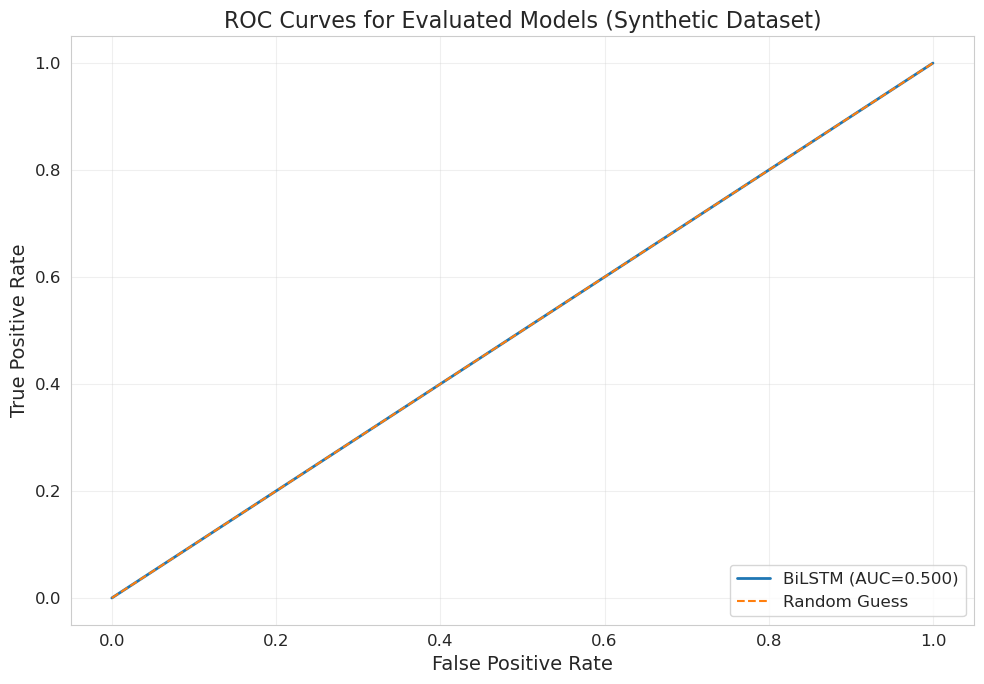

✔ ROC synthetic file successfully saved.


In [119]:
# ==========================================================
# ROC CURVES — SYNTHETIC DATASET
# Robust version for flat, one-hot, or CRF-style sequence labels
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================================
# 1) ROBUST TARGET FIXER
# ==========================================================
def fix_target(y):
    """
    Converts targets into a flat 1D vector.
    Handles:
      - pandas Series/DataFrame
      - one-hot arrays
      - flat label lists
      - nested CRF-style label sequences
    """
    if hasattr(y, "values"):
        y = y.values

    # CRF-style nested sequences: [[y1,y2], [y3,y4,y5], ...]
    if isinstance(y, list) and len(y) > 0 and isinstance(y[0], (list, tuple)):
        y = [label for seq in y for label in seq]

    y = np.array(y, dtype=object)

    # one-hot encoded labels
    if y.ndim > 1 and y.shape[1] > 1:
        y = np.argmax(y.astype(float), axis=1)

    return y.ravel()


# ==========================================================
# 2) SELECT SYNTHETIC TARGET LABELS
# ==========================================================
if "y_test_syn" in globals():
    y_true_syn = fix_target(y_test_syn)
elif "y_syn_test" in globals():
    y_true_syn = fix_target(y_syn_test)
elif "y_syn" in globals():
    y_true_syn = fix_target(y_syn)
elif "y_test" in globals():
    y_true_syn = fix_target(y_test)
else:
    raise NameError("No synthetic target found. Expected y_test_syn, y_syn_test, y_syn, or y_test.")

classes = np.unique(y_true_syn)

print("Synthetic target length:", len(y_true_syn))
print("Synthetic classes:", classes)


# ==========================================================
# 3) HELPER: CONVERT HARD PREDICTIONS TO SCORE MATRIX
# ==========================================================
def prediction_to_score(y_pred, classes):
    y_pred = fix_target(y_pred)
    return label_binarize(y_pred, classes=classes)


# ==========================================================
# 4) COLLECT AVAILABLE SYNTHETIC PROBABILITY OUTPUTS
# ==========================================================
model_probs_syn = {}

# ----------------------------
# CRF
# ----------------------------
if "crf_probs_syn" in globals():
    model_probs_syn["CRF"] = np.array(crf_probs_syn)

elif "y_pred_crf_syn" in globals():
    model_probs_syn["CRF"] = prediction_to_score(y_pred_crf_syn, classes)

elif "y_pred_crf" in globals():
    model_probs_syn["CRF"] = prediction_to_score(y_pred_crf, classes)


# ----------------------------
# BiLSTM
# ----------------------------
if "bilstm_probs_syn" in globals():
    model_probs_syn["BiLSTM"] = np.array(bilstm_probs_syn)

elif "y_pred_bilstm_syn" in globals():
    model_probs_syn["BiLSTM"] = prediction_to_score(y_pred_bilstm_syn, classes)

elif "y_pred_bilstm" in globals():
    model_probs_syn["BiLSTM"] = prediction_to_score(y_pred_bilstm, classes)


# ----------------------------
# BiLSTM + HGB
# ----------------------------
if "bilstm_hgb_probs_syn" in globals():
    model_probs_syn["BiLSTM + HGB"] = np.array(bilstm_hgb_probs_syn)

elif "y_pred_bilstm_hgb_syn" in globals():
    model_probs_syn["BiLSTM + HGB"] = prediction_to_score(y_pred_bilstm_hgb_syn, classes)

elif "y_pred_bilstm_hgb" in globals():
    model_probs_syn["BiLSTM + HGB"] = prediction_to_score(y_pred_bilstm_hgb, classes)


# ----------------------------
# CRF + HGB + CRF-Prob. Full Model
# ----------------------------
if "full_probs_syn" in globals():
    model_probs_syn["CRF + HGB + CRF-Prob"] = np.array(full_probs_syn)

elif "y_pred_full_syn" in globals():
    model_probs_syn["CRF + HGB + CRF-Prob"] = prediction_to_score(y_pred_full_syn, classes)

elif "y_pred_full" in globals():
    model_probs_syn["CRF + HGB + CRF-Prob"] = prediction_to_score(y_pred_full, classes)


if len(model_probs_syn) == 0:
    raise NameError(
        "No synthetic probability or prediction outputs found. "
        "Expected one of: crf_probs_syn, bilstm_probs_syn, bilstm_hgb_probs_syn, "
        "full_probs_syn, or y_pred_* equivalents."
    )

print("\nSynthetic ROC inputs found:")
for name, probs in model_probs_syn.items():
    print(name, np.array(probs).shape)


# ==========================================================
# 5) PLOT ROC CURVES SAFELY
# ==========================================================
output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "roc_synthetic.png")

plt.figure(figsize=(10, 7))

plotted = 0

for name, probs in model_probs_syn.items():
    probs = np.array(probs)

    # Align length
    min_len = min(len(y_true_syn), len(probs))
    y_eval = y_true_syn[:min_len]
    probs_eval = probs[:min_len]

    if len(y_eval) == 0:
        print(f"Skipping {name}: no aligned samples.")
        continue

    # Binary ROC
    if len(classes) == 2:
        if probs_eval.ndim == 2 and probs_eval.shape[1] > 1:
            y_score = probs_eval[:, 1]
        else:
            y_score = probs_eval.ravel()

        if len(y_score) != len(y_eval):
            print(f"Skipping {name}: length mismatch {len(y_score)} vs {len(y_eval)}.")
            continue

        fpr, tpr, _ = roc_curve(y_eval, y_score)
        roc_auc = auc(fpr, tpr)

    # Multiclass micro-average ROC
    else:
        if probs_eval.ndim == 1:
            probs_eval = prediction_to_score(probs_eval, classes)

        if probs_eval.shape[1] != len(classes):
            print(
                f"Skipping {name}: probability shape {probs_eval.shape} "
                f"does not match {len(classes)} classes."
            )
            continue

        y_bin_eval = label_binarize(y_eval, classes=classes)

        if y_bin_eval.ravel().shape[0] != probs_eval.ravel().shape[0]:
            print(
                f"Skipping {name}: flattened label/probability mismatch "
                f"{y_bin_eval.ravel().shape[0]} vs {probs_eval.ravel().shape[0]}."
            )
            continue

        fpr, tpr, _ = roc_curve(y_bin_eval.ravel(), probs_eval.ravel())
        roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

    plotted += 1


if plotted == 0:
    raise ValueError(
        "No valid ROC curves were plotted. Check that probability outputs and labels "
        "use the same samples and the same class space."
    )

plt.plot([0, 1], [0, 1], "--", linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Evaluated Models (Synthetic Dataset)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(file_path, dpi=300, bbox_inches="tight")
print(f"✔ ROC synthetic saved at: {file_path}")

plt.show()

if os.path.exists(file_path):
    print("✔ ROC synthetic file successfully saved.")
else:
    print("❌ ROC synthetic file not found.")

PermutationExplainer explainer: 17it [03:25, 12.82s/it]                        
/tmp/ipykernel_41094/3936799364.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, X_sample, show=False)


✔ SHAP synthetic saved: results_figures/shap_summary_synthetic.png


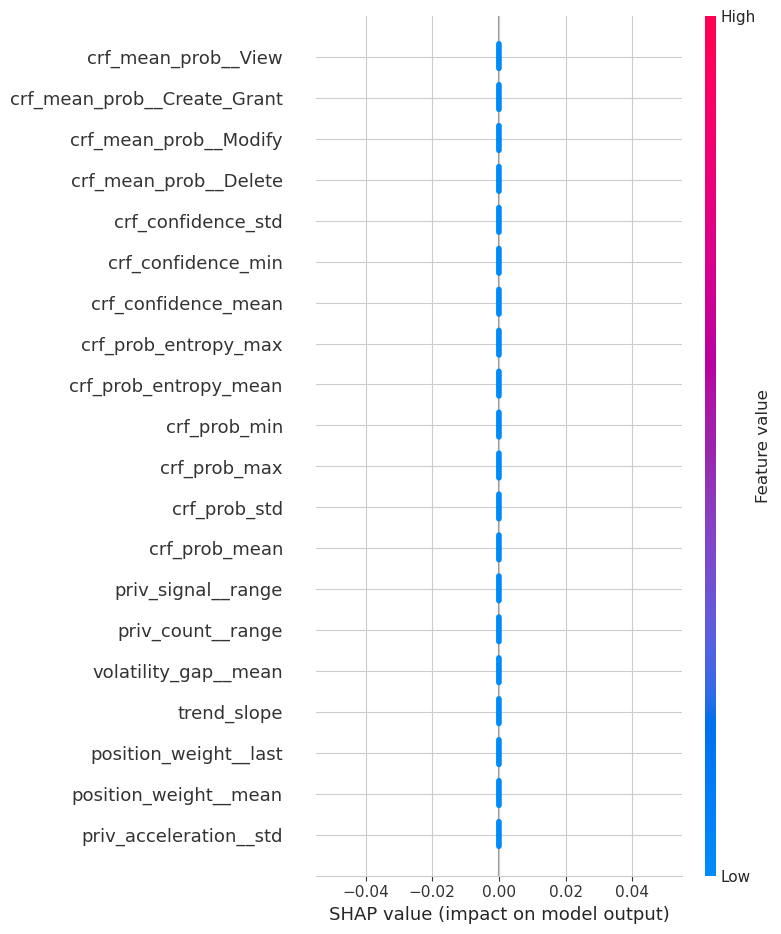

In [116]:
# ==========================================================
# SHAP SUMMARY — SYNTHETIC DATASET
# ==========================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

output_dir = "results_figures"
os.makedirs(output_dir, exist_ok=True)

# ----------------------------------------------------------
# 1) Select trained model
# ----------------------------------------------------------
if "tab_model" in globals():
    model_syn = tab_model
elif "hgb_model" in globals():
    model_syn = hgb_model
else:
    raise NameError("No trained HGB model found (tab_model / hgb_model).")

trained_feature_names = list(model_syn.feature_names_in_)

# ----------------------------------------------------------
# 2) Build synthetic fused features (same as training)
# ----------------------------------------------------------
def build_sequence_summary_features(X_seq, trained_feature_names):
    rows = []

    for seq in X_seq:
        row = {"seq_len": len(seq)}

        keys = sorted({
            k
            for d in seq
            if isinstance(d, dict)
            for k, v in d.items()
            if isinstance(v, (int, float, np.integer, np.floating, bool))
        })

        for k in keys:
            vals = np.array([
                float(d.get(k, 0.0))
                for d in seq
                if isinstance(d, dict)
            ])

            if len(vals) == 0:
                stats = [0]*6
            else:
                stats = [
                    vals.mean(), vals.std(),
                    vals.max(), vals.min(),
                    vals[-1], vals[0]
                ]

            names = ["mean","std","max","min","last","first"]
            for n, v in zip(names, stats):
                row[f"{k}__{n}"] = v

        rows.append(row)

    df = pd.DataFrame(rows)

    # Align to training features
    for col in trained_feature_names:
        if col not in df.columns:
            df[col] = 0.0

    df = df[trained_feature_names]
    df = df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    return df


X_syn_45 = build_sequence_summary_features(X_syn if "X_syn" in globals() else X_seq, trained_feature_names)

# Sample for speed
X_sample = X_syn_45.sample(min(1000, len(X_syn_45)), random_state=42)

# ----------------------------------------------------------
# 3) SHAP explainer
# ----------------------------------------------------------
def model_predict(X):
    X_df = pd.DataFrame(X, columns=trained_feature_names)
    return model_syn.predict_proba(X_df)

explainer = shap.Explainer(model_predict, X_sample, algorithm="permutation")
shap_values = explainer(X_sample)

# Select dominant class
pred_probs = model_syn.predict_proba(X_sample)
target_class = int(np.argmax(np.mean(pred_probs, axis=0)))

try:
    shap_values_plot = shap_values[:, :, target_class]
except:
    shap_values_plot = shap_values

# ----------------------------------------------------------
# 4) Plot + Save
# ----------------------------------------------------------
plt.figure()
shap.summary_plot(shap_values_plot, X_sample, show=False)

file_path = os.path.join(output_dir, "shap_summary_synthetic.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")

print("✔ SHAP synthetic saved:", file_path)
plt.show()

True
True
True
